# Word2Vec 之前的 NLP 核心技术

> 一份面向初学者的互动教学 notebook：沿着 **规则系统 -> 统计模型 -> 稀疏向量 -> 传统机器学习 -> 序列标注 -> 潜在语义/共现矩阵 -> 早期神经语言模型 -> Word2Vec** 的路线，讲清 Word2Vec 为什么会出现。

这份教程关注最核心、最有代表性的技术，不追求覆盖所有历史分支。每章都围绕 6 个问题：

1. 它诞生在什么背景下？
2. 之前的方案有什么问题？
3. 它解决什么问题？
4. 核心思想怎么自然推导出来？
5. 用一个小例子怎么算？
6. 它的优势、短板，以及和 Word2Vec 的关系是什么？

阅读方式：从上往下依次运行代码单元。示例使用内置小语料，不需要下载外部数据。

## 0 · 环境准备与 toy corpus

为了把注意力放在算法机制上，教程使用几组很小的英文句子。英文示例可以避免中文分词依赖；讲解仍然用中文。

运行前先确认三件事：

1. 在项目目录执行过 `uv sync`。
2. Jupyter 选择的是这个项目的 Python 3 kernel。
3. 如果 import 失败，先回到 README 的“快速开始”重新安装依赖。

### 0.1 导入依赖

先把整份教程会用到的标准库、`numpy` / `matplotlib` / `sklearn` 一次性导入。后面每一章都直接复用这里 import 好的模块，不再重复 `import`。

In [1]:
import itertools
import math
import random
import re
import sys
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import sklearn

# sklearn 在这里主要承担“经典 NLP 流水线”的工程角色：
# - Vectorizer: 把文本转成词频/TF-IDF 矩阵
# - Classifier: 展示传统机器学习如何接在稀疏特征后面
# - Decomposition/Topic Model: 展示 LSA/LDA 这类 Word2Vec 前的语义表示
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

### 0.2 随机种子与绘图设置

固定随机种子是让教学结果“每次运行都一样”的前提；绘图配置则让所有章节共用同一套排版和配色，读者一眼就能看出图表来自同一份教程。

In [2]:
SEED = 42
np.random.seed(SEED)
# 固定 numpy / random 相关随机行为，让 CV 划分、初始化、负采样等每次运行结果一致。
random.seed(SEED)

# Matplotlib Chinese font fallback.
# 如果系统里有中文字体，就让图表标题/标签直接显示中文；没有也不影响代码运行。
_cjk_candidates = ["PingFang SC", "Arial Unicode MS", "Heiti TC", "Songti SC",
                   "STHeiti", "Microsoft YaHei", "SimHei"]
_installed = {f.name for f in fm.fontManager.ttflist}
_cjk = [f for f in _cjk_candidates if f in _installed]
if _cjk:
    plt.rcParams["font.sans-serif"] = _cjk + plt.rcParams.get("font.sans-serif", [])

plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "figure.dpi": 115,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#ffffff",
    "axes.unicode_minus": False,
})

COLORS = {
    "blue": "#2563eb",
    "green": "#059669",
    "red": "#dc2626",
    "amber": "#d97706",
    "purple": "#7c3aed",
    "gray": "#6b7280",
}

### 0.3 tokenizer

`tokenize` 是整份教程唯一的分词函数。它故意做得非常简单：只留小写字母 token，一方面避免引入额外分词库，另一方面让读者可以专注在算法本身而不是分词细节上。所有章节的词表、共现、特征提取都基于它。

In [3]:
def tokenize(text):
    # 教学中使用英文 toy corpus：只保留小写字母 token，避免引入额外分词库。
    # 这是为了演示算法机制的极简 tokenizer，不适合真实生产分词，也不处理中文。
    return re.findall(r"[a-z]+", text.lower())

### 0.4 toy corpus

下面定义三组小语料，分别对应“主题 / 情感 / 评论”三条主线：

- `topic_docs`：4 类 × 4 篇 = 16 篇文档，服务于 BoW / TF-IDF / LSA / LDA / 检索等文档级表示。
- `sentiment_docs`：12 条情感句，展示传统机器学习分类如何从词特征学 pos/neg。
- `review_docs`：16 条包含稳定情绪锚词的评论，用来做 TF-IDF + 分类器的强基线。

为了后续章节的可读性，同时把每组语料的标签单独抽出来（`topic_labels` / `sentiment_labels` / `review_labels`），并保留 `labels` / `docs` 这两个历史命名（`labels` 指主题标签，`docs` 指主题文本）以兼容下游代码。

In [4]:
# topic_docs 用于 TF-IDF、LSA、LDA、文档检索等“文档级表示”示例。
topic_docs = [
    ("sports", "the team won the football match with a late goal"),
    ("sports", "the coach praised the player after the tournament"),
    ("sports", "a tennis player served fast and won the game"),
    ("sports", "the league match attracted many fans to the stadium"),
    ("medicine", "the doctor treated the patient in the hospital"),
    ("medicine", "a nurse checked the patient and gave medicine"),
    ("medicine", "the vaccine reduced infection and protected the patient"),
    ("medicine", "the clinic used a new treatment for the disease"),
    ("finance", "the bank approved the loan and reduced interest"),
    ("finance", "the market rose after the company reported profit"),
    ("finance", "investors bought stock when the price fell"),
    ("finance", "the fund manager studied risk and return"),
    ("technology", "the software engineer trained a machine learning model"),
    ("technology", "the computer processed data with a fast algorithm"),
    ("technology", "the startup built an app using cloud infrastructure"),
    ("technology", "the neural network learned patterns from data"),
]
# 保留历史命名：labels 指主题标签、docs 指主题文本；同时提供更明确的 topic_labels 供阅读。
topic_labels = [x[0] for x in topic_docs]
docs = [x[1] for x in topic_docs]
# 新代码请优先使用 `topic_labels` / `topic_docs`，`labels` / `docs` 是历史兼容别名。
labels = topic_labels

# sentiment_docs 用于传统机器学习分类示例：让模型从词特征学习 pos/neg。
sentiment_docs = [
    ("pos", "the movie was wonderful and moving"),
    ("pos", "i loved the story and the acting"),
    ("pos", "the product is useful reliable and fast"),
    ("pos", "the service was friendly and helpful"),
    ("pos", "this phone has excellent battery and camera"),
    ("pos", "the lesson was clear practical and inspiring"),
    ("neg", "the movie was boring and slow"),
    ("neg", "i hated the story and the acting"),
    ("neg", "the product is broken unreliable and slow"),
    ("neg", "the service was rude and unhelpful"),
    ("neg", "this phone has terrible battery and camera"),
    ("neg", "the lesson was confusing vague and tiring"),
]
sentiment_labels = [x[0] for x in sentiment_docs]

# review_docs 是更适合展示“TF-IDF + 简单分类器”强基线的小语料：
# 每条评论都保留 good / bad 这类稳定情绪锚词，让交叉验证能展示机制本身，
# 而不是被 16 条样本里每个情绪词只出现一次的随机切分噪声淹没。
# 锚词故意分布在句首/句中/句末，避免分类器把“首词位置”当成情感线索。
review_docs = [
    ("pos", "good wonderful moving film"),
    ("pos", "loved inspiring good story"),
    ("pos", "useful reliable product good"),
    ("pos", "good friendly helpful service"),
    ("pos", "excellent battery good camera"),
    ("pos", "good clear practical lesson"),
    ("pos", "fast reliable phone good"),
    ("pos", "good helpful clear support"),
    ("neg", "bad boring slow film"),
    ("neg", "hated confusing bad story"),
    ("neg", "broken unreliable product bad"),
    ("neg", "bad rude unhelpful service"),
    ("neg", "terrible battery bad camera"),
    ("neg", "bad confusing vague lesson"),
    ("neg", "slow broken phone bad"),
    ("neg", "bad tiring vague support"),
]
review_labels = [x[0] for x in review_docs]

print("topic docs:", len(topic_docs))
print("sentiment docs:", len(sentiment_docs))
print("review docs:", len(review_docs))
print("sample:", docs[0])

topic_dist = Counter(topic_labels)
sentiment_dist = Counter(sentiment_labels)
review_dist = Counter(review_labels)
# topic_vocab: 主题语料的完整词表；下面 0.5 的体检表会直接复用这个变量，不再重算。
topic_vocab = sorted(set(w for doc in docs for w in tokenize(doc)))
print("topic label distribution:", dict(topic_dist))
print("sentiment label distribution:", dict(sentiment_dist))
print("review label distribution:", dict(review_dist))
print("tokenized sample:", tokenize(docs[0]))
print("topic vocabulary size:", len(topic_vocab))

topic docs: 16
sentiment docs: 12
review docs: 16
sample: the team won the football match with a late goal
topic label distribution: {'sports': 4, 'medicine': 4, 'finance': 4, 'technology': 4}
sentiment label distribution: {'pos': 6, 'neg': 6}
review label distribution: {'pos': 8, 'neg': 8}
tokenized sample: ['the', 'team', 'won', 'the', 'football', 'match', 'with', 'a', 'late', 'goal']
topic vocabulary size: 86


### 0.5 环境自检与 corpus 体检

这一小段不是算法内容，而是让 notebook 的运行环境和 toy corpus 状态可见。后面所有章节都会复用这里的 tokenizer、语料和绘图配置。

| 数据 | 后续用途 |
|------|----------|
| `topic_docs` | BoW、TF-IDF、检索、LSA、LDA、文档级主题理解 |
| `sentiment_docs` | 传统机器学习文本分类 |
| `review_docs` | TF-IDF + 分类器的强基线交叉验证 |
| `cooc_sentences` | 共现语料放在第 8 章一起定义，因为词表更小、结构更特殊 |
| 序列标注示例语料 | 在第 6 章内联给出，与该章的 HMM/CRF 语料紧耦合 |

Python executable: ./.venv/bin/python
Python version: 3.12.9
numpy: 2.5.1
sklearn: 1.9.0

How topic vocabulary size is computed:
  total topic tokens: 130
  unique tokens (== len(topic_vocab)): 86
  first 20 sorted vocabulary items: ['a', 'after', 'algorithm', 'an', 'and', 'app', 'approved', 'attracted', 'bank', 'bought', 'built', 'checked', 'clinic', 'cloud', 'coach', 'company', 'computer', 'data', 'disease', 'doctor']


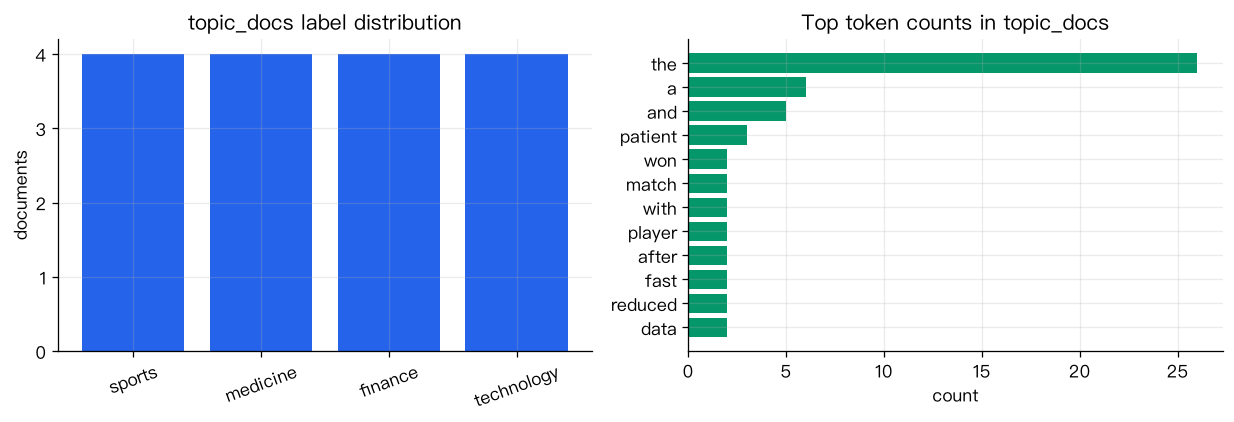

In [5]:
# 体检 = 断言 + 打印 + 图：先用 assert 卡住“数量假设”，再展示环境与 corpus 概览。
# 运行成功的判据：如果三组语料数量对不上，后面章节的假设（16/12/16）就不成立，
# 直接抛错比“悄悄跑错”要好。
assert len(topic_docs) == 16 and len(sentiment_docs) == 12 and len(review_docs) == 16, \
    "toy corpus 数量与教程假设不一致"

print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)

# 首次计算 token 计数用于热门词图；topic_vocab 仍复用 0.4 的结果。
# topic_token_counts 用来画“热门 token”条形图，语义比整表词表更细一层。
all_topic_tokens = [tok for doc in docs for tok in tokenize(doc)]
topic_token_counts = Counter(all_topic_tokens)
print("\nHow topic vocabulary size is computed:")
print("  total topic tokens:", len(all_topic_tokens))
print("  unique tokens (== len(topic_vocab)):", len(topic_vocab))
print("  first 20 sorted vocabulary items:", topic_vocab[:20])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

topic_names = list(topic_dist.keys())
axes[0].bar(topic_names, [topic_dist[name] for name in topic_names], color=COLORS["blue"])
axes[0].set_title("topic_docs label distribution")
axes[0].set_ylabel("documents")
axes[0].tick_params(axis="x", rotation=20)

top_words = topic_token_counts.most_common(12)
axes[1].barh([w for w, _ in top_words][::-1], [c for _, c in top_words][::-1], color=COLORS["green"])
axes[1].set_title("Top token counts in topic_docs")
axes[1].set_xlabel("count")

plt.tight_layout()
plt.show()

### 0.6 本章 = 公共基础

第 0 章的目的不是介绍某个算法，而是把整份教程要反复使用的“公共基础”一次性搭好：

- **代码工具**：`SEED`、`np`、`plt`、`COLORS`、`tokenize`。
- **数据资产**：`topic_docs / docs / labels / topic_labels`、`sentiment_docs / sentiment_labels`、`review_docs / review_labels`。

后面每一章都会直接复用这些变量名，不会再重新构造。因此**如果在后续章节遇到不认识的变量，可以先回到本章查看它的定义**——尤其是 `docs / labels / tokenize / COLORS / SEED` 这几个短名。

## 1 · 总览：Word2Vec 之前 NLP 在解决什么

### 一句话直觉

想象你把一封中文邮件塞进一个只会做算术的计算器：它当然算不了。**NLP (Natural Language Processing，自然语言处理)** 面对的第一性问题就是这么朴素——

> 语言是**离散符号**（字、词、标点），而机器学习模型只会处理**数字（向量、矩阵）**。所以在做"分类 / 检索 / 翻译 / 生成"之前，必须先解决一个问题：**怎样把语言变成数学结构？**

Word2Vec 之前的所有经典技术，都是围绕这个问题在**一层一层补短板**：上一代方法解决了一部分，暴露出新的短板，下一代方法接着补。到了 2013 年，Word2Vec 把"词 → 稠密向量"这一步做得又快又好，成为承上启下的关键节点。

### 场景类比：从"分拣快递"到"理解快递"

把 NLP 想成一个快递分拣中心的演化：

| 阶段 | 快递中心怎么做 | 对应的 NLP 方法 |
|------|---------------|-----------------|
| 手工时代 | 老师傅背规则："写 hospital 的走医疗口" | 规则、词典、正则 |
| 台账时代 | 统计每种关键词出现多少次，按频率分拣 | N-gram、BoW、TF-IDF |
| 流水线时代 | 台账做成特征，交给自动分拣机 | 传统机器学习 + 特征工程 |
| 精细标注时代 | 每件快递每一段路径都要打标签（几点到哪站） | HMM、CRF 序列标注 |
| 语义压缩时代 | 发现很多快递内容重复，用"主题"压缩表示 | LSA、PLSA、LDA |
| 关系时代 | 分析"哪些词总在同一句里"，学词之间的关系 | 共现矩阵、PMI、SVD |
| 神经时代 | 让模型自己学表示，不再靠人写特征 | NNLM → **Word2Vec** → ... |

每一次升级都不是"抛弃过去"，而是"上一代做不了的事，这一代补上"。

### 关键中英文对照

先把本章反复出现的英文缩写整理成一张速查表：

| 英文 / 缩写 | 中文名 | 一句话说明 |
|-------------|--------|------------|
| NLP (Natural Language Processing) | 自然语言处理 | 让计算机处理人类语言的一整个学科 |
| Corpus | 语料库 | 一批用来训练/统计的文本集合 |
| Token | 词元 / 标记 | 切分后最小的处理单位（英文常是词、中文常是字或词） |
| Tokenization | 分词 / 切分 | 把原始字符串切成 token 序列 |
| Vocabulary $V$ | 词表 | 语料里所有 token 去重后的集合 |
| Vector Space | 向量空间 | 每个文本/词被表示成的数值坐标空间 |
| One-hot | 独热编码 | 用一个只有 1 位为 1 的高维稀疏向量表示一个词 |
| BoW (Bag of Words) | 词袋 | 忽略词序，只统计每个词出现次数 |
| N-gram | N 元语法 | 相邻 N 个词构成的片段（2-gram、3-gram） |
| TF-IDF (Term Frequency – Inverse Document Frequency) | 词频-逆文档频率 | 常见的稀疏文档向量加权方案 |
| HMM (Hidden Markov Model) | 隐马尔可夫模型 | 用"起始+转移+发射"建模标签序列 |
| CRF (Conditional Random Field) | 条件随机场 | 判别式序列标注模型，能吃丰富特征 |
| LSA (Latent Semantic Analysis) | 潜在语义分析 | 用 SVD 把文档-词矩阵压到低维语义空间 |
| PLSA / LDA | 概率/狄利克雷主题模型 | 用概率生成过程解释文档-词共现 |
| PMI / PPMI | 点互信息 / 正点互信息 | 两个词共现是否超过偶然，浓缩成一个数 |
| SVD (Singular Value Decomposition) | 奇异值分解 | 把大稀疏矩阵压成低维几何空间（$U\Sigma V^\top$） |
| NNLM (Neural Network Language Model) | 神经网络语言模型 | Bengio 2003 提出的、用神经网络学词表示 + 语言模型 |
| Word2Vec | 词向量 | 2013 年 Mikolov 提出的高效词向量学习方法 |
| Embedding | 嵌入 / 稠密向量 | 用低维实数向量表示离散符号 |

> 本章只做地图，具体每种技术的数学推导与代码实现请到对应章节。

### 一张主线图：NLP 的第一性问题就是"离散 → 数学结构"

无论方法多不同，做的都是同一件事：

```text
    离散符号                       数学结构
"the doctor treated ..."   ==>   向量 / 矩阵 / 概率 / 张量
     (语言)                        (机器能算)
```

- 规则时代用**布尔条件**表示 "医疗类=1"；
- 统计时代用**频率、概率**表示 "P(patient|doctor)=0.3"；
- 向量时代用**稀疏/稠密向量**表示 "doctor = [0, 0, 1, 0, ...]" 或 "[0.12, -0.05, ...]"；
- 神经时代用**可学习的 embedding 矩阵**表示 "所有词共享同一份查找表"。

每一步都在让这个"数学结构"更紧凑、更有语义、更好训练。

### 阅读地图：每一章在补哪个短板

把每一章都看成"上一代方法的一个补丁"。**推荐按顺序阅读**——后一章的动机建立在前一章的短板上。

| 章 | 关注对象 | 前一代的短板 | 这一章补上的能力 | 留下的新短板 |
|----|----------|--------------|------------------|--------------|
| 2 规则 / 词典 | 词面匹配 | — | 用人工知识做冷启动 | 覆盖率差、维护贵、不懂同义词 |
| 3 N-gram | 相邻词概率 | 规则写不完 | 从语料**统计**出语言规律 | 数据稀疏、上下文短、词是离散 |
| 4 BoW / TF-IDF | 文档向量 | N-gram 只描述局部 | 把整篇文档变成一个向量 | 高维稀疏、忽略同义与词序 |
| 5 传统 ML | 特征 + 分类器 | TF-IDF 本身不做决策 | 把稀疏特征接到自动分类器 | 特征全靠人工设计 |
| 6 HMM / CRF | 序列标注 | 前几章只给整句打一个标签 | 给**每个词**都打标签，利用**标签之间**的依赖 | 特征仍需设计，词是离散符号 |
| 7 LSA / PLSA / LDA | 文档级主题 | TF-IDF 不懂 `car ≈ automobile` | 把文档投影到低维**主题空间** | 偏文档级，词义粒度粗 |
| 8 PMI / SVD 词向量 | 词级共现 | 主题模型不给每个词单独的向量 | 从共现矩阵得到**词级语义向量** | 矩阵巨大、低频不稳定 |
| 9 NNLM | 神经语言模型 | 计数方法难泛化到罕见组合 | 用**共享 embedding**做参数共享和泛化 | 完整 softmax 太慢 |
| 10 **Word2Vec** | 高效词向量 | NNLM 训练太慢 | 用 Skip-gram/CBOW + 负采样把词向量学得又快又好 | 静态向量，不区分一词多义（→ ELMo/BERT） |

一句话总结这张表：**"离散 → 向量"这条路，越走越精细，越走越自动。Word2Vec 是它的一个高光节点，但不是终点。**

### 阅读方式与前置依赖

- **前置**：只需熟悉基本 Python、numpy、少量线性代数与概率直觉；不需要提前学过 NLP。
- **依赖**：所有章节共用第 0 章定义的 `tokenize`、`docs / labels`、`COLORS`、`SEED` 等；示例语料很小，运行秒级完成。
- **推荐顺序**：按章节从 2 到 10 依次读。想跳读时，看上表"这一章补上的能力"这一列决定去哪章。
- **和 Word2Vec 的关系**：本章是**全书导览**；Word2Vec 会在第 10 章正式登场。它是这条主线上一个特别关键的节点，但整条线在它之后还继续延伸到 GloVe、fastText、ELMo、BERT、GPT。

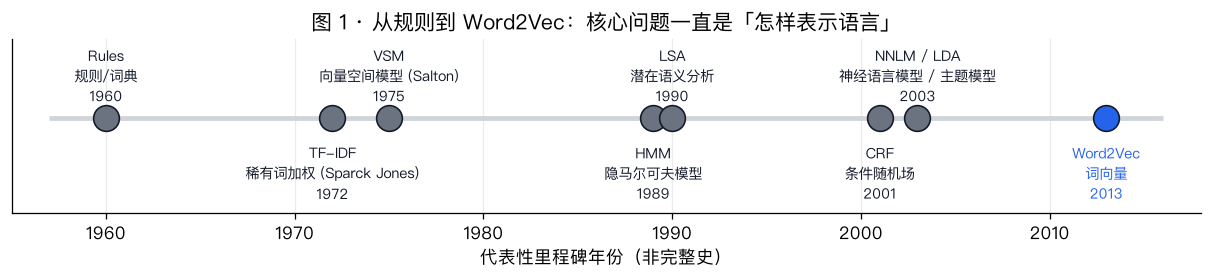

时间线注解（每一站在补上一代什么短板）：
  1960  Rules                -> 专家写规则、词典匹配
  1972  TF-IDF               -> 文档-词矩阵中给稀有词更高权重
  1975  VSM                  -> 把文档统一表示成向量，可算相似度
  1989  HMM                  -> 语音/词性等序列建模
  1990  LSA                  -> SVD 得到低维语义空间
  2001  CRF                  -> 判别式序列标注
  2003  NNLM / LDA           -> 神经 embedding、狄利克雷主题
  2013  Word2Vec             -> Skip-gram / CBOW，词向量普及


In [6]:
# ------------------------------------------------------------
# 图 1：NLP 演化时间线 —— 每一站都在补上一代的短板
# ------------------------------------------------------------
# 说明：里程碑年份只挑代表性事件，并非完整历史。
# Word2Vec 用蓝色高亮，提示它是本教程所有前置技术汇合后的下一站。
stages = [
    ("Rules\n规则/词典", 1960, "专家写规则、词典匹配"),
    ("TF-IDF\n稀有词加权 (Sparck Jones)", 1972, "文档-词矩阵中给稀有词更高权重"),
    ("VSM\n向量空间模型 (Salton)", 1975, "把文档统一表示成向量，可算相似度"),
    ("HMM\n隐马尔可夫模型", 1989, "语音/词性等序列建模"),
    ("LSA\n潜在语义分析", 1990, "SVD 得到低维语义空间"),
    ("CRF\n条件随机场", 2001, "判别式序列标注"),
    ("NNLM / LDA\n神经语言模型 / 主题模型", 2003, "神经 embedding、狄利克雷主题"),
    ("Word2Vec\n词向量", 2013, "Skip-gram / CBOW，词向量普及"),
]

fig, ax = plt.subplots(figsize=(11, 2.8))
years = [y for _, y, _ in stages]
# 一条水平主线：强调"演进是补丁式的，不是断裂替代"。
ax.hlines(0, min(years) - 3, max(years) + 3, color="#d1d5db", linewidth=3)
for i, (name, year, note) in enumerate(stages):
    is_w2v = name.startswith("Word2Vec")
    ax.scatter(year, 0, s=260,
               color=COLORS["blue"] if is_w2v else COLORS["gray"],
               edgecolor="#111827", linewidth=1.0, zorder=3)
    y_text = 0.32 if i % 2 == 0 else -0.42
    ax.text(year, y_text, f"{name}\n{year}",
            ha="center", va="center", fontsize=9,
            color=COLORS["blue"] if is_w2v else "#111827")

ax.set_yticks([])
ax.set_xlabel("代表性里程碑年份（非完整史）")
ax.set_title("图 1 · 从规则到 Word2Vec：核心问题一直是「怎样表示语言」")
ax.set_xlim(min(years) - 5, max(years) + 5)
ax.set_ylim(-0.72, 0.60)
fig.subplots_adjust(left=0.04, right=0.98, top=0.78, bottom=0.24)
plt.show()

print("时间线注解（每一站在补上一代什么短板）：")
for name, year, note in stages:
    short = name.split("\n")[0]
    print(f"  {year}  {short:<20} -> {note}")

In [7]:
# ------------------------------------------------------------
# 图 2 (多视角演示)：同一句话在不同方法下会被翻译成不同的数学结构
# ------------------------------------------------------------
# 目标：让你在正式进入第 2 章之前，先感受一件事——
# "规则 / N-gram / BoW / word-context 四个视角，
#  形状不同，但都在做同一件事：把离散文本转成数字或结构。"
overview_text = "the doctor treated the patient"
overview_tokens = tokenize(overview_text)

# --- 视角 A：规则 / 词典命中 ---
# 规则视角只关心"这句话里有没有出现某类关键词"，
# 输出是一个布尔/集合结构，非常好解释但没有语义泛化。
medicine_keywords = {"doctor", "patient", "hospital", "nurse", "vaccine"}
rule_hits = sorted(set(overview_tokens) & medicine_keywords)

# --- 视角 B：N-gram (bigram) ---
# 相邻词对（2-gram）能抓到局部搭配，比如 "doctor treated"。
overview_bigrams = list(zip(overview_tokens[:-1], overview_tokens[1:]))

# --- 视角 C：BoW 词袋向量 ---
# 忽略顺序，只数每个词出现几次，得到一个稀疏计数向量。
overview_bow = Counter(overview_tokens)
overview_vocab = ["the", "doctor", "treated", "patient"]
overview_vector = [overview_bow[w] for w in overview_vocab]

# --- 视角 D：word-context 窗口对（Word2Vec 的前身思路）---
# 以每个词为中心，取窗口内的其他词作为"上下文"，
# 这种"中心词-上下文"视角一路走到第 8 章 PMI/SVD 和第 10 章 Word2Vec。
window_size = 1
context_pairs = []
for i, word in enumerate(overview_tokens):
    lo = max(0, i - window_size)
    hi = min(len(overview_tokens), i + window_size + 1)
    for j in range(lo, hi):
        if i != j:
            context_pairs.append((word, overview_tokens[j]))

center_idx = overview_tokens.index("doctor")
doctor_context = (
    overview_tokens[max(0, center_idx - window_size):center_idx]
    + overview_tokens[center_idx + 1:center_idx + 1 + window_size]
)

print("同一句话:", overview_text)
print("分词后的 tokens:", overview_tokens)
print()
print("视角 A · 规则/词典视角")
print("  医疗关键词命中:", rule_hits, " -> 简单粗暴，但看不出同义、看不出结构")
print()
print("视角 B · N-gram 视角 (bigram)")
print("  相邻词对:", overview_bigrams)
print("  bigram 计数:", dict(Counter(overview_bigrams)))
print("  -> 抓到局部搭配，但仍是离散的 (词, 词) 元组")
print()
print("视角 C · BoW / 词袋向量视角")
print("  展示词表:", overview_vocab)
print("  BoW 向量:", overview_vector, "  # 每一维 = 该词在句中出现次数")
print("  -> 已经是数字向量了，可以喂给分类器；但 the/doctor 是两个正交维度，没有语义联系")
print()
print("视角 D · word-context 窗口视角 (window={})".format(window_size))
print("  所有 (中心词, 上下文词) 对:", context_pairs)
print("  以 'doctor' 为中心的上下文:", doctor_context)
print("  -> 这个视角关心'谁和谁经常同框'，直接通向 PMI/SVD 与 Word2Vec")
print()
print("=" * 60)
print("统一结论：四个视角形状不同（集合 / 元组 / 向量 / 词对），")
print("           但都在做同一件事：**离散文本 -> 可计算的数字或结构**。")
print("           后续每一章都是在优化这个'翻译'的表达力与效率。")

同一句话: the doctor treated the patient
分词后的 tokens: ['the', 'doctor', 'treated', 'the', 'patient']

视角 A · 规则/词典视角
  医疗关键词命中: ['doctor', 'patient']  -> 简单粗暴，但看不出同义、看不出结构

视角 B · N-gram 视角 (bigram)
  相邻词对: [('the', 'doctor'), ('doctor', 'treated'), ('treated', 'the'), ('the', 'patient')]
  bigram 计数: {('the', 'doctor'): 1, ('doctor', 'treated'): 1, ('treated', 'the'): 1, ('the', 'patient'): 1}
  -> 抓到局部搭配，但仍是离散的 (词, 词) 元组

视角 C · BoW / 词袋向量视角
  展示词表: ['the', 'doctor', 'treated', 'patient']
  BoW 向量: [2, 1, 1, 1]   # 每一维 = 该词在句中出现次数
  -> 已经是数字向量了，可以喂给分类器；但 the/doctor 是两个正交维度，没有语义联系

视角 D · word-context 窗口视角 (window=1)
  所有 (中心词, 上下文词) 对: [('the', 'doctor'), ('doctor', 'the'), ('doctor', 'treated'), ('treated', 'doctor'), ('treated', 'the'), ('the', 'treated'), ('the', 'patient'), ('patient', 'the')]
  以 'doctor' 为中心的上下文: ['the', 'treated']
  -> 这个视角关心'谁和谁经常同框'，直接通向 PMI/SVD 与 Word2Vec

统一结论：四个视角形状不同（集合 / 元组 / 向量 / 词对），
           但都在做同一件事：**离散文本 -> 可计算的数字或结构**。
           后续每一章都是在优化这个'翻译'的表

### 小结：本章是导航，而不是算法

- **第一性问题**：把离散语言变成机器能算的数学结构。
- **主线**：规则 → 统计 → 稀疏向量 → 机器学习 → 序列结构 → 潜在语义 → 词级共现 → 神经表示 → **Word2Vec** → 之后的一切。
- **每一步都是补丁**：不是替代，而是解决上一代解决不了的问题；同时暴露下一代要解决的新问题。
- **本教程的组织方式**：按补丁顺序讲，读完你会明白 Word2Vec 为什么"必然"会出现——它不是天降神术，而是这条线上的自然一步。

下一章 (第 2 章) 从最古早的**规则与词典**开始：看看在没有大规模语料和算力的年代，人们是怎么让机器"理解"语言的，以及这套方法为什么很快就撑不住了。

## 2 · 规则、词典与模式匹配（Rule-based System）

### 一句话直觉

想象你刚上班第一天，被分配去人工分拣公司的客服工单。没人给你训练数据，也没有 AI 助手，但你手里有一份主管交给你的"经验小抄"：

```text
出现 "退款 / 发票 / 金额" -> 转财务
出现 "宕机 / 报错 / 崩溃" -> 转技术
出现 "预约 / 医生 / 药" -> 转医疗
```

于是你打开一封工单，眼睛快速扫一遍，看到 `hospital`、`patient`、`doctor` 就往医疗组扔。这就是 **Rule-based System（规则系统）** 最朴素的样子——**把"人的领域知识"直接写成 if / else**，不训练、不学习，输入进来立刻能跑。

早期 NLP 几乎全靠这条路：那时候没有 Web 级语料、没有 GPU、也没有可导优化，能用的只有一批语言学家、几本词典和一支笔。

### 要解决什么问题

本章会一并演示规则系统的两种常见形态，它们其实对应 NLP 里**两类不同的问题**——章头先把这条分岔线画出来，后面再看就不会晕：

- **关键词 / 词典匹配 —— 文本分类**：**输入**一段文本（一条工单、一句话），**输出**一个类别标签（`sports / medicine / finance / technology / unknown`）。整段进、一个标签出。Step 1、2、4 走的都是这条路。
- **正则表达式 —— 结构化信息抽取**：**输入**一段文本，**输出**不是"整段一个标签"，而是文本里若干**片段（span）** 及其类型（金额、日期、邮箱……）。它已经很接近第 6 章 HMM 要正式讨论的**序列标注**——只是这里"哪几个字符是金额"是靠人写死的模式硬匹配出来的，还没让模型学。Step 3 就是这条路。

一句话：**同样是"人写规则"，但"整段属于哪一类"走分类，"这段里哪几个位置是金额 / 日期"走抽取。**后面几章会把这两类问题分头交给统计模型（第 3~5 章围着"分类 / 语言建模"）和序列标注模型（第 6 章 HMM 正式接手"抽取"）。

### 诞生背景：为什么早期 NLP 先做规则？

| 客观限制 | 直接后果 |
|----------|----------|
| Data (数据) 稀缺，没有大规模标注语料 | 无法做监督学习，只能把知识"手写下来" |
| Compute (算力) 有限，内存只有几 MB | 复杂统计/矩阵分解都跑不动，倒是查字典很便宜 |
| 语言学 (Linguistics) 已经积累了很多现成词典和词法规则 | 直接搬进程序就是可用系统 |
| 业务领域窄、术语稳定（法律、医疗、金融） | 规则的"覆盖不全"问题在这些场景里不那么致命 |

一句话：**当时"人写规则"是唯一便宜且能落地的方案**。这条路线也被叫做 **Symbolic AI (符号主义 AI)**，思想是把智能拆成"符号 + 规则推理"。

### 关键中英文对照

| 英文 / 缩写 | 中文名 | 一句话说明 |
|-------------|--------|------------|
| Rule-based System | 规则系统 | 用人写的 if/else 或匹配规则做决策，不训练 |
| Symbolic AI | 符号主义 AI | 把语言/知识表示成符号，用逻辑规则推理 |
| Lexicon / Dictionary | 词典 | 一份"词 -> 类别/属性"的映射表 |
| Keyword Match | 关键词匹配 | 看句子里出现哪些关键词来打分或分类 |
| Regex / Regular Expression | 正则表达式 | 用简洁语法描述"符合某种格式的字符串" |
| Pattern Extraction | 模式抽取 | 从文本里抽出结构化片段（金额、日期、邮箱…） |
| Coverage | 覆盖率 | 系统能正确处理的输入占总输入的比例 |
| Precision | 精度 | 系统给出的答案里，正确答案所占的比例 |
| Ambiguity | 歧义 | 同一个词/短语在不同语境下含义不同 |
| Homonym / Polysemy | 同形异义 / 一词多义 | `bank` 可以是银行，也可以是河岸 |
| Synonym | 同义词 | `doctor` 和 `physician` 意思接近，但字面不同 |
| OOV (Out-of-Vocabulary) | 未登录词 | 词典里没写过、系统压根没见过的词 |

### 规则系统能做什么、不能做什么

**能做的三件事**（后面代码会逐个演示）：

1. **词典 + 关键词分类**：出现 `hospital / doctor / patient` -> `medicine`。
2. **正则模式抽取**：从"退款 129.99 元，2026-07-15 之前，联系 alice@example.com"里抽出金额、日期、邮箱。
3. **固定模板的问答/客服**：匹配到"如何退款"就返回预写好的回复。

**做不了的四件事**：

1. **同义 (Synonym) 不懂**：`physician` 和 `doctor` 意思一样，词典没写就识别不了。
2. **一词多义 (Polysemy) 不消歧**：`bank by the river`（河岸）和 `bank loan`（银行贷款）里的 `bank` 会被同样处理。
3. **没关键词命中就投降**：一句"a beautiful story about friendship" 什么类别关键词都不含，只能返回 `unknown`。
4. **规则冲突自己救不了自己**：句子既含 `market`（金融）又含 `data`（科技）时，纯计数会出现打平。

这四条短板正是后面 N-gram、TF-IDF、Word2Vec 想要缓解的动机。

### 本章 4 个 Step

| Step | 做什么 | 想让你看到的现象 |
|------|--------|------------------|
| Step 1 | 写词典 + 关键词规则分类器 | 规则系统"没有训练"，输入立刻能跑 |
| Step 2 | 打分表：4 个正常样本 + 3 个坏样本 | 覆盖率不足、平局、`unknown` 都长什么样 |
| Step 3 | 正则抽取金额 / 日期 / 邮箱 | 面对**格式稳定**的信息，规则又快又准 |
| Step 4 | 手动扩词典把 `physician` 加进去 | 感受一下"维护规则"这件事的真实代价 |

> **依赖提示**：本章直接复用第 0 章定义的 `tokenize`（就是 `re.findall(r"[a-z]+", text.lower())` 那个极简分词器），不再重复导入或重新定义；后续章节里的 `docs / labels / topic_docs` 也遵循同一约定。

In [8]:
# ------------------------------------------------------------
# Step 1. 手写词典 + 关键词匹配 = 最朴素的 Rule-based Classifier
# ------------------------------------------------------------
# 关键词词典 (Lexicon)：一个类别对应一组"这个类别里典型会出现的词"。
# 这些词是**人拍脑袋写的**，代表"领域知识"，没有从数据里学任何东西。
keyword_rules = {
    "sports": {"team", "football", "coach", "player", "match", "tennis", "stadium"},
    "medicine": {"doctor", "patient", "hospital", "nurse", "vaccine", "clinic", "disease"},
    "finance": {"bank", "loan", "market", "profit", "stock", "fund", "risk"},
    "technology": {"software", "engineer", "machine", "algorithm", "cloud", "neural", "data"},
}


def rule_classify(text):
    # 规则分类器最纯粹的形式：没有权重、没有训练，只做集合交集。
    # 打分逻辑：命中类别关键词的个数 = 该类别得分。
    words = set(tokenize(text))
    matched = {label: sorted(words & kws) for label, kws in keyword_rules.items()}
    scores = {label: len(hits) for label, hits in matched.items()}
    best_score = max(scores.values())
    best_labels = [label for label, score in scores.items() if score == best_score]
    if best_score == 0:
        # 一个关键词都没命中：规则系统只能承认"我不知道"。
        best = "unknown"
    elif len(best_labels) > 1:
        # 好几个类别打成平手：规则本身给不出更细的判据。
        best = "tie: " + "/".join(best_labels)
    else:
        best = best_labels[0]
    return best, scores, matched


print("keyword_rules 里每个类别的关键词个数：")
for label, kws in keyword_rules.items():
    print(f"  {label:<11}: {len(kws)} words -> {sorted(kws)}")
print("\n注意：这份词典是人写死的；没写进去的词，规则系统就完全'看不见'。")

keyword_rules 里每个类别的关键词个数：
  sports     : 7 words -> ['coach', 'football', 'match', 'player', 'stadium', 'team', 'tennis']
  medicine   : 7 words -> ['clinic', 'disease', 'doctor', 'hospital', 'nurse', 'patient', 'vaccine']
  finance    : 7 words -> ['bank', 'fund', 'loan', 'market', 'profit', 'risk', 'stock']
  technology : 7 words -> ['algorithm', 'cloud', 'data', 'engineer', 'machine', 'neural', 'software']

注意：这份词典是人写死的；没写进去的词，规则系统就完全'看不见'。


In [9]:
# ------------------------------------------------------------
# Step 2. 用 9 个例句体验规则分类：4 正常 + 3 失败 + 2 打平
# ------------------------------------------------------------
# 前 4 句是"教科书好样本"：关键词命中明确，规则应该赢。
# 中间 3 句是**故意**放的失败案例，用来暴露规则系统的三种典型短板：
#   (a) Synonym    -> "physician / cured" 是 doctor / treated 的同义表达，词典没覆盖
#   (b) Polysemy   -> "bank" 在河岸语境下不是金融机构，规则不会消歧
#   (c) OOV / 无线索 -> 纯闲聊句一个关键词都不含
# 最后 2 句则专门制造"分数打平"的情况，用来触发 rule_classify 里的 `tie:` 分支：
#   (d) Tie -> 两个类别命中数一样多，规则本身没有更细的判据，只能承认"打平"
examples = [
    "the doctor used a new vaccine for the patient",
    "the team won the football match",
    "the bank studied risk before approving the loan",
    "the engineer built a neural model with data",
    "the physician cured a sick person",       # (a) 同义词失败
    "the bank by the river was quiet",         # (b) 一词多义失败
    "a beautiful story about friendship",      # (c) 无关键词命中
    "the bank engineer analyzed the market with a new algorithm",  # (d) finance vs technology 打平（各命中 2 个）
    "the hospital manages the fund and the clinic pays the loan",  # (d) medicine vs finance 打平（各命中 2 个）
]

for text in examples:
    pred, scores, matched = rule_classify(text)
    hits = {k: v for k, v in matched.items() if v}
    print(f"text : {text}")
    print(f"tokens        : {tokenize(text)}")
    print(f"matched words : {hits if hits else '{} (什么也没命中)'}")
    print(f"scores        : {scores}")
    print(f"prediction    : {pred}")
    print()

print("Score table (每一列 = 命中该类别关键词的个数):")
header = ["case", "sports", "medicine", "finance", "technology", "prediction"]
print(" | ".join(f"{h:^18}" for h in header))
print("-" * 120)
for text in examples:
    pred, scores, _ = rule_classify(text)
    row = [
        text[:18],
        str(scores["sports"]),
        str(scores["medicine"]),
        str(scores["finance"]),
        str(scores["technology"]),
        pred,
    ]
    print(" | ".join(f"{x:^18}" for x in row))

print("\n观察 (对应上面的 a / b / c / d 四种失败模式):")
print("  (a) 'the physician cured a sick person' -> unknown，因为词典没写 physician/cured。")
print("       这就是 Synonym (同义词) 问题：字面不同、意思相同，规则不知道。")
print("  (b) 'the bank by the river was quiet'   -> finance，因为规则只看到 bank，")
print("       完全不看它的上下文 river / quiet。这就是 Polysemy (一词多义) 未消歧。")
print("  (c) 'a beautiful story about friendship' -> unknown，任何类别都 0 分。")
print("       这就是 Coverage (覆盖率) 不足：句子在词典之外。")
print("  (d) 'the bank engineer analyzed the market with a new algorithm' -> tie: finance/technology，")
print("       finance 命中 {bank, market}、technology 命中 {engineer, algorithm}，两边各 2 个打平。")
print("       'the hospital manages the fund and the clinic pays the loan' -> tie: finance/medicine，")
print("       medicine 命中 {hospital, clinic}、finance 命中 {fund, loan}，同样各 2 个打平。")
print("       这就是 Conflict / Ambiguity (规则冲突)：纯计数没有优先级，规则只能承认'打平'。")

text : the doctor used a new vaccine for the patient
tokens        : ['the', 'doctor', 'used', 'a', 'new', 'vaccine', 'for', 'the', 'patient']
matched words : {'medicine': ['doctor', 'patient', 'vaccine']}
scores        : {'sports': 0, 'medicine': 3, 'finance': 0, 'technology': 0}
prediction    : medicine

text : the team won the football match
tokens        : ['the', 'team', 'won', 'the', 'football', 'match']
matched words : {'sports': ['football', 'match', 'team']}
scores        : {'sports': 3, 'medicine': 0, 'finance': 0, 'technology': 0}
prediction    : sports

text : the bank studied risk before approving the loan
tokens        : ['the', 'bank', 'studied', 'risk', 'before', 'approving', 'the', 'loan']
matched words : {'finance': ['bank', 'loan', 'risk']}
scores        : {'sports': 0, 'medicine': 0, 'finance': 3, 'technology': 0}
prediction    : finance

text : the engineer built a neural model with data
tokens        : ['the', 'engineer', 'built', 'a', 'neural', 'model', 'with', '

In [10]:
# ------------------------------------------------------------
# Step 3. 正则表达式：规则系统"最强的一面" —— 抽结构化字段
# ------------------------------------------------------------
# 分类是规则的弱项（因为语义多变），但**结构化信息抽取**是规则的强项：
# 金额、日期、邮箱、身份证、手机号 —— 这些东西**格式稳定**，
# 用一条正则就能又快又准地抽出来。今天工业系统里，即便有大模型，
# 这类字段大多还是先跑正则做第一道过滤。
pattern_text = "Please refund $129.99 before 2026-07-15, contact alice@example.com."

patterns = {
    # \$\d+(?:\.\d+)?  = 美元符号 + 至少 1 位数字 + 可选的小数部分
    "金额 (money)":  r"\$\d+(?:\.\d+)?",
    # \d{4}-\d{2}-\d{2} = 四位年 - 两位月 - 两位日
    "日期 (date) ":  r"\d{4}-\d{2}-\d{2}",
    # 简化版邮箱：本地部分 @ 域名 . 顶级域
    "邮箱 (email)":  r"[\w.-]+@[\w.-]+\.\w+",
}

print(f"输入文本: {pattern_text}\n")
print("正则抽取结果 (每项包含匹配文本和字符区间 span):")
for name, pattern in patterns.items():
    matches = [(m.group(0), m.span()) for m in re.finditer(pattern, pattern_text)]
    print(f"  {name}  pattern = {pattern!r}")
    print(f"          matches = {matches}\n")

print("小结：")
print(" - 分类靠规则很脆弱（Step 2 已经看到）；")
print(" - 但抽格式稳定的字段，规则非常划算：")
print("   * 一条正则就能上线，不需要标注数据；")
print("   * 结果 100% 可解释，出错时能直接定位到正则本身；")
print("   * 精度 (Precision) 通常非常高——只要格式对，几乎不会假阳性。")

输入文本: Please refund $129.99 before 2026-07-15, contact alice@example.com.

正则抽取结果 (每项包含匹配文本和字符区间 span):
  金额 (money)  pattern = '\\$\\d+(?:\\.\\d+)?'
          matches = [('$129.99', (14, 21))]

  日期 (date)   pattern = '\\d{4}-\\d{2}-\\d{2}'
          matches = [('2026-07-15', (29, 39))]

  邮箱 (email)  pattern = '[\\w.-]+@[\\w.-]+\\.\\w+'
          matches = [('alice@example.com', (49, 66))]

小结：
 - 分类靠规则很脆弱（Step 2 已经看到）；
 - 但抽格式稳定的字段，规则非常划算：
   * 一条正则就能上线，不需要标注数据；
   * 结果 100% 可解释，出错时能直接定位到正则本身；
   * 精度 (Precision) 通常非常高——只要格式对，几乎不会假阳性。


In [11]:
# ------------------------------------------------------------
# Step 4. 维护规则的真实代价：手动把 physician 加进医疗词典
# ------------------------------------------------------------
# Step 2 里 "the physician cured a sick person" 输出了 unknown。
# 现实里，这时候业务方会跑来说："再加个词嘛，很简单。"
# 于是你打开代码，往 medicine 集合里加一个 physician。这 1 行改动看似小，
# 但它示范了规则系统真正的成本 —— **词典维护是永无止境的**：
#   - 今天加 physician，明天要加 pharmacist、surgeon、cardiologist……
#   - 每加一个词都可能和已有类别冲突（比如某个词同时能表金融和医疗）；
#   - 语言在变、业务在变、错别字在变，规则库只会越来越大。
custom_text = "the physician and doctor discussed the patient"

custom_rules = {k: set(v) for k, v in keyword_rules.items()}
custom_rules["medicine"].add("physician")

words = set(tokenize(custom_text))
before = {label: sorted(words & kws) for label, kws in keyword_rules.items()}
after  = {label: sorted(words & kws) for label, kws in custom_rules.items()}

print(f"text: {custom_text}\n")
print("before (原词典) 每个类别命中的词:")
for label, hits in before.items():
    print(f"  {label:<11}: {hits}")
print("\nafter (给 medicine 补了 physician) 每个类别命中的词:")
for label, hits in after.items():
    print(f"  {label:<11}: {hits}")

print("\n直觉：")
print(" - 加 1 个词，只解决 1 个句子；")
print(" - 每加 1 个词，都要检查是否和其他类别冲突；")
print(" - 面向真实世界的规则库很快会膨胀到成千上万条，")
print(" - 而**统计方法 (下一章 N-gram、后面 TF-IDF)** 恰恰是让机器'从数据里自己数'，")
print("   把'加词典'这件事自动化 —— 这就是规则时代往统计时代过渡的核心动力。")

text: the physician and doctor discussed the patient

before (原词典) 每个类别命中的词:
  sports     : []
  medicine   : ['doctor', 'patient']
  finance    : []
  technology : []

after (给 medicine 补了 physician) 每个类别命中的词:
  sports     : []
  medicine   : ['doctor', 'patient', 'physician']
  finance    : []
  technology : []

直觉：
 - 加 1 个词，只解决 1 个句子；
 - 每加 1 个词，都要检查是否和其他类别冲突；
 - 面向真实世界的规则库很快会膨胀到成千上万条，
 - 而**统计方法 (下一章 N-gram、后面 TF-IDF)** 恰恰是让机器'从数据里自己数'，
   把'加词典'这件事自动化 —— 这就是规则时代往统计时代过渡的核心动力。


### 覆盖率 (Coverage) vs 精度 (Precision) 的取舍

规则系统天然要在两个指标之间拉扯：

- **写少 / 严的规则** -> 精度 (Precision) 高，但覆盖率 (Coverage) 低（很多句子直接 `unknown`）。
- **写多 / 松的规则** -> 覆盖率高，但精度下降（`bank` 命中了河岸也命中了银行，冲突和平局变多）。

Step 2 的三个失败样本正好演示了这条曲线的两个极端：

| 失败样本 | 属于哪种问题 | 解决它会带来什么副作用 |
|----------|--------------|------------------------|
| `the physician cured a sick person` | Coverage 不足（同义词没覆盖） | 补 `physician`，词典变大，长期维护成本变高 |
| `the bank by the river was quiet`   | Precision 不足（Polysemy 未消歧） | 想解决就得引入"上下文"，规则很难写 |
| `a beautiful story about friendship`| 全无线索（OOV / 无关键词） | 规则本身无法救，需要统计或语义方法 |

真实系统里通常还会额外加一层"**冲突消解 (Conflict Resolution)**"：给规则打优先级、加上下文触发词、用领域词典否定某些关键词……越加越像一个手写的小操作系统。

### 为什么统计方法（N-gram / TF-IDF）后来接管了主要分类

规则时代的三个根本痛点：

1. **写不完**：语言词汇量太大，人力更新词典追不上语言变化。
2. **不会数轻重**：`bank` 出现 1 次和 `market` 出现 3 次，规则一视同仁；但统计模型可以把"词频、逆文档频率、共现"当作特征。
3. **不能自愈**：规则错了必须人工去改；统计模型可以通过增加训练数据自动改善。

**统计方法的核心让步是**：放弃"规则是人写的、可以逐条读懂"这一点，换来**从数据里自动学出规律**的能力。这正是下一章 **N-gram 语言模型** 的登场动机——既然写规则写不完，那就**从语料里数出来**。

### 规则今天还有用吗？（答案：非常有用，只是位置变了）

规则并没有被淘汰，它只是从"主分类器"退回了"辅助层"。今天在工业系统里，规则常见于三种角色：

| 应用场景 | 为什么依然是规则 |
|----------|------------------|
| 结构化信息抽取（发票、身份证、订单号…） | 格式稳定 -> 正则精度极高，标注成本几乎为零 |
| 合规 / 风控 / 敏感词过滤 | 需要**可审计、可解释**，一条规则出错要能定位 |
| 低资源领域（小语种、专业术语） | 标注数据太少，先靠专家词典冷启动 |
| 大模型输出后处理（Guardrail） | 用规则给 LLM 加"最后一道栏杆" |

### Rule-based System 的优劣势总表

| 维度 | 规则 / 词典方法 |
|------|------------------|
| **可解释性** | 极强，每次决策都能回溯到具体规则 |
| **冷启动** | 极快，不需要训练数据，写完就能跑 |
| **数据依赖** | 几乎为零，靠专家知识 |
| **精度上限** | 在**格式稳定的抽取任务**上非常高 |
| **覆盖率** | 差，面对同义词、错拼、变体就失灵 |
| **消歧能力** | 无，看不到上下文语义 |
| **维护成本** | 随规模指数级上升，规则冲突越来越多 |
| **领域迁移** | 差，换个行业词典基本要重写 |
| **今日定位** | 抽取、合规、冷启动、LLM 护栏等辅助角色 |

> **一个重要澄清**：规则系统并没有被"淘汰"，工程实践中它至今作为**高精度层**与统计 / 神经模型**互补共存**——正则依然抽发票、身份证、订单号；词典依然做敏感词与合规过滤；LLM 输出后也常常再挂一层规则做 Guardrail。真正被替代的只是"用规则做**开放域语义分类**"这条路，而不是规则本身。理解规则的边界，是为了知道**何时该用规则、何时该让统计和向量接手**，而不是"一律不用规则"。

### 和 Word2Vec 的关系

规则时代把语言知识**写死在代码里**；Word2Vec 时代则**从大规模文本里学出**语言知识。两者要解决的痛点正好对应：

- 规则不知道 `doctor` 和 `physician` 意思接近 -> **Word2Vec** 让语义相近的词在向量空间里靠得更近，Step 2 的 (a) 类问题被大幅缓解。
- 规则看不到上下文，`bank by the river` 和 `bank loan` 一视同仁 -> 静态 Word2Vec 部分改善（含 river 的句子里 bank 的邻居会偏"河岸"），但真正把每次出现都消歧要等到后来的 **ELMo / BERT** 这类**上下文相关（contextual）** 词向量。
- 规则的 Coverage 靠人补词 -> 统计方法（N-gram、TF-IDF）和分布式表示（Word2Vec）**从数据里自动扩展词汇覆盖**，把 Step 4 里那种"逐词加词典"的痛苦交给算法。

一句话：**规则 -> 统计 -> 向量** 是同一条主线上的三代技术，每一代都在解决上一代"最痛的那件事"。下一章的 N-gram 就是从规则往统计迈出的第一步。

## 3 · N-gram 语言模型（N-gram Language Model）

> **回望 & 前瞻**：本章的核心思想——"下一步只依赖最近的有限几步"——就是**马尔可夫窗口（Markov window）**。这个"有限窗口"的思路会在**第 6 章 HMM（隐马尔可夫模型）**里再次出现（那里把窗口用在"当前隐状态只依赖上一个隐状态"），并且在**第 8 章共现矩阵**里以"窗口内共现次数"的形式再次登场。所以本章不仅是讲一个古老的语言模型，更是在建立一个后面会反复复用的思维原语。

### 一句话直觉

**"一段话下一个词最可能是什么？就从语料里数出来。"**

想象你在玩一个手机输入法：你打了 `the cat`，输入法要猜下一个词是 `sat` 还是 `ate` 还是 `bank`。它其实并不"懂"这句话，只是记住了：**在见过的大量文本里，`the cat` 后面出现 `sat` 的次数比 `bank` 多得多。** 这就是 N-gram（N 元语法）语言模型的全部秘密：**把"预测下一个词"变成"数相邻词对出现了多少次"。**

再打一个类比：如果把语料库看成一本厚厚的账本，N-gram 模型就是记账员。它不理解句子的含义，只机械地记录"谁跟谁一起出现过、出现了几次"。查询的时候翻账本：`the` 后面出现 `cat` 的次数 / `the` 一共出现的次数 = 概率。

### 关键中英文对照

| 英文 / 缩写 | 中文名 | 一句话说明 |
|-------------|--------|------------|
| Language Model, LM | 语言模型 | 给任意一段话打一个"这话有多像人话"的概率 |
| N-gram | N 元组 / N 元语法 | 连续 N 个词组成的片段，如 `the cat`（bigram，二元组） |
| Unigram | 一元组 | 单个词的频次统计，如 `the` 出现了 8 次 |
| Bigram | 二元组 | 相邻两个词的频次统计，如 `(the, cat)` 出现了 2 次 |
| Trigram | 三元组 | 相邻三个词的频次统计，如 `(the, cat, sat)` |
| Chain Rule | 概率链式法则 | 把整句概率拆成一串条件概率的乘积 |
| Markov Assumption | 马尔可夫假设 | 假设下一步只依赖最近的有限几步 |
| MLE (Maximum Likelihood Estimation) | 最大似然估计 | 用"频次除频次"这种最朴素的比例作为概率估计 |
| Smoothing | 平滑 | 给没见过的组合分一点点概率，避免概率变 0 |
| Laplace / Add-one Smoothing | 拉普拉斯 / 加一平滑 | 最简单的平滑：所有计数都加 1 |
| Backoff | 回退 | 高阶 N-gram 没见过时，"退一格"用低阶 N-gram 的概率来估计 |
| Interpolation | 线性插值 | 把 unigram / bigram / trigram 的概率按权重线性组合，权重之和为 1 |
| Perplexity, PPL | 困惑度 | 语言模型的常用指标，越低越好 |
| Data Sparsity | 数据稀疏 | 语料里没出现过的合法组合太多，导致统计不可靠 |
| OOV (Out-of-Vocabulary) | 未登录词 | 训练语料里从没见过的词，模型无法直接给概率 |
| `<s>` / `</s>` | 句首 / 句尾标记 | 特殊 token，让模型也能学"什么词常放句首/句尾" |

### 完整语言模型 → N-gram 的一步一步简化

理想的语言模型想计算**整句话的概率**。用**概率链式法则（chain rule）** 可以把它拆开：

$$P(w_1, w_2, \dots, w_n) = P(w_1) \cdot P(w_2 \mid w_1) \cdot P(w_3 \mid w_1, w_2) \cdots P(w_n \mid w_1, \dots, w_{n-1})$$

问题：$P(w_n \mid w_1, \dots, w_{n-1})$ 需要考虑前面**所有历史**。历史一长，语料里几乎不可能出现两次完全相同的前缀，统计就没法做。

于是套上**马尔可夫假设（Markov assumption）**：**下一个词只依赖最近的 N-1 个词。**

- **Unigram（一元组）**：$P(w_i) \approx P(w_i)$，完全不看上下文。
- **Bigram（二元组）**：$P(w_i \mid w_1, \dots, w_{i-1}) \approx P(w_i \mid w_{i-1})$，只看前 1 个词。
- **Trigram（三元组）**：$P(w_i \mid w_1, \dots, w_{i-1}) \approx P(w_i \mid w_{i-2}, w_{i-1})$，只看前 2 个词。

N 越大，模型越"聪明"，但参数量 $|V|^N$ 也爆炸，语料里更容易出现"从没见过"的组合。经典 N-gram 里 bigram 和 trigram 用得最多。

### MLE：最朴素的概率估计

给定语料，怎么估计 $P(w_i \mid w_{i-1})$？最直接的办法是**最大似然估计（MLE）**——数频次相除：

$$P_{\text{MLE}}(w_i \mid w_{i-1}) = \frac{\text{count}(w_{i-1}, w_i)}{\text{count}(w_{i-1})}$$

分子：`w_{i-1}` 后面紧跟着 `w_i` 的次数；分母：`w_{i-1}` 一共出现了几次。

**MLE 的致命短板**：语料里没出现过的 bigram，分子是 0，整句概率就直接被这一项拉成 0。而"没出现过"不等于"语言上不合法"。这就是**数据稀疏（data sparsity）** 问题，也是下面要引入**平滑（smoothing）** 的理由。

下面 6 个 Step 会把这些概念在一个很小的 toy 语料上跑一遍。

In [12]:
# ------------------------------------------------------------
# Step 1. 构造 toy 语料 + tokenize + 加句首/句尾标记
# ------------------------------------------------------------
# 用一个非常小的语料，目的是让每个频次、每个概率都能手工核对。
lm_corpus = [
    "the cat sat on the mat",
    "the dog sat on the rug",
    "the cat ate the fish",
    "the dog ate the bone",
    "the fish swam in the pond",
]

# <s> = 句首标记 (start of sentence)
# </s> = 句尾标记 (end of sentence)
# 加上这两个特殊 token 之后，模型也能学到"什么词爱开头 / 爱结尾"。
sentences = [["<s>"] + tokenize(s) + ["</s>"] for s in lm_corpus]

print("原始语料 (共 {} 句):".format(len(lm_corpus)))
for s in lm_corpus:
    print("  ", s)

print("\n加上句首/句尾标记后的 token 序列:")
for s in sentences:
    print("  ", s)

total_tokens = sum(len(s) for s in sentences)
print(f"\n总 token 数 (含 <s>/</s>) = {total_tokens}")

原始语料 (共 5 句):
   the cat sat on the mat
   the dog sat on the rug
   the cat ate the fish
   the dog ate the bone
   the fish swam in the pond

加上句首/句尾标记后的 token 序列:
   ['<s>', 'the', 'cat', 'sat', 'on', 'the', 'mat', '</s>']
   ['<s>', 'the', 'dog', 'sat', 'on', 'the', 'rug', '</s>']
   ['<s>', 'the', 'cat', 'ate', 'the', 'fish', '</s>']
   ['<s>', 'the', 'dog', 'ate', 'the', 'bone', '</s>']
   ['<s>', 'the', 'fish', 'swam', 'in', 'the', 'pond', '</s>']

总 token 数 (含 <s>/</s>) = 38


In [13]:
# ------------------------------------------------------------
# Step 2. 统计 unigram（一元组）和 bigram（二元组）频次
# ------------------------------------------------------------
unigrams = Counter()
bigrams = Counter()
for sent in sentences:
    unigrams.update(sent)
    bigrams.update(zip(sent[:-1], sent[1:]))

vocab = sorted(unigrams)                          # 全词表 (含 <s>, </s>)
prediction_vocab = sorted(set(unigrams) - {"<s>"})  # <s> 不作为"被预测的下一个词"
V = len(prediction_vocab)                          # 平滑分母要用到

print(f"词表大小 |V| (含 <s>, </s>) = {len(vocab)}")
print(f"可预测词表大小 (排除 <s>) = {V}")
print()

print("Unigram 频次 (top 10):")
for word, c in unigrams.most_common(10):
    print(f"  count({word!r}) = {c}")

print("\nBigram 频次 (top 10):")
for (w1, w2), c in bigrams.most_common(10):
    print(f"  count({w1!r}, {w2!r}) = {c}")

词表大小 |V| (含 <s>, </s>) = 15
可预测词表大小 (排除 <s>) = 14

Unigram 频次 (top 10):
  count('the') = 10
  count('<s>') = 5
  count('</s>') = 5
  count('cat') = 2
  count('sat') = 2
  count('on') = 2
  count('dog') = 2
  count('ate') = 2
  count('fish') = 2
  count('mat') = 1

Bigram 频次 (top 10):
  count('<s>', 'the') = 5
  count('the', 'cat') = 2
  count('sat', 'on') = 2
  count('on', 'the') = 2
  count('the', 'dog') = 2
  count('ate', 'the') = 2
  count('the', 'fish') = 2
  count('cat', 'sat') = 1
  count('the', 'mat') = 1
  count('mat', '</s>') = 1


In [14]:
# ------------------------------------------------------------
# Step 2.5  把"稀疏"从形容词变成一张数据表
# ------------------------------------------------------------
# 目标：让读者亲眼看到 —— 就算是一个只有 5 句话的 toy 语料，
# 出现过的 bigram / trigram 里也有一大堆只被见过 1 次；
# 而 |V|^n 组合里，绝大多数根本从未出现。
#
# 关键量:
#   - seen bigrams / trigrams: 语料里真实出现过的 n-gram 种数
#   - possible bigrams / trigrams: 词表能拼出的 n-gram 组合总数 = |V_pred|^n
#   - hapax (只出现 1 次的): 稀疏最直接的信号，一个抽样偏差就能让它消失
trigrams = Counter()
for sent in sentences:
    trigrams.update(zip(sent[:-2], sent[1:-1], sent[2:]))

V_pred = V  # 可预测词表大小 (排除 <s>)
seen_bi = len(bigrams)
seen_tri = len(trigrams)
possible_bi = V_pred ** 2
possible_tri = V_pred ** 3

hapax_bi = sum(1 for c in bigrams.values() if c == 1)
hapax_tri = sum(1 for c in trigrams.values() if c == 1)

pct_bi_hapax = 100.0 * hapax_bi / max(seen_bi, 1)
pct_tri_hapax = 100.0 * hapax_tri / max(seen_tri, 1)
pct_bi_unseen = 100.0 * (1 - seen_bi / possible_bi)
pct_tri_unseen = 100.0 * (1 - seen_tri / possible_tri)

print("Bigram 稀疏统计:")
print(f"  |V_pred| = {V_pred}, 理论可能 bigram 数 = {V_pred}^2 = {possible_bi}")
print(f"  实际出现过的 bigram 种数         = {seen_bi}")
print(f"  其中只出现 1 次的 (hapax) 占比   = {hapax_bi}/{seen_bi} = {pct_bi_hapax:.1f}%")
print(f"  从未出现过的 bigram 组合占比     = {pct_bi_unseen:.1f}%")

print("\nTrigram 稀疏统计:")
print(f"  理论可能 trigram 数 = {V_pred}^3 = {possible_tri}")
print(f"  实际出现过的 trigram 种数        = {seen_tri}")
print(f"  其中只出现 1 次的 (hapax) 占比   = {hapax_tri}/{seen_tri} = {pct_tri_hapax:.1f}%")
print(f"  从未出现过的 trigram 组合占比    = {pct_tri_unseen:.1f}%")

print("\n结论:")
print(f"  - 这么小的语料上 trigram 已经有 {pct_tri_hapax:.0f}% 的观测只出现 1 次，")
print(f"    并且 {pct_tri_unseen:.1f}% 的组合从未出现 —— MLE 会给它们全部打 0。")
print("  - 现实语料里词表 |V| = 10^4~10^5，'稀疏'只会指数级恶化，")
print("    这就是为什么必须有平滑 / 回退 / 插值。")

Bigram 稀疏统计:
  |V_pred| = 14, 理论可能 bigram 数 = 14^2 = 196
  实际出现过的 bigram 种数         = 23
  其中只出现 1 次的 (hapax) 占比   = 16/23 = 69.6%
  从未出现过的 bigram 组合占比     = 88.3%

Trigram 稀疏统计:
  理论可能 trigram 数 = 14^3 = 2744
  实际出现过的 trigram 种数        = 25
  其中只出现 1 次的 (hapax) 占比   = 22/25 = 88.0%
  从未出现过的 trigram 组合占比    = 99.1%

结论:
  - 这么小的语料上 trigram 已经有 88% 的观测只出现 1 次，
    并且 99.1% 的组合从未出现 —— MLE 会给它们全部打 0。
  - 现实语料里词表 |V| = 10^4~10^5，'稀疏'只会指数级恶化，
    这就是为什么必须有平滑 / 回退 / 插值。


In [15]:
# ------------------------------------------------------------
# Step 3. MLE 手算一格：P('cat' | 'the') 是怎么算出来的
# ------------------------------------------------------------
c_the = unigrams["the"]
c_the_cat = bigrams[("the", "cat")]
p_the_cat = c_the_cat / c_the

print("手算 P('cat' | 'the'):")
print(f"  分子 count('the', 'cat') = {c_the_cat}")
print(f"  分母 count('the')        = {c_the}")
print(f"  P('cat' | 'the') = {c_the_cat} / {c_the} = {p_the_cat:.3f}")


def p_bigram(prev, word):
    return bigrams[(prev, word)] / unigrams[prev] if unigrams[prev] else 0.0


print("\n更多例子:")
for prev, word in [("the", "cat"), ("the", "dog"), ("cat", "sat"),
                   ("cat", "ate"), ("cat", "fish"), ("<s>", "the")]:
    num = bigrams[(prev, word)]
    den = unigrams[prev]
    print(f"  P({word!r} | {prev!r}) = {num}/{den} = {p_bigram(prev, word):.3f}")

print("\n注意最后一行的坑:")
print("  P('fish' | 'cat') = 0 / count('cat') = 0.000  <- 语料里没见过'cat fish'")
print("  MLE 就会把任何含 'cat fish' 的句子的整句概率打成 0。")
print("  下一步用 Laplace 平滑修这个问题。")

手算 P('cat' | 'the'):
  分子 count('the', 'cat') = 2
  分母 count('the')        = 10
  P('cat' | 'the') = 2 / 10 = 0.200

更多例子:
  P('cat' | 'the') = 2/10 = 0.200
  P('dog' | 'the') = 2/10 = 0.200
  P('sat' | 'cat') = 1/2 = 0.500
  P('ate' | 'cat') = 1/2 = 0.500
  P('fish' | 'cat') = 0/2 = 0.000
  P('the' | '<s>') = 5/5 = 1.000

注意最后一行的坑:
  P('fish' | 'cat') = 0 / count('cat') = 0.000  <- 语料里没见过'cat fish'
  MLE 就会把任何含 'cat fish' 的句子的整句概率打成 0。
  下一步用 Laplace 平滑修这个问题。


无平滑 vs Laplace 平滑对比:

bigram                count        MLE    Laplace
P('cat' |'the')       2       0.200       0.125
P('dog' |'the')       2       0.200       0.125
P('sat' |'cat')       1       0.500       0.125
P('ate' |'cat')       1       0.500       0.125
P('fish'|'cat')       0       0.000       0.062
P('swam'|'dog')       0       0.000       0.062

手算 Laplace 修好了什么：
  count('cat', 'fish') = 0, count('cat') = 2, V = 14
  MLE     = 0/2 = 0.000   <- 0，会把整句拉成 0
  Laplace = (0+1)/(2+14) = 0.062  <- 小但不是 0


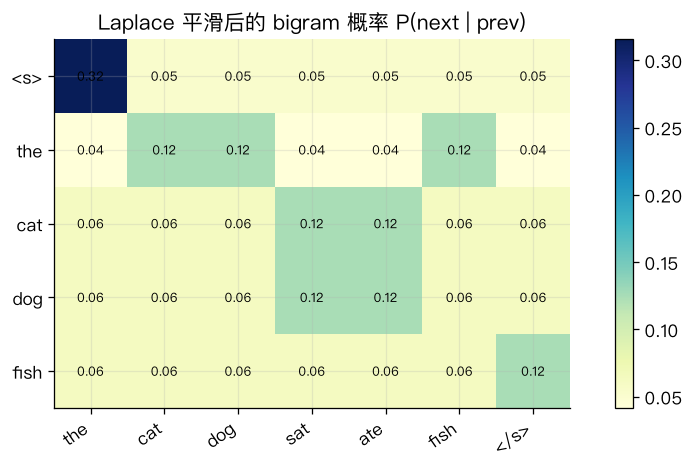

In [16]:
# ------------------------------------------------------------
# Step 4. 无平滑 vs Laplace（加一）平滑 对比
# ------------------------------------------------------------
# Laplace / Add-one Smoothing 的公式:
#   P_lap(w_i | w_{i-1}) = ( count(w_{i-1}, w_i) + 1 ) / ( count(w_{i-1}) + V )
# 直觉: 想象我们"预先"给每一对 (prev, next) 都送了 1 次。
# 分母加 V 是为了让 P(* | prev) 加起来仍然等于 1。


def p_bigram_laplace(prev, word):
    return (bigrams[(prev, word)] + 1) / (unigrams[prev] + V)


print("无平滑 vs Laplace 平滑对比:\n")
print(f"{'bigram':<20} {'count':>6} {'MLE':>10} {'Laplace':>10}")
demo_pairs = [("the", "cat"), ("the", "dog"), ("cat", "sat"),
              ("cat", "ate"), ("cat", "fish"), ("dog", "swam")]
for prev, word in demo_pairs:
    c = bigrams[(prev, word)]
    mle = p_bigram(prev, word)
    lap = p_bigram_laplace(prev, word)
    print(f"P({word!r:<6}|{prev!r:<5})  {c:>6}  {mle:>10.3f}  {lap:>10.3f}")

print("\n手算 Laplace 修好了什么：")
c_cat_fish = bigrams[("cat", "fish")]
c_cat = unigrams["cat"]
print(f"  count('cat', 'fish') = {c_cat_fish}, count('cat') = {c_cat}, V = {V}")
print(f"  MLE     = {c_cat_fish}/{c_cat} = {c_cat_fish / c_cat:.3f}   <- 0，会把整句拉成 0")
print(f"  Laplace = ({c_cat_fish}+1)/({c_cat}+{V}) = {(c_cat_fish + 1) / (c_cat + V):.3f}  <- 小但不是 0")

selected_prev = ["<s>", "the", "cat", "dog", "fish"]
selected_next = ["the", "cat", "dog", "sat", "ate", "fish", "</s>"]
prob_heat = np.array([[p_bigram_laplace(prev, w) for w in selected_next]
                      for prev in selected_prev])

fig, ax = plt.subplots(figsize=(8.5, 4.2))
im = ax.imshow(prob_heat, cmap="YlGnBu")
ax.set_xticks(range(len(selected_next)))
ax.set_xticklabels(selected_next, rotation=35, ha="right")
ax.set_yticks(range(len(selected_prev)))
ax.set_yticklabels(selected_prev)
ax.set_title("Laplace 平滑后的 bigram 概率 P(next | prev)")
for i in range(prob_heat.shape[0]):
    for j in range(prob_heat.shape[1]):
        ax.text(j, i, f"{prob_heat[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.035)
plt.tight_layout()
plt.show()

### Step 4.5 · Kneser-Ney 平滑（Absolute Discounting + Continuation Probability）

Laplace 平滑给"没见过的组合"塞概率的方式太粗暴——**它把所有 unseen bigram 一视同仁**。可现实里 `York` 比 `swim` 罕见得多：`York` 几乎只出现在 `New York` 里，一旦离开这个上下文就基本不该被预测；反过来，`the` 后面接 `swim` 是没见过，但 `swim` 本身在其他上下文里很活跃，遇到没见过的前缀它仍然是合理候选。

**Kneser-Ney（KN）平滑** 是 N-gram 时代最广泛使用的平滑方法，直到被神经语言模型全面接管之前一直是 SOTA。它的两条核心直觉是：

1. **Absolute Discounting（绝对折扣）**：给每一个 seen bigram 的计数**减去一个常数 $d$**（通常 $d \in [0.5, 0.75]$），把这些"匀出来"的概率质量重新分给 unseen bigram。这样比 Laplace 的 `+1` 更贴近真实的 Good-Turing 折扣估计，同时又便于实现。

   $$P_{\text{KN}}(w_i \mid w_{i-1}) = \dfrac{\max\!\bigl(\text{count}(w_{i-1}, w_i) - d,\; 0\bigr)}{\text{count}(w_{i-1})} + \lambda(w_{i-1}) \cdot P_{\text{cont}}(w_i)$$

   其中 $\lambda(w_{i-1}) = \dfrac{d}{\text{count}(w_{i-1})} \cdot N_{1+}(w_{i-1}, \bullet)$，$N_{1+}(w_{i-1}, \bullet)$ 是"$w_{i-1}$ 后面出现过的不同词的个数"。$\lambda$ 保证概率归一。

2. **Continuation Probability（延续概率）**：低阶回退不再用普通的 unigram $P(w) \propto \text{count}(w)$，而是**看这个词能作为多少种不同前缀的"延续"**：

   $$P_{\text{cont}}(w) = \dfrac{\bigl|\{v : \text{count}(v, w) > 0\}\bigr|}{\sum_{w'} \bigl|\{v : \text{count}(v, w') > 0\}\bigr|}$$

   直观上说：**一个词能不能当"延续"，看它跟多少种不同前缀共现，而不是看它自己的总频次。** 这样 `York` 尽管总频次不低，但只跟 `New` 共现，$P_{\text{cont}}(\text{York})$ 就会被压得很低；`swim` 尽管低频，只要跟多种前缀共现过，就会被 KN 视为"合理候选"。

这两条合起来解决了 Laplace 的两个致命问题：unseen bigram 不再被 uniform 地分配，而是"倾向于回退到那些**能当延续**的词"；见过的高频 bigram 也不会被 `+1` 稀释得太多。

下面在同一份 toy 语料上跑一个最小可复现的 KN bigram：

In [17]:
# ------------------------------------------------------------
# Step 4.5. Kneser-Ney 平滑最小可跑实现 (bigram 版本)
# ------------------------------------------------------------
# 参考: Chen & Goodman (1999) "An empirical study of smoothing techniques
# for language modeling"; Jurafsky & Martin SLP3 Chapter 3.
#
# 对每个 seen bigram (prev, word):
#   P_KN(word | prev)
#     = max(count(prev, word) - d, 0) / count(prev)
#       + lambda(prev) * P_cont(word)
# 其中:
#   d           : absolute discount, 这里取 0.75 (Chen & Goodman 推荐值)
#   lambda(prev)= d / count(prev) * N1+(prev, *)
#                 (N1+(prev, *) = prev 后面出现过的不同 word 数)
#   P_cont(w)   = |{v: count(v, w) > 0}| / sum_w' |{v: count(v, w') > 0}|
#                 -> "w 作为延续的多样性"
d_kn = 0.75  # absolute discount

# N1+(prev, *) : prev 后面出现过多少种不同的 word
prev_to_nexts = defaultdict(set)
for (prev, word) in bigrams:
    prev_to_nexts[prev].add(word)
n1_plus_prev = {prev: len(nexts) for prev, nexts in prev_to_nexts.items()}

# N1+(*, w) : 有多少种不同的 prev 出现在 w 之前 (continuation count)
word_to_prevs = defaultdict(set)
for (prev, word) in bigrams:
    word_to_prevs[word].add(prev)
n1_plus_word = {word: len(prevs) for word, prevs in word_to_prevs.items()}
denom_cont = sum(n1_plus_word.values())  # 归一化分母


def p_continuation(word):
    # 分子 0 时也返回 0；实际使用中通常再叠一层 (V+eps) 的兜底
    return n1_plus_word.get(word, 0) / denom_cont if denom_cont else 0.0


def p_bigram_kn(prev, word):
    c_prev = unigrams[prev]
    if c_prev == 0:
        return p_continuation(word)
    c_pair = bigrams[(prev, word)]
    first_term = max(c_pair - d_kn, 0) / c_prev
    lam = (d_kn / c_prev) * n1_plus_prev.get(prev, 0)
    return first_term + lam * p_continuation(word)


print("对比 MLE / Add-one / Kneser-Ney 三种概率估计:\n")
print(f"{'bigram':<22} {'count':>6} {'MLE':>10} {'Add-1':>10} {'KN':>10}")
kn_pairs = [
    ("the", "cat"),   # 见过, count>=2
    ("the", "dog"),   # 见过
    ("cat", "sat"),   # 见过 1 次 (稀有)
    ("cat", "fish"),  # 没见过 -> KN 靠 P_cont(fish)
    ("cat", "bone"),  # 没见过 -> KN 靠 P_cont(bone)
    ("dog", "swam"),  # 没见过
]
for prev, word in kn_pairs:
    c = bigrams[(prev, word)]
    mle = p_bigram(prev, word)
    lap = p_bigram_laplace(prev, word)
    kn = p_bigram_kn(prev, word)
    print(f"P({word!r:<6}|{prev!r:<5})   {c:>6}  {mle:>10.3f}  {lap:>10.3f}  {kn:>10.3f}")

print("\n手动验证归一化 (每一行的 KN 概率对所有可预测词求和应≈1):")
for prev in ["the", "cat", "dog"]:
    total = sum(p_bigram_kn(prev, w) for w in prediction_vocab)
    print(f"  Σ_w P_KN(w | {prev!r}) = {total:.4f}")

print("\n观察 P_continuation vs 频次 unigram:")
uni_total = sum(unigrams[w] for w in prediction_vocab)
for w in ["the", "cat", "fish", "bone", "swam"]:
    p_uni = unigrams[w] / uni_total
    p_cont = p_continuation(w)
    print(f"  word={w!r:<6}  freq-based P={p_uni:.3f}   P_continuation={p_cont:.3f}")
print("  -> P_continuation 让'只跟少数前缀共现的词'被自动压低，")
print("     让'跟多种前缀共现'的词在 unseen bigram 里被优先回退。")

对比 MLE / Add-one / Kneser-Ney 三种概率估计:

bigram                  count        MLE      Add-1         KN
P('cat' |'the')        2       0.200       0.125       0.148
P('dog' |'the')        2       0.200       0.125       0.148
P('sat' |'cat')        1       0.500       0.125       0.190
P('fish'|'cat')        0       0.000       0.062       0.033
P('bone'|'cat')        0       0.000       0.062       0.033
P('swam'|'dog')        0       0.000       0.062       0.033

手动验证归一化 (每一行的 KN 概率对所有可预测词求和应≈1):
  Σ_w P_KN(w | 'the') = 1.0000
  Σ_w P_KN(w | 'cat') = 1.0000
  Σ_w P_KN(w | 'dog') = 1.0000

观察 P_continuation vs 频次 unigram:
  word='the'   freq-based P=0.303   P_continuation=0.174
  word='cat'   freq-based P=0.061   P_continuation=0.043
  word='fish'  freq-based P=0.061   P_continuation=0.043
  word='bone'  freq-based P=0.030   P_continuation=0.043
  word='swam'  freq-based P=0.030   P_continuation=0.043
  -> P_continuation 让'只跟少数前缀共现的词'被自动压低，
     让'跟多种前缀共现'的词在 unseen bigram 里被优先回退。


In [18]:
# ------------------------------------------------------------
# Step 5. 计算整句 log 概率 与 困惑度 (Perplexity, PPL)
# ------------------------------------------------------------
# 一句话的概率 = 一串 bigram 条件概率的乘积。
# 很多小于 1 的数相乘会下溢，所以工程上加 log 再累加。
#
# 困惑度 (perplexity):
#   PPL = exp( - (1/N) * Σ log P(w_i | w_{i-1}) )
# 直觉:
#   - PPL = 语言模型"平均在多少个候选之间纠结"。
#   - PPL 越小，模型越自信、越"不困惑"。
#   - 如果模型认为下一个词是"从 V 个词里均匀抽一个"，PPL 就正好等于 V。


def sentence_logprob(sent, smoothed=True):
    toks = ["<s>"] + tokenize(sent) + ["</s>"]
    unknown = sorted({tok for tok in toks if tok not in vocab})
    if unknown:
        raise ValueError(f"OOV tokens 需要先做 <unk> 处理: {unknown}")
    logp = 0.0
    details = []
    for prev, word in zip(toks[:-1], toks[1:]):
        p = p_bigram_laplace(prev, word) if smoothed else p_bigram(prev, word)
        details.append((prev, word, p))
        if p == 0:
            return -math.inf, details
        logp += math.log(p)
    return logp, details


test_sentences = [
    "the cat sat on the mat",   # 训练集里几乎原样出现过，应打高分
    "the cat ate the bone",     # 训练集里没原样出现，但每个 bigram 都见过
    "the fish ate the bone",    # 更冷门的组合
]

for sent in test_sentences:
    logp, detail = sentence_logprob(sent, smoothed=True)
    n_steps = len(detail)
    ppl = math.exp(-logp / n_steps)
    print(f"sentence: {sent}")
    print(f"  log P(句子) = {logp:.3f}")
    print(f"  perplexity  = exp(-({logp:.3f}) / {n_steps}) = {ppl:.2f}")
    print("  每一步:")
    for prev, word, prob in detail:
        print(f"    P({word!r:<6}|{prev!r:<5}) = {prob:.3f}   log = {math.log(prob):+.3f}")
    print()

print("对比无平滑版本 (可能直接 -inf):")
for sent in ["the fish ate the bone"]:
    logp_mle, _ = sentence_logprob(sent, smoothed=False)
    print(f"  MLE log P('{sent}') = {logp_mle}")

sentence: the cat sat on the mat
  log P(句子) = -13.159
  perplexity  = exp(-(-13.159) / 7) = 6.55
  每一步:
    P('the' |'<s>') = 0.316   log = -1.153
    P('cat' |'the') = 0.125   log = -2.079
    P('sat' |'cat') = 0.125   log = -2.079
    P('on'  |'sat') = 0.188   log = -1.674
    P('the' |'on' ) = 0.188   log = -1.674
    P('mat' |'the') = 0.083   log = -2.485
    P('</s>'|'mat') = 0.133   log = -2.015

sentence: the cat ate the bone
  log P(句子) = -11.485
  perplexity  = exp(-(-11.485) / 6) = 6.78
  每一步:
    P('the' |'<s>') = 0.316   log = -1.153
    P('cat' |'the') = 0.125   log = -2.079
    P('ate' |'cat') = 0.125   log = -2.079
    P('the' |'ate') = 0.188   log = -1.674
    P('bone'|'the') = 0.083   log = -2.485
    P('</s>'|'bone') = 0.133   log = -2.015

sentence: the fish ate the bone
  log P(句子) = -12.178
  perplexity  = exp(-(-12.178) / 6) = 7.61
  每一步:
    P('the' |'<s>') = 0.316   log = -1.153
    P('fish'|'the') = 0.125   log = -2.079
    P('ate' |'fish') = 0.062   log = -2.

### Step 5.5 · `<unk>` 处理：让 OOV 也拿到非零概率

上面的 `sentence_logprob` 遇到词表里没有的 token 会直接抛错。这在教学里可以逼读者面对 OOV，但工程上完全不能用——真实语料几乎每次评估都会遇到没见过的词。

**工业界最常见的一种做法**（NLTK、SRILM、KenLM、Kneser-Ney 训练前预处理等都在用）：

1. **训练阶段**：把训练集中**只出现 1 次**的词（hapax legomena）统一替换为特殊 token `<unk>`。这样 `<unk>` 就有了非零频次，模型自动学到一个"未知词"的分布。
2. **评估阶段**：遇到词表里不存在的词，就把它映射成 `<unk>`。任何 OOV 都能落到一个见过的 token 上，也就有了非零概率。

替代方案还有 Byte-Pair Encoding、character-level backoff 等；但"count==1 -> `<unk>`"是最经典、代价最小、最容易解释的一档。

训练语料里只出现 1 次的词 (会被替换为 <unk>): ['bone', 'in', 'mat', 'pond', 'rug', 'swam']
新词表 |V| (含 <s>/</s>/<unk>) = 10   (可预测 V = 9)

同一句在不同 order 下的 PPL 对比 (all with add-one smoothing + <unk>):

sentence                                   unigram PPL    bigram PPL   trigram PPL
the cat sat on the mat                            8.67          3.85          4.55
the cat ate the bone                              7.86          3.88          5.05
the dog chased a rabbit                           7.36          5.49          8.64


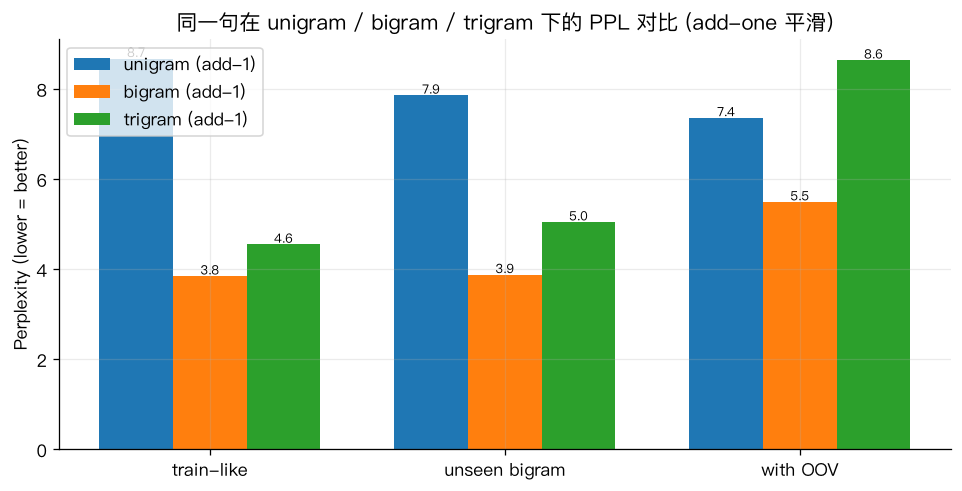


观察:
 - 训练里出现过的句子 (train-like): bigram/trigram PPL 明显低于 unigram，
   因为局部条件概率能真正抓到搭配。
 - 一旦出现从未见过的三元组 (unseen bigram / with OOV) —— trigram 表面看似仍低，
   但绝大多数条件概率其实退化成了 add-one 的 '1 / (count + V)' 兜底项：
   概率被稀疏问题主导，而不是被真实语言规律主导。
 - 这就是 N-gram 的核心矛盾：N 越大，理论上下文越多，但稀疏让高阶 N-gram 大量退化到平滑基线。


In [19]:
# ------------------------------------------------------------
# Step 5.5. <unk> 处理 + unigram/bigram/trigram PPL 对比实验
# ------------------------------------------------------------
# 第一步: 重新构造带 <unk> 的训练语料
#   规则: 训练时把在整个语料中只出现一次的 non-tag token 换成 <unk>；
#         <s>/</s> 保持不变。这样 <unk> 就成为一个"见过"的 token。
_raw_counter = Counter()
for sent in sentences:
    _raw_counter.update(sent)
hapax_vocab = {w for w, c in _raw_counter.items() if c == 1 and w not in {"<s>", "</s>"}}
print(f"训练语料里只出现 1 次的词 (会被替换为 <unk>): {sorted(hapax_vocab)}")


def _to_unk(tokens):
    return [t if t not in hapax_vocab else "<unk>" for t in tokens]


unk_sentences = [_to_unk(sent) for sent in sentences]

# 重新数 unigram / bigram / trigram
unigrams_u = Counter()
bigrams_u = Counter()
trigrams_u = Counter()
for sent in unk_sentences:
    unigrams_u.update(sent)
    bigrams_u.update(zip(sent[:-1], sent[1:]))
    trigrams_u.update(zip(sent[:-2], sent[1:-1], sent[2:]))

vocab_u = set(unigrams_u)  # 含 <s>, </s>, <unk>
pred_vocab_u = sorted(vocab_u - {"<s>"})
V_u = len(pred_vocab_u)
print(f"新词表 |V| (含 <s>/</s>/<unk>) = {len(vocab_u)}   (可预测 V = {V_u})")


def to_train_tokens(sent):
    # 把原句 token 化，然后把 hapax 或没见过的都映射到 <unk>
    toks = ["<s>"] + tokenize(sent) + ["</s>"]
    return [t if t in vocab_u else "<unk>" for t in toks]


# 用 add-one 的 n-gram 概率，避免出现 0 概率把 log 打爆
def p_uni_add1(word):
    N = sum(unigrams_u.values())
    return (unigrams_u[word] + 1) / (N + V_u)


def p_bi_add1(prev, word):
    return (bigrams_u[(prev, word)] + 1) / (unigrams_u[prev] + V_u)


def p_tri_add1(w1, w2, w3):
    return (trigrams_u[(w1, w2, w3)] + 1) / (bigrams_u[(w1, w2)] + V_u)


def sentence_logprob_unk(sent, order):
    # order = 1 (unigram) / 2 (bigram) / 3 (trigram)
    toks = to_train_tokens(sent)
    logp, n_steps = 0.0, 0
    if order == 1:
        for w in toks[1:]:  # 不去预测 <s>
            logp += math.log(p_uni_add1(w))
            n_steps += 1
    elif order == 2:
        for prev, w in zip(toks[:-1], toks[1:]):
            logp += math.log(p_bi_add1(prev, w))
            n_steps += 1
    elif order == 3:
        # trigram 需要一个额外的起始 <s>，让第一个真实词也有 2 个前缀
        toks = ["<s>"] + toks
        for w1, w2, w3 in zip(toks[:-2], toks[1:-1], toks[2:]):
            logp += math.log(p_tri_add1(w1, w2, w3))
            n_steps += 1
    else:
        raise ValueError("order must be 1/2/3")
    return logp, n_steps


# 找几句同时含 OOV 的测试例（'a' / 'chased' / 'rabbit' 都是训练里没有的词）
eval_sentences = [
    "the cat sat on the mat",       # 完全在训练集里
    "the cat ate the bone",         # bigram 都见过
    "the dog chased a rabbit",      # 含大量 OOV: chased / a / rabbit
]

rows = []
print("\n同一句在不同 order 下的 PPL 对比 (all with add-one smoothing + <unk>):\n")
print(f"{'sentence':<40}{'unigram PPL':>14}{'bigram PPL':>14}{'trigram PPL':>14}")
for s in eval_sentences:
    ppls = []
    for order in (1, 2, 3):
        logp, n = sentence_logprob_unk(s, order)
        ppls.append(math.exp(-logp / n))
    print(f"{s:<40}{ppls[0]:>14.2f}{ppls[1]:>14.2f}{ppls[2]:>14.2f}")
    rows.append((s, ppls))

# ------------------- 画柱状图 -------------------
labels_short = ["train-like", "unseen bigram", "with OOV"]
unigram_ppls = [r[1][0] for r in rows]
bigram_ppls = [r[1][1] for r in rows]
trigram_ppls = [r[1][2] for r in rows]

x = np.arange(len(labels_short))
width = 0.25
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.bar(x - width, unigram_ppls, width, label="unigram (add-1)")
ax.bar(x,         bigram_ppls,  width, label="bigram (add-1)")
ax.bar(x + width, trigram_ppls, width, label="trigram (add-1)")
ax.set_xticks(x)
ax.set_xticklabels(labels_short)
ax.set_ylabel("Perplexity (lower = better)")
ax.set_title("同一句在 unigram / bigram / trigram 下的 PPL 对比 (add-one 平滑)")
for xi, vals in zip(x, zip(unigram_ppls, bigram_ppls, trigram_ppls)):
    for dx, v in zip((-width, 0, width), vals):
        ax.text(xi + dx, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

print("\n观察:")
print(" - 训练里出现过的句子 (train-like): bigram/trigram PPL 明显低于 unigram，")
print("   因为局部条件概率能真正抓到搭配。")
print(" - 一旦出现从未见过的三元组 (unseen bigram / with OOV) —— trigram 表面看似仍低，")
print("   但绝大多数条件概率其实退化成了 add-one 的 '1 / (count + V)' 兜底项：")
print("   概率被稀疏问题主导，而不是被真实语言规律主导。")
print(" - 这就是 N-gram 的核心矛盾：N 越大，理论上下文越多，但稀疏让高阶 N-gram 大量退化到平滑基线。")

In [20]:
# ------------------------------------------------------------
# Step 6. 用 bigram 概率"采样"生成一句话
# ------------------------------------------------------------
# 生成的流程:
#   1) 从 <s> 出发
#   2) 根据 P(next | prev) 的概率分布，加权随机抽一个 next
#   3) prev <- next，重复直到抽到 </s> 或长度超限
# 这里用 Laplace 平滑后的概率，保证任何 prev 后面都有词可以抽。
rng_lm = np.random.default_rng(SEED)


def sample_next(prev, candidates):
    probs = np.array([p_bigram_laplace(prev, w) for w in candidates])
    probs = probs / probs.sum()
    return rng_lm.choice(candidates, p=probs)


def generate_sentence(max_len=12):
    prev = "<s>"
    out = []
    for _ in range(max_len):
        nxt = sample_next(prev, prediction_vocab)
        if nxt == "</s>":
            break
        out.append(nxt)
        prev = nxt
    return out


print("从 bigram 语言模型里采样几句话:\n")
for _ in range(6):
    print("  ", " ".join(generate_sentence()))

print("\n观察:")
print(" - 因为只看前 1 个词，生成结果的局部搭配 (the cat / on the) 看起来自然，")
print("   但整句常常没有清晰的语义 —— 这就是短上下文 + 稀疏统计的直接后果。")
print(" - 换成 trigram 会更连贯，但需要的样本量也大得多，稀疏问题会更严重。")

从 bigram 语言模型里采样几句话:

   the fish swam pond
   the pond rug
   on fish swam on the fish bone mat
   the mat rug dog the sat rug ate mat
   bone pond rug the dog dog in bone
   pond bone pond fish swam pond cat sat rug dog cat pond

观察:
 - 因为只看前 1 个词，生成结果的局部搭配 (the cat / on the) 看起来自然，
   但整句常常没有清晰的语义 —— 这就是短上下文 + 稀疏统计的直接后果。
 - 换成 trigram 会更连贯，但需要的样本量也大得多，稀疏问题会更严重。


### 短板：为什么 N-gram 还不够

| 短板 | 具体表现 |
|------|----------|
| **数据稀疏（data sparsity）** | 词表越大、N 越大，`|V|^N` 组合里绝大多数在语料里都没出现过；即使 Laplace 平滑也只是"给每格洒一点点概率"，并没真正学到语义。 |
| **长距离依赖抓不到** | Bigram 只看前 1 个词。像 `The book that I bought yesterday is …`，`is` 依赖的是很远的 `book`，N-gram 完全看不到。 |
| **同义词无法泛化** | 语料里见过 `doctor treated patient`，但没见过 `physician treated patient`，模型完全不知道两者相近，`physician` 就被当成陌生词。 |
| **词表爆炸 & 参数量爆炸** | Trigram 就有 $|V|^3$ 个可能三元组，10 万词表 → $10^{15}$ 组合，绝大多数是零频。 |
| **OOV（未登录词）棘手** | 训练集里没见过的词直接没条件概率，只能靠 `<unk>` 兜底，损失信息。 |

### 和 Word2Vec 的关系

N-gram 把 `the cat` 和 `the dog` 当成**两个完全独立的离散事件**。语料里见过一万次 `the cat sat`，也帮不了从没见过的 `the dog sat` 一点点忙——模型不知道 `cat` 和 `dog` 都是动物、都能出现在类似的位置。

这就是"**能不能让语义相似的词共享统计强度**"这个问题的由来。**如果每个词都对应一个稠密向量，语义相近的词向量相近，那么见过 `the cat sat` 就等于同时"顺便学到了一点" `the dog sat`。** 这条思路一路演化下去，就到了：

- **共现矩阵 / PMI / SVD**（第 8 章）：先把"谁跟谁共现"记下来，再压缩成低维向量。
- **早期神经语言模型 NNLM**（第 9 章）：让语言模型的输入是词向量，参数在相似词之间共享。
- **Word2Vec**（第 10 章）：把 NNLM 中"学词向量"这一步单拎出来，用极高效的训练技巧规模化。

所以 N-gram 不是被 Word2Vec 直接替代的——它是**提出问题的那一步**：只要还把词当成离散 ID，稀疏性和泛化就永远打不通。

## 4 · One-hot（独热编码）、Bag of Words（词袋）与 TF-IDF（词频-逆文档频率）

### 一句话直觉

前一章的 N-gram 想预测"下一个词"，但很多任务问的是另一种问题：**这一整篇文档在说什么？它属于哪一类？和哪篇文档更像？**

要回答这些问题，就得先把整篇文档变成一个**数字向量**——这样才能塞进任何一个数学模型里。

打个比方，把每篇文档想象成一个**购物袋**：

```text
文档 1: "the team won the football match"
文档 2: "the doctor treated the patient"
```

如果我们只关心"袋子里各有什么、每样多少个"，而不关心它们的先后顺序，那么"袋子"就是一张**词频清单**。这一章讨论的三种表示，就是三种越来越聪明的"清单法"：

1. **One-hot（独热编码）**：先把词表铺开成一排格子，一个词就点亮它自己那一格。
2. **Bag of Words, BoW（词袋）**：一篇文档 = 每个格子里放的"次数"。
3. **TF-IDF（词频-逆文档频率）**：给每个次数配一个"区分度权重"，让 `the` 这种到处都有的词自动降权，让 `vaccine` `algorithm` 这种真正代表主题的词升权。

### 关键中英文对照

| 英文 / 缩写 | 中文名 | 一句话说明 |
|-------------|--------|------------|
| One-hot Encoding | 独热编码 | 每个词对应词表里唯一一位为 1、其他位全为 0 的向量 |
| Vocabulary (V) | 词表 | 语料里所有不同词的集合，向量的长度就是 \|V\| |
| Bag of Words, BoW | 词袋模型 | 忽略词序，只统计每个词出现次数的文档表示 |
| Term Frequency, TF | 词频 | 某个词在**当前文档**里出现的次数（或它的归一化/log 变体） |
| Document Frequency, DF | 文档频率 | 包含某个词的**文档**数目（不是总出现次数） |
| Inverse Document Frequency, IDF | 逆文档频率 | 越少文档出现的词越"有信息量"的权重 |
| TF-IDF | 词频-逆文档频率 | TF × IDF，稀疏文本表示的经典加权公式 |
| Stop Words | 停用词 | `the / of / a` 等到处都出现、信息量低的词 |
| Sparse Vector | 稀疏向量 | 绝大多数分量都是 0 的向量（BoW/TF-IDF 天然稀疏） |
| Dense Vector | 稠密向量 | 每个分量都是有意义实数的向量（Word2Vec 的目标） |
| Cosine Similarity | 余弦相似度 | $\cos\theta = \dfrac{u \cdot v}{\|u\|\,\|v\|}$，只看方向、不看长度 |
| Document-Term Matrix | 文档-词矩阵 | 行是文档、列是词、格子里是次数或权重的矩阵 |
| OOV (Out-of-Vocabulary) | 未登录词 | 训练词表里没有见过的词，BoW 会直接丢掉 |

### 术语速查：三种表示到底在干什么

| 表示 | 一句话定义 | 一个 3 词句子 `"doctor patient patient"` 会变成什么？ |
|------|-----------|---------------------------------------------------------|
| One-hot | 每个词单独一个向量，长度 = \|V\| | `doctor -> [1,0,0,0,0]`；`patient -> [0,1,0,0,0]` |
| BoW（词袋） | 把整篇文档的 one-hot **相加** | `doctor(1) + patient(1) + patient(1) = [1,2,0,0,0]` |
| TF-IDF | 把 BoW 的每一格再乘一个"区分度权重" IDF | `[1·idf₁, 2·idf₂, 0, 0, 0]`，然后 L2 归一化 |

BoW 就是"把每个词的 one-hot 加起来"这么朴素的一件事——理解了这一点，后面的公式都只是它的加权改良版。

### 核心公式（一步步长出来）

**Step 1. One-hot（独热编码）**

设词表 $V = \{w_1, w_2, \dots, w_{|V|}\}$，则词 $w_i$ 的 one-hot 向量是长度 $|V|$、第 $i$ 位为 1、其余为 0 的向量。

**Step 2. BoW（词袋）**

对文档 $d = (t_1, t_2, \dots, t_L)$（$t_j$ 表示第 $j$ 个 token），它的 BoW 向量就是所有 token 的 one-hot 之和：

$$\text{BoW}(d) = \sum_{j=1}^{L} \text{one\_hot}(t_j)$$

第 $i$ 位的值 = 词 $w_i$ 在文档 $d$ 里出现的次数，记作 $\text{tf}(w_i, d)$。

**Step 3. TF-IDF（词频-逆文档频率）**

TF-IDF 只做一件事：给 BoW 的每个格子乘一个"这词稀不稀有"的权重。

- **TF（词频）**：一般直接就取次数 $\text{tf}(w, d)$（也可以取 $1+\log \text{tf}$ 等变体）。
- **DF（文档频率）**：语料里有多少篇文档**至少出现过一次** $w$。注意：是"文档数"，不是"总出现次数"。
- **IDF（逆文档频率）**：文档越少见的词，IDF 越大。sklearn 默认使用**平滑 IDF**：

$$\text{idf}(w) = \ln\!\left(\dfrac{1 + N}{1 + \text{df}(w)}\right) + 1$$

其中 $N$ 是语料文档总数。分子分母同时 +1、末尾再 +1，是为了让"每篇都出现"的词也不会拿到 0，避免整列被清零。

- **为什么 IDF 要取 log？**背后有两个具体动机，值得单独讲清楚：

  1. **稀有度带来的信息收益是次线性的。**一个词从"在 1000 篇里出现"降到"只在 100 篇里出现"，比它从 10 篇降到 1 篇提供的辨别力更大——毕竟能圈到 100 篇里出现的词，主题就已经很聚焦了。log 把这种"越稀有、边际收益递减"的直觉直接写进了公式：$\log(1000/100)$ 和 $\log(10/1)$ 数量级相当，而不是像 $1000/100 = 10$、$10/1 = 10$ 那样对稀有度的差异毫无区分。
  2. **TF-IDF 是相乘结构，log 把乘性尺度转成加性尺度。**若不取 log，$N/\text{df}$ 会横跨几个数量级（从 1 到几万），乘上 tf 之后不同维度的权重会失控；取 log 之后 idf 变成一个温和的加性权重，便于叠加、便于设阈值，也便于线性模型（LR、线性 SVM）稳定训练——这就是为什么工业界几乎都在 log 空间里做稀疏文本表示。

  顺带一提：同一条思路还催生了 `sublinear_tf`——把 tf 也换成 $1 + \log \text{tf}$。它想解决的问题是"**一个词在同一篇里出现 100 次，并不代表它比出现 10 次重要 10 倍**"，log 让 tf 也遵循边际收益递减。sklearn 里打开 `sublinear_tf=True` 就能启用；Step 4 末尾会做一个具体数字对照，看清楚它把高频词的权重压到什么程度。

- **TF-IDF**：

$$\text{tfidf}(w, d) = \text{tf}(w, d) \cdot \text{idf}(w)$$

- **L2 归一化**：sklearn 默认还会把每篇文档的向量除以自己的 L2 范数（欧几里得长度），让文档长度不影响相似度比较：

$$v_{\text{norm}} = \dfrac{v}{\|v\|_2}, \quad \|v\|_2 = \sqrt{\sum_i v_i^2}$$

后面的 Step 3 手算例会一个数字一个数字对着这些公式走一遍，看清楚 sklearn 里的每一步。

In [21]:
# ------------------------------------------------------------
# Step 1. One-hot（独热编码）：用一个 5 词的迷你词表演示
# ------------------------------------------------------------
mini_vocab = ["doctor", "patient", "bank", "loan", "algorithm"]
mini_index = {word: i for i, word in enumerate(mini_vocab)}


def one_hot(word):
    # 造一个长度 = |V| 的全零向量，只把 word 对应位置点亮为 1。
    vec = np.zeros(len(mini_vocab), dtype=int)
    vec[mini_index[word]] = 1
    return vec


print("mini_vocab = ", mini_vocab)
for w in mini_vocab:
    print(f"  one_hot({w!r}) = {one_hot(w).tolist()}")

print("\n观察：")
print(" - 词表 5 个词 -> 每个向量长度都是 5")
print(" - 只有 1 位是 1，其他都是 0 -> 天然稀疏（Sparse Vector）")
print(" - 任意两个不同词的向量点积都是 0 -> one-hot 里 doctor 和 patient 完全'无关'")
print(" - 这就是 one-hot 的核心短板：向量之间没有'相近'的概念")

mini_vocab =  ['doctor', 'patient', 'bank', 'loan', 'algorithm']
  one_hot('doctor') = [1, 0, 0, 0, 0]
  one_hot('patient') = [0, 1, 0, 0, 0]
  one_hot('bank') = [0, 0, 1, 0, 0]
  one_hot('loan') = [0, 0, 0, 1, 0]
  one_hot('algorithm') = [0, 0, 0, 0, 1]

观察：
 - 词表 5 个词 -> 每个向量长度都是 5
 - 只有 1 位是 1，其他都是 0 -> 天然稀疏（Sparse Vector）
 - 任意两个不同词的向量点积都是 0 -> one-hot 里 doctor 和 patient 完全'无关'
 - 这就是 one-hot 的核心短板：向量之间没有'相近'的概念


In [22]:
# ------------------------------------------------------------
# Step 2. BoW（词袋）：把一篇文档变成"次数向量"
# ------------------------------------------------------------
# BoW 的实现就是"把这句里每个词的 one-hot 累加起来"：一行代码即可。
mini_sentence = "doctor patient patient"
mini_tokens = tokenize(mini_sentence)
mini_bow = np.zeros(len(mini_vocab), dtype=int)
for tok in mini_tokens:
    mini_bow += one_hot(tok)

print(f"sentence  = {mini_sentence!r}")
print(f"tokens    = {mini_tokens}")
print(f"BoW vec   = {mini_bow.tolist()}  <- 第 i 位 = 词 mini_vocab[i] 出现的次数")
print("对应关系:")
for w, c in zip(mini_vocab, mini_bow):
    print(f"    {w:<10} -> count = {c}")

print("\n扩展到多篇文档，就是一张'文档-词矩阵 (Document-Term Matrix)':")
tiny_docs = ["doctor patient", "bank loan", "doctor loan"]
# BoW 就是把这句里每个词的 one-hot 相加：完全对应上面 "Σ one-hot" 的表述。
tiny_matrix = np.zeros((len(tiny_docs), len(mini_vocab)), dtype=int)
for i, doc in enumerate(tiny_docs):
    for tok in tokenize(doc):
        tiny_matrix[i] += one_hot(tok)   # BoW = Σ one-hot(tok)
print(" " * 22 + " ".join(f"{w:>9}" for w in mini_vocab))
for doc, row in zip(tiny_docs, tiny_matrix):
    print(f"  {doc:<20} " + " ".join(f"{v:>9d}" for v in row))

print("\n特点:")
print(" - 忽略词序：'doctor patient' 和 'patient doctor' 得到同一个 BoW 向量")
print(" - 高维稀疏：真实语料 |V| 常常上万，绝大多数格子都是 0")
print(" - 支持累加：一整篇文档的 BoW = 所有 token 的 one-hot 之和")

sentence  = 'doctor patient patient'
tokens    = ['doctor', 'patient', 'patient']
BoW vec   = [1, 2, 0, 0, 0]  <- 第 i 位 = 词 mini_vocab[i] 出现的次数
对应关系:
    doctor     -> count = 1
    patient    -> count = 2
    bank       -> count = 0
    loan       -> count = 0
    algorithm  -> count = 0

扩展到多篇文档，就是一张'文档-词矩阵 (Document-Term Matrix)':
                         doctor   patient      bank      loan algorithm
  doctor patient               1         1         0         0         0
  bank loan                    0         0         1         1         0
  doctor loan                  1         0         0         1         0

特点:
 - 忽略词序：'doctor patient' 和 'patient doctor' 得到同一个 BoW 向量
 - 高维稀疏：真实语料 |V| 常常上万，绝大多数格子都是 0
 - 支持累加：一整篇文档的 BoW = 所有 token 的 one-hot 之和


文档数 N = 16
词表大小 |V| = 86
文档-词矩阵 shape = (16, 86)  (行=文档, 列=词)
矩阵中非零元素占比 = 8.72%   <- BoW 天然稀疏
数值直觉：如果真实词表 |V| = 50000，一份 200 词的文档，即使全部 token 互不重复，
其 BoW 向量里也只有至多 200 个非零位、剩下的 49800 位全是 0——稀疏率 ≈ 99.6%。
这就是 '稀疏向量 (Sparse Vector)' 这个词的字面含义。


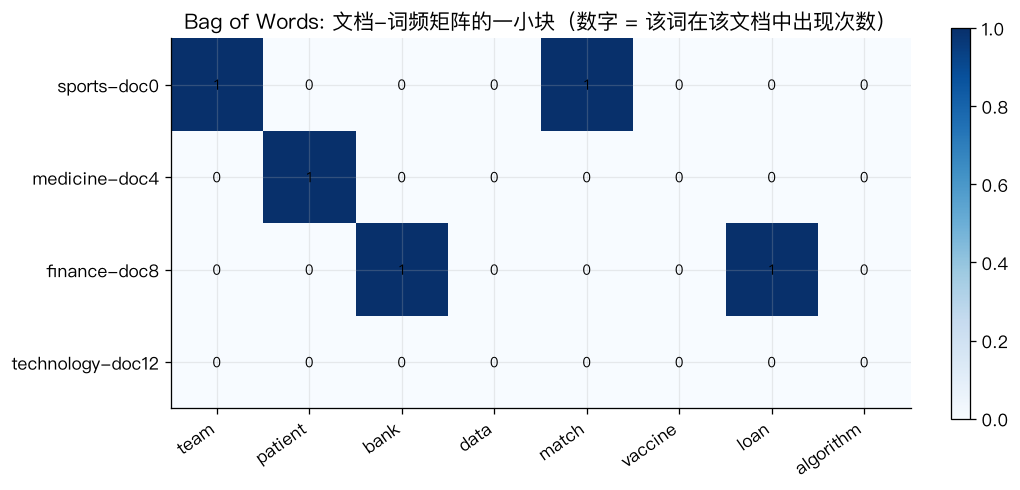


观察这张热力图:
 - sports 文档在 team/match 上亮；medicine 在 patient 上亮；
   finance 在 bank/loan 上亮；technology 在 data/algorithm 上亮。
 - 词的'次数'确实携带了主题信息，但 the/a/of 之类的通用词也会有很高次数，
   它们会污染相似度比较 -> 这就是 TF-IDF 想解决的问题。


In [23]:
# ------------------------------------------------------------
# 用 sklearn 的 CountVectorizer 在真实 docs 上算 BoW
# ------------------------------------------------------------
count_vec = CountVectorizer(token_pattern=r"[a-z]+")
X_count = count_vec.fit_transform(docs)
terms = np.array(count_vec.get_feature_names_out())

print(f"文档数 N = {len(docs)}")
print(f"词表大小 |V| = {len(terms)}")
print(f"文档-词矩阵 shape = {X_count.shape}  (行=文档, 列=词)")
print(f"矩阵中非零元素占比 = {X_count.nnz / (X_count.shape[0] * X_count.shape[1]):.2%}"
      "   <- BoW 天然稀疏")
print("数值直觉：如果真实词表 |V| = 50000，一份 200 词的文档，即使全部 token 互不重复，")
print("其 BoW 向量里也只有至多 200 个非零位、剩下的 49800 位全是 0——稀疏率 ≈ 99.6%。")
print("这就是 '稀疏向量 (Sparse Vector)' 这个词的字面含义。")

selected_terms = ["team", "patient", "bank", "data", "match", "vaccine", "loan", "algorithm"]
selected_idx = [np.where(terms == t)[0][0] for t in selected_terms if t in terms]
sample_doc_idx = [0, 4, 8, 12]

fig, ax = plt.subplots(figsize=(9, 4.4))
heat = X_count.toarray()[sample_doc_idx][:, selected_idx]
im = ax.imshow(heat, cmap="Blues")
ax.set_xticks(range(len(selected_idx)))
ax.set_xticklabels(terms[selected_idx], rotation=35, ha="right")
ax.set_yticks(range(len(sample_doc_idx)))
ax.set_yticklabels([f"{labels[i]}-doc{i}" for i in sample_doc_idx])
ax.set_title("Bag of Words: 文档-词频矩阵的一小块（数字 = 该词在该文档中出现次数）")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, str(heat[i, j]), ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

print("\n观察这张热力图:")
print(" - sports 文档在 team/match 上亮；medicine 在 patient 上亮；")
print("   finance 在 bank/loan 上亮；technology 在 data/algorithm 上亮。")
print(" - 词的'次数'确实携带了主题信息，但 the/a/of 之类的通用词也会有很高次数，")
print("   它们会污染相似度比较 -> 这就是 TF-IDF 想解决的问题。")

In [24]:
# ------------------------------------------------------------
# Step 3. TF-IDF 手算：对着公式一格一格算一遍
# ------------------------------------------------------------
doc_id = 4
print(f"target document (doc {doc_id}, label={labels[doc_id]}):")
print(f"  '{docs[doc_id]}'\n")

doc_tokens = tokenize(docs[doc_id])
doc_counts = Counter(doc_tokens)
N = len(docs)
print(f"文档总数 N = {N}")
print(f"tokenize 后的 doc {doc_id} = {doc_tokens}")
print(f"doc {doc_id} 里各词的次数 = {dict(doc_counts)}\n")

# 预构造 df_table: 一次性统计每个词的 document frequency（文档级去重）
# df 的定义是 "包含该词的文档数"，所以每篇文档只算 1 次 —— 用 set(tokenize(d)) 显式体现去重
all_terms = sorted(set(t for d in docs for t in tokenize(d)))
df_table = {t: sum(t in set(tokenize(d)) for d in docs) for t in all_terms}
print(f"预构造 df_table 完成：词表大小 |V| = {len(all_terms)}"
      f"（示例：df['the']={df_table.get('the', 0)}, df['patient']={df_table.get('patient', 0)}）\n")


def manual_tfidf_breakdown(term):
    tf = doc_counts.get(term, 0)
    df = df_table[term]  # 从预构造表里直接取，避免每次重复 tokenize 所有文档
    idf = math.log((1 + N) / (1 + df)) + 1
    raw = tf * idf
    return tf, df, idf, raw


# header 与 row 严格同宽：term<10 + tf>4 + df>4 + 第三列>30 + 第四列>10 = 58 列
header = f"{'term':<10}{'tf':>4}{'df':>4}{'ln((1+N)/(1+df))+1 = idf':>30}{'tf*idf':>10}"
print(header)
print("-" * len(header))
for term in ["the", "patient", "doctor", "hospital", "vaccine"]:
    tf, df, idf, raw = manual_tfidf_breakdown(term)
    print(f"{term:<10}{tf:>4}{df:>4}"
          f"{f'ln((1+{N})/(1+{df}))+1 = {idf:.4f}':>30}"
          f"{raw:>10.4f}")

print("\n仔细看 'the' 和 'patient' 的对比：")
tf_the, df_the, idf_the, raw_the = manual_tfidf_breakdown("the")
tf_pt,  df_pt,  idf_pt,  raw_pt  = manual_tfidf_breakdown("patient")
print(f"  the:     tf={tf_the}, df={df_the:>2}, idf={idf_the:.4f}, tf*idf={raw_the:.4f}")
print(f"  patient: tf={tf_pt}, df={df_pt:>2}, idf={idf_pt:.4f}, tf*idf={raw_pt:.4f}")
print("  -> 'the' 在很多篇都出现（df 大） -> idf 小 -> 权重被自动压低")
print("  -> 'patient' 只在 medicine 类少数文档里出现（df 小） -> idf 大 -> 权重被抬高")

target document (doc 4, label=medicine):
  'the doctor treated the patient in the hospital'

文档总数 N = 16
tokenize 后的 doc 4 = ['the', 'doctor', 'treated', 'the', 'patient', 'in', 'the', 'hospital']
doc 4 里各词的次数 = {'the': 3, 'doctor': 1, 'treated': 1, 'patient': 1, 'in': 1, 'hospital': 1}

预构造 df_table 完成：词表大小 |V| = 86（示例：df['the']=16, df['patient']=3）

term        tf  df      ln((1+N)/(1+df))+1 = idf    tf*idf
----------------------------------------------------------
the          3  16  ln((1+16)/(1+16))+1 = 1.0000    3.0000
patient      1   3   ln((1+16)/(1+3))+1 = 2.4469    2.4469
doctor       1   1   ln((1+16)/(1+1))+1 = 3.1401    3.1401
hospital     1   1   ln((1+16)/(1+1))+1 = 3.1401    3.1401
vaccine      0   1   ln((1+16)/(1+1))+1 = 3.1401    0.0000

仔细看 'the' 和 'patient' 的对比：
  the:     tf=3, df=16, idf=1.0000, tf*idf=3.0000
  patient: tf=1, df= 3, idf=2.4469, tf*idf=2.4469
  -> 'the' 在很多篇都出现（df 大） -> idf 小 -> 权重被自动压低
  -> 'patient' 只在 medicine 类少数文档里出现（df 小） -> idf 大 -> 权重被抬高


In [25]:
# ------------------------------------------------------------
# Step 3 (续). 把整篇 doc 的 tf*idf 算完，再做 L2 归一化
# ------------------------------------------------------------
raw_weights = {}
# 复用 Step 3 里预构造好的 all_terms 词表和 df_table
for term in all_terms:
    tf, df, idf, raw = manual_tfidf_breakdown(term)
    raw_weights[term] = raw

l2 = math.sqrt(sum(v * v for v in raw_weights.values()))
print(f"未归一化 tf*idf 平方和 = {sum(v*v for v in raw_weights.values()):.4f}")
print(f"L2 范数 ||v||₂ = sqrt(平方和) = {l2:.4f}")
print(f"归一化后：每一维除以 {l2:.4f}\n")

print("我们关心的几个词，手算 vs sklearn 对比（下一格用 TfidfVectorizer 生成）：")
for term in ["the", "patient", "doctor", "hospital", "vaccine"]:
    tf, df, idf, raw = manual_tfidf_breakdown(term)
    normalized = raw / l2 if l2 else 0.0
    print(f"  {term:<10} tf={tf}, df={df:>2}, idf={idf:.4f}, "
          f"tf*idf={raw:.4f}, /L2={normalized:.4f}")

未归一化 tf*idf 平方和 = 54.4275
L2 范数 ||v||₂ = sqrt(平方和) = 7.3775
归一化后：每一维除以 7.3775

我们关心的几个词，手算 vs sklearn 对比（下一格用 TfidfVectorizer 生成）：
  the        tf=3, df=16, idf=1.0000, tf*idf=3.0000, /L2=0.4066
  patient    tf=1, df= 3, idf=2.4469, tf*idf=2.4469, /L2=0.3317
  doctor     tf=1, df= 1, idf=3.1401, tf*idf=3.1401, /L2=0.4256
  hospital   tf=1, df= 1, idf=3.1401, tf*idf=3.1401, /L2=0.4256
  vaccine    tf=0, df= 1, idf=3.1401, tf*idf=0.0000, /L2=0.0000


X_tfidf shape = (16, 86)  (16 篇文档 × |V| 个词)

手算 tf*idf/L2  vs  sklearn 输出：
  the        manual = 0.4066   sklearn = 0.4066   OK
  patient    manual = 0.3317   sklearn = 0.3317   OK
  doctor     manual = 0.4256   sklearn = 0.4256   OK
  hospital   manual = 0.4256   sklearn = 0.4256   OK
  vaccine    manual = 0.0000   sklearn = 0.0000   OK

doc 4 (medicine) 中 TF-IDF 最高的 8 个词：
  doctor       tfidf = 0.4256
  treated      tfidf = 0.4256
  hospital     tfidf = 0.4256
  in           tfidf = 0.4256
  the          tfidf = 0.4066
  patient      tfidf = 0.3317
  infrastructure tfidf = 0.0000
  fast         tfidf = 0.0000


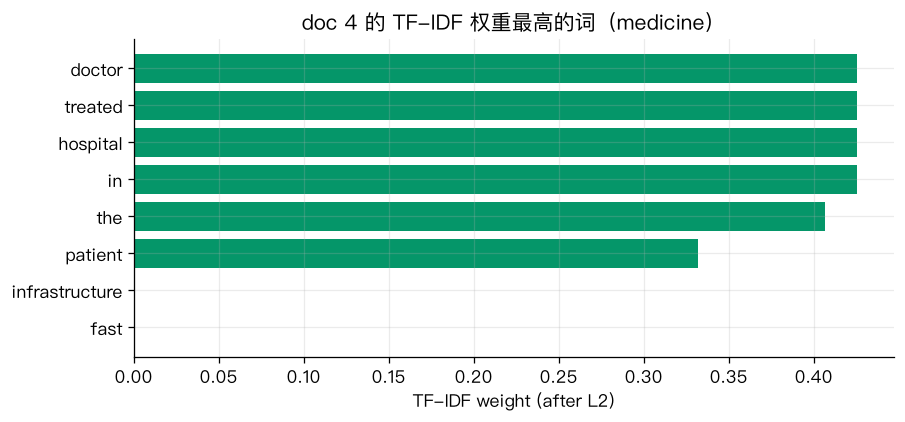


观察：'the' 虽然次数不低，但它的 IDF 很小（因为几乎每篇都有），
所以在权重排序里被自动压到很后面。这正是 IDF 想要的效果。


In [26]:
# ------------------------------------------------------------
# Step 4. 用 sklearn 的 TfidfVectorizer 复算，验证手算结果
# ------------------------------------------------------------
tfidf_vec = TfidfVectorizer(
    token_pattern=r"[a-z]+",
    norm="l2",
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=False,
)
X_tfidf = tfidf_vec.fit_transform(docs)
tfidf_terms = np.array(tfidf_vec.get_feature_names_out())

print(f"X_tfidf shape = {X_tfidf.shape}  (16 篇文档 × |V| 个词)")

print("\n手算 tf*idf/L2  vs  sklearn 输出：")
sk_row = X_tfidf[doc_id].toarray().ravel()
for term in ["the", "patient", "doctor", "hospital", "vaccine"]:
    tf, df, idf, raw = manual_tfidf_breakdown(term)
    manual = raw / l2 if l2 else 0.0
    j = np.where(tfidf_terms == term)[0][0]
    print(f"  {term:<10} manual = {manual:.4f}   sklearn = {sk_row[j]:.4f}   "
          f"{'OK' if abs(manual - sk_row[j]) < 1e-6 else '!! mismatch !!'}")

weights = X_tfidf[doc_id].toarray().ravel()
top = np.argsort(weights)[::-1][:8]
print(f"\ndoc {doc_id} ({labels[doc_id]}) 中 TF-IDF 最高的 8 个词：")
for j in top:
    print(f"  {tfidf_terms[j]:<12} tfidf = {weights[j]:.4f}")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(tfidf_terms[top][::-1], weights[top][::-1], color=COLORS["green"])
ax.set_title(f"doc {doc_id} 的 TF-IDF 权重最高的词（{labels[doc_id]}）")
ax.set_xlabel("TF-IDF weight (after L2)")
plt.tight_layout()
plt.show()

print("\n观察：'the' 虽然次数不低，但它的 IDF 很小（因为几乎每篇都有），")
print("所以在权重排序里被自动压到很后面。这正是 IDF 想要的效果。")

In [27]:
# ------------------------------------------------------------
# Step 4 (续). sublinear_tf 对照：把 tf 换成 1 + log(tf) 会发生什么？
# ------------------------------------------------------------
# 默认 TfidfVectorizer 是 tf 线性用 -> 一个词在同一篇里出现 10 次的权重是出现 1 次的 10 倍。
# 打开 sublinear_tf=True 就换成 1 + log(tf)：出现 10 次相对 1 次只增加 (1+ln 10)/1 ≈ 3.30 倍。
tfidf_lin = TfidfVectorizer(token_pattern=r"[a-z]+", norm=None,
                            use_idf=True, smooth_idf=True, sublinear_tf=False)
tfidf_sub = TfidfVectorizer(token_pattern=r"[a-z]+", norm=None,
                            use_idf=True, smooth_idf=True, sublinear_tf=True)
X_lin = tfidf_lin.fit_transform(docs)
X_sub = tfidf_sub.fit_transform(docs)
vocab_lin = np.array(tfidf_lin.get_feature_names_out())
vocab_sub = np.array(tfidf_sub.get_feature_names_out())

# 挑一批 tf > 1 的高频词做直观对比。
compare_terms = ["the", "patient", "doctor", "hospital"]
print(f"对照文档 doc_id={doc_id}，比较同一个 idf 下 tf 与 1+log(tf) 对最终权重的影响：\n")
print(f"{'term':<10}{'tf':>4}{'1+log(tf)':>12}{'default w':>14}{'sublinear w':>14}{'ratio':>8}")
print("-" * 62)
for term in compare_terms:
    tf = doc_counts.get(term, 0)
    if tf == 0:
        continue
    log_tf = 1 + math.log(tf) if tf > 0 else 0.0
    j_lin = np.where(vocab_lin == term)[0][0]
    j_sub = np.where(vocab_sub == term)[0][0]
    w_lin = X_lin[doc_id, j_lin]
    w_sub = X_sub[doc_id, j_sub]
    ratio = (w_sub / w_lin) if w_lin else float("nan")
    print(f"{term:<10}{tf:>4}{log_tf:>12.4f}{w_lin:>14.4f}{w_sub:>14.4f}{ratio:>8.3f}")

print("\n读表方式：")
print(" - tf=1 的词，1+log(1)=1，两列权重完全相同（ratio=1.000）。")
print(" - tf 越大，'ratio' 越小 -> sublinear_tf 把高频词的权重压得越狠。")
print(" - 这就是 '同一个词出现 10 次不代表比 1 次重要 10 倍' 那句话的可视化。")

对照文档 doc_id=4，比较同一个 idf 下 tf 与 1+log(tf) 对最终权重的影响：

term        tf   1+log(tf)     default w   sublinear w   ratio
--------------------------------------------------------------
the          3      2.0986        3.0000        2.0986   0.700
patient      1      1.0000        2.4469        2.4469   1.000
doctor       1      1.0000        3.1401        3.1401   1.000
hospital     1      1.0000        3.1401        3.1401   1.000

读表方式：
 - tf=1 的词，1+log(1)=1，两列权重完全相同（ratio=1.000）。
 - tf 越大，'ratio' 越小 -> sublinear_tf 把高频词的权重压得越狠。
 - 这就是 '同一个词出现 10 次不代表比 1 次重要 10 倍' 那句话的可视化。


余弦相似度矩阵 shape: (16, 16)  (16 × 16)


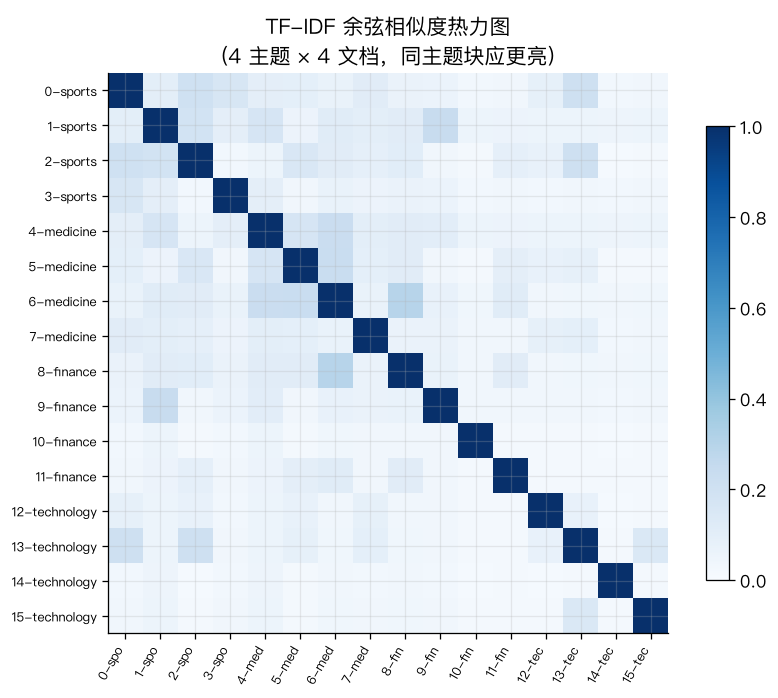

观察：4×4 的深色对角块正对应 sports/medicine/finance/technology 4 个主题。
同主题文档之间余弦相似度明显高于跨主题文档 -> TF-IDF 抓到了主题信号。

query = 'patient hospital medicine'
Top-5 most similar documents:
  sim=0.425  label=medicine    'a nurse checked the patient and gave medicine'
  sim=0.424  label=medicine    'the doctor treated the patient in the hospital'
  sim=0.165  label=medicine    'the vaccine reduced infection and protected the patient'
  sim=0.000  label=technology  'the neural network learned patterns from data'
  sim=0.000  label=technology  'the startup built an app using cloud infrastructure'

对 top-1 文档手动展开余弦相似度：
  重叠词 = ['medicine', 'patient']
  q · d  = 0.4247
  ||q|| * ||d|| = 1.0000 * 1.0000 = 1.0000
  cos(q, d) = 0.4247  (和 sims[top_doc] 一致)

词面失败案例：
  query = 'physician cured sick person'
  TF-IDF 认得的词       = []
  被当成未登录词丢弃 (OOV) = ['physician', 'cured', 'sick', 'person']
  向量非零维度 = 0；最大余弦相似度 = 0.000
  结论：'physician' ≈ 'doctor'、'sick' ≈ 'ill'，但 TF-IDF 认不出同义关系。
       这就是 Word2Vec 想解决的核心问题——用稠密向量让'同

In [28]:
# ------------------------------------------------------------
# Step 5. 用 TF-IDF + 余弦相似度做检索 & 画文档相似度热力图
# ------------------------------------------------------------
sim_matrix = cosine_similarity(X_tfidf)
print("余弦相似度矩阵 shape:", sim_matrix.shape, " (16 × 16)")

fig, ax = plt.subplots(figsize=(7.5, 6.2))
im = ax.imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(docs)))
ax.set_yticks(range(len(docs)))
ax.set_xticklabels([f"{i}-{labels[i][:3]}" for i in range(len(docs))],
                   rotation=60, ha="right", fontsize=8)
ax.set_yticklabels([f"{i}-{labels[i]}" for i in range(len(docs))], fontsize=8)
ax.set_title("TF-IDF 余弦相似度热力图\n(4 主题 × 4 文档，同主题块应更亮)")
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

print("观察：4×4 的深色对角块正对应 sports/medicine/finance/technology 4 个主题。")
print("同主题文档之间余弦相似度明显高于跨主题文档 -> TF-IDF 抓到了主题信号。\n")

query = "patient hospital medicine"
q_vec = tfidf_vec.transform([query])
sims = cosine_similarity(q_vec, X_tfidf).ravel()
rank = sims.argsort()[::-1][:5]

print(f"query = {query!r}")
print("Top-5 most similar documents:")
for i in rank:
    print(f"  sim={sims[i]:.3f}  label={labels[i]:<10}  '{docs[i]}'")

top_doc = rank[0]
q_arr = q_vec.toarray().ravel()
d_arr = X_tfidf[top_doc].toarray().ravel()
overlap = np.where((q_arr > 0) & (d_arr > 0))[0]
dot = float(q_arr @ d_arr)
qn, dn = float(np.linalg.norm(q_arr)), float(np.linalg.norm(d_arr))
print("\n对 top-1 文档手动展开余弦相似度：")
print(f"  重叠词 = {tfidf_terms[overlap].tolist()}")
print(f"  q · d  = {dot:.4f}")
print(f"  ||q|| * ||d|| = {qn:.4f} * {dn:.4f} = {qn*dn:.4f}")
print(f"  cos(q, d) = {dot / (qn * dn):.4f}  (和 sims[top_doc] 一致)")

oov_query = "physician cured sick person"
oov_vec = tfidf_vec.transform([oov_query])
oov_tokens = tokenize(oov_query)
known = [t for t in oov_tokens if t in tfidf_terms]
ignored = [t for t in oov_tokens if t not in tfidf_terms]
oov_sims = cosine_similarity(oov_vec, X_tfidf).ravel()
print("\n词面失败案例：")
print(f"  query = {oov_query!r}")
print(f"  TF-IDF 认得的词       = {known}")
print(f"  被当成未登录词丢弃 (OOV) = {ignored}")
print(f"  向量非零维度 = {oov_vec.nnz}；最大余弦相似度 = {oov_sims.max():.3f}")
print("  结论：'physician' ≈ 'doctor'、'sick' ≈ 'ill'，但 TF-IDF 认不出同义关系。")
print("       这就是 Word2Vec 想解决的核心问题——用稠密向量让'同义'可自动学到。")

### 小结：一张图看清 One-hot → BoW → TF-IDF 的演化

```text
              (a) 词 --one-hot--> 长度 |V|、只有一位为 1 的向量
              (b) 文档 = Σ 词的 one-hot  ->  BoW（词袋），格子里是"次数"
              (c) 每格再乘上 idf(w)      ->  TF-IDF（词频-逆文档频率）
              (d) 再做 L2 归一化         ->  可以直接用余弦相似度比较文档
```

一步步的每一次改良都很朴素，但都在为下一步铺路：

- One-hot 给了我们一个统一的"词到向量"接口。
- BoW 把整篇文档合成一个可以相加、可以相减、可以做点积的向量。
- IDF 权重让"高频通用词"自动降权，让"稀有主题词"自动升权。
- L2 归一化让不同长度的文档能公平比较。

### 优劣势

| 维度 | BoW / TF-IDF |
|------|--------------|
| 优点 | 简单、可解释、强基线，非常适合搜索、去重、主题聚类、文本分类 |
| 缺点 | 高维稀疏、忽略词序、无法处理同义词、OOV（未登录词）直接丢弃 |
| 典型失败 | `doctor treated patient` 和 `physician cured sick person` 语义相近，但词面不同，TF-IDF 会给出很低的相似度 |
| 常见工程旋钮 | `stop_words`（去停用词）、`ngram_range`（加 2-gram/3-gram）、`min_df`/`max_df`（去太罕见/太常见的词）、`sublinear_tf`（用 $1+\log \text{tf}$ 抑制高频词）、`norm='l2'` vs `'l1'` vs `None` |

### 和 Word2Vec 的关系

沿着"稀疏表示"这条路走：**One-hot 是稀疏基线，BoW 是它的求和，TF-IDF 则是稀疏加权表示的顶峰。**它们全都把每个词当成一个**孤立、离散、正交**的维度——`doctor` 和 `physician` 在向量空间里毫无关系，`cat` 和 `dog` 也是。

Word2Vec 换了一条彻底不同的路：**用一个几十到几百维的稠密向量（Dense Vector）代替长度 |V| 的稀疏向量，让"同义"、"类比"这些语义关系在向量空间里自动浮现出来**（$\text{king} - \text{man} + \text{woman} \approx \text{queen}$）。

从 TF-IDF 到 Word2Vec，中间还夹着几步"探路"的工作——第 7 章的 LSA/LDA 用矩阵分解在文档级压出低维语义，第 8 章的 PMI/PPMI/SVD 用词-上下文共现矩阵在词级压出语义。这些都是 Word2Vec 出现的直接思想来源。

## 5 · 传统机器学习文本分类（Traditional Machine Learning）

### 一句话直觉

想象你是一位新来的图书管理员：手边有一堆没贴标签的短文，任务是把它们塞进 `sports / medicine / finance / technology` 四个书架。

- **规则派**：看到 `football` 就塞体育、看到 `vaccine` 就塞医疗——规则越写越多、越写越乱。
- **机器学习派**：把每篇文章变成一个"数字指纹"（第 4 章的 TF-IDF 向量），然后让一个数学模型自己去学"哪些指纹长得像体育、哪些像金融"。学完之后，来一篇新文章，模型就能自己判断。

这一章我们把这条流水线跑一遍：

```text
文本 → 分词 → TF-IDF 向量 → 分类器（NB / LR / SVM） → 类别
```

这就是深度学习之前，工业界最经典、也最耐用的 NLP 分类范式。

### 关键中英文对照

| 英文 / 缩写 | 中文名 | 一句话说明 |
|-------------|--------|------------|
| ML (Machine Learning) | 机器学习 | 让模型从数据里自动学"输入到输出"的映射 |
| Feature Engineering | 特征工程 | 把人对任务的理解转成模型能吃的数字特征 |
| NB (Naive Bayes) | 朴素贝叶斯 | 生成式分类器，假设特征在给定类别下相互独立 |
| Multinomial Naive Bayes | 多项式朴素贝叶斯 | 专门为词频/计数特征设计的 NB 变体 |
| LR (Logistic Regression) | 逻辑回归 | 判别式线性分类器，用 softmax/sigmoid 输出概率 |
| SVM (Support Vector Machine) | 支持向量机 | 找一条"最大间隔"的决策边界 |
| Linear SVM | 线性 SVM | SVM 的线性核版本，文本高维稀疏场景常用 |
| Generative Model | 生成式模型 | 建模 $P(x, y)$ 或 $P(x \mid y)P(y)$ |
| Discriminative Model | 判别式模型 | 直接建模 $P(y \mid x)$ 或分类边界 |
| Decision Boundary | 决策边界 | 特征空间里划分不同类别的分界面 |
| CV (Cross Validation) | 交叉验证 | 把数据切成 K 折轮流做训练/验证，评估更稳 |
| Stratified K-Fold | 分层 K 折 | 每折保持类别比例一致的 K 折切分 |
| Confusion Matrix | 混淆矩阵 | 行 = 真实类别、列 = 预测类别的对照表 |
| Accuracy / Precision / Recall / F1 | 准确率 / 精确率 / 召回率 / F1 值 | 分类任务的四个基本指标 |

### 两位主角的核心公式

**NB（朴素贝叶斯，生成式）** 想的是"这个类别有多可能造出这篇文档"：

$$P(\text{class} \mid \text{doc}) \;\propto\; P(\text{class}) \cdot \prod_{w \in \text{doc}} P(w \mid \text{class})^{\text{count}(w)}$$

- $P(\text{class})$：先验，训练集里每个类别的比例。
- $P(w \mid \text{class})$：这个类别里词 $w$ 有多常出现（Multinomial NB 直接数词频）。
- **朴素**在哪里：假设每个词在给定类别下**互相独立**——虽然不真实，但工程上极其好用。

**LR（逻辑回归，判别式）** 想的是"给定这篇文档，它属于哪个类别的概率有多大"：

$$P(y = c \mid x) \;=\; \frac{\exp(W_c \cdot x + b_c)}{\sum_{c'} \exp(W_{c'} \cdot x + b_{c'})} \;=\; \text{softmax}(W_c \cdot x + b_c)$$

- $x$：文档的 TF-IDF 向量。
- $W_c$：类别 $c$ 的权重向量，$W_c \cdot x$ 就是"这些词对类别 $c$ 打了多少分"。
- softmax（归一化指数函数）把所有类别的原始分数变成加起来等于 1 的概率。

**SVM（支持向量机，判别式）** 也是"每个词一个权重、加起来看正负"，但它不算概率，而是要找一条**间隔最大**的决策边界。它优化的是 **hinge loss（合页损失）**：

$$L(y, s) \;=\; \max\bigl(0,\ 1 - y \cdot (W \cdot x + b)\bigr), \quad y \in \{-1, +1\}$$

- 当 $y \cdot (W \cdot x + b) \geq 1$（样本已经落在正确一侧，且离边界够远），损失为 0——SVM 只关心"边界附近的样本（support vectors）"，远离边界的样本再多也不会继续拉动权重；
- 当 $y \cdot (W \cdot x + b) < 1$，损失线性增长，逼着边界远离错分点；
- Linear SVM 就是这条决策边界在原始 TF-IDF 空间里的线性版本。

**三兄弟对称表**：三者都走"文本 → TF-IDF → 线性打分 → 类别"这条流水线，差别主要在"损失怎么定义"上：

| 模型 | 建模对象 | 损失函数 | 是否给概率 | 决策边界特征 |
|------|----------|----------|------------|--------------|
| NB   | $P(x, y) = P(y) \prod_w P(w \mid y)^{c_w}$ | 负对数似然（数频率，闭式解） | 是（严格） | 由 $\log P(y) + \sum_w c_w \log P(w \mid y)$ 隐式定义 |
| LR   | $P(y \mid x)$ | 交叉熵 / 对数损失 $-\log P(y \mid x)$ | 是 | 线性超平面 $W_c \cdot x + b_c = 0$ |
| SVM  | 决策边界本身 | Hinge $\max(0,\ 1 - y \cdot s)$ | 否（默认） | 线性超平面，且要求**间隔 $\geq 1$** |

三者最后都是"输入 TF-IDF → 线性打分 → 得类别"，但损失不同 ⇒ 边界摆放不同 ⇒ 对同一批样本，NB / LR / SVM 会各自偏向不同的错分点。这就是下面 Step 2/3 里我们会看到它们 CV 表现出现差异的根源。

### 章节地图

- **Step 1**：把第 4 章的 TF-IDF 矩阵拿过来当特征。
- **Step 2**：一次性训练 NB / LR / SVM，看看单次划分的准确率。
- **Step 3**：用 Stratified K-Fold（分层 K 折）+ `cross_val_predict` 做更稳的评估。
- **Step 4**：对比"生成式（NB） vs 判别式（LR）"眼里最重要的词。
- **Step 5**：画混淆矩阵，看模型到底把谁跟谁弄混了。

In [29]:
# ------------------------------------------------------------
# Step 1. 构造一个"够难"的语料，把文档变成 TF-IDF 特征矩阵
# ------------------------------------------------------------
# 我们先尝试 sklearn 的 20 Newsgroups（sci.med / sci.space / talk.politics.misc /
# rec.sport.baseball），它比第 4 章的 toy 语料更接近真实分类任务，
# 能让 NB / LR / SVM 的 CV 差异明显跑出来。
# 如果 CI 环境没有网络（第一次调用会去下载 20news），就自动回退到
# 扩展后的 toy 语料 + hard_docs（故意在类别间插入交叉/混淆词）。
CV_CATEGORIES = ["sci.med", "sci.space",
                 "talk.politics.misc", "rec.sport.baseball"]

try:
    from sklearn.datasets import fetch_20newsgroups
    ng = fetch_20newsgroups(
        subset="train",
        categories=CV_CATEGORIES,
        remove=("headers", "footers", "quotes"),
        # download_if_missing=True: 有缓存/网络时会用真数据；
        # 无网时会抛 URLError / OSError，被下面 except 兜住。
    )
    # 每类只取前 40 篇，避免 CV 跑得太慢；用户想加就把 40 改大。
    rng = np.random.RandomState(SEED)
    keep_idx = []
    for c in range(len(ng.target_names)):
        cls_ids = np.where(ng.target == c)[0]
        rng.shuffle(cls_ids)
        keep_idx.extend(cls_ids[:40].tolist())
    keep_idx = sorted(keep_idx)
    X_texts = [ng.data[i] for i in keep_idx]
    y = np.array([ng.target_names[ng.target[i]] for i in keep_idx])
    data_source = "20 Newsgroups (sci.med / sci.space / talk.politics.misc / rec.sport.baseball)"
except Exception as exc:
    # ---------- 回退方案：扩展 toy 语料 + hard_docs ----------
    # hard_docs 故意混合两个类别的关键词，用来把三兄弟的 CV 差异逼出来：
    #   - NB 会被"共享词"的高频拉偏（独立性假设失效）；
    #   - LR/SVM 会用负权重压制这些共享词，但两者惩罚力度不同。
    print(f"[fallback] fetch_20newsgroups 不可用（{type(exc).__name__}），"
          "使用扩展 toy + hard_docs 语料。")
    base_docs = list(zip(labels, docs))  # 第 0 章的 16 篇
    hard_docs = [
        # sports 里塞进"vaccine / hospital / doctor"这类 medicine 词
        ("sports", "the football coach recovered from injury at the hospital before the match"),
        ("sports", "a marathon runner used a vaccine and still won the tournament"),
        ("sports", "the tennis player consulted a doctor about knee treatment"),
        # medicine 里塞进"team / league / player"这类 sports 词
        ("medicine", "the medical team treated the injured player from the football league"),
        ("medicine", "the hospital league organized a vaccine tournament for the community"),
        ("medicine", "the doctor coached the patient like a sports player through recovery"),
        # finance 里塞进"algorithm / cloud / neural"这类 technology 词
        ("finance", "the fund used a machine learning algorithm to predict stock price"),
        ("finance", "the bank deployed a cloud infrastructure to reduce loan risk"),
        ("finance", "investors bet on neural network startups after the company reported profit"),
        # technology 里塞进"market / profit / investor"这类 finance 词
        ("technology", "the startup raised profit from investors after launching the app"),
        ("technology", "the software engineer studied the market before training the model"),
        ("technology", "the neural network startup priced its stock and paid interest to the bank"),
    ]
    all_docs = base_docs + hard_docs
    X_texts = [t for _, t in all_docs]
    y = np.array([lab for lab, _ in all_docs])
    data_source = "toy corpus (16) + hard_docs (12) = {} 篇".format(len(all_docs))

# TfidfVectorizer 一步完成"分词 + 建词表 + 计数 + IDF 加权 + L2 归一化"。
tfidf_for_clf = TfidfVectorizer()
X_features = tfidf_for_clf.fit_transform(X_texts)

print("数据来源:", data_source)
print("语料规模: {} 篇文档, {} 个类别".format(len(X_texts), len(set(y))))
print("类别分布:", dict(Counter(y)))
print("TF-IDF 特征矩阵 shape:", X_features.shape,
      "(行=文档, 列=词表大小)")
print("矩阵稀疏度: 非零元素 = {} / {}".format(X_features.nnz,
      X_features.shape[0] * X_features.shape[1]))
print("\n第 0 篇文档 (label={}):\n{}".format(y[0], X_texts[0][:200]))

数据来源: 20 Newsgroups (sci.med / sci.space / talk.politics.misc / rec.sport.baseball)
语料规模: 160 篇文档, 4 个类别
类别分布: {np.str_('sci.space'): 40, np.str_('rec.sport.baseball'): 40, np.str_('talk.politics.misc'): 40, np.str_('sci.med'): 40}
TF-IDF 特征矩阵 shape: (160, 4941) (行=文档, 列=词表大小)
矩阵稀疏度: 非零元素 = 13612 / 790560

第 0 篇文档 (label=sci.space):
  Bingo.
 Nothing evil at all. There's no actual harm in what they're doing, only
how they represent it.

 -----------------------------------------------------------------
 .sig files are like string


In [30]:
# ------------------------------------------------------------
# Step 2. 训练 NB / LR / SVM 三个经典分类器，做一次 held-out 评估
# ------------------------------------------------------------
# stratify=y：让训练/测试集里各类比例一致，toy 数据尤其重要，
# 否则可能出现"测试集里根本没有 medicine"这种畸形切分。
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_texts, y, test_size=0.25, random_state=SEED, stratify=y
)

# 用 Pipeline 把"TF-IDF 特征提取 + 分类器"串起来：
#   - fit 时：先在训练集上学词表，再喂给分类器；
#   - predict 时：用同一个词表把新文本变成向量。
# 这是工业界处理"训练/推理一致性"的标准写法。
nb_model  = make_pipeline(TfidfVectorizer(), MultinomialNB())
lr_model  = make_pipeline(TfidfVectorizer(),
                          LogisticRegression(max_iter=1000, random_state=SEED))
svm_model = make_pipeline(TfidfVectorizer(),
                          LinearSVC(random_state=SEED))

models = [
    ("Naive Bayes (NB, 朴素贝叶斯)",           nb_model),
    ("Logistic Regression (LR, 逻辑回归)",     lr_model),
    ("Linear SVM (线性支持向量机)",             svm_model),
]

print("Held-out (25% test) 单次划分结果：\n")
for name, model in models:
    model.fit(X_train_text, y_train)
    pred = model.predict(X_test_text)
    acc = accuracy_score(y_test, pred)
    print(f"[{name}]  accuracy = {acc:.3f}")
    for text, gold, p in zip(X_test_text, y_test, pred):
        flag = "OK " if gold == p else "ERR"
        print(f"   {flag}  gold={gold:<11} pred={p:<11} | {text}")
    print()

print("提示：单次划分的 accuracy 波动很大，且此时三兄弟的差异可能只是运气；"
      "下一步用交叉验证做更稳的评估。")

Held-out (25% test) 单次划分结果：

[Naive Bayes (NB, 朴素贝叶斯)]  accuracy = 0.725
   ERR  gold=talk.politics.misc pred=sci.space   | 
The tax protesters are legally correct, but they are put in jail anyway.

The weakness of the governments legal position is shown by the fact that when
someone protesting tax or gun laws on legal grounds gets a federal jury trial
(very rare) the feds blatantly stack the jury, with the same old faces turning
up time after time.

However Teel should have mentioned that though his advice is legally sound, if
you follow it you will probably wind up in jail.

   OK   gold=sci.space   pred=sci.space   | Archive-name: space/schedule
Last-modified: $Date: 93/04/01 14:39:23 $

SPACE SHUTTLE ANSWERS, LAUNCH SCHEDULES, TV COVERAGE

    SHUTTLE LAUNCHINGS AND LANDINGS; SCHEDULES AND HOW TO SEE THEM

    Shuttle operations are discussed in the Usenet group sci.space.shuttle,
    and Ken Hollis (gandalf@pro-electric.cts.com) posts a compressed version
    of the shuttle manife

In [31]:
# ------------------------------------------------------------
# Step 3. Stratified K-Fold + cross_val_predict 做更稳的评估
# ------------------------------------------------------------
# 直觉：不再只切一次训练/测试，而是把数据切成 K 折，
#   每一折轮流当"测试"、其余当"训练"，
#   最后拼出所有样本的"跨折预测"。
# Stratified 保证每一折里各类比例都尽量一致 -- 对不平衡/小样本尤其关键。
#
# K 不能超过"最少类的样本数"，这里根据实际数据自适应取 min(5, 最少类样本数)。
min_per_class = min(Counter(y).values())
n_splits = min(5, min_per_class)
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

print(f"Stratified {n_splits}-Fold CV accuracy（相同数据，重复评估三个模型）：\n")
cv_results = {}
cv_accs = {}
for name, model in models:
    # cross_val_predict 会自动完成"切分 -> 训练 -> 预测"，
    # 返回的是"每个样本在它没参与训练的那一折里的预测"。
    cv_pred = cross_val_predict(model, X_texts, y, cv=cv)
    acc = accuracy_score(y, cv_pred)
    cv_results[name] = cv_pred
    cv_accs[name] = acc
    print(f"[{name}]  CV accuracy = {acc:.3f}")

spread = max(cv_accs.values()) - min(cv_accs.values())
print(f"\n三兄弟 CV accuracy 跨度 = {spread*100:.1f} 个百分点。")
print("（在'够难'的数据集上，NB / LR / SVM 通常会拉开 5~15pp 的差距——"
      "这就是不同损失函数带来的不同边界摆放。）")
print("\n为什么 CV 更可信？")
print("  - 每个样本都被预测过一次，评估用满了全部文档；")
print(f"  - 分层保证每折里都覆盖 {sorted(set(y))} 全部类别；")
print("  - 一次单独的 held-out 可能因为运气好/差偏离真实水平。")

Stratified 5-Fold CV accuracy（相同数据，重复评估三个模型）：

[Naive Bayes (NB, 朴素贝叶斯)]  CV accuracy = 0.669
[Logistic Regression (LR, 逻辑回归)]  CV accuracy = 0.688
[Linear SVM (线性支持向量机)]  CV accuracy = 0.706

三兄弟 CV accuracy 跨度 = 3.8 个百分点。
（在'够难'的数据集上，NB / LR / SVM 通常会拉开 5~15pp 的差距——这就是不同损失函数带来的不同边界摆放。）

为什么 CV 更可信？
  - 每个样本都被预测过一次，评估用满了全部文档；
  - 分层保证每折里都覆盖 [np.str_('rec.sport.baseball'), np.str_('sci.med'), np.str_('sci.space'), np.str_('talk.politics.misc')] 全部类别；
  - 一次单独的 held-out 可能因为运气好/差偏离真实水平。


In [32]:
# ------------------------------------------------------------
# Step 4. 生成式 vs 判别式：看看两种模型眼里"最重要的词"
# ------------------------------------------------------------
# 我们用全部文档重新拟合 NB 和 LR，方便直接读它们的内部参数。
nb_full = make_pipeline(TfidfVectorizer(), MultinomialNB()).fit(X_texts, y)
lr_full = make_pipeline(TfidfVectorizer(),
                        LogisticRegression(max_iter=1000, random_state=SEED)
                        ).fit(X_texts, y)

# ---------- NB：每个类别 top log P(word | class) ----------
# NB 是生成式，"某类文档最喜欢生成哪些词"就是它的证据。
nb_vec = nb_full.named_steps["tfidfvectorizer"]
nb_clf = nb_full.named_steps["multinomialnb"]
nb_terms = np.array(nb_vec.get_feature_names_out())

print("=== 生成式模型 NB：每类 top log P(word | class) ===")
print("解读：log 概率越大（越接近 0），说明这个词在该类文档里越常出现。")
print("注意：本示例故意不去停用词（stop words），所以 log P 里排前的多是")
print("      the/a/of/with 这类通用词——真实工程中会打开"
      " TfidfVectorizer(stop_words='english') 让它们自动被过滤掉。\n")
for k, cls in enumerate(nb_clf.classes_):
    top_idx = nb_clf.feature_log_prob_[k].argsort()[-6:][::-1]
    print(f"class = {cls} (log prior = {nb_clf.class_log_prior_[k]:+.3f})")
    for i in top_idx:
        print(f"   {nb_terms[i]:<14} log P(w|{cls}) = "
              f"{nb_clf.feature_log_prob_[k, i]:+.3f}")
    print()

# ---------- LR：每个类别 top 权重词 ----------
# LR 是判别式（多分类版本用 softmax），系数 W_c 直接告诉我们
# "增加这个词的 TF-IDF 会把预测多推向类别 c"。
lr_vec = lr_full.named_steps["tfidfvectorizer"]
lr_clf = lr_full.named_steps["logisticregression"]
lr_terms = np.array(lr_vec.get_feature_names_out())

print("=== 判别式模型 LR：每类 top 权重词 (W_c · x 里最大的分量) ===")
print("解读：权重为正的词把决策推向该类；负权重则相反。\n")
for k, cls in enumerate(lr_clf.classes_):
    coef_c = lr_clf.coef_[k]
    top_idx = coef_c.argsort()[-6:][::-1]
    print(f"class = {cls}")
    for i in top_idx:
        print(f"   {lr_terms[i]:<14} weight = {coef_c[i]:+.3f}")
    print()

print("小结：")
print("  - NB 的证据是'这个词在该类里出现频率高'；")
print("  - LR 的证据是'这个词让该类相对其他类更占优'；")
print("  - 二者常常给出相似的 top 词，但排序和强度不同 --")
print("    这就是生成式 vs 判别式在同一数据上的两种视角。")

=== 生成式模型 NB：每类 top log P(word | class) ===
解读：log 概率越大（越接近 0），说明这个词在该类文档里越常出现。
注意：本示例故意不去停用词（stop words），所以 log P 里排前的多是
      the/a/of/with 这类通用词——真实工程中会打开 TfidfVectorizer(stop_words='english') 让它们自动被过滤掉。

class = rec.sport.baseball (log prior = -1.386)
   the            log P(w|rec.sport.baseball) = -6.838
   and            log P(w|rec.sport.baseball) = -7.457
   to             log P(w|rec.sport.baseball) = -7.477
   in             log P(w|rec.sport.baseball) = -7.552
   he             log P(w|rec.sport.baseball) = -7.574
   of             log P(w|rec.sport.baseball) = -7.575

class = sci.med (log prior = -1.386)
   the            log P(w|sci.med) = -6.900
   to             log P(w|sci.med) = -7.147
   it             log P(w|sci.med) = -7.180
   of             log P(w|sci.med) = -7.190
   is             log P(w|sci.med) = -7.240
   and            log P(w|sci.med) = -7.327

class = sci.space (log prior = -1.386)
   the            log P(w|sci.space) = -6.688
   to             log P(w|

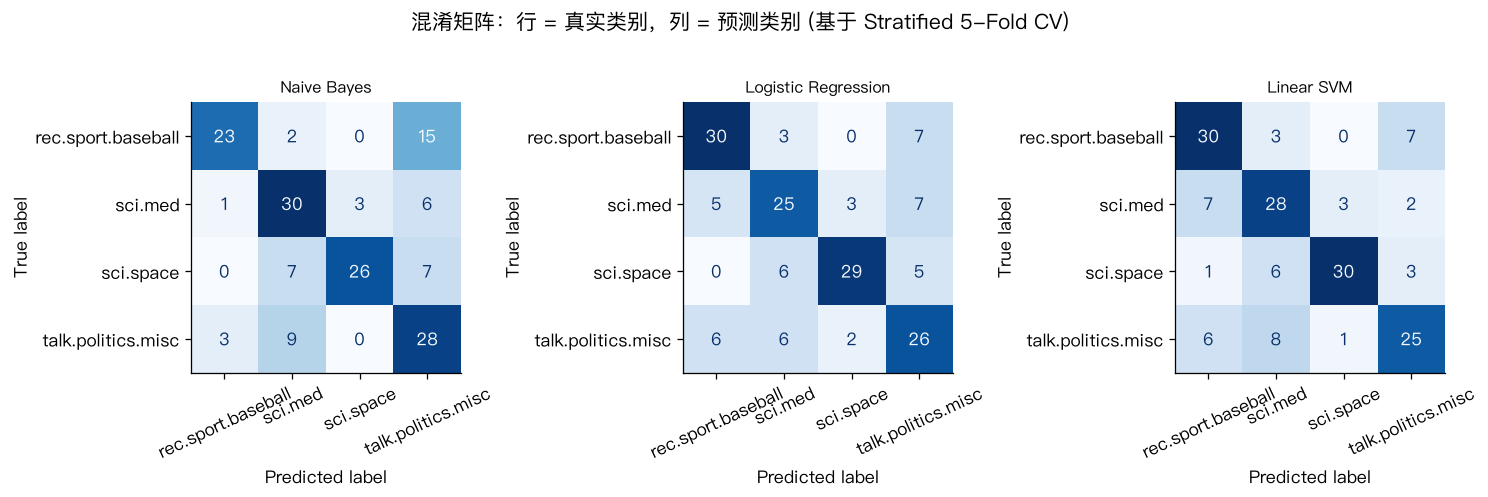

怎么读混淆矩阵：
  - 对角线格子 = 预测正确的数量，越集中在对角线越好；
  - 非对角线 = '把 A 类预测成 B 类'，看哪两类最容易混淆；
  - 对 toy 数据来说，最容易混的往往是
    共享通用词（如 the / a / with）的类别对。

最后再看一遍综合报告 (以 LR 的 CV 预测为例)：
                    precision    recall  f1-score   support

rec.sport.baseball       0.73      0.75      0.74        40
           sci.med       0.62      0.62      0.62        40
         sci.space       0.85      0.72      0.78        40
talk.politics.misc       0.58      0.65      0.61        40

          accuracy                           0.69       160
         macro avg       0.70      0.69      0.69       160
      weighted avg       0.70      0.69      0.69       160

Precision（精确率）= 预测为该类里真的是该类的比例；
Recall（召回率）  = 真实该类里被找回来的比例；
F1                = 二者的调和平均，平衡精度和覆盖。


In [33]:
# ------------------------------------------------------------
# Step 5. 混淆矩阵：把模型到底"把谁跟谁弄混了"画出来
# ------------------------------------------------------------
# 用 Step 3 的 CV 预测结果画 -- 这样图里覆盖了全部文档，
# 比只画一次 held-out 更能反映模型行为。
fig, axes = plt.subplots(1, len(models), figsize=(13, 4.2))
class_order = sorted(set(y))

for ax, (name, _) in zip(axes, models):
    cv_pred = cv_results[name]
    ConfusionMatrixDisplay.from_predictions(
        y, cv_pred,
        labels=class_order,
        cmap="Blues", colorbar=False, ax=ax,
    )
    ax.set_title(name.split(" (")[0], fontsize=10)
    ax.grid(False)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle(f"混淆矩阵：行 = 真实类别，列 = 预测类别 (基于 Stratified {n_splits}-Fold CV)",
             y=1.02)
plt.tight_layout()
plt.show()

print("怎么读混淆矩阵：")
print("  - 对角线格子 = 预测正确的数量，越集中在对角线越好；")
print("  - 非对角线 = '把 A 类预测成 B 类'，看哪两类最容易混淆；")
print("  - 对 toy 数据来说，最容易混的往往是")
print("    共享通用词（如 the / a / with）的类别对。\n")

print("最后再看一遍综合报告 (以 LR 的 CV 预测为例)：")
print(classification_report(y, cv_results["Logistic Regression (LR, 逻辑回归)"],
                            zero_division=0))
print("Precision（精确率）= 预测为该类里真的是该类的比例；")
print("Recall（召回率）  = 真实该类里被找回来的比例；")
print("F1                = 二者的调和平均，平衡精度和覆盖。")

### Step 5.5 · 错分样本 walkthrough：同一条文档，NB 与 LR 各自怎么想？

到目前为止我们只看了"整体准确率"和"混淆矩阵格子"。但两个模型即使总体准确率接近，也可能**在具体样本上做出完全相反的决定**。下面这段代码会：

1. 找到一条**NB 和 LR 给出不同类别**的样本（即"两模型意见分裂"的样本）；
2. 把 NB 的 `log P(class | doc)`（$\log$ 后验证据）和 LR 的 `decision_function`（每个类别的线性打分 $W_c \cdot x + b_c$）**并排展开**；
3. 对同一批词汇特征，看看两个模型各自加权的方式差在哪里。

这是理解"生成式 vs 判别式"最直接的方式——**在同一条数据上做手术**。

In [34]:
# ------------------------------------------------------------
# Step 5.5. 挑一条 NB 与 LR 意见不一致的样本，并排展开两模型的证据
# ------------------------------------------------------------
nb_cv_pred = cv_results["Naive Bayes (NB, 朴素贝叶斯)"]
lr_cv_pred = cv_results["Logistic Regression (LR, 逻辑回归)"]

# 优先找"两模型至少有一个错、且两模型判断不同"的样本，最能说明差异。
disagree_idx = [i for i in range(len(y))
                if nb_cv_pred[i] != lr_cv_pred[i]
                and (nb_cv_pred[i] != y[i] or lr_cv_pred[i] != y[i])]

if not disagree_idx:
    # 数据太干净时退而求其次：只要两模型意见不同即可。
    disagree_idx = [i for i in range(len(y))
                    if nb_cv_pred[i] != lr_cv_pred[i]]

if not disagree_idx:
    print("[note] 本次运行里 NB 和 LR 对所有样本判断都一致，"
          "换个 SEED 或换更难的数据集就会出现分歧。")
else:
    idx = disagree_idx[0]
    doc = X_texts[idx]
    gold = y[idx]
    print(f"=== 被 NB / LR 判成不同类别的样本 (idx={idx}) ===")
    print(f"真实类别 (gold)      : {gold}")
    print(f"NB 的 CV 预测         : {nb_cv_pred[idx]}"
          + ("  (错)" if nb_cv_pred[idx] != gold else "  (对)"))
    print(f"LR 的 CV 预测         : {lr_cv_pred[idx]}"
          + ("  (错)" if lr_cv_pred[idx] != gold else "  (对)"))
    print("文档内容 (截断 300 字符):")
    print("  " + doc[:300].replace("\n", " "))
    print()

    # ---------- NB: log 后验 log P(class | doc) ----------
    # nb_full 是用全量数据拟合的 pipeline；这里直接读它的 predict_log_proba。
    x_row = nb_full.named_steps["tfidfvectorizer"].transform([doc])
    nb_log_post = nb_full.named_steps["multinomialnb"].predict_log_proba(x_row)[0]
    nb_classes = list(nb_full.named_steps["multinomialnb"].classes_)

    # ---------- LR: decision_function = W_c · x + b_c ----------
    lr_score = lr_full.named_steps["logisticregression"].decision_function(
        lr_full.named_steps["tfidfvectorizer"].transform([doc])
    )[0]
    lr_classes = list(lr_full.named_steps["logisticregression"].classes_)

    print(f"{'class':<14}{'NB log P(y|x)':>18}{'LR W_c·x + b_c':>20}")
    print("-" * 52)
    for cls in sorted(set(nb_classes) | set(lr_classes)):
        nb_val = nb_log_post[nb_classes.index(cls)] if cls in nb_classes else float('nan')
        lr_val = lr_score[lr_classes.index(cls)] if cls in lr_classes else float('nan')
        marker_nb = "  <== NB pick" if nb_classes[int(np.argmax(nb_log_post))] == cls else ""
        marker_lr = "  <== LR pick" if lr_classes[int(np.argmax(lr_score))] == cls else ""
        marker = (marker_nb + marker_lr).strip()
        print(f"{cls:<14}{nb_val:>18.3f}{lr_val:>20.3f}   {marker}")

    print("\n解读：")
    print("  - NB 给出的是**对数后验概率**（越接近 0 越有利），差距来自"
          "'各类别 log 先验 + 各词 log P(w|y) 加权求和'。")
    print("  - LR 给出的是**未归一化的线性分数** W_c · x + b_c，"
          "差距来自'每个词的 TF-IDF × LR 系数'。")
    print("  - 两模型 argmax 不同，说明同样的词汇特征，"
          "在'数频率的世界'和'优化对数损失的世界'里权衡结果不同——"
          "NB 更容易被'两个类别共享的高频词'拉偏，"
          "LR 会用负权重主动压制这类共享词。")

=== 被 NB / LR 判成不同类别的样本 (idx=8) ===
真实类别 (gold)      : sci.med
NB 的 CV 预测         : sci.med  (对)
LR 的 CV 预测         : sci.space  (错)
文档内容 (截断 300 字符):
  :>I think the scientists are biased towards the food industry or something. :>Was the article long? Would anyone be interested in posting it? :a neuroscientist told me that MSG is used as a neurotoxin...that's :right...some labs use it to "kill" neurons in mice and rats  Vitamin A (and I think vitam

class              NB log P(y|x)      LR W_c·x + b_c
----------------------------------------------------
rec.sport.baseball            -1.819              -0.198   
sci.med                   -0.828               0.528   <== NB pick  <== LR pick
sci.space                 -1.537              -0.064   
talk.politics.misc            -1.683              -0.266   

解读：
  - NB 给出的是**对数后验概率**（越接近 0 越有利），差距来自'各类别 log 先验 + 各词 log P(w|y) 加权求和'。
  - LR 给出的是**未归一化的线性分数** W_c · x + b_c，差距来自'每个词的 TF-IDF × LR 系数'。
  - 两模型 argmax 不同，说明同样的词汇特征，在'数频率的世界'和'优

### 小结：一条极其耐用的流水线

Step 1 - 5 演示的是深度学习之前 NLP 分类的黄金三件套：

1. **TF-IDF 特征**：把词面变成有区分度的向量。
2. **线性分类器（NB / LR / Linear SVM）**：在稀疏高维空间里效率高、可解释。
3. **交叉验证 + 混淆矩阵**：诚实评估、可视化定位问题。

即使今天已经有了 BERT / LLM，一条 `TfidfVectorizer + LogisticRegression` 的 Pipeline 在很多任务上仍然是**又快又强**的基线——尤其数据量小、类别边界主要靠关键词决定时。

### 生成式 vs 判别式，一表看清

| 维度 | 生成式（NB） | 判别式（LR / Linear SVM） |
|------|--------------|---------------------------|
| 建模对象 | $P(x, y) = P(y)P(x \mid y)$ | $P(y \mid x)$ 或决策边界 |
| 训练方式 | 数频率 / 极大似然 | 优化损失（对数损失、hinge） |
| 数据需求 | 少量数据也能给出概率估计 | 通常需要更多样本才能学好边界 |
| 独立性假设 | 强（"朴素"） | 无（词之间可以自由影响权重） |
| 可解释性 | `log P(word \| class)` | 每个词一个系数 $W_c$ |
| 常见短板 | 独立性不真实、概率估计偏 | 特征相关时权重不稳定，需要正则化 |

### 优劣势

| 维度 | 传统 ML 文本分类 |
|------|------------------|
| 优点 | 训练快、可解释、小数据也扛用、易于工程化 |
| 缺点 | 表示能力受限于 TF-IDF（稀疏、词面、忽略词序、无同义词） |
| 常见强基线 | `TF-IDF + Logistic Regression` 或 `TF-IDF + Linear SVM` |
| 典型失败 | `doctor treated patient` 和 `physician cured sick person` 在 TF-IDF 空间里几乎不相关 |

### 和 Word2Vec 的关系

**先把关键的一点点破**：这一章的 NB / LR / SVM 学的都是"**分类边界**"——它们只能回答"这篇文档属于哪一类"，答完就结束了；它们**从不会给出每个词自身的分布式表示**。词在这些模型眼里始终只是"TF-IDF 矩阵的一列"，永远只是一根稀疏、正交、和其它词毫无关系的独热轴。所以哪怕你把 LR 训练得再好、SVM 边界拉得再干净，`doctor` 和 `physician` 这两个词在模型内部依然是两根**互相不认识**的坐标。

**要让"词"本身长出一个能反映语义的向量，就必须从"判别式分类"换轨到"表示学习（representation learning）"**——不再问"这句话属于哪一类"，而是问"这个词的上下文长什么样、怎么用一个几十维的稠密向量把它编码下来"。这正是接下来 LSA / PMI / NNLM / **Word2Vec** 这批章节要做的事情：不再学 $P(y \mid x)$ 或分类边界，而是学一张**词嵌入表（word embedding table）**，让每个词自己成为一个可以做加减、做点积、做类比的稠密向量。

回过头看这一章：传统 ML 已经证明了一件事——"**好的表示 + 简单的模型**"往往比"糟糕的表示 + 复杂的模型"更好。这一章里三个分类器都很简单，性能却主要取决于 TF-IDF 这套特征。

但 TF-IDF 有个天花板：**它只是稀疏的词面表示**。`doctor` 和 `physician` 是完全独立的两列，无论加多少数据都不会靠近。

Word2Vec 之后，文本分类的入口从"稀疏词面"升级成"**稠密向量（dense vector）**"：

```text
词序列 --Word2Vec / GloVe--> 稠密词向量 --平均/加权平均--> 文档向量
       --Logistic Regression / Linear SVM / 小神经网络--> 类别
```

- **同义词自动靠近**：`car` 和 `automobile` 在向量空间里天然接近。
- **减少特征工程**：不用再手动写"是否包含大写、后缀是不是 -ing"这类规则。
- **传统 ML 依然有用**：上层分类器仍然可以是 LR/SVM——Word2Vec 只是把稀疏词面换成了稠密向量。

一句话总括这条从"判别"到"表示"的换轨：**NB/LR/SVM 学的是决策边界，Word2Vec 学的是词本身的坐标**——前者是"用现成的特征做分类"，后者是"从数据里长出更好的特征"。这就是接下来几章的核心目标：**给每个词学一个稠密向量表示**，让"好表示 + 简单模型"这条路走得更远。

## 6 · 序列标注：HMM（隐马尔可夫模型）、Viterbi（维特比算法）与 CRF（条件随机场）

### 一句话直觉

前几章要么把整句变成一个向量，要么给整句打一个类别。但很多任务是：**给句子里的每一个词都打一个标签**。

想象一个游戏：三位客人依次走进房间，每个人说一个词：

```text
第一个人 说 "time"
第二个人 说 "flies"
第三个人 说 "fast"
```

你的任务是猜每个人的**隐藏角色**（名词 / 动词 / 副词）。你看不到角色本身，只能借助三条经验：

1. **谁常爱说什么词**（角色 → 词的概率）。
2. **一个角色说完，下一个更可能是哪个角色**（角色 → 角色的概率）。
3. **游戏第一位客人通常是什么角色**（起始角色的概率）。

把这三条经验合起来，就是 **HMM（Hidden Markov Model，隐马尔可夫模型）**。之所以叫“隐”，是因为“角色”序列你猜不到、只能通过它们说出来的词反推；“马尔可夫”指下一步只依赖当前这一步（一阶马尔可夫假设）。

> **回引第 3 章 N-gram**：这里的“一阶马尔可夫假设”其实就是第 3 章 bigram 语言模型用过的同一条“**只看上一步**”偷懒公式——bigram 假设 $P(w_t \mid w_1,\dots,w_{t-1}) \approx P(w_t \mid w_{t-1})$，HMM 假设 $P(y_t \mid y_1,\dots,y_{t-1}) \approx P(y_t \mid y_{t-1})$，两者结构完全同构。区别在于：N-gram 用它**预测下一个词**（同一层内），HMM 把它抬到隐藏标签层，再叠一层“标签生成词”的发射概率，用来**给每个位置打一个隐藏标签**。所以在“NLP 前史地图”上，本章正是从第 3 章“看词猜词”跨到“看词猜标签”的关键跳板——把 N-gram 的核心机器沿用下来，只是把预测对象从“下一个词”换成了“当前位置的标签”，从此走向真正的**序列建模**。

### 关键中英文对照

先把本章会反复出现的英文缩写整理成一张表，后文再遇到时可以回来查：

| 英文 / 缩写 | 中文名 | 一句话说明 |
|-------------|--------|------------|
| HMM (Hidden Markov Model) | 隐马尔可夫模型 | 用“起始 + 转移 + 发射”三张概率表建模序列 |
| Viterbi Algorithm | 维特比算法 | 用动态规划在指数级候选中找最优标签路径 |
| CRF (Conditional Random Field) | 条件随机场 | 判别式序列模型，能吃丰富特征、全局归一化 |
| MEMM (Maximum-Entropy Markov Model) | 最大熵马尔可夫模型 | 每步一个局部分类器，容易有 label bias（标签偏置） |
| POS (Part-of-Speech tagging) | 词性标注 | 给每个词打上名词/动词/形容词等标签 |
| NER (Named Entity Recognition) | 命名实体识别 | 找出并标注人名/地名/机构名等 |
| DP (Dynamic Programming) | 动态规划 | 用“子问题最优解”拼出全局最优解的算法思想 |
| softmax | 归一化指数函数 | 把一组任意实数变成和为 1 的概率分布 |
| label bias | 标签偏置 | 局部归一化导致某些标签被系统性高估的问题 |

### 序列标注在真实任务里长什么样

| 任务 | 输入 | 输出 |
|------|------|------|
| 词性标注（POS, Part-of-Speech tagging） | `time flies fast` | `NOUN VERB ADV` |
| 命名实体识别（NER, Named Entity Recognition） | `Apple released iPhone in California` | `B-ORG O B-PROD O B-LOC` |
| 中文分词 | `我爱北京天安门` | `S S B E B M E`（B=开头, M=中间, E=结尾, S=单字） |

关键性质：**标签之间是有依赖的**。`I-ORG`（在实体内部）不可能凭空出现在句首；名词之后接动词比接另一个名词更自然。这种依赖是 HMM（隐马尔可夫模型）/ CRF（条件随机场）最想抓住的东西。

### 术语速查

| 名词（英文/符号） | 中文名 | 通俗解释 |
|------|--------|----------|
| observation $x_t$ | 观测 | 你**看得到**的输入序列，比如句子里的每个词 |
| state / tag $y_t$ | 状态 / 标签 | 你**要猜**的隐藏标签，如 NOUN、B-ORG |
| 起始概率 π（pi） | 初始状态分布 | 第一个位置是某个标签的概率 $P(y_1)$ |
| 转移概率 A | 状态转移矩阵 | 前一个是标签 s，紧接着是标签 s' 的概率 $P(y_t=s' \mid y_{t-1}=s)$ |
| 发射概率 B | 观测发射矩阵 | 标签 s 生成词 w 的概率 $P(x_t=w \mid y_t=s)$ |
| decoding | 解码 | 已知一整句词 x，反推最可能的整条标签序列 y |
| Viterbi | 维特比算法 | 一种动态规划算法，能不枚举全部路径就找到最优 y |
| back pointer | 回溯指针 | 每个格子记一下“最优的上一步是谁”，用来还原路径 |

### HMM（隐马尔可夫模型）的核心公式（把三条规则相乘）

对 `time flies fast` 这种 3 词句子，某一条完整候选标签路径 $y=(y_1,y_2,y_3)$ 的“得分”被拆成 **6 个小概率相乘**：

$$P(y, x) = \underbrace{P(y_1)}_{\text{起始}}\underbrace{P(x_1 \mid y_1)}_{\text{发射}}\underbrace{P(y_2 \mid y_1)}_{\text{转移}}\underbrace{P(x_2 \mid y_2)}_{\text{发射}}\underbrace{P(y_3 \mid y_2)}_{\text{转移}}\underbrace{P(x_3 \mid y_3)}_{\text{发射}}$$

**解码（decoding）目标**：在所有候选标签路径里挑得分最高的一条。

严格地说，我们要最大化 $P(y \mid x) = P(y,x)/P(x)$，但对同一句 $x$ 而言 $P(x)$ 是常数（所有候选都要除同一个数），所以只比较分子 $P(y)P(x \mid y)$ 就够了。

### 先手算一遍暴力解码：`time flies fast` 的 $3^3 = 27$ 条路径

在讲 Viterbi 之前，我们先把"暴力解码"这件事从头到尾做一次，好处是等会儿看 Viterbi 时你完全知道它在替我们省什么力气。

**三个概率是怎么来的？—— 从带标签的语料里"数出来"（最大似然估计，MLE, Maximum Likelihood Estimation）。**

假设你手里有一份已经打好标签的语料（golden corpus），做的就是三件小学生也会的除法：

| 概率 | 名字 | 怎么估计（$\hat{}$ 表示"估计值"） |
|---|---|---|
| $P(y_1 = s)$ | 起始概率 $\pi$（pi） | $\hat P(y_1=s) = \dfrac{\text{以标签 } s \text{ 开头的句子数}}{\text{语料里的总句子数}}$ |
| $P(y_{i+1}=s' \mid y_i=s)$ | 转移概率 $A$ | $\hat P(s'\mid s) = \dfrac{\text{count}(s \to s')}{\text{count}(s \to \cdot)}$，分子是"$s$ 后面紧接着 $s'$ 的次数"，分母是"$s$ 后面接任何标签的总次数" |
| $P(x_i=w \mid y_i=s)$ | 发射概率 $B$ | $\hat P(w\mid s) = \dfrac{\text{count}(s \text{ 标注到词 } w)}{\text{count}(s \text{ 总共出现}) }$ |

举个迷你例子：假设整个语料只有 2 句话，人已经标好了：

```
句 1:  time / NOUN     flies / VERB    fast / ADV
句 2:  fast / ADV      time / NOUN     flies / VERB
```

- 起始：2 句中 1 句以 NOUN 开头，1 句以 ADV 开头 → $\hat P(y_1=\text{NOUN}) = 1/2$，$\hat P(y_1=\text{ADV}) = 1/2$，$\hat P(y_1=\text{VERB}) = 0$。
- 转移：NOUN 一共接下一步 2 次（NOUN→VERB 出现 2 次）→ $\hat P(\text{VERB}\mid\text{NOUN}) = 2/2 = 1.0$；VERB 只接下一步 1 次（VERB→ADV）→ $\hat P(\text{ADV}\mid\text{VERB}) = 1$；ADV 只接下一步 1 次（ADV→NOUN）→ $\hat P(\text{NOUN}\mid\text{ADV}) = 1$。
- 发射：NOUN 出现 2 次，两次都是词 `time` → $\hat P(\text{time}\mid\text{NOUN}) = 2/2 = 1.0$；VERB 出现 2 次都是 `flies` → $\hat P(\text{flies}\mid\text{VERB}) = 1.0$；ADV 出现 2 次都是 `fast` → $\hat P(\text{fast}\mid\text{ADV}) = 1.0$。

真实语料远比这大，稀疏的地方一般再加个"拉普拉斯平滑（add-one smoothing）"防止 0 概率。数值上下面 code 里的 `start_p / trans_p / emit_p` 就当作已经从一个更大的语料里数好并平滑过的结果。

**暴力解码在做什么？**

有了这三张表，任何一条候选路径 $y=(y_1,y_2,y_3)$ 的联合分数就是 6 个概率相乘：

$$P(y, x) = P(y_1)\,P(x_1\mid y_1)\,P(y_2\mid y_1)\,P(x_2\mid y_2)\,P(y_3\mid y_2)\,P(x_3\mid y_3)$$

暴力解码 = **把每一条候选路径都乘一遍，然后取最大的那条**。$|S|=3, T=3$ 时正好 $3^3 = 27$ 条，可以完整列出来。

以候选 $y=(\text{NOUN},\text{VERB},\text{ADV})$、$x=(\text{time},\text{flies},\text{fast})$ 为例，用下面代码里那套 $\pi/A/B$：

$$
\begin{aligned}
P(y,x) &= \underbrace{0.70}_{\pi_{\text{NOUN}}} \cdot \underbrace{0.60}_{B[\text{NOUN}][\text{time}]} \cdot \underbrace{0.75}_{A[\text{NOUN}][\text{VERB}]} \cdot \underbrace{0.75}_{B[\text{VERB}][\text{flies}]} \\
      &\quad \cdot \underbrace{0.70}_{A[\text{VERB}][\text{ADV}]} \cdot \underbrace{0.85}_{B[\text{ADV}][\text{fast}]}\\
      &= 0.70 \times 0.60 \times 0.75 \times 0.75 \times 0.70 \times 0.85 \\
      &\approx 0.1406
\end{aligned}
$$

再挑一条对比一下：$y=(\text{ADV},\text{ADV},\text{NOUN})$，同样一句 `time flies fast`：

$$
\begin{aligned}
P(y,x) &= 0.10 \times 0.05 \times 0.10 \times 0.10 \times 0.55 \times 0.10 \\
      &\approx 2.75 \times 10^{-6}
\end{aligned}
$$

差 5 个数量级。暴力解码就是把这 27 条全都算一遍，然后挑最大的那个 $\approx 0.1406$ 对应的 `NOUN VERB ADV`。下面 Step 2 会直接用 `itertools.product` 把 27 条全部枚举出来打印，你可以拿刚才手算的两条去表里对号入座。

### 为什么需要 Viterbi（维特比算法）：暴力枚举太贵

暴力法在 3 词 × 3 标签下只有 27 条路径可以接受，但序列稍微长一点就爆炸。假设标签集合大小是 $|S|$，句子长度是 $T$：

- 暴力枚举所有候选：$|S|^T$ 条路径。
- 3 个标签 × 10 个词 = $3^{10} = 59\,049$ 条。
- 3 个标签 × 20 个词 = $3^{20} \approx 35$ 亿条 → 直接算不动。

Viterbi（维特比算法）的关键观察，先把符号讲清楚：

- $t$ = 位置（time step / 第几个词），$t=1,2,\dots,T$。对我们的 `time flies fast`，$t=1$ 指 `time`，$t=2$ 指 `flies`，$t=3$ 指 `fast`。
- $s$ = 状态（state / 标签），$s \in \{\text{NOUN}, \text{VERB}, \text{ADV}\}$。
- "位置 $t$ 结尾于状态 $s$ 的最优路径" = 在所有长度为 $t$、且**第 $t$ 步这一格标签正好是 $s$** 的候选前缀里，联合概率最高的那一条。

**关键观察一句话版**：要挑出"第 $t$ 步是 $s$"里最好的整条前缀，只需要看每个可能的上一步标签 $s'$，把"到 $t{-}1$ 为止结尾于 $s'$ 的最好前缀分数"再乘上 $A[s'][s] \cdot B[s][x_t]$，然后取最大即可 —— 完全不用回头重排 $t{-}1$ 之前的标签。

**举个具体的例子**（沿用下面代码里的 $\pi/A/B$）。考虑 $t=2$、$s = \text{VERB}$，也就是"到 `flies` 为止、并且 `flies` 的标签是 VERB"的最好前缀是哪条？暴力想只有 3 种（$t=1$ 是 NOUN / VERB / ADV），Viterbi 把它写成：

| 上一步 $s'$（$t{=}1$） | $t{=}1$ 的最优前缀分数 $V_1(s') = \pi_{s'} \cdot B[s'][\text{time}]$ | 再乘 $A[s'][\text{VERB}]$ | 再乘 $B[\text{VERB}][\text{flies}]$ | 得到 $V_2(\text{VERB})$ 的候选值 |
|---|---|---|---|---|
| NOUN | $0.70 \times 0.60 = 0.4200$ | $\times 0.75 = 0.3150$ | $\times 0.75 = 0.23625$ | **0.23625 ← max** |
| VERB | $0.20 \times 0.10 = 0.0200$ | $\times 0.10 = 0.0020$ | $\times 0.75 = 0.00150$ | 0.00150 |
| ADV  | $0.10 \times 0.05 = 0.0050$ | $\times 0.35 = 0.00175$ | $\times 0.75 = 0.00131$ | 0.00131 |

结论：$V_2(\text{VERB}) = 0.23625$，回溯指针 $\text{back}_2(\text{VERB}) = \text{NOUN}$。同一次 $t=2$，我们还得对 $s=\text{NOUN}$、$s=\text{ADV}$ 各做一次同样的 3 选 1，共 $|S|^2 = 9$ 次比较。

**这一步为什么合法？** 因为一旦你钉死"$t=2$ 的标签是 VERB、$t=1$ 的标签是 NOUN"，$t=1$ 之前再没有别的位置了，`time` 的最优标签自然就是"以 NOUN 结尾"这条前缀里的那一个（这里前缀只有 1 步，就是 NOUN 本身）。更一般地，$t{-}1$ 之前的部分只影响 $V_{t-1}(s')$ 这一个数，不影响接下来乘的 $A[s'][s]$ 和 $B[s][x_t]$；所以在每个 $(t,s)$ 格子里只保留 $|S|$ 个"结尾于 $s'$ 的最优前缀分数 $V_{t-1}(s')$"，就够重构任何"到 $t$ 结尾于 $s$"的最优路径。这正是动态规划（DP, Dynamic Programming）里的**最优子结构（optimal substructure）**。

复杂度：每个时间步 $t$ 有 $|S|$ 个当前状态、每个当前状态又要枚举 $|S|$ 个上一步，共 $|S|^2$ 次比较；一共 $T$ 步，$O(T \cdot |S|^2)$。3 标签、3 个词只要 $3 \times 3^2 = 27$ 次比较（暴力是 $|S|^T = 27$ 条完整路径 × 每条 5 次乘法，差距会随 $T$ 迅速拉大）。

### 为什么代码里存的是 log 概率（对数概率）

一条路径的分数是 6 个 0~1 的数相乘。10 个词、每个 ≈ 0.1 时，乘积就是 $10^{-10}$，浮点数很快下溢为 0，无法比较大小。

取 log（自然对数 $\ln$）之后：

- 乘法变加法：$\log(ab) = \log a + \log b$。
- 大小顺序不变：log 单调递增，最大分数还是原来的最大。
- 数字范围可控：$\log(10^{-10}) \approx -23$，完全在浮点数舒适区。

下面的代码里，所有 dp（动态规划表）分数都以 log 形式相加。看到打印出的负数（比如 `-0.868`）不要慌，它就是"这条前缀路径的 log 概率"。

In [35]:
# ------------------------------------------------------------
# Step 1. 把 HMM 的三张概率表写出来
# ------------------------------------------------------------
# 这里的数字是我们“假装已经从语料里数出来的”，
# 真实 HMM 会用最大似然估计从带标签语料里统计得到。
states = ["NOUN", "VERB", "ADV"]
obs = ["time", "flies", "fast"]

# 起始概率 π：第一个词是名词/动词/副词各有多大可能
start_p = {"NOUN": 0.70, "VERB": 0.20, "ADV": 0.10}

# 转移概率 A：上一个标签 -> 下一个标签
# 直觉：名词后面很可能接动词；动词后面很可能接副词。
trans_p = {
    "NOUN": {"NOUN": 0.10, "VERB": 0.75, "ADV": 0.15},
    "VERB": {"NOUN": 0.20, "VERB": 0.10, "ADV": 0.70},
    "ADV":  {"NOUN": 0.55, "VERB": 0.35, "ADV": 0.10},
}

# 发射概率 B：某个标签“说出”某个词的可能性
# 直觉：time 更像名词；flies 更像动词；fast 更像副词。
emit_p = {
    "NOUN": {"time": 0.60, "flies": 0.30, "fast": 0.10},
    "VERB": {"time": 0.10, "flies": 0.75, "fast": 0.15},
    "ADV":  {"time": 0.05, "flies": 0.10, "fast": 0.85},
}

print("句子:", obs)
print("候选标签:", states)
print("|S|^T =", len(states) ** len(obs), "条候选路径")

句子: ['time', 'flies', 'fast']
候选标签: ['NOUN', 'VERB', 'ADV']
|S|^T = 27 条候选路径


In [36]:
# ------------------------------------------------------------
# Step 2. 先“暴力枚举”所有 3^3 = 27 条路径，感受一下
# ------------------------------------------------------------
# 这段只是给你直觉：Viterbi 到底在“挑选”什么。
# 真实任务里句子长了这样做会爆炸，所以后面才需要动态规划。
def path_prob_verbose(path):
    # 把 6 个概率一个一个列出来，最后返回乘积；方便和上面的手算对照。
    factors = [("π[%s]" % path[0], start_p[path[0]]),
               ("B[%s][%s]" % (path[0], obs[0]), emit_p[path[0]][obs[0]])]
    for t in range(1, len(obs)):
        factors.append(("A[%s][%s]" % (path[t - 1], path[t]),
                        trans_p[path[t - 1]][path[t]]))
        factors.append(("B[%s][%s]" % (path[t], obs[t]),
                        emit_p[path[t]][obs[t]]))
    prod = 1.0
    for _, v in factors:
        prod *= v
    return factors, prod


# 完整打印全部 27 条路径（|S|^T = 3^3 = 27），按 P(y,x) 从高到低排。
brute = []
for cand in itertools.product(states, repeat=len(obs)):
    _, p = path_prob_verbose(list(cand))
    brute.append((list(cand), p))
brute.sort(key=lambda x: x[1], reverse=True)

print(f"暴力枚举 {len(states)}^{len(obs)} = {len(brute)} 条路径的联合概率 P(y, x):")
print(f"  rank  path                        P(y, x)")
for i, (cand, p) in enumerate(brute, 1):
    print(f"  {i:>4}  {str(cand):<28}{p:.8f}")
print(f"\n最优路径: {brute[0][0]}   P(y, x) = {brute[0][1]:.6f}")
print(f"最差路径: {brute[-1][0]}   P(y, x) = {brute[-1][1]:.2e}")
print("最优比最差高", f"{brute[0][1] / brute[-1][1]:.1f}", "倍")

暴力枚举 3^3 = 27 条路径的联合概率 P(y, x):
  rank  path                        P(y, x)
     1  ['NOUN', 'VERB', 'ADV']     0.14056875
     2  ['NOUN', 'VERB', 'NOUN']    0.00472500
     3  ['NOUN', 'VERB', 'VERB']    0.00354375
     4  ['NOUN', 'NOUN', 'ADV']     0.00160650
     5  ['NOUN', 'NOUN', 'VERB']    0.00141750
     6  ['VERB', 'VERB', 'ADV']     0.00089250
     7  ['ADV', 'VERB', 'ADV']      0.00078094
     8  ['NOUN', 'ADV', 'ADV']      0.00053550
     9  ['NOUN', 'ADV', 'NOUN']     0.00034650
    10  ['NOUN', 'ADV', 'VERB']     0.00033075
    11  ['VERB', 'NOUN', 'ADV']     0.00015300
    12  ['VERB', 'NOUN', 'VERB']    0.00013500
    13  ['NOUN', 'NOUN', 'NOUN']    0.00012600
    14  ['VERB', 'ADV', 'ADV']      0.00011900
    15  ['ADV', 'NOUN', 'ADV']      0.00010519
    16  ['ADV', 'NOUN', 'VERB']     0.00009281
    17  ['VERB', 'ADV', 'NOUN']     0.00007700
    18  ['VERB', 'ADV', 'VERB']     0.00007350
    19  ['VERB', 'VERB', 'NOUN']    0.00003000
    20  ['ADV', 'VERB', 'NOUN']

In [37]:
# ------------------------------------------------------------
# Step 2b. 把两条路径的 6 个因子拆开打印，验证前面 markdown 的手算
# ------------------------------------------------------------
# 你可以把这两条的 6 个因子和前一节 markdown 里的算式对齐。
for cand in [["NOUN", "VERB", "ADV"], ["ADV", "ADV", "NOUN"]]:
    factors, prod = path_prob_verbose(cand)
    print(f"path = {cand}")
    print("  " + "  x  ".join(f"{name}={v:.3f}" for name, v in factors))
    print(f"  = {prod:.8f}\n")

path = ['NOUN', 'VERB', 'ADV']
  π[NOUN]=0.700  x  B[NOUN][time]=0.600  x  A[NOUN][VERB]=0.750  x  B[VERB][flies]=0.750  x  A[VERB][ADV]=0.700  x  B[ADV][fast]=0.850
  = 0.14056875

path = ['ADV', 'ADV', 'NOUN']
  π[ADV]=0.100  x  B[ADV][time]=0.050  x  A[ADV][ADV]=0.100  x  B[ADV][flies]=0.100  x  A[ADV][NOUN]=0.550  x  B[NOUN][fast]=0.100
  = 0.00000275



In [38]:
# ------------------------------------------------------------
# Step 3. 用 Viterbi 做同一件事，但只需要 O(T * |S|^2) 次比较
# ------------------------------------------------------------
def viterbi(observations):
    # dp[t][state]：到第 t 个词为止，并且第 t 个标签是 state 的最佳 log 概率。
    # back[t][state]：这个最佳路径的“上一个”标签是谁，用于最后回溯。
    dp = []
    back = []

    # 初始化第 0 步：同时考虑“起始概率”和“发射概率”。
    first = {s: math.log(start_p[s]) + math.log(emit_p[s][observations[0]])
             for s in states}
    dp.append(first)
    back.append({s: None for s in states})

    # 递推：t 时刻的最佳前缀 = max over prev { 上一步最佳 + 转移 + 发射 }
    for t in range(1, len(observations)):
        cur, cur_back = {}, {}
        for s in states:
            candidates = {
                prev: dp[t - 1][prev]
                      + math.log(trans_p[prev][s])
                      + math.log(emit_p[s][observations[t]])
                for prev in states
            }
            best_prev = max(candidates, key=candidates.get)
            cur[s] = candidates[best_prev]
            cur_back[s] = best_prev
        dp.append(cur)
        back.append(cur_back)

    # 终点：最后一列里分数最高的那个状态，就是最优路径的结尾
    last = max(dp[-1], key=dp[-1].get)
    path = [last]
    # 从后往前，顺着 back pointer 一路还原整条最优标签序列
    for t in range(len(observations) - 1, 0, -1):
        path.append(back[t][path[-1]])
    return dp, back, list(reversed(path))


dp, back, path = viterbi(obs)
print("observations:", obs)
print("best tags   :", path)
print("\nDP 表 (每格是 log 概率):")
print(f"{'':<8}" + "".join(f"{w:>10}" for w in obs))
for s in states:
    print(f"{s:<8}" + "".join(f"{dp[t][s]:>10.3f}" for t in range(len(obs))))

# 复杂度对比
print("\n复杂度对比:")
print(f"  暴力枚举 |S|^T = {len(states)}^{len(obs)} = {len(states) ** len(obs)} 条完整路径")
print(f"  Viterbi   T*|S|^2 = {len(obs)}*{len(states)}^2 = {len(obs) * len(states) ** 2} 次格子更新")

observations: ['time', 'flies', 'fast']
best tags   : ['NOUN', 'VERB', 'ADV']

DP 表 (每格是 log 概率):
              time     flies      fast
NOUN        -0.868    -4.374    -5.355
VERB        -3.912    -1.443    -5.643
ADV         -5.298    -5.067    -1.962

复杂度对比:
  暴力枚举 |S|^T = 3^3 = 27 条完整路径
  Viterbi   T*|S|^2 = 3*3^2 = 27 次格子更新


In [39]:
# ------------------------------------------------------------
# Step 4. 手算一格：位置 t=2 (word='fast')，当前状态假设是 ADV
# ------------------------------------------------------------
# Viterbi 每个格子做的事就是：
#   dp[t][s] = max over prev { dp[t-1][prev] + log P(s|prev) + log P(word_t|s) }
# 这段把三种“上一步”的候选分数都打出来，你能看到它是怎么挑的。
target_t = 2
target_state = "ADV"
print(f"在计算 dp[t={target_t}][state={target_state}] 时，枚举三个可能的上一步：\n")
for prev in states:
    prev_score = dp[target_t - 1][prev]
    log_trans = math.log(trans_p[prev][target_state])
    log_emit = math.log(emit_p[target_state][obs[target_t]])
    score = prev_score + log_trans + log_emit
    print(
        f"  上一步 = {prev:<4}: "
        f"prev_score({prev_score:+.3f}) "
        f"+ log P({target_state}|{prev})({log_trans:+.3f}) "
        f"+ log P('{obs[target_t]}'|{target_state})({log_emit:+.3f}) "
        f"= {score:+.3f}"
    )
print(f"\n所以 dp[2][ADV] 选了上一步 = {back[target_t][target_state]}，"
      f"得分 = {dp[target_t][target_state]:+.3f}")
print("回溯时正是靠 back pointer 一步步找回整条最优路径。")

在计算 dp[t=2][state=ADV] 时，枚举三个可能的上一步：

  上一步 = NOUN: prev_score(-4.374) + log P(ADV|NOUN)(-1.897) + log P('fast'|ADV)(-0.163) = -6.434
  上一步 = VERB: prev_score(-1.443) + log P(ADV|VERB)(-0.357) + log P('fast'|ADV)(-0.163) = -1.962
  上一步 = ADV : prev_score(-5.067) + log P(ADV|ADV)(-2.303) + log P('fast'|ADV)(-0.163) = -7.532

所以 dp[2][ADV] 选了上一步 = VERB，得分 = -1.962
回溯时正是靠 back pointer 一步步找回整条最优路径。


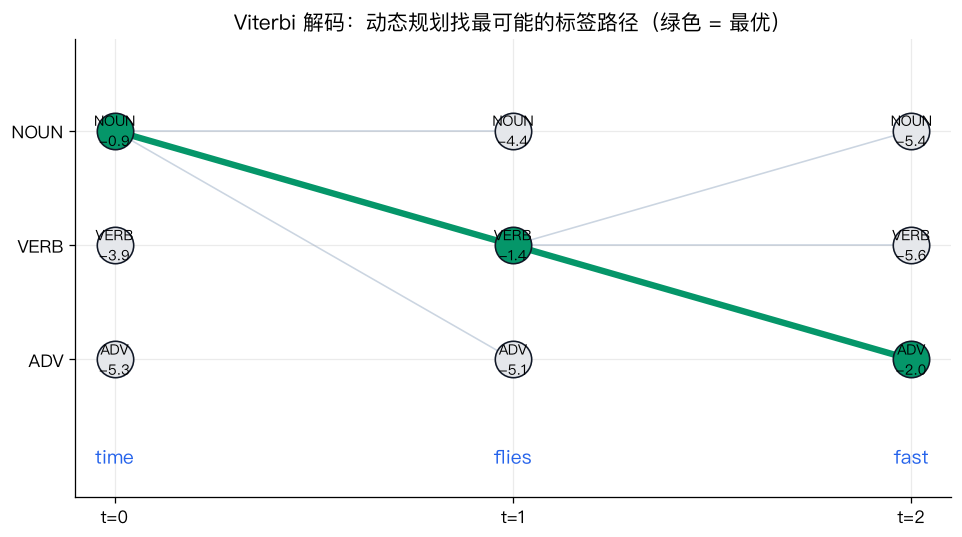

In [40]:
# ------------------------------------------------------------
# Step 5. 把 Viterbi 的 DP 网格画出来
# ------------------------------------------------------------
# 每列一个词（时间 t），每行一个候选状态。
# 绿色圆点是最优路径上的状态，绿色粗线是最终回溯出来的最优标签序列。
# 灰色细线是每个状态的“最佳上一步”，它就是 back pointer 保存的东西。
fig, ax = plt.subplots(figsize=(8.5, 4.8))
state_y = {s: i for i, s in enumerate(states[::-1])}

for t, word in enumerate(obs):
    for s in states:
        y = state_y[s]
        on_path = path[t] == s
        ax.scatter(t, y, s=520, color=COLORS["green"] if on_path else "#e5e7eb",
                   edgecolor="#111827", linewidth=1.0, zorder=3)
        ax.text(t, y, f"{s}\n{dp[t][s]:.1f}", ha="center", va="center", fontsize=9)
    ax.text(t, -0.85, word, ha="center", va="center", fontsize=12, color=COLORS["blue"])

for t in range(1, len(obs)):
    for s in states:
        prev = back[t][s]
        ax.plot([t - 1, t], [state_y[prev], state_y[s]], color="#cbd5e1", linewidth=1, zorder=1)

for t in range(1, len(obs)):
    ax.plot([t - 1, t], [state_y[path[t - 1]], state_y[path[t]]],
            color=COLORS["green"], linewidth=4, zorder=2)

ax.set_xticks(range(len(obs)))
ax.set_xticklabels([f"t={i}" for i in range(len(obs))])
ax.set_yticks(list(state_y.values()))
ax.set_yticklabels(list(state_y.keys()))
ax.set_title("Viterbi 解码：动态规划找最可能的标签路径（绿色 = 最优）")
ax.set_ylim(-1.2, len(states) - 0.2)
plt.tight_layout()
plt.show()

### 小结：HMM（隐马尔可夫模型）+ Viterbi（维特比算法）只做了两件事

1. **建模**：把“整条标签序列 + 整句词”的概率拆成 起始 × Π 转移 × Π 发射。
2. **解码**：用动态规划在 $O(T\cdot|S|^2)$ 时间里挑出总得分最高的那条路径。

这已经足够解决 POS（词性标注）、语音识别里的音素解码、简单的 NER（命名实体识别）等任务。但它有一个明显的短板：只吃“上一个标签 + 当前词”两条信息，任何更丰富的线索都塞不进去。这就是下一小节要引出 CRF（条件随机场）的动力。

> **再回一下第 3 章**：HMM 里“$P(y_t \mid y_{t-1})$ 只看上一步”的部分，跟第 3 章 bigram 的马尔可夫假设是**完全同构**的——都是拿一条一阶马尔可夫链在建模“下一个符号”。区别只是 HMM 在这条链的每个节点上**多挂了一层观测发射** $P(x_t \mid y_t)$，把“词”作为隐藏标签的“影子”暴露出来。你可以把 HMM 直观地读成：“一条 bigram 链跑在隐藏标签上 + 每个隐藏标签再吐出一个可见词”。

### 从 HMM（隐马尔可夫模型）到 CRF（条件随机场）：为什么还不够

HMM 的“得分”只由两类概率决定：转移 $P(y_t \mid y_{t-1})$ 和发射 $P(x_t \mid y_t)$。但真实 NLP 任务里，一个词是什么标签往往还依赖别的线索：

- 当前词是不是**大写开头**？（大写往往是人名/地名）
- 当前词的**后缀**是不是 `-ing / -ed / -ly`？（提示词性）
- 前一个词是不是 `Mr.` / `Dr.` / `in` / `the`？
- 当前词在**领域词典**（比如公司名列表）里吗？
- 当前词的**词形本身**（不只是概率）

要把这些特征都塞进 HMM 是很别扭的：HMM 假设“词只由当前标签生成”，一旦引入这些额外特征，独立性假设就破了，概率也不好归一化。

**CRF（Conditional Random Field，条件随机场）** 换了个思路：

- **不再让标签"生成"词**，而是**直接给整条标签路径打一个分数**。
- 分数由任意多个"特征函数（feature function）"贡献加起来。
- 最后对**所有候选路径**做一次 softmax（归一化指数函数）归一化，得到 $P(y \mid x)$。

一句话总结区别：

| | HMM（隐马尔可夫模型） | CRF（条件随机场） |
|--|-----|-----|
| 建模对象 | $P(x, y)$（联合分布，生成式 generative） | $P(y \mid x)$（条件分布，判别式 discriminative） |
| 分数构造 | 一堆概率相乘 | 一堆特征权重相加（再取指数） |
| 能吃复杂特征吗 | 很难 | 很容易，特征想加多少加多少 |
| 归一化 | 每一步局部 | 对整条候选路径全局 softmax |

### CRF 的打分公式（不用怕，就是加法）

对一条候选路径 $y = (y_1, \dots, y_T)$，CRF 给它的“原始分”是：

$$\text{score}(y, x) = \sum_{t} \sum_{k} w_k \, f_k(y_{t-1}, y_t, x, t)$$

其中：

- $x = (x_1, \dots, x_T)$ 是**整句输入词序列**（observation sequence），例如 `x = ["time", "flies", "fast"]`，$T$ 是句子长度。注意这里传的是**整句 $x$**，不是单个词 $x_t$ —— 这是 CRF 相对 HMM 的一大自由度：特征函数在位置 $t$ 可以随意去看 $x$ 的任何地方（$x_{t-2}$、$x_{t+1}$、句首大写、后缀 `-ly`……都行），不像 HMM 只能靠 $y_t$ 生成 $x_t$。
- $t$ 是当前位置（$t=1,\dots,T$），$y_{t-1}, y_t$ 是相邻两个标签；$y_0$ 一般定义成一个特殊的"BOS（Begin Of Sequence）"哨兵符。
- $k$ 是**特征编号**（feature index）。你事先设计好一个特征库 $\{f_1, f_2, \dots, f_K\}$，其中 $K$ 是特征总数，$k \in \{1,2,\dots,K\}$ 就是"第几号特征"。每个 $f_k$ 单独判断一件事、单独配一个权重 $w_k$。实际系统里 $K$ 常常是几十万到几百万。举 3 个具体的：
  - $f_1(y_{t-1}, y_t, x, t) = \mathbb{1}[x_t = \text{time} \land y_t = \text{NOUN}]$，学到 $w_1 = +2.1$（喜欢"time 打成 NOUN"）。
  - $f_2(y_{t-1}, y_t, x, t) = \mathbb{1}[y_{t-1} = \text{NOUN} \land y_t = \text{VERB}]$，学到 $w_2 = +1.4$（喜欢 NOUN→VERB 这种转移）。
  - $f_3(y_{t-1}, y_t, x, t) = \mathbb{1}[x_t \text{ 以 -ly 结尾} \land y_t = \text{ADV}]$，学到 $w_3 = +3.0$。
- $f_k(y_{t-1}, y_t, x, t)$ 是**特征函数（feature function）**，返回 0/1 或一个数值。上面例子里全是 0/1 指示函数，命中当前上下文就返回 1。
- $w_k$ 是这个特征学到的**权重（weight）**：正数表示喜欢，负数表示讨厌，训练时用梯度上升学出来。
- 求和跑遍所有位置 $t$（$T$ 个）和所有特征编号 $k$（$K$ 个）。可以把 $\text{score}(y,x)$ 想成"沿着句子走一遍，每走一步就把当前上下文击中的所有特征的权重加起来"。

真正的条件概率再做一次归一化：

$$P(y \mid x) = \frac{\exp(\text{score}(y, x))}{\sum_{y'} \exp(\text{score}(y', x))}$$

分母 $Z(x) = \sum_{y'} \exp(\text{score}(y', x))$ 叫**配分函数（partition function，来自统计物理，含义是"总量归一化因子"）**，跑遍所有可能的标签序列。听起来是天文数字，但实际上和 Viterbi 类似，可以用**前向-后向算法（forward-backward algorithm）**在 $O(T \cdot |S|^2)$ 时间里算出来。

下面的代码把这套“**特征命中 → 加权 → 求指数 → 归一化**”的最小流程演示一遍。

In [41]:
# ------------------------------------------------------------
# 一个极简 CRF：手写特征权重，看清"打分 -> 归一化"两步流程
# ------------------------------------------------------------
# 在真实 CRF 里，特征权重是通过最大似然从训练数据学出来的。
# 这里我们把它们硬编码，方便你看清"每一条特征贡献多少分"。
#
# 我们把特征分成三大类，分别对应 HMM 里学不到的三种线索：
#   1) ("word=xxx", tag)        -> 词-标签特征（相当于 HMM 的发射）
#   2) ("prev=yyy", tag)        -> 标签转移特征（相当于 HMM 的转移）
#   3) 各种"HMM 塞不进来"的自由特征：
#      ("suffix=-ing", tag)     -> 后缀线索（`running` 更像 VERB）
#      ("suffix=-ed",  tag)     -> 后缀线索（`released` 更像 VERB 过去式）
#      ("suffix=-ly",  tag)     -> 后缀线索（`quickly` 更像 ADV）
#      ("capitalized", tag)     -> 大写首字母 → 更像 B-ORG / B-PROD 等实体
#      ("shape=Xxxx",  tag)     -> 词形特征（首字母大写 + 其余小写）
#      ("in_dict=ORG", tag)     -> 词典命中（在公司名词典里 → B-ORG）
crf_features = {
    # --- 词面-标签（发射-like） ---
    ("word=time",     "NOUN"):   1.2,
    ("word=flies",    "VERB"):   1.4,
    ("word=fast",     "ADV"):    1.3,
    ("word=Apple",    "B-ORG"):  1.6,
    ("word=iPhone",   "B-PROD"): 1.6,
    ("word=released", "VERB"):   1.1,
    ("word=yesterday","ADV"):    1.2,

    # --- 标签-标签（转移-like） ---
    ("prev=NOUN",  "VERB"):    0.9,
    ("prev=VERB",  "ADV"):     0.8,
    ("prev=B-ORG", "VERB"):    0.7,  # 公司名之后常接动词（Apple released ...）
    ("prev=VERB",  "B-PROD"):  0.6,  # 动词之后常接被发布的产品
    ("prev=B-PROD","ADV"):     0.5,

    # --- 后缀特征（HMM 塞不进来的核心亮点） ---
    ("suffix=-ing", "VERB"):   1.0,  # running / eating / releasing
    ("suffix=-ed",  "VERB"):   0.9,  # released / launched
    ("suffix=-ly",  "ADV"):    1.0,  # quickly / yesterday-like adverbs

    # --- 大小写 / 词形特征（NER 风味） ---
    ("capitalized", "B-ORG"):  0.9,  # Apple / Google / Microsoft
    ("capitalized", "B-PROD"): 0.7,  # iPhone / Kindle
    ("capitalized", "NOUN"):  -0.2,  # 首字母大写不太像普通名词
    ("shape=Xxxx",  "B-ORG"):  0.5,  # 首大写 + 后续小写：像专有名词

    # --- 词典命中（工业界 CRF 常用的强特征） ---
    ("in_dict=ORG",  "B-ORG"):  1.5,
    ("in_dict=PROD", "B-PROD"): 1.5,
}

# 一个小小的"公司名 / 产品名词典"，模拟工业界的 gazetteer
ORG_DICT  = {"Apple", "Google", "Microsoft", "ByteDance"}
PROD_DICT = {"iPhone", "Kindle", "Pixel"}


def word_shape(w):
    # 简化版词形：只区分"首字母大写 + 其余小写"这一种最有信号的形态
    if len(w) >= 2 and w[0].isupper() and w[1:].islower():
        return "Xxxx"
    return "other"


def active_features(word, tag, prev_tag=None):
    # 列出这条 (word, tag[, prev_tag]) 在当前特征表里可能命中的所有 key。
    keys = [(f"word={word}", tag)]
    # 后缀特征：只挑三种最典型的后缀
    for suf in ("-ing", "-ed", "-ly"):
        if word.lower().endswith(suf.lstrip("-")):
            keys.append((f"suffix={suf}", tag))
    # 大小写 / 词形
    if word[:1].isupper():
        keys.append(("capitalized", tag))
    keys.append((f"shape={word_shape(word)}", tag))
    # 词典命中
    if word in ORG_DICT:
        keys.append(("in_dict=ORG", tag))
    if word in PROD_DICT:
        keys.append(("in_dict=PROD", tag))
    # 转移特征
    if prev_tag is not None:
        keys.append((f"prev={prev_tag}", tag))
    return keys


candidate_paths = [
    ["NOUN", "VERB", "ADV"],   # 我们预期的最优
    ["VERB", "NOUN", "ADV"],
    ["NOUN", "NOUN", "VERB"],
]


def crf_toy_score(words, tags):
    # 给一条候选标签序列打分：把命中的特征权重加起来。
    # 注意这里"命中"包含了 word / suffix / capitalized / shape / in_dict 五大类线索——
    # 这些都是 HMM 装不进的"自由特征"。
    score = 0.0
    fired = []
    for t, (word, tag) in enumerate(zip(words, tags)):
        prev_tag = tags[t - 1] if t > 0 else None
        for key in active_features(word, tag, prev_tag):
            if key in crf_features:
                score += crf_features[key]
                fired.append((key, crf_features[key]))
    return score, fired


print("Step A：给几条候选路径打分（列出它们命中了哪些特征）\n")
for cand in candidate_paths:
    score, fired = crf_toy_score(obs, cand)
    print(f"path = {cand}")
    print(f"  score = {score:.2f}  <- 命中特征加起来")
    for key, w in fired:
        print(f"     + {key}  w = {w}")
    print()

Step A：给几条候选路径打分（列出它们命中了哪些特征）

path = ['NOUN', 'VERB', 'ADV']
  score = 5.60  <- 命中特征加起来
     + ('word=time', 'NOUN')  w = 1.2
     + ('word=flies', 'VERB')  w = 1.4
     + ('prev=NOUN', 'VERB')  w = 0.9
     + ('word=fast', 'ADV')  w = 1.3
     + ('prev=VERB', 'ADV')  w = 0.8

path = ['VERB', 'NOUN', 'ADV']
  score = 1.30  <- 命中特征加起来
     + ('word=fast', 'ADV')  w = 1.3

path = ['NOUN', 'NOUN', 'VERB']
  score = 2.10  <- 命中特征加起来
     + ('word=time', 'NOUN')  w = 1.2
     + ('prev=NOUN', 'VERB')  w = 0.9



In [42]:
# ------------------------------------------------------------
# Step B：把 3^3 = 27 条候选路径全部打分，做全局归一化
# ------------------------------------------------------------
# 这就是"CRF 是判别式全局归一化"的字面意思：
#   P(y | x) = exp(score(y)) / Σ_y' exp(score(y'))
all_paths = list(itertools.product(states, repeat=len(obs)))
scored = []
for cand in all_paths:
    score, _ = crf_toy_score(obs, list(cand))
    scored.append((list(cand), score, math.exp(score)))

Z = sum(exp_s for _, _, exp_s in scored)
print(f"候选路径总数 |S|^T = {len(states)}^{len(obs)} = {len(all_paths)}")
print(f"配分函数 Z(x) = Σ exp(score(path)) = {Z:.3f}\n")

print("Top-5 by CRF probability:")
for cand, score, exp_score in sorted(scored, key=lambda x: x[1], reverse=True)[:5]:
    prob = exp_score / Z
    print(f"  path = {cand}  score = {score:.2f}  P(y|x) = {prob:.3f}")

print("\n注意：")
print(" - 分数越高的路径，归一化后概率越大，但每条概率都在 [0,1] 之间，且总和 = 1。")
print(" - 我们这里只挂了几十个特征；真实 CRF 可能有上万个特征，"
      "包括后缀、大小写、词典命中、上下文 n-gram、词形等等。")
print(" - 训练 CRF = 通过最大化训练集上正确路径的对数概率来学习每个 w_k。")

候选路径总数 |S|^T = 3^3 = 27
配分函数 Z(x) = Σ exp(score(path)) = 494.145

Top-5 by CRF probability:
  path = ['NOUN', 'VERB', 'ADV']  score = 5.60  P(y|x) = 0.547
  path = ['VERB', 'VERB', 'ADV']  score = 3.50  P(y|x) = 0.067
  path = ['ADV', 'VERB', 'ADV']  score = 3.50  P(y|x) = 0.067
  path = ['NOUN', 'VERB', 'NOUN']  score = 3.50  P(y|x) = 0.067
  path = ['NOUN', 'VERB', 'VERB']  score = 3.50  P(y|x) = 0.067

注意：
 - 分数越高的路径，归一化后概率越大，但每条概率都在 [0,1] 之间，且总和 = 1。
 - 我们这里只挂了几十个特征；真实 CRF 可能有上万个特征，包括后缀、大小写、词典命中、上下文 n-gram、词形等等。
 - 训练 CRF = 通过最大化训练集上正确路径的对数概率来学习每个 w_k。


### 让 CRF 真的把丰富特征吃进去：`Apple released iPhone yesterday`

上面的 `time flies fast` 只用到"词 + 转移"两类特征，跟 HMM 差别不大。要让 CRF 的"能吃自由特征"这件事真的显出来，我们换一个更 NER 风味的句子：

```text
Apple    released   iPhone   yesterday
B-ORG    VERB       B-PROD   ADV
```

关键点在于：

- `Apple` 是**首字母大写**，还命中了公司名词典 `ORG_DICT`，所以 `capitalized + shape=Xxxx + in_dict=ORG` 三条特征同时点亮，把 `B-ORG` 拉起来。
- `released` 是 `-ed` 结尾的动词，`suffix=-ed → VERB` 直接加分。
- `iPhone` 命中 `PROD_DICT`，加上首字母大写，直接把 `B-PROD` 顶到最高。
- `yesterday` 命中 `word=yesterday → ADV`。

**HMM 在这句上会栽跟头**：它的发射表里根本没有 `Apple / released / iPhone / yesterday`，也没有 `B-ORG / B-PROD` 这两个状态；就算强行让它做，它也只会在 `NOUN / VERB / ADV` 里瞎选。CRF 则用**词形 / 后缀 / 词典**这些**跨越具体词面**的特征，直接把 NER 需要的 `B-ORG / B-PROD` 拉起来——这就是"能吃丰富特征"的实际收益。

In [43]:
# ------------------------------------------------------------
# HMM vs CRF：同一句话上"HMM 有心无力 vs CRF 顺手拿下"
# ------------------------------------------------------------
# 场景：一句典型的 NER 句子 `Apple released iPhone yesterday`
# HMM 的发射表根本没见过这些词，也没有 B-ORG / B-PROD 这两个标签。
# CRF 用 suffix / capitalized / in_dict 等特征照样能算。

ner_sentence = ["Apple", "released", "iPhone", "yesterday"]

# ---- HMM 视角：只有 NOUN/VERB/ADV 3 个标签，未见词只能给一个极小的兜底概率 ----
hmm_smooth = 1e-3

def hmm_score(words, tags):
    # 只用第 1 步定义的 start_p / trans_p / emit_p；未见词回退到极小概率
    def e(tag, w):
        return emit_p[tag].get(w, hmm_smooth)
    logp = math.log(start_p[tags[0]]) + math.log(e(tags[0], words[0]))
    for t in range(1, len(words)):
        logp += math.log(trans_p[tags[t - 1]][tags[t]]) + math.log(e(tags[t], words[t]))
    return logp


hmm_best, hmm_best_score = None, -1e18
for cand in itertools.product(states, repeat=len(ner_sentence)):
    s = hmm_score(ner_sentence, list(cand))
    if s > hmm_best_score:
        hmm_best_score, hmm_best = s, list(cand)

print("HMM 视角（标签集只有 NOUN/VERB/ADV，未见词兜底概率 1e-3）：")
print("  best tags :", hmm_best)
print(f"  logP(y,x) : {hmm_best_score:+.3f}")
print("  评价       : HMM 连 B-ORG / B-PROD 这两个标签都没有，")
print("               `Apple / iPhone` 这些专有名词只能被硬塞进 NOUN 里。\n")

# ---- CRF 视角：标签集扩展到 NER 需要的形状，用刚才定义的 crf_toy_score ----
crf_states = ["B-ORG", "B-PROD", "NOUN", "VERB", "ADV", "O"]

best_crf, best_crf_score = None, -1e18
for cand in itertools.product(crf_states, repeat=len(ner_sentence)):
    s, _ = crf_toy_score(ner_sentence, list(cand))
    if s > best_crf_score:
        best_crf_score, best_crf = s, list(cand)

print("CRF 视角（标签集含 B-ORG / B-PROD，特征含 suffix / capitalized / in_dict）：")
print("  best tags :", best_crf)
print(f"  score     : {best_crf_score:+.3f}")

# 展示 CRF 在最优路径上到底命中了哪些"HMM 装不进"的自由特征
_, fired = crf_toy_score(ner_sentence, best_crf)
free_kinds = ("suffix=", "capitalized", "shape=", "in_dict=")
print("\n最优路径上命中的自由特征（HMM 装不进的部分）：")
for key, w in fired:
    (feat, tag) = key
    if any(feat.startswith(k) for k in free_kinds):
        print(f"  + {key}  w = {w}")

print("\n结论：")
print(" - HMM 只有 3 个词性标签、没见过这些词 -> 只能给出词性级别的粗糙答案。")
print(" - CRF 有 B-ORG / B-PROD，还能用 suffix / capitalized / in_dict 这些跨词面特征，")
print("   自然把 `Apple / iPhone` 定位到实体、把 `released / yesterday` 定位到 VERB / ADV。")
print(" - 这才是 'CRF 能吃丰富特征' 的实际收益：**同样是解码，特征越丰富、")
print("   标签空间越大，CRF 越占优**。")

HMM 视角（标签集只有 NOUN/VERB/ADV，未见词兜底概率 1e-3）：
  best tags : ['NOUN', 'VERB', 'ADV', 'NOUN']
  logP(y,x) : -29.230
  评价       : HMM 连 B-ORG / B-PROD 这两个标签都没有，
               `Apple / iPhone` 这些专有名词只能被硬塞进 NOUN 里。

CRF 视角（标签集含 B-ORG / B-PROD，特征含 suffix / capitalized / in_dict）：
  best tags : ['B-ORG', 'VERB', 'B-PROD', 'ADV']
  score     : +12.600

最优路径上命中的自由特征（HMM 装不进的部分）：
  + ('capitalized', 'B-ORG')  w = 0.9
  + ('shape=Xxxx', 'B-ORG')  w = 0.5
  + ('in_dict=ORG', 'B-ORG')  w = 1.5
  + ('suffix=-ed', 'VERB')  w = 0.9
  + ('in_dict=PROD', 'B-PROD')  w = 1.5

结论：
 - HMM 只有 3 个词性标签、没见过这些词 -> 只能给出词性级别的粗糙答案。
 - CRF 有 B-ORG / B-PROD，还能用 suffix / capitalized / in_dict 这些跨词面特征，
   自然把 `Apple / iPhone` 定位到实体、把 `released / yesterday` 定位到 VERB / ADV。
 - 这才是 'CRF 能吃丰富特征' 的实际收益：**同样是解码，特征越丰富、
   标签空间越大，CRF 越占优**。


### 手算一次 NER：`Apple / released / iPhone` 的 BIO 转移 + 发射 + 一步 Viterbi

前面把 CRF 讲透了，但 NER 一直只在表格里露脸。现在我们把它真的落地一次：拿一个 3 词的小 NER 例子 `Apple released iPhone`，手工写出转移矩阵、发射矩阵，然后**手算一步 Viterbi**，看清楚 `B-ORG / O / B-PROD` 这条路径是怎么"赢"出来的。

- **标签集**：`{ B-ORG, B-PROD, O }`（`O` = Outside，实体外）。
- **BIO 约定**：`B-XXX` 表示实体的第一个词，`I-XXX` 表示实体内部续接的词，`O` 表示不属于任何实体。这里我们把每个实体都放成单个词，所以只用到 `B-*` 和 `O`。
- **一句话**：$x = (\text{Apple}, \text{released}, \text{iPhone})$；我们希望模型给出的最优标签是 $y^\star = (\text{B-ORG}, \text{O}, \text{B-PROD})$。

**起始概率 $\pi(y_1)$**（NER 语料里第一个位置更常见的标签）：

| $y_1$ | $\pi$ |
|-------|------|
| B-ORG  | 0.45 |
| B-PROD | 0.05 |
| O      | 0.50 |

**转移概率 $A[y_{t-1}][y_t]$**：`B-ORG → O` 很常见（"公司名后面接普通词"），`O → B-PROD` 也很常见（"普通词之后紧跟产品名"）：

| ↓ 上一步 \ 下一步 → | B-ORG | B-PROD | O |
|--|--|--|--|
| B-ORG  | 0.05 | 0.10 | **0.85** |
| B-PROD | 0.05 | 0.05 | 0.90 |
| O      | 0.20 | **0.30** | 0.50 |

**发射概率 $B[y][x]$**：只要词典 + 大小写命中，实体标签的发射就应该压过 `O`：

| 词 \ 标签 | B-ORG | B-PROD | O |
|--|--|--|--|
| Apple    | **0.80** | 0.10 | 0.10 |
| released | 0.05     | 0.05 | **0.90** |
| iPhone   | 0.05     | **0.85** | 0.10 |

**手算一步 Viterbi**（$t=2$，词 `iPhone`，问"当前是 `B-PROD` 时最优的上一步是谁"）：

首先算 $t=0$、$t=1$ 的 dp 值。为了直接看到数值，我们全程用 log：

- $\text{dp}[0][\text{B-ORG}] = \log \pi(\text{B-ORG}) + \log B[\text{B-ORG}][\text{Apple}]$
  $= \ln 0.45 + \ln 0.80 = -0.799 + (-0.223) = -1.022$
- $\text{dp}[0][O]      = \ln 0.50 + \ln 0.10 = -0.693 + (-2.303) = -2.996$
- $\text{dp}[0][\text{B-PROD}] = \ln 0.05 + \ln 0.10 = -2.996 + (-2.303) = -5.298$

$t=1$（词 `released`）：只关心 `O`，因为发射概率里 `released → O` 是 0.90，是主选。
- 上一步 = B-ORG：$-1.022 + \ln 0.85 + \ln 0.90 = -1.022 -0.163 -0.105 = -1.290$ ✅
- 上一步 = O：      $-2.996 + \ln 0.50 + \ln 0.90 = -2.996 -0.693 -0.105 = -3.794$
- 上一步 = B-PROD：$-5.298 + \ln 0.90 + \ln 0.90 = -5.298 -0.105 -0.105 = -5.508$

于是 $\text{dp}[1][O] = -1.290$，back pointer 指向 `B-ORG`。

$t=2$（词 `iPhone`），问"当前是 `B-PROD`"：
- 上一步 = O：      $-1.290 + \ln 0.30 + \ln 0.85 = -1.290 -1.204 -0.163 = -2.657$ ✅（赢家）
- 上一步 = B-ORG：$-1.022 + \ln 0.10 + \ln 0.85 = -1.022 -2.303 -0.163 = -3.488$
- 上一步 = B-PROD：$-5.298 + \ln 0.05 + \ln 0.85 = -5.298 -2.996 -0.163 = -8.457$

所以 $\text{dp}[2][\text{B-PROD}] = -2.657$，back pointer 指向 `O`。从 `B-PROD` 沿 back pointer 回溯：`B-PROD ← O ← B-ORG`，反转得到最优路径 **`B-ORG / O / B-PROD`**——正是我们要的 NER 结果。下面的代码把这一路手算再机器复算一遍，你可以自己核对每个数字。

In [44]:
# ------------------------------------------------------------
# NER 手算 -> 机器复算：`Apple / released / iPhone` 的一步 Viterbi
# ------------------------------------------------------------
# 用最小 3 词 + 3 标签 (B-ORG / B-PROD / O) 的 HMM 完整跑一遍 Viterbi，
# 与上面 md 里的手算数字对齐。
ner_states = ["B-ORG", "B-PROD", "O"]
ner_obs    = ["Apple", "released", "iPhone"]

ner_start = {"B-ORG": 0.45, "B-PROD": 0.05, "O": 0.50}
ner_trans = {
    "B-ORG":  {"B-ORG": 0.05, "B-PROD": 0.10, "O": 0.85},
    "B-PROD": {"B-ORG": 0.05, "B-PROD": 0.05, "O": 0.90},
    "O":      {"B-ORG": 0.20, "B-PROD": 0.30, "O": 0.50},
}
ner_emit = {
    "B-ORG":  {"Apple": 0.80, "released": 0.05, "iPhone": 0.05},
    "B-PROD": {"Apple": 0.10, "released": 0.05, "iPhone": 0.85},
    "O":      {"Apple": 0.10, "released": 0.90, "iPhone": 0.10},
}

def ner_viterbi(observations):
    dp = [{s: math.log(ner_start[s]) + math.log(ner_emit[s][observations[0]])
           for s in ner_states}]
    back = [{s: None for s in ner_states}]
    for t in range(1, len(observations)):
        cur, cur_back = {}, {}
        for s in ner_states:
            best_prev, best_score = None, -1e18
            for prev in ner_states:
                score = (dp[t - 1][prev]
                         + math.log(ner_trans[prev][s])
                         + math.log(ner_emit[s][observations[t]]))
                if score > best_score:
                    best_score, best_prev = score, prev
            cur[s] = best_score
            cur_back[s] = best_prev
        dp.append(cur)
        back.append(cur_back)
    last = max(dp[-1], key=dp[-1].get)
    path = [last]
    for t in range(len(observations) - 1, 0, -1):
        path.append(back[t][path[-1]])
    return dp, back, list(reversed(path))


ner_dp, ner_back, ner_path = ner_viterbi(ner_obs)

print("NER DP 表（每格 = 到该词为止 + 该标签的 log 概率）：")
print(f"{'':<8}" + "".join(f"{w:>12}" for w in ner_obs))
for s in ner_states:
    print(f"{s:<8}" + "".join(f"{ner_dp[t][s]:>12.3f}" for t in range(len(ner_obs))))

print("\nback pointer（每格 = 到该词 + 该标签时最优的上一步）：")
print(f"{'':<8}" + "".join(f"{w:>12}" for w in ner_obs))
for s in ner_states:
    print(f"{s:<8}" + "".join(f"{str(ner_back[t][s]):>12}" for t in range(len(ner_obs))))

print("\n最优 NER 路径：", ner_path)
print("期望路径      : ['B-ORG', 'O', 'B-PROD']")
assert ner_path == ["B-ORG", "O", "B-PROD"], "手算与机器算结果应当一致"

# 手算一格核对：t=2, 当前 = B-PROD，检验三个候选上一步的分数
print("\n手算核对 dp[t=2][B-PROD] 的三条候选：")
for prev in ner_states:
    score = (ner_dp[1][prev]
             + math.log(ner_trans[prev]["B-PROD"])
             + math.log(ner_emit["B-PROD"]["iPhone"]))
    marker = "  <- 赢家" if prev == ner_back[2]["B-PROD"] else ""
    print(f"  prev = {prev:<7}  score = {score:+.3f}{marker}")

NER DP 表（每格 = 到该词为止 + 该标签的 log 概率）：
               Apple    released      iPhone
B-ORG         -1.022      -7.013      -5.895
B-PROD        -5.298      -6.320      -2.656
O             -2.996      -1.290      -4.285

back pointer（每格 = 到该词 + 该标签时最优的上一步）：
               Apple    released      iPhone
B-ORG           None       B-ORG           O
B-PROD          None       B-ORG           O
O               None       B-ORG           O

最优 NER 路径： ['B-ORG', 'O', 'B-PROD']
期望路径      : ['B-ORG', 'O', 'B-PROD']

手算核对 dp[t=2][B-PROD] 的三条候选：
  prev = B-ORG    score = -9.478
  prev = B-PROD   score = -9.478
  prev = O        score = -2.656  <- 赢家


### HMM（隐马尔可夫模型）/ MEMM（最大熵马尔可夫模型）/ CRF（条件随机场）三兄弟对比

三者都用来做序列标注，区别可以用“**归一化在哪一层**”来记：

| 模型 | 中文名 | 建模的量 | 归一化范围 | 能吃自由特征？ | 典型问题 |
|------|--------|----------|------------|----------------|----------|
| HMM (Hidden Markov Model) | 隐马尔可夫模型 | $P(x, y)$（生成式） | 每个 $P(x_t \mid y_t)$、$P(y_t \mid y_{t-1})$ 本身就是概率 | 很难 | 特征太少 |
| MEMM (Maximum-Entropy Markov Model) | 最大熵马尔可夫模型 | $P(y_t \mid y_{t-1}, x)$（每步一个分类器） | 每步局部 softmax | 可以 | **label bias（标签偏置）**：偏向可走路径少的状态 |
| CRF (Conditional Random Field) | 条件随机场 | $P(y \mid x)$（判别式） | 对整条序列做一次全局 softmax | 可以 | 特征工程重、训练更慢 |

**Label bias（标签偏置）直觉**：MEMM 在每一步都要求“从这个状态出去的概率总和 = 1”。如果某个状态几乎只有一条出路，那条出路会天然拿到接近 1 的概率——即使它其实很不合理。CRF 把归一化推迟到整条路径级别，就避开了这个陷阱。

### 和 Word2Vec 的关系

**Word2Vec 不是 CRF（条件随机场）的替代品，而是它的"输入升级"。**

- HMM / CRF 解决的问题是：**标签之间的结构依赖**（`I-ORG` 不能凭空出现、名词后面倾向动词……）。
- Word2Vec 解决的问题是：**单个词怎么表示成一个稠密向量（dense vector）**（让 `king` 和 `queen` 在向量空间里更近）。

这两件事是正交的，可以叠加使用：

```text
词序列 --(Word2Vec / 后来的 BERT)--> 稠密向量
       --(BiLSTM 双向长短期记忆网络 / Transformer)--> 上下文向量
       --(CRF 条件随机场)--> 标签序列
```

这就是 2015 年前后经典的 **BiLSTM-CRF（双向 LSTM + 条件随机场）** 命名实体识别范式：底层用词向量替代人工特征，顶层还是 CRF 负责“标签序列不能乱来”这件事。

### 章末回顾：HMM/CRF 撑起了"结构化标签"，但没撑起"词的表示"

回看整章，我们做的事情本质上是给"标签序列"这个**结构化输出空间**建模：HMM 用一阶马尔可夫链 + 发射，CRF 用任意特征 + 全局归一化，两者都在解决"标签之间怎么依赖"这个问题。这是它们最大的贡献——把"输出"从"一个类别"升级成了"一整条互相约束的标签序列"。

但**词本身的表示**在这套体系里几乎没有被触碰：`word=time` 和 `word=Apple` 只是两个互不相关的 one-hot 维度，`car` 和 `automobile` 在 HMM / CRF 眼里是完全独立的两个特征，没有任何"语义靠近"关系。想让 `car` 和 `automobile` 在向量空间里天然靠近，要一直等到第 9 章 NNLM（Neural Network Language Model，神经网络语言模型）把"词"作为一层可学习的**共享 embedding**放进网络里——那才是"把词本身拉进连续空间"的第一步，也是第 10 章 Word2Vec 之所以能存在的直接前史。

一句话记住：**HMM/CRF 解决"标签空间的结构"，NNLM/Word2Vec 解决"词面空间的表示"，二者互补，缺一不可**。

## 7 · 主题模型：LSA（潜在语义分析）、PLSA（概率潜在语义分析）、LDA（潜在狄利克雷分配）

### 一句话直觉

想象你面前摊着一摞报纸剪报：有体育、医疗、金融、科技四类。你现在想让机器自动做两件事：

1. 找出这摞剪报背后**有哪些主题**（Topic）——不是靠人贴的标签，而是靠"哪些词经常一起出现"。
2. 判断两篇文档**主题相近**——即使它们用的词完全不同（比如一篇用 `car`，另一篇用 `automobile`）。

第 4 章的 TF-IDF 已经能把文档变成向量，但它是**词面级**的：`car` 和 `automobile` 会被当成两个毫不相干的维度，只要拼写不一样，向量就完全对不上。**主题模型（Topic Model）**要解决的就是这件事：假设每篇文档背后藏着几个**潜在主题**，词面只是这些主题"抽"出来的表面样本。

本章按"三级火箭"顺序讲：

- **LSA（Latent Semantic Analysis，潜在语义分析）**：用线性代数（SVD 奇异值分解）压缩文档-词矩阵，得到低维语义空间。第一次让 `car` 和 `automobile` 在同一维度上被拉近。
- **PLSA（Probabilistic Latent Semantic Analysis，概率潜在语义分析）**：把"主题"变成一个显式的概率变量 $z$，公式化 `P(w|d) = Σ_z P(w|z)P(z|d)`。
- **LDA（Latent Dirichlet Allocation，潜在狄利克雷分配）**：在 PLSA 之上再加一层 **Dirichlet 先验（Dirichlet prior，狄利克雷先验）**，让模型能自然处理新文档、生成新文档，也更抗过拟合。

### 关键中英文对照

| 英文 / 缩写 | 中文名 | 一句话说明 |
|-------------|--------|------------|
| Topic Model | 主题模型 | 从文档-词共现里挖出潜在"话题"的一类模型 |
| Latent Topic $z$ | 潜在主题 | 观察不到的"话题变量"，把词和文档连起来 |
| LSA (Latent Semantic Analysis) | 潜在语义分析 | 用 SVD 把文档-词矩阵压到低维"语义空间" |
| SVD (Singular Value Decomposition) | 奇异值分解 | 把任意矩阵 $A$ 拆成 $U \Sigma V^\top$ 三部分 |
| TruncatedSVD | 截断奇异值分解 | 只留最大的 $k$ 个奇异值，直接给出 $k$ 维近似 |
| PLSA (Probabilistic LSA) | 概率潜在语义分析 | 用概率模型 $P(w\mid d)=\sum_z P(w\mid z)P(z\mid d)$ 解释共现 |
| LDA (Latent Dirichlet Allocation) | 潜在狄利克雷分配 | 在 PLSA 上加狄利克雷先验的生成式主题模型 |
| Dirichlet prior | 狄利克雷先验 | 一种"分布的分布"，专门给概率向量做先验 |
| Generative Model | 生成式模型 | 描述"数据是怎么被造出来的"的一整套概率过程 |
| Posterior $P(z\mid d,w)$ | 后验 | 看到 $d$ 里出现了词 $w$ 后，$z$ 的更新分布 |
| EM (Expectation-Maximization) | 期望最大化 | PLSA/LDA 常用的迭代求解算法：E 步求后验、M 步更新参数 |
| Bag of Words | 词袋 | 忽略词序、只看词频的文档表示 |
| $\alpha, \beta$ | 狄利克雷超参 | 分别控制"文档-主题"和"主题-词"分布的形状 |

### 为什么 TF-IDF 之后还需要主题模型

TF-IDF 之后每篇文档是个 $|V|$ 维稀疏向量（$|V|$ 是词表大小）。有两件事它做不到：

- **同义 / 近义合并**：`car` 和 `automobile` 是两个独立维度。哪怕两篇文档讲的是同一件事，只要一个用 `car`、另一个用 `automobile`，余弦相似度就会低得离谱。
- **抽象话题**：`bank / loan / interest / stock` 明明经常一起讲"金融"，但 TF-IDF 只能各自计数，不会告诉你"它们背后是同一个主题"。

主题模型的想法很朴素：

> 与其在几千维词面上比较，不如假设背后只有几个（比如 $k=4$）主题，把每篇文档投影成一个 $k$ 维"主题分布"，再在这个更小的空间里比较相似度。

### 三个方法在解决什么问题

| 方法 | 想法 | 相对上一版解决了什么 | 又留下了什么问题 |
|------|------|------|--------------------|
| LSA | 对文档-词矩阵做 SVD 截断到 $k$ 维 | 缓解稀疏、把同义词拉近 | 是线性代数，不是概率模型；负值维度难解释 |
| PLSA | 引入潜在主题 $z$：$P(w\mid d)=\sum_z P(w\mid z)P(z\mid d)$ | 每篇文档有真正的"主题混合概率"，可解释 | 每篇训练文档单独学一个 $P(z\mid d)$，新文档无先验、参数随文档数线性增长 |
| LDA | 给 $P(z\mid d)$ 和 $P(w\mid z)$ 都加狄利克雷先验 | 有先验、能生成新文档、更稳更抗过拟合 | 仍是**文档级**主题；对**词级**细粒度语义仍然弱 |

### 7.1 LSA（潜在语义分析）：用 SVD 找"潜在语义空间"

#### SVD 直觉：把矩阵拆成三个部件

任何一个矩阵 $A$（这里就是文档-词矩阵，行是文档、列是词）都能被 **SVD（Singular Value Decomposition，奇异值分解）** 写成：

$$A \;=\; U\,\Sigma\,V^\top$$

用一个非常朴实的类比来记住这三块：

- $U$（文档 × $k$）：**每篇文档在"主题坐标系"里的位置**。
- $\Sigma$（$k \times k$ 对角阵）：**每个主题有多重要**（奇异值就是这个主题的"能量"）。
- $V^\top$（$k$ × 词）：**每个主题由哪些词构成**。

$$\underbrace{A}_{\text{文档}\times\text{词}} \;\approx\; \underbrace{U_k}_{\text{文档}\times k}\;\underbrace{\Sigma_k}_{k\times k}\;\underbrace{V_k^\top}_{k\times\text{词}}$$

只保留前 $k$ 个最大的奇异值，就得到 **TruncatedSVD（截断奇异值分解）**。之所以这样做出来的 $k$ 维空间叫**潜在语义空间（Latent Semantic Space）**，是因为：

- 一维不再对应一个具体的词，而是一组"经常一起出现的词"的加权组合——那就是一个话题。
- 一篇文档在这个空间里的坐标，反映的是**它在各个话题上的占比**。

#### 一个小手算例子（3 篇文档 × 4 个词）

为了看清 SVD 是怎么"把同义词合并到同一维"的，先用一个玩具矩阵。假设我们只有 3 篇文档、4 个词 `car / automobile / bank / loan`，词频矩阵长这样：

$$A = \begin{bmatrix}
2 & 1 & 0 & 0 \\
1 & 2 & 0 & 0 \\
0 & 0 & 2 & 1 \\
\end{bmatrix}$$

肉眼观察：前两篇讲"汽车"，第三篇讲"金融"。SVD 会自动把前两列（`car/automobile`）压到同一个潜在维度，把后两列（`bank/loan`）压到另一个。下一段代码会显式跑一遍并打印分解结果。

In [79]:
# ------------------------------------------------------------
# Step 1. 一个 3 x 4 的玩具文档-词矩阵，肉眼能看出两个主题
# ------------------------------------------------------------
# 行 = 文档，列 = 词 [car, automobile, bank, loan]
# doc 0 / doc 1 讲汽车（car 和 automobile 交替出现，属于同义词）
# doc 2 讲金融（bank + loan）
A_toy = np.array([
    [2.0, 1.0, 0.0, 0.0],
    [1.0, 2.0, 0.0, 0.0],
    [0.0, 0.0, 2.0, 1.0],
])
toy_words = ["car", "automobile", "bank", "loan"]

# 直接调 numpy 的 SVD
U_toy, S_toy, Vt_toy = np.linalg.svd(A_toy, full_matrices=False)
print("奇异值 Σ =", np.round(S_toy, 3))
print("前 2 个奇异值明显更大 -> 只需 2 维就能几乎无损重构 A_toy\n")

k_toy = 2
Uk, Sk, Vtk = U_toy[:, :k_toy], S_toy[:k_toy], Vt_toy[:k_toy, :]
A_approx = Uk @ np.diag(Sk) @ Vtk
print("原矩阵 A =")
print(A_toy)
print("\n只保留前 2 个奇异值后重构 A_approx =")
print(np.round(A_approx, 2))

print("\n每篇文档在 2 维潜在语义空间里的坐标 (U_k * Σ_k):")
doc_coord_toy = Uk * Sk
for i, row in enumerate(doc_coord_toy):
    print(f"  doc {i}: {np.round(row, 3)}")

print("\n每个主题由哪些词构成 (V_k^T 每一行就是一个主题):")
for k_i, comp in enumerate(Vtk):
    parts = ", ".join(f"{toy_words[j]}({comp[j]:+.2f})" for j in range(len(toy_words)))
    print(f"  topic {k_i+1}: {parts}")

print("\n观察：主题 1 在 car 和 automobile 上同号且系数相近 -> 它们被合并到同一潜在维度。")

奇异值 Σ = [3.    2.236 1.   ]
U_toy = [[ 0.70710678  0.         -0.70710678]
 [ 0.70710678  0.          0.70710678]
 [ 0.          1.          0.        ]]
Vt_toy = [[ 0.70710678  0.70710678 -0.          0.        ]
 [-0.         -0.          0.89442719  0.4472136 ]
 [-0.70710678  0.70710678  0.          0.        ]]
前 2 个奇异值明显更大 -> 只需 2 维就能几乎无损重构 A_toy

原矩阵 A =
[[2. 1. 0. 0.]
 [1. 2. 0. 0.]
 [0. 0. 2. 1.]]

只保留前 2 个奇异值后重构 A_approx =
[[1.5 1.5 0.  0. ]
 [1.5 1.5 0.  0. ]
 [0.  0.  2.  1. ]]

每篇文档在 2 维潜在语义空间里的坐标 (U_k * Σ_k):
  doc 0: [2.121 0.   ]
  doc 1: [2.121 0.   ]
  doc 2: [0.    2.236]

每个主题由哪些词构成 (V_k^T 每一行就是一个主题):
  topic 1: car(+0.71), automobile(+0.71), bank(-0.00), loan(+0.00)
  topic 2: car(-0.00), automobile(-0.00), bank(+0.89), loan(+0.45)

观察：主题 1 在 car 和 automobile 上同号且系数相近 -> 它们被合并到同一潜在维度。


#### 用真实 toy corpus 跑一遍 LSA

回到第 0 章那份 sports / medicine / finance / technology 的 16 篇小语料。流程和上面完全一样，只是矩阵更大一点、我们用 `TruncatedSVD`（sklearn 里 LSA 的常用工程实现）直接给出 $k=2$ 的低维坐标。

> 注：LSA 的输入通常是 TF-IDF 矩阵而不是原始词频，这样能压掉 `the / of` 这类高频虚词的干扰。

In [46]:
# ------------------------------------------------------------
# Step 2. 在真实的小语料上做 LSA
# ------------------------------------------------------------
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(docs)                # shape = (16, |V|)
terms_lsa = np.array(tfidf.get_feature_names_out())

# TruncatedSVD(n_components=2) 就是 LSA：直接在稀疏矩阵上求前 2 个潜在维度
lsa = TruncatedSVD(n_components=2, random_state=SEED)
doc_2d = lsa.fit_transform(X)                # doc_2d.shape = (16, 2)

print("TF-IDF 矩阵形状:", X.shape)
print("LSA 降维后形状 :", doc_2d.shape)
print("Explained variance ratio (每维解释了多少方差):",
      np.round(lsa.explained_variance_ratio_, 3))

# 手算验证一下：doc_2d[i] 就是把第 i 篇文档的 TF-IDF 向量投影到 components_ 上
doc_id = 4
manual_coord = X[doc_id].toarray().ravel() @ lsa.components_.T
print(f"\n手算 doc {doc_id} 的坐标 = X[{doc_id}] @ components^T = {np.round(manual_coord, 3)}")
print(f"sklearn 给出的坐标                                = {np.round(doc_2d[doc_id], 3)}  (两者一致)")

print("\n代表文档的 LSA 坐标:")
for i in [0, 4, 8, 12]:
    print(f"  doc {i:>2} ({labels[i]:<10}) -> ({doc_2d[i, 0]:+.3f}, {doc_2d[i, 1]:+.3f})")

print("\n每个潜在维度是由哪些词加权而成 (Top / Bottom 6):")
for k_i, comp in enumerate(lsa.components_):
    pos = comp.argsort()[-6:][::-1]
    neg = comp.argsort()[:6]
    print(f"  dim {k_i+1} 正向: " + ", ".join(f"{terms_lsa[i]}({comp[i]:+.2f})" for i in pos))
    print(f"  dim {k_i+1} 负向: " + ", ".join(f"{terms_lsa[i]}({comp[i]:+.2f})" for i in neg))

TF-IDF 矩阵形状: (16, 73)
LSA 降维后形状 : (16, 2)
Explained variance ratio (每维解释了多少方差): [0.071 0.054]

手算 doc 4 的坐标 = X[4] @ components^T = [0.603 0.071]
sklearn 给出的坐标                                = [0.603 0.071]  (两者一致)

代表文档的 LSA 坐标:
  doc  0 (sports    ) -> (-0.044, +0.438)
  doc  4 (medicine  ) -> (+0.603, +0.071)
  doc  8 (finance   ) -> (+0.410, +0.032)
  doc 12 (technology) -> (+0.017, +0.012)

每个潜在维度是由哪些词加权而成 (Top / Bottom 6):
  dim 1 正向: patient(+0.53), reduced(+0.36), vaccine(+0.25), protected(+0.25), infection(+0.25), treated(+0.24)
  dim 1 负向: won(-0.04), tennis(-0.04), game(-0.04), served(-0.04), fast(-0.04), player(-0.03)
  dim 2 正向: fast(+0.37), player(+0.35), won(+0.33), data(+0.26), served(+0.23), game(+0.23)
  dim 2 负向: bought(-0.01), stock(-0.01), investors(-0.01), price(-0.01), fell(-0.01), studied(-0.00)


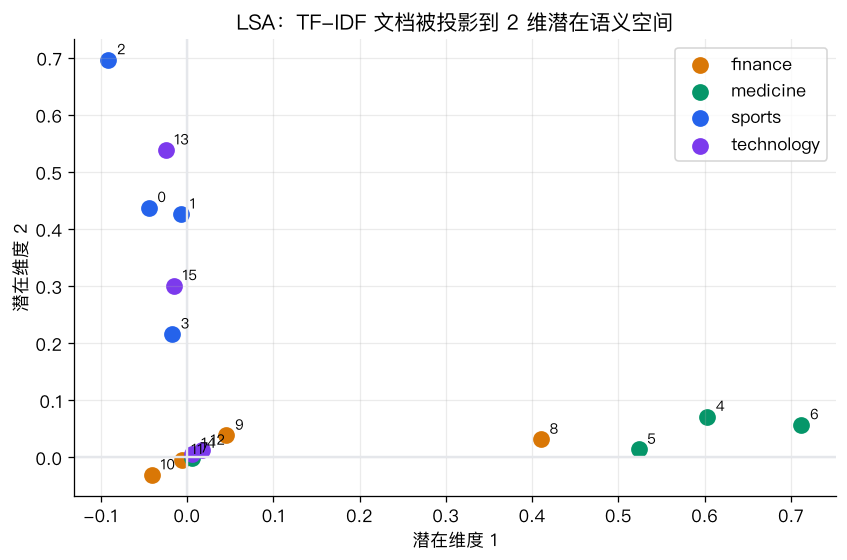

In [47]:
# ------------------------------------------------------------
# Step 3. 把 16 篇文档的 2 维 LSA 坐标画出来
# ------------------------------------------------------------
# 如果 LSA 抓到了主题结构，同类别（同颜色）的点应该聚在一起。
fig, ax = plt.subplots(figsize=(7.5, 5))
label_colors = {
    "sports": COLORS["blue"],
    "medicine": COLORS["green"],
    "finance": COLORS["amber"],
    "technology": COLORS["purple"],
}
for label in sorted(set(labels)):
    idx_l = [i for i, y in enumerate(labels) if y == label]
    ax.scatter(doc_2d[idx_l, 0], doc_2d[idx_l, 1], s=90,
               color=label_colors[label], label=label)
    for i in idx_l:
        ax.text(doc_2d[i, 0] + 0.01, doc_2d[i, 1] + 0.01, str(i), fontsize=9)
ax.axhline(0, color="#e5e7eb")
ax.axvline(0, color="#e5e7eb")
ax.set_title("LSA：TF-IDF 文档被投影到 2 维潜在语义空间")
ax.set_xlabel("潜在维度 1")
ax.set_ylabel("潜在维度 2")
ax.legend()
plt.tight_layout()
plt.show()

#### LSA 的局限：为什么还要有 PLSA

LSA 只是线性代数上的近似，没有概率解释：

- 坐标可以是**负数**，但"一个主题在文档里出现了 -0.3 次"不容易解释。
- 无法回答"**这篇文档里的 `patient` 这个词，更像来自哪个主题？**"——它没有 $P(z\mid d,w)$。
- 训练目标是**平方误差**（Frobenius 范数，也就是把 $A - \hat A$ 的所有元素平方再求和），和文档-词计数背后的"采样"过程对不上。

于是有了下面的概率版：PLSA。

### 7.2 PLSA（概率潜在语义分析）：给"主题"一个显式的概率变量

#### 核心公式

PLSA 假设每个词都是这样被生成的：

1. 先随机决定这个词属于哪个**潜在主题 $z$**（依 $P(z\mid d)$）。
2. 再从这个主题里"抽"一个具体的词 $w$（依 $P(w\mid z)$）。

于是 $P(w\mid d)$ 被拆成一个混合：

$$P(w \mid d) \;=\; \sum_{z} \underbrace{P(w \mid z)}_{\text{主题→词}}\;\underbrace{P(z \mid d)}_{\text{文档→主题}}$$

对比 LSA：LSA 是把矩阵**代数分解**（$A \approx U\Sigma V^\top$）；PLSA 是把每个词的出现概率**概率分解**成潜在主题的混合。两个都在"找潜在因子"，但 PLSA 每一项都是**合法的概率**，可以问"这个词更像来自哪个主题"。

#### 后验 $P(z\mid d, w)$：手算一遍

假设某篇文档 $d$ 的主题分布是 $P(z\mid d) = \{\text{医疗}: 0.7,\ \text{金融}: 0.3\}$。两个主题的"主题→词"分布如下（只列出感兴趣的两个词）：

|  | 医疗主题 | 金融主题 |
|---|---|---|
| $P(\text{patient}\mid z)$ | 0.30 | 0.02 |
| $P(\text{loan}\mid z)$    | 0.01 | 0.25 |

问题：在这篇文档里看到了 `patient`，它更可能来自哪个主题？用**贝叶斯**：

$$P(z\mid d, w=\text{patient}) \;\propto\; P(w=\text{patient}\mid z)\,P(z\mid d)$$

- 分子（医疗）：$0.30 \times 0.70 = 0.210$
- 分子（金融）：$0.02 \times 0.30 = 0.006$
- 归一化：$0.210 + 0.006 = 0.216$
- $P(\text{医疗}\mid d,\text{patient}) = 0.210/0.216 \approx \mathbf{0.972}$
- $P(\text{金融}\mid d,\text{patient}) = 0.006/0.216 \approx \mathbf{0.028}$

**直觉**：`patient` 几乎肯定来自医疗主题。PLSA 训练时的 **E 步（Expectation Step，期望步）** 干的就是这件事——对语料里的每个 (文档, 词)，算它的主题后验；**M 步（Maximization Step，最大化步）** 再用这些后验去更新 $P(w\mid z)$ 和 $P(z\mid d)$。这个循环叫 **EM 算法（Expectation-Maximization，期望最大化）**。

#### M 步公式：用软分配加权计数

E 步给出的 $P(z\mid d, w)$ 是把语料里每次"$d$ 出现 $w$"这条**软分配**给各个主题的权重。M 步只做一件事：**按这些软权重重新数一遍词，然后归一化**。

$$P(w\mid z) \;\propto\; \sum_{d} n(d, w)\,P(z\mid d, w)$$

$$P(z\mid d) \;\propto\; \sum_{w} n(d, w)\,P(z\mid d, w)$$

其中 $n(d, w)$ 是词 $w$ 在文档 $d$ 里出现的次数。中文一句话：**主题→词分布**就是"把语料里每次 $(d,w)$ 按 E 步得到的主题概率加权，再对同一主题横向累加、纵向归一"；**文档→主题分布**同理，只是把加和的方向换成"对同一文档里的所有词累加"。

反复交替 E 步和 M 步，PLSA 的**对数似然（log-likelihood）** $\sum_{d,w} n(d,w)\log P(w\mid d)$ 保证单调不下降（EM 的理论保证）。下一段代码就用一个 2 主题 × 4 词的迷你语料把这个循环跑几轮，读者能亲眼看到 log-likelihood 一直往上走。

In [48]:
# ------------------------------------------------------------
# Step 4b. PLSA 的 mini EM 循环：亲眼看到 log-likelihood 单调上升
# ------------------------------------------------------------
# 语料：2 篇文档、4 个词、2 个主题，全部固定的小矩阵，方便手动核对。
#   词表：[car, automobile, bank, loan]
#   n(d,w) = 文档 d 中词 w 出现的次数
mini_words = ["car", "automobile", "bank", "loan"]
n_dw = np.array([
    [3.0, 2.0, 0.0, 0.0],   # doc 0 讲汽车
    [0.0, 1.0, 3.0, 2.0],   # doc 1 讲金融（略微沾一点 automobile）
])
K_em = 2                    # 2 个主题
D_em, W_em = n_dw.shape

# 用固定种子初始化 P(w|z) 和 P(z|d)，避免每次结果不一样
rng_em = np.random.default_rng(0)
p_w_z = rng_em.random((K_em, W_em)); p_w_z /= p_w_z.sum(axis=1, keepdims=True)  # 每个主题的词分布
p_z_d = rng_em.random((D_em, K_em)); p_z_d /= p_z_d.sum(axis=1, keepdims=True)  # 每篇文档的主题分布


def log_likelihood(n_dw, p_w_z, p_z_d):
    # P(w|d) = Σ_z P(w|z) P(z|d)，再按 n(d,w) 加权求 log 和
    p_w_d = p_z_d @ p_w_z                     # shape (D, W)
    mask = n_dw > 0                           # 避免 log(0)：只在 n>0 的位置累加
    return float(np.sum(n_dw[mask] * np.log(p_w_d[mask] + 1e-12)))


print(f"初始 log-likelihood = {log_likelihood(n_dw, p_w_z, p_z_d):+.4f}\n")
print("轮次 | log-likelihood | 是否上升")
print("-----+----------------+---------")

prev_ll = log_likelihood(n_dw, p_w_z, p_z_d)
for it in range(1, 6):
    # ---- E 步：算后验 P(z | d, w) ∝ P(w|z) P(z|d) ----
    posterior = p_z_d[:, None, :] * p_w_z.T[None, :, :]              # (D, W, K)
    posterior /= posterior.sum(axis=2, keepdims=True) + 1e-12

    # ---- M 步：软分配加权计数，再归一化 ----
    # P(w|z) ∝ Σ_d n(d,w) P(z|d,w)
    num_w_z = np.einsum("dw,dwz->zw", n_dw, posterior)               # (K, W)
    p_w_z = num_w_z / (num_w_z.sum(axis=1, keepdims=True) + 1e-12)
    # P(z|d) ∝ Σ_w n(d,w) P(z|d,w)
    num_z_d = np.einsum("dw,dwz->dz", n_dw, posterior)               # (D, K)
    p_z_d = num_z_d / (num_z_d.sum(axis=1, keepdims=True) + 1e-12)

    ll = log_likelihood(n_dw, p_w_z, p_z_d)
    up = "上升 OK" if ll >= prev_ll - 1e-9 else "下降 !"
    print(f"  {it}  | {ll:+.4f}      | {up}")
    prev_ll = ll

print("\n收敛后的主题-词分布 P(w|z)：")
for z in range(K_em):
    parts = ", ".join(f"{mini_words[w]}={p_w_z[z, w]:.2f}" for w in range(W_em))
    print(f"  topic {z}: {parts}")
print("\n收敛后的文档-主题分布 P(z|d)：")
for d in range(D_em):
    print(f"  doc {d}: {np.round(p_z_d[d], 3)}")

print("\n观察：一个主题集中在 car/automobile，另一个集中在 bank/loan；log-likelihood 每轮单调不降。")

初始 log-likelihood = -23.8958

轮次 | log-likelihood | 是否上升
-----+----------------+---------
  1  | -13.0961      | 上升 OK
  2  | -11.5320      | 上升 OK
  3  | -10.2138      | 上升 OK
  4  | -9.6073      | 上升 OK
  5  | -9.4633      | 上升 OK

收敛后的主题-词分布 P(w|z)：
  topic 0: car=0.00, automobile=0.17, bank=0.50, loan=0.33
  topic 1: car=0.60, automobile=0.40, bank=0.00, loan=0.00

收敛后的文档-主题分布 P(z|d)：
  doc 0: [0.007 0.993]
  doc 1: [1. 0.]

观察：一个主题集中在 car/automobile，另一个集中在 bank/loan；log-likelihood 每轮单调不降。


In [49]:
# ------------------------------------------------------------
# Step 4. 手算 PLSA 的后验 P(z | d, w) 一次
# ------------------------------------------------------------
# 我们不重新实现整个 EM，只演示后验计算——它是 PLSA / LDA 里最核心的"主题分配"一步。
topics = ["medicine-topic", "finance-topic"]
p_z_given_d = {"medicine-topic": 0.70, "finance-topic": 0.30}
p_w_given_z = {
    "patient": {"medicine-topic": 0.30, "finance-topic": 0.02},
    "loan":    {"medicine-topic": 0.01, "finance-topic": 0.25},
}

print("已知文档 d 的主题分布 P(z|d) =", p_z_given_d, "\n")
for word in ["patient", "loan"]:
    unnorm = {z: p_w_given_z[word][z] * p_z_given_d[z] for z in topics}
    Z = sum(unnorm.values())
    posterior = {z: unnorm[z] / Z for z in topics}
    print(f"看到词 w = {word!r}")
    print(f"  未归一化 P(w|z)*P(z|d) = "
          + ", ".join(f"{z}:{v:.4f}" for z, v in unnorm.items()))
    print(f"  归一化后 P(z|d, w)     = "
          + ", ".join(f"{z}:{v:.3f}" for z, v in posterior.items()))
    print()

print("直觉解释:")
print("  'patient' 在医疗主题里的发射概率(0.30)远高于金融主题(0.02),")
print("  再乘上文档偏医疗(0.70) -> 后验几乎全落在医疗主题。")
print("  'loan' 情况相反 -> 后验被拉向金融主题。")

已知文档 d 的主题分布 P(z|d) = {'medicine-topic': 0.7, 'finance-topic': 0.3} 

看到词 w = 'patient'
  未归一化 P(w|z)*P(z|d) = medicine-topic:0.2100, finance-topic:0.0060
  归一化后 P(z|d, w)     = medicine-topic:0.972, finance-topic:0.028

看到词 w = 'loan'
  未归一化 P(w|z)*P(z|d) = medicine-topic:0.0070, finance-topic:0.0750
  归一化后 P(z|d, w)     = medicine-topic:0.085, finance-topic:0.915

直觉解释:
  'patient' 在医疗主题里的发射概率(0.30)远高于金融主题(0.02),
  再乘上文档偏医疗(0.70) -> 后验几乎全落在医疗主题。
  'loan' 情况相反 -> 后验被拉向金融主题。


#### PLSA 的短板：为什么还要 LDA

PLSA 有两个让人不太舒服的地方：

- **参数随文档数线性增长**：每篇训练文档 $d$ 都要学一个自己的 $P(z\mid d)$。100 万篇文档 × 100 个主题 = 1 亿个参数，非常容易过拟合。
- **不知道怎么处理新文档**：训练结束后，来一篇全新的 $d^\ast$，模型手上并没有 $P(z\mid d^\ast)$ 的先验，只能重新跑一遍 EM。也就是说，PLSA **不是一个真正的生成式模型**。

修补的思路很直接：给 $P(z\mid d)$ 和 $P(w\mid z)$ 都套上一个**先验分布**——`Dirichlet 先验`。这就是下一节的 LDA。

### 7.3 LDA（潜在狄利克雷分配）：加一层狄利克雷先验，让主题模型"会生成"

#### 一句话直觉

LDA 说：不要为每篇文档硬学一个 $P(z\mid d)$，而是假设"**每篇文档的主题分布本身也是从一个先验中采出来的**"。这个先验就是 **Dirichlet 分布（狄利克雷分布）**——它是"分布的分布"，专门用来给概率向量做先验。

生成一篇文档的流程（新手版）：

1. **抽主题配方**：从 $\text{Dirichlet}(\alpha)$ 采一个 $K$ 维概率向量 $\theta_d$——这就是这篇文档的主题混合比例（比如 60% 医疗、30% 科技、10% 其他）。
2. **对每个词位**：
   - 先从 $\theta_d$ 采一个主题 $z$，
   - 再从主题 $z$ 的"词分布" $\phi_z$（也来自 $\text{Dirichlet}(\beta)$）里采出具体的词 $w$。

结果：LDA 是一个**完整的生成式模型**。新来一篇文档，只需要用先验推一遍后验就行，不需要为它单独开新参数。

#### $\alpha$ 大小的直觉

$\alpha$ 是主题配方 $\theta_d$ 的"先验形状参数"：

- $\alpha \ll 1$（例如 0.1）：$\theta_d$ 倾向**稀疏、极端**——每篇文档只集中在一两个主题上。
- $\alpha = 1$：完全均匀，任何主题配方都同样可能。
- $\alpha \gg 1$（例如 5）：$\theta_d$ 倾向**均匀分散**——每篇文档在所有主题上都占一点。

真实语料里，一篇文档通常只谈几个主题，所以工程上常用**小 $\alpha$（如 $50/K$ 或 $0.1$）**。$\beta$ 对主题-词分布 $\phi_z$ 起相同作用：小 $\beta$ = 每个主题只集中在少量代表词上。

#### 和 PLSA 的关系

- PLSA 的 $P(z\mid d)$ 是**自由参数**，一篇文档一个。
- LDA 的 $\theta_d$ 是**随机变量**，其先验是 $\text{Dirichlet}(\alpha)$，可以看成 PLSA 加正则的贝叶斯版本。
- 如果把 $\alpha, \beta$ 都推到极限（等价于没有先验），LDA 会退化到 PLSA。

In [50]:
# ------------------------------------------------------------
# Step 5. 用 sklearn 在 toy corpus 上训练一个 LDA
# ------------------------------------------------------------
# LDA 是概率计数模型，输入通常是原始词频（BoW）而不是 TF-IDF。
count = CountVectorizer(stop_words="english")
Xc = count.fit_transform(docs)                     # shape = (16, |V|)
terms_lda = np.array(count.get_feature_names_out())

# n_components=4 是因为 toy corpus 刚好有 4 类；实际使用时 K 是超参，需要调。
lda = LatentDirichletAllocation(
    n_components=4,
    random_state=SEED,
    learning_method="batch",
    max_iter=30,
)
doc_topic = lda.fit_transform(Xc)  # doc_topic.shape = (16, 4)

# 展示每个主题的 top 词（近似 P(word | topic) 的 top 项）
topic_labels = []
print("每个主题的高概率词 (近似 P(word | topic)):")
for k_i, comp in enumerate(lda.components_):
    topic_word_prob = comp / comp.sum()
    top = comp.argsort()[-8:][::-1]
    topic_labels.append(f"T{k_i}: " + "/".join(terms_lda[top[:3]]))
    print(f"  Topic {k_i} ({topic_labels[k_i]}):")
    for idx_w in top:
        print(f"    {terms_lda[idx_w]:<14} P(word|topic) = {topic_word_prob[idx_w]:.3f}")

print("\n代表文档的主题分布 (每行加起来 ≈ 1):")
for i in [0, 4, 8, 12]:
    print(f"  doc {i} ({labels[i]:<10}) -> {np.round(doc_topic[i], 3)}")

每个主题的高概率词 (近似 P(word | topic)):
  Topic 0 (T0: patient/data/reduced):
    patient        P(word|topic) = 0.055
    data           P(word|topic) = 0.030
    reduced        P(word|topic) = 0.030
    risk           P(word|topic) = 0.030
    manager        P(word|topic) = 0.030
    studied        P(word|topic) = 0.030
    return         P(word|topic) = 0.030
    fund           P(word|topic) = 0.030
  Topic 1 (T1: engineer/trained/learning):
    engineer       P(word|topic) = 0.043
    trained        P(word|topic) = 0.043
    learning       P(word|topic) = 0.043
    machine        P(word|topic) = 0.043
    model          P(word|topic) = 0.043
    software       P(word|topic) = 0.043
    market         P(word|topic) = 0.043
    rose           P(word|topic) = 0.043
  Topic 2 (T2: player/fast/won):
    player         P(word|topic) = 0.059
    fast           P(word|topic) = 0.033
    won            P(word|topic) = 0.033
    tennis         P(word|topic) = 0.033
    game           P(word|topic) =

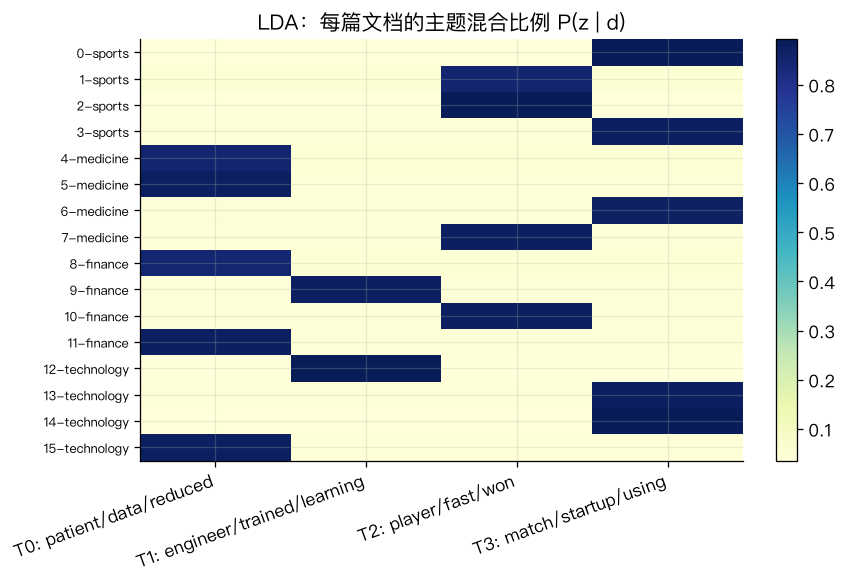

In [51]:
# ------------------------------------------------------------
# Step 6. 用热力图看每篇文档的主题混合
# ------------------------------------------------------------
# 行是文档、列是主题，颜色越深表示这篇文档在该主题上的占比越高。
fig, ax = plt.subplots(figsize=(7.5, 5.2))
im = ax.imshow(doc_topic, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(lda.n_components))
ax.set_xticklabels(topic_labels, rotation=20, ha="right")
ax.set_yticks(range(len(docs)))
ax.set_yticklabels([f"{i}-{label}" for i, label in enumerate(labels)], fontsize=8)
ax.set_title("LDA：每篇文档的主题混合比例 P(z | d)")
plt.colorbar(im, ax=ax, fraction=0.035)
plt.tight_layout()
plt.show()

In [52]:
# ------------------------------------------------------------
# Step 7. Dirichlet 先验的形状直觉：小 alpha vs 大 alpha
# ------------------------------------------------------------
# 从 Dirichlet(alpha, alpha, alpha, alpha) 里各采 3 个主题配方，看看它们长什么样。
#   alpha 小 -> 配方稀疏、集中；alpha 大 -> 配方均匀、分散。
rng_dir = np.random.default_rng(SEED)
print("从 Dirichlet(alpha, alpha, alpha, alpha) 采样 3 个主题配方 theta_d：\n")
for alpha_val in [0.2, 1.0, 5.0]:
    samples_dir = rng_dir.dirichlet([alpha_val] * 4, size=3)
    print(f"  alpha = {alpha_val}:")
    for row in samples_dir:
        max_share = float(row.max())
        shape = "极端/稀疏" if max_share > 0.6 else ("较均匀" if max_share < 0.4 else "居中")
        print(f"    {np.round(row, 3)}   max topic share = {max_share:.3f}  -> {shape}")
    print()

print("解读:")
print("  alpha = 0.2 时，theta_d 几乎全落在一两个主题上 -> 契合'一篇文档只讲少数主题'。")
print("  alpha = 5.0 时，theta_d 更均匀 -> 反而不像真实文档。")
print("  工程默认常用 alpha ≈ 50/K 或 0.1，就是为了偏向稀疏。")

从 Dirichlet(alpha, alpha, alpha, alpha) 采样 3 个主题配方 theta_d：

  alpha = 0.2:
    [0.27  0.482 0.    0.248]   max topic share = 0.482  -> 居中
    [0.    0.052 0.821 0.127]   max topic share = 0.821  -> 极端/稀疏
    [0.017 0.129 0.761 0.093]   max topic share = 0.761  -> 极端/稀疏

  alpha = 1.0:
    [0.325 0.055 0.129 0.491]   max topic share = 0.491  -> 居中
    [0.15  0.486 0.273 0.092]   max topic share = 0.486  -> 居中
    [0.261 0.363 0.194 0.182]   max topic share = 0.363  -> 较均匀

  alpha = 5.0:
    [0.2   0.417 0.166 0.217]   max topic share = 0.417  -> 居中
    [0.211 0.292 0.269 0.228]   max topic share = 0.292  -> 较均匀
    [0.167 0.286 0.314 0.233]   max topic share = 0.314  -> 较均匀

解读:
  alpha = 0.2 时，theta_d 几乎全落在一两个主题上 -> 契合'一篇文档只讲少数主题'。
  alpha = 5.0 时，theta_d 更均匀 -> 反而不像真实文档。
  工程默认常用 alpha ≈ 50/K 或 0.1，就是为了偏向稀疏。


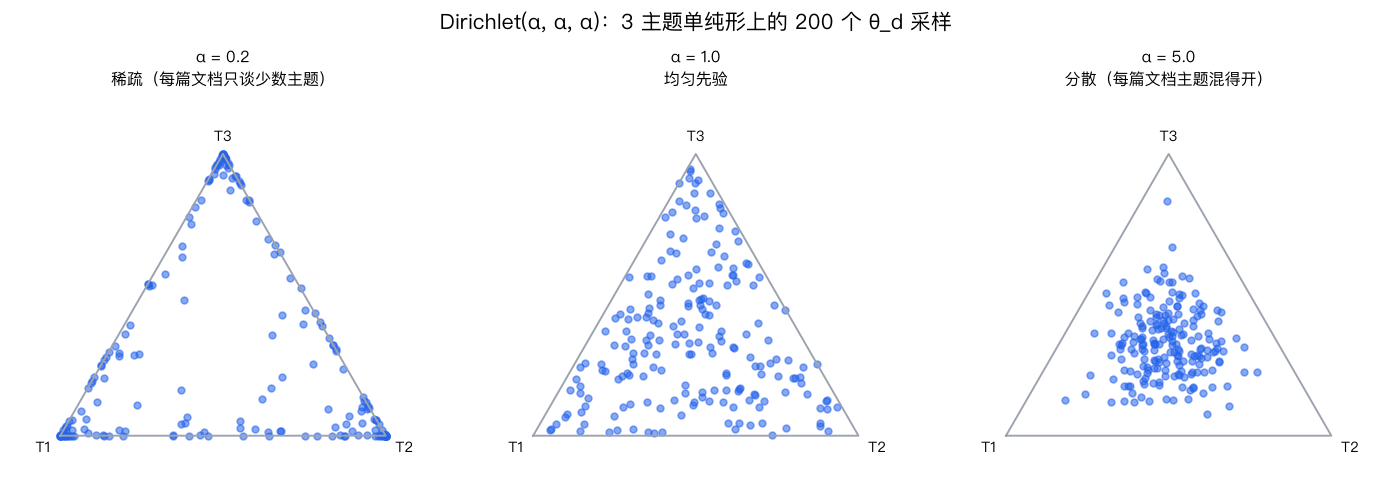

观察：α 越小，采样点越集中到三角形的角/边（稀疏配方）；α 越大，越聚在中心（均匀配方）。


In [53]:
# ------------------------------------------------------------
# Step 7b. 3 主题单纯形上的 Dirichlet 密度散点
# ------------------------------------------------------------
# 3 个主题时，theta_d = (θ1, θ2, θ3) 满足 θ1+θ2+θ3=1，可视化在等边三角形（2-单纯形）上。
#   - 三角形三个顶点 = 三个纯主题；越靠近顶点 = 主题越稀疏。
#   - 三角形正中心  = 三个主题各占 1/3；越靠近中心 = 主题越均匀。
def simplex_to_xy(samples):
    v0 = np.array([0.0, 0.0])
    v1 = np.array([1.0, 0.0])
    v2 = np.array([0.5, np.sqrt(3) / 2])
    return samples @ np.vstack([v0, v1, v2])


rng_simplex = np.random.default_rng(SEED)
alphas_sim = [0.2, 1.0, 5.0]
labels_alpha = ["稀疏（每篇文档只谈少数主题）", "均匀先验", "分散（每篇文档主题混得开）"]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2))
for ax_i, (alpha_val, subtitle) in enumerate(zip(alphas_sim, labels_alpha)):
    samples3 = rng_simplex.dirichlet([alpha_val] * 3, size=200)
    xy = simplex_to_xy(samples3)
    ax = axes[ax_i]
    tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2], [0, 0]])
    ax.plot(tri[:, 0], tri[:, 1], color="#9ca3af", linewidth=1.2)
    ax.scatter(xy[:, 0], xy[:, 1], s=18, alpha=0.55, color=COLORS["blue"])
    ax.text(-0.03, -0.05, "T1", fontsize=9, ha="right")
    ax.text(1.03, -0.05, "T2", fontsize=9, ha="left")
    ax.text(0.5, np.sqrt(3) / 2 + 0.04, "T3", fontsize=9, ha="center")
    ax.set_title(f"α = {alpha_val}\n{subtitle}", fontsize=10)
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.15, 1.05)
    ax.set_aspect("equal")
    ax.axis("off")

fig.suptitle("Dirichlet(α, α, α)：3 主题单纯形上的 200 个 θ_d 采样", y=1.02)
plt.tight_layout()
plt.show()

print("观察：α 越小，采样点越集中到三角形的角/边（稀疏配方）；α 越大，越聚在中心（均匀配方）。")

### 7.4 三者对比与短板

#### 优劣势对比表

| 方法 | 数学工具 | 输出的"主题" | 主要价值 | 主要局限 | 是否有训练 demo |
|------|----------|--------------|----------|----------|-----------------|
| **LSA**  | SVD（线性代数） | 潜在维度，可正可负 | 缓解稀疏、缓解同义词、工程简单 | 无概率解释；维度不好命名；不能生成 | Step 1 手算 SVD + Step 2 TruncatedSVD |
| **PLSA** | 概率混合 + EM | 显式主题 $z$，每篇文档一个 $P(z\mid d)$ | 有清晰概率语义、可算后验 | 参数随文档数线性增长；新文档无先验；容易过拟合 | Step 4 后验手算 + Step 4b mini EM 循环 |
| **LDA**  | PLSA + Dirichlet 先验 | 主题分布本身是随机变量 | 完整生成式模型；支持新文档；稀疏先验更自然；可解释 | 仍是文档级；不擅长词级细粒度语义（`car` vs `automobile` 的差别、`bank` 在"河岸"和"银行"两义间的切换等） | Step 5 sklearn LDA 训练 + Step 6/7/7b 可视化 |

#### 一个共同的短板：都还是"文档级"的

这三种主题模型都从**文档-词矩阵**出发，最终告诉你的是：

- 一篇**文档**在若干主题上的比例，
- 一个**主题**由哪些词构成。

但它们对**词本身的语义**只能间接刻画（一个词在各主题里的概率）。这带来两个问题：

1. **一词多义**：`bank` 在"河岸"和"金融"两个含义上会被平均，主题模型没法在同一份语料里同时给它两套语义。
2. **词级相似度**：想知道 `king` 和 `queen` 有多相似，主题模型只能间接从"它们在各主题上的概率"猜，结果通常不细腻。

#### 和 Word2Vec 的关系

Word2Vec 换了完全不同的姿势：

- **不再看整篇文档 → 词**，而是看**每一个词 → 它周围的小窗口**。
- 不再学"文档 × 主题 × 词"三张概率表，而是直接给每个词学一个稠密向量，用**局部上下文的预测任务**当训练目标。
- 结果就是词级、稠密、可以做 `vector('king') - vector('man') + vector('woman') ≈ vector('queen')` 的向量。

所以你可以这样记忆整条线：

```
BoW / TF-IDF      → 文档级、词面级、稀疏
LSA / PLSA / LDA  → 文档级、语义级、低维（但仍是文档→主题→词）
PMI / PPMI / SVD  → 词级、语义级、稀疏 → 低维（第 8 章）
Word2Vec          → 词级、语义级、稠密、可组合（第 10 章）
```

下一章会把矩阵的对象从 **文档-词** 换成 **词-上下文**，这就直接把镜头对准了"词级语义"，也是 Word2Vec 真正的直系前辈。

## 8 · 共现矩阵（Co-occurrence Matrix）、PMI（点互信息）、PPMI（正点互信息）、SVD（奇异值分解）：最接近 Word2Vec 的前史

### 一句话直觉

一个词是什么意思，看它常和谁一起出现就大概知道了。

举个例子：给你一个陌生词 `bardiglio`，如果你反复看到它出现在下面这些句子里：

```text
... quarry cut a large slab of bardiglio ...
... polished bardiglio countertop ...
... the sculptor chose bardiglio for its veins ...
```

即使字典查不到，你也能推断它大概是一种**石材**。因为它老是和 `quarry / slab / countertop / sculptor / veins` 一起出现。你并没有查定义，只是**统计了它的"社交圈"**。

这就是 **分布假说（Distributional Hypothesis）** 的直觉。语言学家 J.R. Firth 1957 年的那句名言：

> **You shall know a word by the company it keeps.**
> （看一个词交什么朋友，就知道它是什么词。）

第 8 章要把这句话变成**能算的数字**：

1. 用滑动窗口数出每个词的"朋友"（**共现矩阵 co-occurrence matrix**）；
2. 但直接数次数会被 `the / a / is` 这种高频虚词淹没，所以要用 **PMI（点互信息）** 校正"意外程度"；
3. PMI 里的负值不稳定，改用 **PPMI（正点互信息）**；
4. PPMI 矩阵还是又大又稀疏，于是用 **SVD（奇异值分解）** 压成 **稠密词向量（dense embedding）**。

到这一步为止，我们得到的**已经是词向量了**。它是 Word2Vec 之前"矩阵分解视角"能走到的最远处，也是理解 Word2Vec 为什么长那样的关键跳板。

### 这章在整条链上的位置

| 章节 | 表示对象 | 表示方式 |
|------|----------|----------|
| 4 · BoW / TF-IDF | **文档** | 稀疏词频向量 |
| 7 · LSA / LDA | **文档** | 低维主题混合 |
| **8 · 共现 / PMI / PPMI / SVD**（本章） | **词** | **由上下文统计得到的稠密向量** |
| 9 · NNLM | 词 | 由神经网络参数得到的稠密向量 |
| 10 · Word2Vec | 词 | 由预测任务高效学习的稠密向量 |

第 7 章在做文档级主题，本章把矩阵的对象换成 **word × context**，就自然过渡到"词级语义"这条更接近 Word2Vec 的路线。

### 关键中英文对照

| 英文 / 缩写 | 中文名 | 一句话说明 |
|-------------|--------|------------|
| Distributional Hypothesis | 分布假说 | 语义由上下文决定：常一起出现的词语义相近 |
| co-occurrence matrix | 共现矩阵 | 行是中心词，列是上下文词，格子是一起出现的次数 |
| context window | 上下文窗口 | 中心词左右各看 N 个词作为它的上下文 |
| center word / context word | 中心词 / 上下文词 | 窗口正中间的那个 vs. 窗口内其它的 |
| PMI (Pointwise Mutual Information) | 点互信息 | 衡量“w 和 c 一起出现”比“各自独立出现”超出多少 |
| PPMI (Positive PMI) | 正点互信息 | 把负 PMI 截成 0，只保留正相关信号 |
| SVD (Singular Value Decomposition) | 奇异值分解 | 把矩阵 M 分解成 U Σ Vᵀ，可以按奇异值大小截断降维 |
| Truncated SVD | 截断 SVD | 只保留前 k 个最大奇异值，得到低秩近似 |
| dense embedding | 稠密词向量 | 每一维都是有值的低维实数向量，与稀疏 one-hot 相反 |
| Hellinger PCA | 海林格 PCA | 对 sqrt 归一化后的共现分布做 PCA，是 PPMI+SVD 的一个变体 |
| SGNS (Skip-Gram with Negative Sampling) | 带负采样的 Skip-Gram | Word2Vec 中最常用的训练目标 |
| shifted PPMI | 平移 PPMI | Levy & Goldberg 2014 证明 SGNS 隐式在分解的目标矩阵 |

### 术语速查

| 记号 | 含义 |
|------|------|
| `count(w, c)` | 中心词 w 和上下文词 c 在窗口内一起出现的次数 |
| `count(w) = Σ_c count(w, c)` | w 作为中心词一共见过多少上下文 |
| `count(c) = Σ_w count(w, c)` | c 作为上下文一共被多少中心词看见 |
| `N = Σ_{w,c} count(w, c)` | 全语料所有 (中心, 上下文) 对的总数 |
| `P(w, c) = count(w, c) / N` | 联合概率：随便挑一对 pair，它是 (w, c) 的概率 |
| `P(w) = count(w) / N` | w 的边缘概率 |
| `P(c) = count(c) / N` | c 的边缘概率 |

### 共现矩阵怎么按窗口"数"出来：3 词例子

先看**一句 5 个词**的例子，窗口 `window = 2`（中心词左右各看 2 个）：

```text
sentence: doctor patient hospital medicine clinic
index   :   0       1        2        3       4
```

按 `window = 2`，中心词 `hospital`（index=2）的上下文是 index 0, 1, 3, 4，也就是 `doctor / patient / medicine / clinic`。对每个中心词都这么数一遍，把 `(中心词, 上下文词)` 全列出来：

| 中心词位置 | 中心词 | 窗口内的上下文词 | 产生的 pair |
|-----------|--------|------------------|-------------|
| 0 | doctor | patient, hospital | (doctor, patient), (doctor, hospital) |
| 1 | patient | doctor, hospital, medicine | (patient, doctor), (patient, hospital), (patient, medicine) |
| 2 | hospital | doctor, patient, medicine, clinic | (hospital, doctor), (hospital, patient), (hospital, medicine), (hospital, clinic) |
| 3 | medicine | patient, hospital, clinic | (medicine, patient), (medicine, hospital), (medicine, clinic) |
| 4 | clinic | hospital, medicine | (clinic, hospital), (clinic, medicine) |

**共现矩阵** `cooc` 就是把所有句子的这些 pair 累加起来：`cooc[w][c] += 1`。

注意几点：

- 矩阵是**近似对称**的：`(doctor, patient)` 计数一次，同时 `(patient, doctor)` 也计数一次（因为遍历到 patient 做中心词时也会看到 doctor）。
- 矩阵**没有对角线自计数**：我们跳过 `i == j`，中心词不算自己的上下文。
- 窗口越大，捕捉的关系越"宽"（更接近主题），窗口越小越"窄"（更接近句法）。经典设置：句法用 1~2，语义用 5~10。
- **这正是第 3 章马尔可夫链窗口的加宽版**：马尔可夫模型只看"前 1 个词"这一个位置（`P(w_t | w_{t-1})`），共现矩阵把它扩展成"左右各看 N 个词"，同一个"上下文条件化"的思路，只是把观察窗口从 1 拓宽到 2N。

### 为什么不能直接用共现次数？

如果我们只用原始次数，`the / a / of` 这种**高频虚词会淹没一切**。假设 `the` 在语料里出现 10 万次，它跟几乎每个词都共现过很多次。于是 `(doctor, the)` 的共现次数会远远大于 `(doctor, patient)`——但显然 `patient` 才是真正"描述 doctor 语义"的词。

我们需要一个能回答这样一句话的指标：

> "`doctor` 和 `patient` 一起出现的次数，是不是**超出了它们各自出现频率相乘所预期的水平**？"

这就是 **PMI（Pointwise Mutual Information，点互信息）**。

### PMI 的直觉与公式

PMI 问的是同一句话：

> 观察到 (w, c) 一起出现的概率，比"把 w 和 c 当作独立事件、各自单独出现"所预期的概率，**大多少倍**？取对数就是 PMI。

$$\text{PMI}(w, c) \;=\; \log \frac{P(w, c)}{P(w)\,P(c)}
   \;=\; \log \frac{\overbrace{\tfrac{\text{count}(w,c)}{N}}^{\text{联合概率}}}{\underbrace{\tfrac{\text{count}(w)}{N}}_{P(w)} \cdot \underbrace{\tfrac{\text{count}(c)}{N}}_{P(c)}}$$

三种情况：

- **`PMI > 0`**：一起出现比独立时预期得**多** → 正相关 → 语义相关性强（`doctor, patient`）。
- **`PMI = 0`**：和独立时一样多 → 无信息 → 大概是碰巧一起出现。
- **`PMI < 0`**：一起出现比独立时预期得**少** → 负相关 / 互斥（`doctor, football`）。

**为什么取 log？** 有两个好处：

1. **把"多几倍"变成加法量**。log 把倍数关系变成差值关系，方便解释和线性代数处理。
2. **符号即方向**。log(比值) 正负号刚好对应"多于/少于预期"。

### 一格数字的完整手算

设想很小的语料，全语料统计出：

| 量 | 值 |
|------|-----|
| N（总 pair 数） | 100 |
| count(doctor, patient) | 4 |
| count(doctor) 作为中心词的总次数 | 10 |
| count(patient) 作为上下文的总次数 | 8 |

一步步代入：

$$P(w=\text{doctor}, c=\text{patient}) = \frac{4}{100} = 0.04$$

$$P(w=\text{doctor}) = \frac{10}{100} = 0.10, \quad P(c=\text{patient}) = \frac{8}{100} = 0.08$$

$$P(w)\,P(c) = 0.10 \times 0.08 = 0.008$$

$$\text{PMI} = \log \frac{0.04}{0.008} = \log 5 \approx 1.609$$

也就是说，`doctor` 和 `patient` 一起出现的概率大约是它们独立时的 **5 倍**。这就是"意外地一起出现"的定量表达。

### 为什么要 PPMI？

PMI 有两个不便：

1. **负 PMI 不稳定**。在小语料里，`count(w,c) = 0`（从没一起出现过）就会让 PMI = log 0 = -∞。就算不是 0，低频词的负 PMI 波动也很大，往往是**采样噪声**而不是真正的负相关。
2. **稀疏保留和存储**。我们希望"没关系"和"负相关"都当作 0 处理，让矩阵保持稀疏、便于 SVD。

于是有 **PPMI（Positive PMI，正点互信息）**：

$$\text{PPMI}(w, c) = \max(\text{PMI}(w, c), \; 0)$$

一句话总结：**PPMI 只保留"值得关注的正相关"，把 0 和负值都清零。**

### SVD 起什么作用？降维 + 平滑

即使有了 PPMI 矩阵，它仍然又大（`|V| × |V|`，词表 5 万就是 25 亿格）又稀疏，直接拿去做相似度也不稳定：两个词只要一个共现词不同，向量就完全不重叠。

**SVD（奇异值分解）** 把矩阵 `M` 分解成三块（**这与第 7 章 LSA 对文档-词矩阵做 SVD 是同一手法，只是把行的语义从"文档"换成了"词"**）：

$$\underbrace{M}_{m\times n} \;=\; \underbrace{U}_{m\times r}\;\underbrace{\Sigma}_{r\times r}\;\underbrace{V^\top}_{r\times n}$$

其中 `m = |V_w|`（作为中心词的词表大小），`n = |V_c|`（作为上下文的词表大小），`r = min(m, n)`。在最常见的对称设置下 `m = n = |V|`，`r = |V|`；但严格来说 SVD 对任意矩形矩阵都成立，所以写成矩形形式更严谨。

`Σ` 是对角矩阵，对角线上是**奇异值**（按大小降序排）。**截断 SVD（Truncated SVD）** 只保留前 `k` 个最大奇异值：

$$M \;\approx\; U_k\,\Sigma_k\,V_k^\top, \qquad U_k \in \mathbb{R}^{|V|\times k}$$

于是每个词就有了一个 `k` 维的稠密向量 `U_k Σ_k` 的一行（`k` 通常取 100~300）。这一步同时做了两件事：

- **降维**：从 `|V|` 降到 `k`，存储和计算都便宜多了。
- **平滑**：丢掉小奇异值 = 丢掉噪声细节，让"从未共现但语义相近的词"通过潜在维度联系起来（这就是所谓的**二阶相似性**：不共现，但都和相同的词共现）。

### 一句话总结整条流水线

```text
语料 --窗口滑动--> 共现矩阵 cooc
     --按 N 归一化--> P(w,c), P(w), P(c)
     --取 log 比值--> PMI
     --截断非负--> PPMI
     --截断 SVD--> 稠密词向量 word_semantic
```

下面用代码把这五步逐一跑通，并可视化结果。

演示句子: doctor patient hospital medicine
window = 2
窗口内的 (中心词, 上下文词) pair:
    (doctor, patient)
    (doctor, hospital)
    (patient, doctor)
    (patient, hospital)
    (patient, medicine)
    (hospital, doctor)
    (hospital, patient)
    (hospital, medicine)
    (medicine, patient)
    (medicine, hospital)

全语料 pair 总数 N = 114
词表大小 |V| = 29
共现矩阵形状: (29, 29)


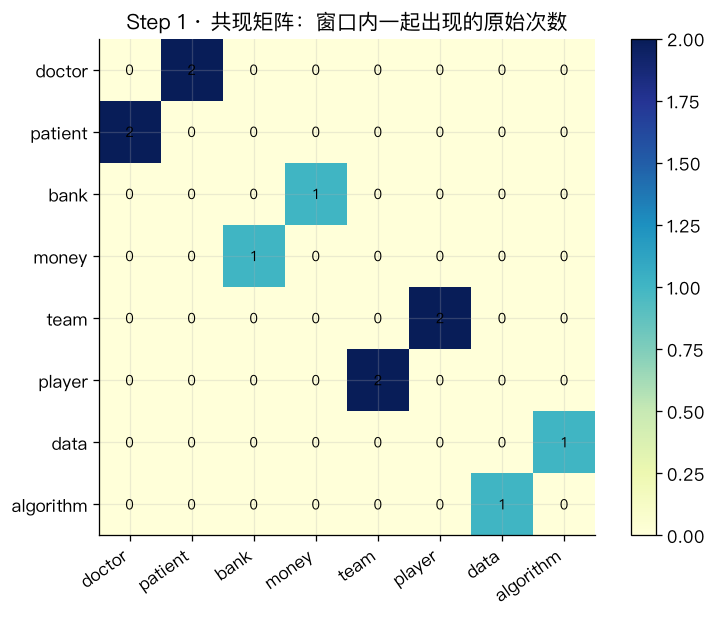


观察：同一主题的词块（doctor-patient、bank-money、team-player、data-algorithm）
      在矩阵里形成明显的对角小方块——这就是'社交圈'。


In [54]:
# ============================================================
# Step 1. 构造小语料，滑动窗口数出共现矩阵 cooc
# ============================================================
# 用 8 个短句涵盖 medicine / finance / sports / technology 四类主题，
# 让不同"社交圈"的词在共现矩阵里能被区分出来。
# 另外补 3 句"近义词共享上下文但彼此不直接共现"的句子（physician / cash），
# 用来验证 SVD 平滑之后能否发现"二阶相似性"。
cooc_sentences = [
    "doctor patient hospital medicine",
    "doctor nurse patient clinic",
    "bank loan money finance",
    "market stock money finance",
    "team player match football",
    "coach player team stadium",
    "software data algorithm computer",
    "machine learning data model",
    # ↓ physician 与 doctor 从未直接共现，但都和 patient/hospital/nurse/clinic 共现
    "the physician examined the patient",
    "physician nurse hospital clinic",
    # ↓ cash 与 money 从未直接共现，但都和 bank/loan/finance 共现
    "cash loan bank finance",
]

co_tokens = [tokenize(s) for s in cooc_sentences]
vocab = sorted(set(w for sent in co_tokens for w in sent))
w2i = {w: i for i, w in enumerate(vocab)}

window = 2

cooc = np.zeros((len(vocab), len(vocab)), dtype=float)
for sent in co_tokens:
    for i, w in enumerate(sent):
        lo = max(0, i - window)
        hi = min(len(sent), i + window + 1)
        for j in range(lo, hi):
            if i != j:
                cooc[w2i[w], w2i[sent[j]]] += 1

demo_sent = co_tokens[0]
demo_pairs = []
for i, w in enumerate(demo_sent):
    lo = max(0, i - window)
    hi = min(len(demo_sent), i + window + 1)
    for j in range(lo, hi):
        if i != j:
            demo_pairs.append((w, demo_sent[j]))

print("演示句子:", " ".join(demo_sent))
print(f"window = {window}")
print("窗口内的 (中心词, 上下文词) pair:")
for w, c in demo_pairs:
    print(f"    ({w}, {c})")
print()
print(f"全语料 pair 总数 N = {int(cooc.sum())}")
print(f"词表大小 |V| = {len(vocab)}")
print(f"共现矩阵形状: {cooc.shape}")

selected = ["doctor", "patient", "bank", "money", "team", "player", "data", "algorithm"]
idx = [w2i[w] for w in selected]

fig, ax = plt.subplots(figsize=(7, 5.5))
mat = cooc[np.ix_(idx, idx)]
im = ax.imshow(mat, cmap="YlGnBu")
ax.set_xticks(range(len(selected)))
ax.set_xticklabels(selected, rotation=35, ha="right")
ax.set_yticks(range(len(selected)))
ax.set_yticklabels(selected)
ax.set_title("Step 1 · 共现矩阵：窗口内一起出现的原始次数")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, int(mat[i, j]), ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()

print("\n观察：同一主题的词块（doctor-patient、bank-money、team-player、data-algorithm）")
print("      在矩阵里形成明显的对角小方块——这就是'社交圈'。")

In [55]:
# ============================================================
# Step 2. 用总数归一化，得到联合概率 P(w, c) 和边缘概率 P(w), P(c)
# ============================================================
total = cooc.sum()                       # N，全部 pair 数
sum_w = cooc.sum(axis=1, keepdims=True)  # 每一行的和 = count(w)
sum_c = cooc.sum(axis=0, keepdims=True)  # 每一列的和 = count(c)

print("几个词的原始计数（作为中心词 count(w) / 作为上下文 count(c)）:")
for w in ["doctor", "patient", "money", "data", "algorithm"]:
    print(f"  {w:<10} count(w) = {sum_w[w2i[w], 0]:>4.0f}   count(c) = {sum_c[0, w2i[w]]:>4.0f}")
print(f"\n全语料 pair 总数 N = {total:.0f}")

几个词的原始计数（作为中心词 count(w) / 作为上下文 count(c)）:
  doctor     count(w) =    4   count(c) =    4
  patient    count(w) =    8   count(c) =    8
  money      count(w) =    6   count(c) =    6
  data       count(w) =    6   count(c) =    6
  algorithm  count(w) =    3   count(c) =    3

全语料 pair 总数 N = 114


PMI(doctor, patient) 的手算过程：
  count(w, c) = 2, count(w) = 4, count(c) = 8, N = 114
  P(w, c) = 2/114 = 0.0175
  P(w)    = 4/114  = 0.0351
  P(c)    = 8/114  = 0.0702
  P(w)P(c) = 0.0351 * 0.0702 = 0.0025
  比值 P(w,c) / (P(w)P(c)) = 7.125   <- 一起出现是独立情况的多少倍
  PMI = log(7.125) = +1.964
  PPMI = max(PMI, 0) = 1.964

PMI(doctor, money) 的手算过程：
  count(w, c) = 0, count(w) = 4, count(c) = 6, N = 114
  P(w, c) = 0/114 = 0.0000
  P(w)    = 4/114  = 0.0351
  P(c)    = 6/114  = 0.0526
  P(w)P(c) = 0.0351 * 0.0526 = 0.0018
  count(w,c) = 0 -> log(0) = -inf -> PPMI = 0
  PPMI = max(PMI, 0) = 0.000

补充：一个有限的负 PMI 例子（帮助理解负值意味着什么）
  count(w,c)=1, count(w)=20, count(c)=20, N=100
  P(w,c) = 0.01, P(w)P(c) = 0.20 * 0.20 = 0.04
  比值 = 0.01 / 0.04 = 0.25   <- 一起出现只有独立预期的 1/4
  PMI = log(0.25) = -1.386   <- 负号 = '出乎意料地少一起出现'
  PPMI = max(PMI, 0) = 0.000   <- 负值被清零


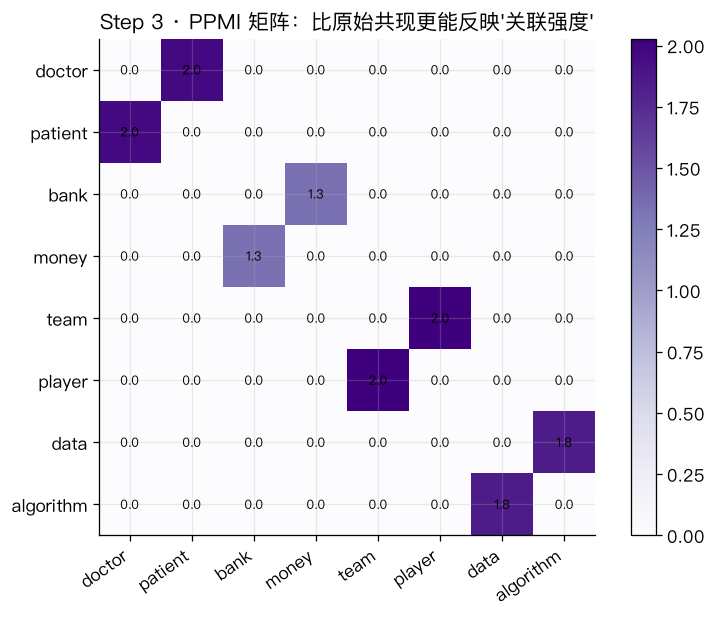


对比 Step 1 的原始次数：
  - 同主题词对（doctor-patient 等）保留了强正值；
  - 跨主题词对（doctor-money 等）被压到 0；
  - 高频虚词效应被 P(w)P(c) 项约掉。


In [56]:
# ============================================================
# Step 3. 计算 PMI 和 PPMI
# ============================================================
# 数学等价：
#   PMI(w,c) = log(P(w,c) / (P(w)P(c)))
#            = log((count(w,c)/N) / ((count(w)/N) * (count(c)/N)))
#            = log((count(w,c) * N) / (count(w) * count(c)))
with np.errstate(divide="ignore", invalid="ignore"):
    raw_pmi = np.log((cooc * total) / (sum_w @ sum_c))

# PPMI：负值和 -inf（未共现）统一截断为 0。
ppmi = np.maximum(np.nan_to_num(raw_pmi, neginf=0.0, posinf=0.0), 0)


def show_pmi(w, c):
    wi, ci = w2i[w], w2i[c]
    cwc = cooc[wi, ci]
    cw = sum_w[wi, 0]
    cc = sum_c[0, ci]
    pwc = cwc / total
    pw = cw / total
    pc = cc / total
    print(f"PMI({w}, {c}) 的手算过程：")
    print(f"  count(w, c) = {cwc:.0f}, count(w) = {cw:.0f}, count(c) = {cc:.0f}, N = {total:.0f}")
    print(f"  P(w, c) = {cwc:.0f}/{total:.0f} = {pwc:.4f}")
    print(f"  P(w)    = {cw:.0f}/{total:.0f}  = {pw:.4f}")
    print(f"  P(c)    = {cc:.0f}/{total:.0f}  = {pc:.4f}")
    print(f"  P(w)P(c) = {pw:.4f} * {pc:.4f} = {pw * pc:.4f}")
    if cwc == 0:
        print(f"  count(w,c) = 0 -> log(0) = -inf -> PPMI = 0")
    else:
        ratio = pwc / (pw * pc)
        print(f"  比值 P(w,c) / (P(w)P(c)) = {ratio:.3f}   <- 一起出现是独立情况的多少倍")
        print(f"  PMI = log({ratio:.3f}) = {raw_pmi[wi, ci]:+.3f}")
    print(f"  PPMI = max(PMI, 0) = {ppmi[wi, ci]:.3f}")
    print()


show_pmi("doctor", "patient")
show_pmi("doctor", "money")

print("补充：一个有限的负 PMI 例子（帮助理解负值意味着什么）")
toy_ratio = (1 / 100) / ((20 / 100) * (20 / 100))
toy_pmi = math.log(toy_ratio)
print(f"  count(w,c)=1, count(w)=20, count(c)=20, N=100")
print(f"  P(w,c) = 0.01, P(w)P(c) = 0.20 * 0.20 = 0.04")
print(f"  比值 = 0.01 / 0.04 = 0.25   <- 一起出现只有独立预期的 1/4")
print(f"  PMI = log(0.25) = {toy_pmi:+.3f}   <- 负号 = '出乎意料地少一起出现'")
print(f"  PPMI = max(PMI, 0) = {max(toy_pmi, 0):.3f}   <- 负值被清零")

fig, ax = plt.subplots(figsize=(7, 5.5))
mat = ppmi[np.ix_(idx, idx)]
im = ax.imshow(mat, cmap="Purples")
ax.set_xticks(range(len(selected)))
ax.set_xticklabels(selected, rotation=35, ha="right")
ax.set_yticks(range(len(selected)))
ax.set_yticklabels(selected)
ax.set_title("Step 3 · PPMI 矩阵：比原始共现更能反映'关联强度'")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j]:.1f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()

print("\n对比 Step 1 的原始次数：")
print("  - 同主题词对（doctor-patient 等）保留了强正值；")
print("  - 跨主题词对（doctor-money 等）被压到 0；")
print("  - 高频虚词效应被 P(w)P(c) 项约掉。")

PPMI 矩阵形状: (29, 29)
2 维投影形状:  (29, 2)     <- 每个词一个 2 维稠密向量
8 维语义形状:  (29, 8)   <- 用来做相似度检索

2 维奇异值:   [7.573 7.291]
8 维奇异值:   [7.573 7.291 6.785 6.635 4.975 4.552 4.246 4.164]
2 维累计方差比: 0.238

几个词的 2 维坐标：
  doctor     (-0.000, -0.000)
  patient    (+0.000, +0.000)
  bank       (+0.000, -0.000)
  money      (-0.000, +0.000)
  team       (+0.000, +3.491)
  player     (-0.000, +3.919)
  data       (+4.240, -0.000)
  algorithm  (+2.886, -0.000)


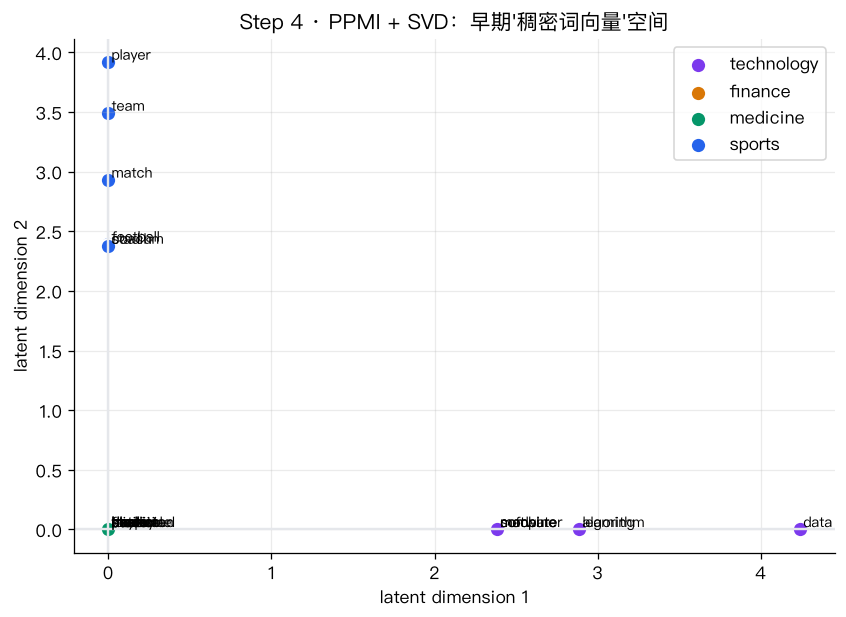

In [57]:
# ============================================================
# Step 4. 对 PPMI 做 SVD，得到低维稠密词向量
# ============================================================
# 训练两个版本：
#   - svd_plot / word_2d：k=2，用来画二维散点图；
#   - svd_full / word_semantic：k 更大，用来做近邻检索。
svd_plot = TruncatedSVD(n_components=2, random_state=SEED)
word_2d = svd_plot.fit_transform(ppmi)

svd_full = TruncatedSVD(n_components=min(8, len(vocab) - 1), random_state=SEED)
word_semantic = svd_full.fit_transform(ppmi)

print(f"PPMI 矩阵形状: {ppmi.shape}")
print(f"2 维投影形状:  {word_2d.shape}     <- 每个词一个 2 维稠密向量")
print(f"8 维语义形状:  {word_semantic.shape}   <- 用来做相似度检索")
print(f"\n2 维奇异值:   {np.round(svd_plot.singular_values_, 3)}")
print(f"8 维奇异值:   {np.round(svd_full.singular_values_, 3)}")
print(f"2 维累计方差比: {np.round(svd_plot.explained_variance_ratio_.sum(), 3)}")

print("\n几个词的 2 维坐标：")
for w in ["doctor", "patient", "bank", "money", "team", "player", "data", "algorithm"]:
    x, y = word_2d[w2i[w]]
    print(f"  {w:<10} ({x:+.3f}, {y:+.3f})")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
word_groups = {
    "medicine":   {"doctor", "patient", "hospital", "medicine", "nurse", "clinic", "physician", "examined", "the"},
    "finance":    {"bank", "loan", "money", "finance", "market", "stock", "cash"},
    "sports":     {"team", "player", "match", "football", "coach", "stadium"},
    "technology": {"software", "data", "algorithm", "computer", "machine", "learning", "model"},
}
group_colors = {
    "medicine":   COLORS["green"],
    "finance":    COLORS["amber"],
    "sports":     COLORS["blue"],
    "technology": COLORS["purple"],
}
for w in vocab:
    x, y = word_2d[w2i[w]]
    group = next((name for name, words in word_groups.items() if w in words), "other")
    ax.scatter(x, y, s=90, color=group_colors.get(group, COLORS["gray"]), label=group,
               edgecolor="white", linewidth=1.2)
    ax.text(x + 0.02, y + 0.02, w, fontsize=9)
ax.axhline(0, color="#e5e7eb")
ax.axvline(0, color="#e5e7eb")
ax.set_title("Step 4 · PPMI + SVD：早期'稠密词向量'空间")
ax.set_xlabel("latent dimension 1")
ax.set_ylabel("latent dimension 2")
handles, labels_seen = ax.get_legend_handles_labels()
unique = dict(zip(labels_seen, handles))
ax.legend(unique.values(), unique.keys(), loc="best")
plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# Step 5. 余弦相似度：验证"社交圈"确实在向量空间里体现出来
# ============================================================
# 余弦相似度 cos(u, v) = (u · v) / (||u|| * ||v||)
# 取值 [-1, 1]，越接近 1 表示两个向量方向越一致（语义越像）。
def nearest_words(word, k=4):
    vec = word_semantic[w2i[word]]
    sims = []
    for other in vocab:
        if other == word:
            continue
        other_vec = word_semantic[w2i[other]]
        denom = np.linalg.norm(vec) * np.linalg.norm(other_vec)
        sim = float(vec @ other_vec / denom) if denom else 0.0
        sims.append((other, sim))
    return sorted(sims, key=lambda x: x[1], reverse=True)[:k]


print("SVD 稠密向量空间里的最近邻：")
for w in ["doctor", "bank", "team", "data"]:
    neighbors = nearest_words(w, k=4)
    formatted = ", ".join(f"{n}({s:+.2f})" for n, s in neighbors)
    print(f"  {w:<8} -> {formatted}")

# ============================================================
# 二阶相似性（second-order similarity）的正面证据
# ============================================================
# doctor 和 physician 在语料里"从未直接共现"（cooc[doctor, physician] = 0），
# 但因为都和 patient / hospital / nurse / clinic 大量共现，SVD 把它们
# 拉到了同一片语义区域——这就是词嵌入能"发现同义词"的直接机制。
def cosine_sim(u, v):
    denom = np.linalg.norm(u) * np.linalg.norm(v)
    return float(u @ v / denom) if denom else 0.0


print("\n二阶相似性正面证据（未共现却相近）：")
for w, c in [("doctor", "physician"), ("money", "cash")]:
    wi, ci = w2i[w], w2i[c]
    raw = cooc[wi, ci]
    cos = cosine_sim(word_semantic[wi], word_semantic[ci])
    print(f"  {w:<9s} <-> {c:<10s}  cooc = {raw:.0f}   cosine(SVD) = {cos:+.3f}")
print("  这正是 SVD 平滑带来的二阶相似性，也是词嵌入能'发现同义词'的直接原因：")
print("  两个词从没在同一个窗口里出现过，却因为都和同一批上下文共现，")
print("  被低秩分解拉到了非常接近的方向。")

print("\n对同一个词 'doctor'，看它排名前 5 的上下文变化：")
print("  按原始共现次数（可能被虚词淹没）:")
row_cooc = cooc[w2i["doctor"]]
for i in row_cooc.argsort()[::-1][:5]:
    print(f"    {vocab[i]:<10} count = {row_cooc[i]:.0f}")
print("  按 PPMI（更能反映真实关联）:")
row_ppmi = ppmi[w2i["doctor"]]
for i in row_ppmi.argsort()[::-1][:5]:
    if row_ppmi[i] > 0:
        print(f"    {vocab[i]:<10} PPMI  = {row_ppmi[i]:.3f}")

reconstructed = word_2d @ svd_plot.components_
print("\n低秩重构验证：word_2d @ components_ ≈ 原 PPMI 中的一个元素")
for w, c in [("doctor", "patient"), ("bank", "money"), ("data", "algorithm"), ("doctor", "money")]:
    wi, ci = w2i[w], w2i[c]
    print(f"  ({w}, {c}): 原 PPMI = {ppmi[wi, ci]:.3f}, 2 维重构 ≈ {reconstructed[wi, ci]:.3f}")

SVD 稠密向量空间里的最近邻：
  doctor   -> clinic(+1.00), medicine(+1.00), physician(+0.96), examined(+0.82)
  bank     -> stock(+1.00), finance(+1.00), cash(+1.00), money(+1.00)
  team     -> player(+0.97), football(+0.94), match(+0.34), coach(+0.26)
  data     -> learning(+0.95), algorithm(+0.95), computer(+0.30), software(+0.30)

二阶相似性正面证据（未共现却相近）：
  doctor    <-> physician   cooc = 0   cosine(SVD) = +0.959
  money     <-> cash        cooc = 0   cosine(SVD) = +1.000
  这正是 SVD 平滑带来的二阶相似性，也是词嵌入能'发现同义词'的直接原因：
  两个词从没在同一个窗口里出现过，却因为都和同一批上下文共现，
  被低秩分解拉到了非常接近的方向。

对同一个词 'doctor'，看它排名前 5 的上下文变化：
  按原始共现次数（可能被虚词淹没）:
    patient    count = 2
    nurse      count = 1
    hospital   count = 1
    the        count = 0
    learning   count = 0
  按 PPMI（更能反映真实关联）:
    patient    PPMI  = 1.964
    nurse      PPMI  = 1.558
    hospital   PPMI  = 1.558

低秩重构验证：word_2d @ components_ ≈ 原 PPMI 中的一个元素
  (doctor, patient): 原 PPMI = 1.964, 2 维重构 ≈ 0.000
  (bank, money): 原 PPMI = 1.335, 2 维重构 ≈ 0.000
  (data, algorith

### 短板：为什么"PPMI + SVD"不是终点

这一整套流水线数学上很干净，但在真实大语料下问题也很明显：

| 短板 | 具体表现 |
|------|----------|
| **矩阵太大** | 词表 50 万 → PPMI 矩阵 `50 万 × 50 万 = 2500 亿`。哪怕稀疏也难在单机跑。 |
| **低频词不稳定** | 出现 3~5 次的词，`P(w)` 估计噪声很大，PMI 会剧烈波动。 |
| **SVD 不 online** | 每来一批新语料几乎要重新分解整个矩阵。工业界很痛。 |
| **增量语料难更新** | 想让 embedding 跟随时间演变（新词、语义漂移）很难，得反复重建矩阵。 |
| **窗口是硬窗口** | 不区分位置远近的贡献。近邻和 5 步外的词权重一样。 |
| **超参多且敏感** | 窗口大小、PMI 是否 shift、SVD 维度 k、是否再对 U_k 加权 Σ_k^α，每个都影响结果。 |

**Word2Vec 出现前的一段时间**，学界的主流答案是各种"更聪明的加权 + 更聪明的分解"：Hellinger PCA、GloVe（把 log-count 直接作为回归目标）等。它们本质上都在同一个框架下做微调。

真正的跳跃来自：**能不能不显式构造矩阵，而是用一个便宜的预测任务，让稠密向量自己长出来？** 这就是第 10 章 Word2Vec 要回答的问题。

### 那 Word2Vec 完全推翻了这条路线吗？没有。

**Levy & Goldberg（NIPS 2014, "Neural Word Embedding as Implicit Matrix Factorization"）** 证明了一个非常漂亮的结果：

> 在理想优化条件下（词向量维度足够、每对 (w, c) 都有独立参数），**Skip-Gram with Negative Sampling（SGNS）** 学到的中心词向量 `v_w` 和上下文向量 `u_c` 的内积，恰好等于一个 **shifted PMI（平移 PMI）** 矩阵中对应位置的值：

$$v_w^\top u_c \;\approx\; \text{PMI}(w, c) \;-\; \log k$$

其中 `k` 是 SGNS 的负采样个数。也就是说：**SGNS 在悄悄地对一个 shifted PMI 矩阵做隐式的矩阵分解**。

这就意味着：

- **共现 → PMI → PPMI → SVD** 是**显式的矩阵分解视角**。它把整个矩阵摆出来，然后一步分解。
- **Word2Vec (SGNS)** 是**预测视角**。它一次只看一对 (中心词, 上下文词)，用便宜的梯度下降**隐式地**把同一件事做完。

两条路线的目标函数在极限下等价，但工程性质完全不同：

| 视角 | 存不存整个矩阵 | 训练方式 | 增量友好？ | 大规模扩展 |
|------|----------------|----------|------------|------------|
| PPMI + SVD（本章） | 显式存 | 一次性矩阵分解 | 差 | 内存瓶颈 |
| NNLM（第 9 章） | 不存矩阵，但需 softmax 全归一化 | 神经网络 + 反向传播 | 一般 | 受限于全词表 softmax |
| Word2Vec / SGNS（第 10 章） | 不存 | 随机梯度下降（SGD） | 好 | 天生并行 |

所以本章不是被"推翻"的历史。它是理解 Word2Vec **在做什么**（分解一个平移过的 PMI 矩阵）和 **为什么这么做**（避免显式矩阵的所有工程痛点）的最短通路。

In [59]:
# ============================================================
# 桥接：把 PMI 和 SGNS 的联系用数字对一次
# ============================================================
# Levy & Goldberg 2014 的核心结论：
#     v_w · u_c  ≈  PMI(w, c) - log(k)
negative_samples = 5
shift = math.log(negative_samples)

print(f"负采样数 k = {negative_samples}, log(k) = {shift:.3f}")
print("=" * 60)
print("SGNS 理想解应满足: v_w · u_c ≈ PMI(w, c) - log(k)")
print("=" * 60)
for w, c in [("doctor", "patient"), ("doctor", "nurse"), ("doctor", "money"),
             ("bank", "money"), ("data", "algorithm")]:
    wi, ci = w2i[w], w2i[c]
    val = raw_pmi[wi, ci]
    if np.isfinite(val):
        print(f"  {w:>8s} -> {c:<10s}  raw PMI = {val:+.3f},  shifted PMI = {val - shift:+.3f}")
    else:
        print(f"  {w:>8s} -> {c:<10s}  raw PMI = -inf（未共现，SGNS 理想解也是 -inf）")

context_counts = sum_c.ravel()
p_unigram = context_counts / context_counts.sum()
p_smooth = context_counts ** 0.75
p_smooth = p_smooth / p_smooth.sum()

def sgns_optimum_dot(w, c, p_noise):
    wi, ci = w2i[w], w2i[c]
    if cooc[wi, ci] == 0:
        return -math.inf
    return math.log(cooc[wi, ci] / (sum_w[wi, 0] * negative_samples * p_noise[ci]))

print("\n换成 word2vec 论文里实际用的 unigram^0.75 噪声分布：")
for w, c in [("doctor", "patient"), ("bank", "money"), ("data", "algorithm")]:
    wi, ci = w2i[w], w2i[c]
    print(f"  {w}->{c}")
    print(f"    PMI - log(k)（unigram 噪声下的理想解）:      {raw_pmi[wi, ci] - shift:+.3f}")
    print(f"    SGNS 理想解（unigram^0.75 噪声，Word2Vec 实际）: {sgns_optimum_dot(w, c, p_smooth):+.3f}")

print("\n结论：")
print("  - 用 unigram 噪声时，SGNS 理想解就是 PMI - log(k)（Levy & Goldberg 严格等式）。")
print("  - Word2Vec 用 unigram^0.75，得到的是它的一个平滑变体，本质仍是'平移过的 PMI 矩阵分解'。")
print("  - 也就是说：第 8 章的'PPMI + SVD'和第 10 章的'Word2Vec'，是同一枚硬币的两面。")

负采样数 k = 5, log(k) = 1.609
SGNS 理想解应满足: v_w · u_c ≈ PMI(w, c) - log(k)
    doctor -> patient     raw PMI = +1.964,  shifted PMI = +0.354
    doctor -> nurse       raw PMI = +1.558,  shifted PMI = -0.051
    doctor -> money       raw PMI = -inf（未共现，SGNS 理想解也是 -inf）
      bank -> money       raw PMI = +1.335,  shifted PMI = -0.274
      data -> algorithm   raw PMI = +1.846,  shifted PMI = +0.236

换成 word2vec 论文里实际用的 unigram^0.75 噪声分布：
  doctor->patient
    PMI - log(k)（unigram 噪声下的理想解）:      +0.354
    SGNS 理想解（unigram^0.75 噪声，Word2Vec 实际）: +0.512
  bank->money
    PMI - log(k)（unigram 噪声下的理想解）:      -0.274
    SGNS 理想解（unigram^0.75 噪声，Word2Vec 实际）: -0.188
  data->algorithm
    PMI - log(k)（unigram 噪声下的理想解）:      +0.236
    SGNS 理想解（unigram^0.75 噪声，Word2Vec 实际）: +0.149

结论：
  - 用 unigram 噪声时，SGNS 理想解就是 PMI - log(k)（Levy & Goldberg 严格等式）。
  - Word2Vec 用 unigram^0.75，得到的是它的一个平滑变体，本质仍是'平移过的 PMI 矩阵分解'。
  - 也就是说：第 8 章的'PPMI + SVD'和第 10 章的'Word2Vec'，是同一枚硬币的两面。


### 本章小结（一图流）

```text
       原始文本
           |
    [Step 1] 滑动窗口计数
           v
   共现矩阵 cooc[w, c]        <- 高频虚词淹没，直接不好用
           |
    [Step 2] 除以总数 N
           v
   联合 / 边缘概率 P(w,c), P(w), P(c)
           |
    [Step 3] log(P(w,c) / (P(w)P(c)))
           v
   PMI 矩阵                   <- 负值和 -inf 不稳定
           |
    [Step 3] max(PMI, 0)
           v
   PPMI 矩阵                  <- 稀疏正相关信号，可用
           |
    [Step 4] 截断 SVD
           v
   稠密词向量 word_semantic   <- Word2Vec 之前"矩阵分解视角"的终点
           |
    [第 10 章] SGNS 用预测任务隐式达到同一目标（shifted PMI）
```

**要记住的三件事**：

1. **分布假说**是这整章（以及 Word2Vec、GloVe、BERT）共同的哲学起点。
2. **PPMI + SVD** 是显式地把这条哲学写成矩阵分解。它工程上有瓶颈，但概念上非常清晰。
3. **Word2Vec 不是革命，是加速**。它用预测任务隐式做同一件事，但不用把整个 `|V| × |V|` 矩阵摆出来。这才让"训练大语料 + 上百万词汇"成为可能。

## 9 · 早期神经语言模型（NNLM，Neural Network Language Model）

### 一句话直觉

在此之前，我们要么用 one-hot / TF-IDF 把词变成"稀疏、彼此正交"的高维向量，要么用 N-gram 直接数"上一个词是谁、下一个词是谁"。它们都有一个共同的死穴：**没见过的组合就没辙**。

想象你训练时只见过：

```text
the black cat eats fish
```

现在测试时来了一句：

```text
the dark cat eats ___
```

对 N-gram 来说 `the dark cat` 是一段全新的三元组，估计概率就是 0（或者靠平滑硬凑一个很小的值），完全没有利用 `dark` 和 `black` 是近义颜色词这件事。（对应第 3 章 N-gram 平滑失败的场景 —— 无论 Laplace 还是 Kneser-Ney，都只能对"字面上出现过"的组合做重新分配。）

**神经语言模型（Neural Language Model）的关键武器**：先给每个词学一个稠密向量（dense vector），让 `black` 和 `dark` 在向量空间里靠得很近；再用一个小神经网络吃这些向量、预测下一个词。这样即使 `the dark cat` 没在训练集里出现过，模型也能借助 `dark ≈ black` 的相似性做出合理预测。

这就是 2003 年 **Bengio 等人**提出的 **NNLM（Neural Network Language Model，神经网络语言模型）** 的核心思想。它同时开创了两件后来主宰 NLP 的东西：

1. **word embedding（词向量 / 词嵌入）**：一张形状为 $V \times m$ 的可学习矩阵，第 $i$ 行就是词表里第 $i$ 个词的稠密向量。
2. **端到端的神经语言建模**：不再靠人工特征，直接从"预测下一个词"的自监督任务里学表示。（对应第 8 章"稠密向量的动机" —— 共现矩阵 + SVD 已经指出稠密表示的价值，NNLM 则第一次用**端到端学习**替代了"先构造统计矩阵再降维"这条流水线。）

Word2Vec 并不是"第一个学词向量的模型"——它是 NNLM 的**加速版和瘦身版**。

### 场景类比：从"死记硬背"到"抽象特征"

- **N-gram** 像一个死记硬背的学生：只记得原文出现过的固定短语，一旦换个词就答不上来。
- **NNLM** 像一个懂得抽象的学生：他把每个词都翻译成一组"性格特征"（比如"是不是颜色词""是不是动物""是不是动作"），只要下次遇到的词特征和见过的差不多，就能类推。
- **word embedding** 就是这套"性格特征表"，一个词占一行，每行 $m$ 个特征分量。

### 关键中英文对照

| 英文 / 缩写 | 中文名 | 一句话说明 |
|-------------|--------|------------|
| NNLM (Neural Network Language Model) | 神经网络语言模型 | Bengio 2003 提出，用神经网络预测下一个词 |
| Bengio 2003 | Bengio 2003 论文 | 论文标题 *A Neural Probabilistic Language Model*，NNLM 的原始出处 |
| word embedding | 词向量 / 词嵌入 | 用一个稠密向量表示词，语义相近的词向量也相近 |
| lookup table | 查表 / 嵌入表 | 大小为 $V \times m$ 的矩阵，索引一行 = 取出该词的向量 |
| context window | 上下文窗口 | 用来预测目标词的前 $n-1$ 个词（如前 3 个） |
| hidden layer | 隐藏层 | 神经网络里输入和输出之间的中间表示层 |
| tanh | 双曲正切激活函数 | 把实数压缩到 $(-1, 1)$，给网络引入非线性 |
| softmax | 归一化指数函数 | 把一组实数变成和为 1 的概率分布 |
| full softmax | 完整 softmax | 对整个词表 V 个词都算一遍指数并归一化，$O(V)$ 成本 |
| logit | 未归一化分数 | softmax 之前的原始实数分数 |
| perplexity | 困惑度 | 语言模型对文本"不确定程度"的指标，越低越好；定义 $\text{PPL} = \exp(\text{平均负对数似然})$，随机瞎猜 $V$ 分类时 $\text{PPL} = V$ |
| hierarchical softmax | 层次 softmax | 用二叉树把 $O(V)$ 归一化降到 $O(\log V)$（第 10 章展开） |
| negative sampling | 负采样 | 每次只更新一小撮"负样本"而不是整个词表（第 10 章展开） |
| cross entropy loss | 交叉熵损失 | 语言模型常用的损失：$-\log P(\text{target} \mid \text{context})$ |

### Bengio 2003 的模型长什么样：一图看懂

NNLM 的前向传播只有四步：

```text
context words  --lookup-->  m 维向量们  --concat-->  (n-1)*m 维长向量
                                                       |
                                                       v
                                    tanh( W · x + b )   [hidden layer, h 维]
                                                       |
                                                       v
                                    U · h + d           [logits, V 维]
                                                       |
                                                       v
                                    softmax              [概率分布, V 维]
```

用数学式子写就是：

$$
\begin{aligned}
x &= [\,E[w_{t-n+1}];\ \dots;\ E[w_{t-1}]\,] & &\text{(拼接 $n-1$ 个上下文词向量)} \\
h &= \tanh(W x + b) & &\text{(隐藏层)} \\
z &= U h + d & &\text{(输出层 logits，长度 V)} \\
\hat p(w_t \mid \text{context}) &= \operatorname{softmax}(z) = \frac{e^{z_{w_t}}}{\sum_{w=1}^{V} e^{z_w}} & &\text{(在整个词表 V 上归一化)}
\end{aligned}
$$

参数一共四组：$E \in \mathbb{R}^{V \times m}$（**embedding 表就诞生在这里**）、$W \in \mathbb{R}^{(n-1)m \times h}$、$U \in \mathbb{R}^{h \times V}$、以及两个 bias $b, d$。训练目标是最大化训练语料上真实下一个词的对数概率（等价于最小化交叉熵损失）。

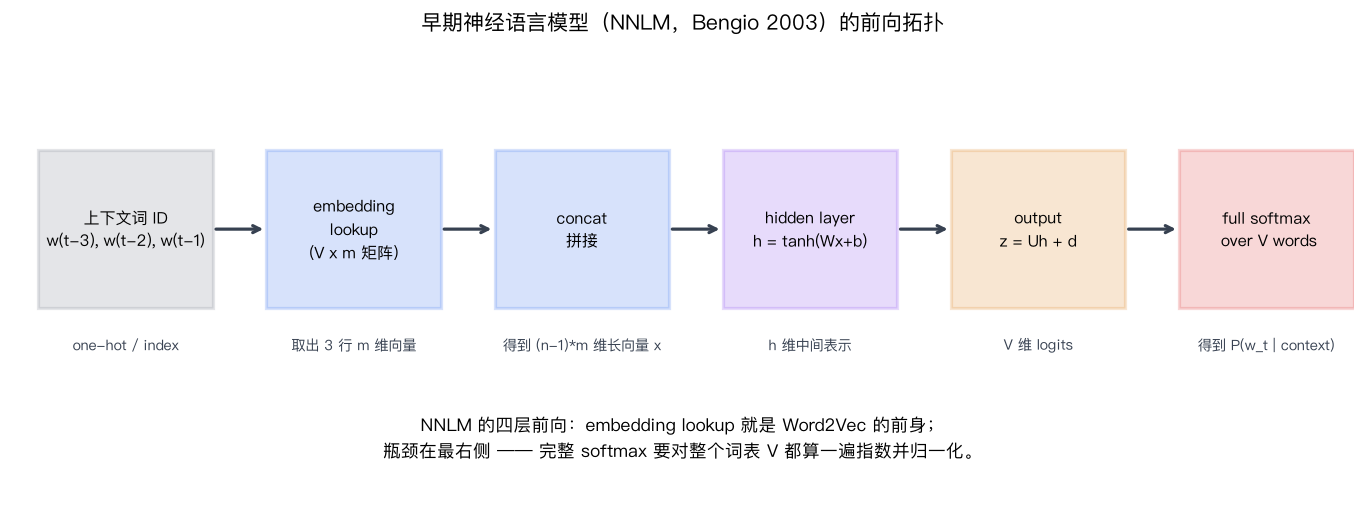

In [60]:
# 画一张 NNLM 的前向拓扑图：context -> lookup -> concat -> tanh(Wx+b) -> Uh+d -> softmax
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.axis("off")

# 每个方块代表一层张量或一次运算；重点让读者一眼看到：embedding lookup 是 NNLM 的第一步。
stages = [
    ("上下文词 ID\nw(t-3), w(t-2), w(t-1)", 0.02, COLORS["gray"],   "one-hot / index"),
    ("embedding\nlookup\n(V x m 矩阵)",     0.19, COLORS["blue"],   "取出 3 行 m 维向量"),
    ("concat\n拼接",                         0.36, COLORS["blue"],   "得到 (n-1)*m 维长向量 x"),
    ("hidden layer\nh = tanh(Wx+b)",        0.53, COLORS["purple"], "h 维中间表示"),
    ("output\nz = Uh + d",                  0.70, COLORS["amber"],  "V 维 logits"),
    ("full softmax\n over V words",          0.87, COLORS["red"],    "得到 P(w_t | context)"),
]

for text, x, color, sub in stages:
    rect = plt.Rectangle((x, 0.42), 0.13, 0.34, facecolor=color, alpha=0.18,
                         edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x + 0.065, 0.59, text, ha="center", va="center", fontsize=10)
    ax.text(x + 0.065, 0.34, sub, ha="center", va="center", fontsize=9, color="#374151")

for i in range(len(stages) - 1):
    x1 = stages[i][1] + 0.13
    x2 = stages[i + 1][1]
    ax.annotate("", xy=(x2, 0.59), xytext=(x1, 0.59),
                arrowprops=dict(arrowstyle="->", linewidth=2, color="#374151"))

ax.text(0.5, 0.14,
        "NNLM 的四层前向：embedding lookup 就是 Word2Vec 的前身；\n"
        "瓶颈在最右侧 —— 完整 softmax 要对整个词表 V 都算一遍指数并归一化。",
        ha="center", va="center", fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("早期神经语言模型（NNLM，Bengio 2003）的前向拓扑")
plt.tight_layout()
plt.show()

### 手动前向传播：用 V=6, m=3, h=4 亲手算一遍

为了让"张量形状"和"完整 softmax 为什么贵"都看得清清楚楚，下面用一个非常小的 NNLM 手动跑一次前向：

- 词表大小 $V = 6$
- 词向量维度 $m = 3$
- 上下文窗口 $n - 1 = 3$（用前 3 个词预测下一个词）
- 隐藏层大小 $h = 4$

假设已经训练好（这里用随机数模拟）：

- 嵌入表 $E$：形状 $(V, m) = (6, 3)$
- 隐藏层权重 $W$：形状 $((n-1)m, h) = (9, 4)$，偏置 $b$：$(4,)$
- 输出层权重 $U$：形状 $(h, V) = (4, 6)$，偏置 $d$：$(6,)$

一次前向就是"取行 → 拼接 → 线性 + tanh → 线性 → softmax"这几步。

In [61]:
# ------------------------------------------------------------
# Step 1. 定义一个 tiny corpus 和词表 (V = 6)
# ------------------------------------------------------------
# 这个语料只有一句话，重点是让你看到 (V, m, C, h) 各是多少，以及 lookup 怎么发生。
# 语料里没有 "dark"，但词表里放了 "dark"，用来演示"泛化到未见过组合"的直觉。
nnlm_corpus = ["the", "black", "cat", "eats", "fish"]
nnlm_vocab  = ["the", "black", "dark", "cat", "eats", "fish"]  # V = 6
nnlm_w2i = {w: i for i, w in enumerate(nnlm_vocab)}
nnlm_i2w = {i: w for w, i in nnlm_w2i.items()}

V_nnlm = len(nnlm_vocab)   # 6
M_nnlm = 3                 # embedding 维度 m
C_nnlm = 3                 # context window (前 3 个词)
H_nnlm = 4                 # hidden layer 维度 h

print(f"词表 (V = {V_nnlm}): {nnlm_vocab}")
print(f"嵌入维度 m = {M_nnlm}, 上下文窗口 n-1 = {C_nnlm}, 隐藏层 h = {H_nnlm}")

词表 (V = 6): ['the', 'black', 'dark', 'cat', 'eats', 'fish']
嵌入维度 m = 3, 上下文窗口 n-1 = 3, 隐藏层 h = 4


In [62]:
# ------------------------------------------------------------
# Step 2. 构造训练样本 (context, target)
# ------------------------------------------------------------
# 语言模型的自监督信号：用前 C 个词预测第 C+1 个词。
# 对句子 "the black cat eats fish"，滑一个长度为 C+1 = 4 的窗口：
#   ["the","black","cat"] -> "eats"
#   ["black","cat","eats"] -> "fish"
samples = []
for i in range(len(nnlm_corpus) - C_nnlm):
    context = nnlm_corpus[i : i + C_nnlm]
    target  = nnlm_corpus[i + C_nnlm]
    samples.append((context, target))

print("(context, target) 训练样本：")
for ctx, tgt in samples:
    print(f"  {ctx}  ->  {tgt}")

# 挑第一条样本手动前向一遍
context_words = samples[0][0]           # ["the", "black", "cat"]
target_word   = samples[0][1]           # "eats"
context_ids   = [nnlm_w2i[w] for w in context_words]
target_id     = nnlm_w2i[target_word]
print(f"\n本次要预测的样本：context = {context_words}  target = {target_word!r}")
print(f"对应 ID：context_ids = {context_ids}, target_id = {target_id}")

(context, target) 训练样本：
  ['the', 'black', 'cat']  ->  eats
  ['black', 'cat', 'eats']  ->  fish

本次要预测的样本：context = ['the', 'black', 'cat']  target = 'eats'
对应 ID：context_ids = [0, 1, 3], target_id = 4


In [63]:
# ------------------------------------------------------------
# Step 3. 初始化随机 embedding 表和网络参数
# ------------------------------------------------------------
# 真实训练里这些参数是从数据学出来的；这里用固定 seed 造一份"假装训练好的"权重，
# 目的是把每一步的 shape 和数值真真切切打出来给你看。
rng = np.random.default_rng(SEED)

E_nnlm = rng.normal(0, 0.30, size=(V_nnlm, M_nnlm))              # 嵌入表 (V, m)
W_nnlm = rng.normal(0, 0.30, size=(C_nnlm * M_nnlm, H_nnlm))     # 隐藏层 W ((n-1)m, h)
b_nnlm = np.zeros(H_nnlm)                                         # 隐藏层 bias (h,)
U_nnlm = rng.normal(0, 0.30, size=(H_nnlm, V_nnlm))               # 输出层 U (h, V)
d_nnlm = np.zeros(V_nnlm)                                         # 输出层 bias (V,)

print("参数张量的形状：")
print(f"  E (embedding, V x m)   : {E_nnlm.shape}")
print(f"  W (hidden weight)      : {W_nnlm.shape}")
print(f"  b (hidden bias)        : {b_nnlm.shape}")
print(f"  U (output weight)      : {U_nnlm.shape}")
print(f"  d (output bias)        : {d_nnlm.shape}")

print("\n嵌入表 E（每一行 = 一个词的稠密向量，这里 m = 3）：")
print(f"{'word':>8s} {'e_1':>7s} {'e_2':>7s} {'e_3':>7s}")
for i, w in enumerate(nnlm_vocab):
    row = E_nnlm[i]
    print(f"{w:>8s} {row[0]:+7.3f} {row[1]:+7.3f} {row[2]:+7.3f}")

参数张量的形状：
  E (embedding, V x m)   : (6, 3)
  W (hidden weight)      : (9, 4)
  b (hidden bias)        : (4,)
  U (output weight)      : (4, 6)
  d (output bias)        : (6,)

嵌入表 E（每一行 = 一个词的稠密向量，这里 m = 3）：
    word     e_1     e_2     e_3
     the  +0.091  -0.312  +0.225
   black  +0.282  -0.585  -0.391
    dark  +0.038  -0.095  -0.005
     cat  -0.256  +0.264  +0.233
    eats  +0.020  +0.338  +0.140
    fish  -0.258  +0.111  -0.288


In [64]:
# ------------------------------------------------------------
# Step 4. 手写一次前向传播：x -> concat -> tanh(Wx+b) -> Uh+d -> softmax
# ------------------------------------------------------------
# 每一步都打印 shape 和几个具体数字，方便你把公式和张量对起来。

# 4.1 lookup: 从嵌入表里按 context_ids 取出 3 行
lookup_rows = E_nnlm[context_ids]        # shape (C, m) = (3, 3)
print(f"[lookup] 取出 {len(context_ids)} 个词的向量，shape = {lookup_rows.shape}")
for w, row in zip(context_words, lookup_rows):
    print(f"  E[{w:>5s}] = {np.round(row, 3)}")

# 4.2 concat: 把 3 个 m 维向量拼成一个 (C*m) 维长向量 x
x_vec = lookup_rows.reshape(C_nnlm * M_nnlm)   # shape (9,)
print(f"\n[concat] x = {np.round(x_vec, 3)}    shape = {x_vec.shape}   (C*m = {C_nnlm*M_nnlm})")

# 4.3 hidden: h = tanh(W x + b)，形状 (h,) = (4,)
pre_h = x_vec @ W_nnlm + b_nnlm
h_vec = np.tanh(pre_h)
print(f"\n[hidden] W x + b 的全部 4 个分量 = {np.round(pre_h, 3)}")
print(f"[hidden] h = tanh(Wx+b)         = {np.round(h_vec, 3)}    shape = {h_vec.shape}")

# 4.4 output: z = U h + d，形状 (V,) = (6,)，这是"未归一化分数 logits"
logits_vec = h_vec @ U_nnlm + d_nnlm
print(f"\n[output] logits z = U h + d     = {np.round(logits_vec, 3)}    shape = {logits_vec.shape}")

# 4.5 softmax: 对整个词表 V 个词做归一化 —— 这就是 "full softmax"
shifted = logits_vec - logits_vec.max()
exp_z   = np.exp(shifted)
Z_full  = exp_z.sum()                # full softmax 的分母：要跑遍全词表 V
probs_vec = exp_z / Z_full

print(f"\n[full softmax] 分母 Z = Σ exp(z_w) = {Z_full:.4f}   (求和跑遍 V = {V_nnlm} 个词)")
print("softmax 计算表：")
print(f"  {'word':>6s}  {'logit':>7s}  {'exp(z-max)':>11s}  {'P(w|ctx)':>10s}")
for i, w in enumerate(nnlm_vocab):
    marker = "  <- target" if i == target_id else ""
    print(f"  {w:>6s}  {logits_vec[i]:+7.3f}  {exp_z[i]:>11.4f}  {probs_vec[i]:>10.4f}{marker}")

# 4.6 loss = 交叉熵 = -log P(target | context)
loss_val = -math.log(probs_vec[target_id])
print(f"\n交叉熵损失 = -log P({target_word!r} | {context_words}) = {loss_val:.4f}")
print("训练时用梯度下降不断降低这个 loss，就等价于同时在训练 embedding 表 E。")

[lookup] 取出 3 个词的向量，shape = (3, 3)
  E[  the] = [ 0.091 -0.312  0.225]
  E[black] = [ 0.282 -0.585 -0.391]
  E[  cat] = [-0.256  0.264  0.233]

[concat] x = [ 0.091 -0.312  0.225  0.282 -0.585 -0.391 -0.256  0.264  0.233]    shape = (9,)   (C*m = 9)

[hidden] W x + b 的全部 4 个分量 = [ 0.256 -0.227 -0.105  0.025]
[hidden] h = tanh(Wx+b)         = [ 0.25  -0.223 -0.104  0.025]    shape = (4,)

[output] logits z = U h + d     = [ 0.082 -0.007 -0.057  0.084 -0.076  0.056]    shape = (6,)

[full softmax] 分母 Z = Σ exp(z_w) = 5.6030   (求和跑遍 V = 6 个词)
softmax 计算表：
    word    logit   exp(z-max)    P(w|ctx)
     the   +0.082       0.9975      0.1780
   black   -0.007       0.9126      0.1629
    dark   -0.057       0.8681      0.1549
     cat   +0.084       1.0000      0.1785
    eats   -0.076       0.8523      0.1521  <- target
    fish   +0.056       0.9726      0.1736

交叉熵损失 = -log P('eats' | ['the', 'black', 'cat']) = 1.8832
训练时用梯度下降不断降低这个 loss，就等价于同时在训练 embedding 表 E。


### 真正训个几百步：让"embedding 会聚拢近义词"从概念变数据

上面只做了 **一次前向**，权重是随机的，所以 `black` 和 `dark` 的向量方向也是随机的 —— 它们此刻并不"近"。
下面我们**用纯 NumPy 手写反向传播**（不引入 PyTorch），在一份把 `black` 和 `dark` **可交换出现**的小语料上，跑 300 步 SGD，看两件事真正发生：

1. **`cosine(E["black"], E["dark"])` 从接近 0（随机方向） → 明显变大**：因为它俩在同样的上下文里被反复要求预测同一个下文词，模型只能让它们的向量靠拢。
2. **loss 和 perplexity 一路下降**：$\text{PPL} = \exp(\text{loss})$；瞎猜 $V$ 分类时 $\text{PPL} = V$，训练后应该明显小于 $V$。

这一步是本章最能让人"看到 embedding 在学习"的地方。

In [65]:
# ------------------------------------------------------------
# Step 4.b  一个可以真正训起来的 tiny NNLM（纯 NumPy 反向传播）
# ------------------------------------------------------------
# 目标：把上面那次"随机权重下的前向"变成"真的在训练"，让近义词 black/dark 的向量靠拢。
# 语料关键点：black 和 dark 在完全相同的上下文里交替出现，构成"同分布近义词"。

nnlm_train_corpus = [
    ["the", "black", "cat", "sits", "on", "the", "mat"],
    ["the", "dark",  "cat", "sits", "on", "the", "mat"],
    ["the", "black", "cat", "eats", "fish"],
    ["the", "dark",  "cat", "eats", "fish"],
    ["the", "sun",   "is",  "bright","and", "warm"],
    ["the", "moon",  "is",  "dark",  "and", "cold"],
    ["the", "black", "dog", "eats",  "fish"],
    ["the", "dark",  "dog", "eats",  "fish"],
]

# 从语料里现学一份词表
nnlm_train_vocab = sorted({w for sent in nnlm_train_corpus for w in sent})
t_w2i = {w: i for i, w in enumerate(nnlm_train_vocab)}
t_i2w = {i: w for w, i in t_w2i.items()}
V_t = len(nnlm_train_vocab)
M_t = 8      # embedding 维度 m
C_t = 3      # 上下文窗口 n-1
H_t = 16     # 隐藏层 h

# 构造 (context_ids, target_id) 训练样本：滑窗 C_t+1
train_samples = []
for sent in nnlm_train_corpus:
    if len(sent) <= C_t:
        continue
    for i in range(len(sent) - C_t):
        ctx = [t_w2i[w] for w in sent[i : i + C_t]]
        tgt = t_w2i[sent[i + C_t]]
        train_samples.append((ctx, tgt))

print(f"训练词表 V = {V_t}: {nnlm_train_vocab}")
print(f"训练样本数 = {len(train_samples)}   (context 长度 = {C_t}, embedding m = {M_t}, hidden h = {H_t})")
print("前 3 条样本：")
for ctx, tgt in train_samples[:3]:
    print(f"  {[t_i2w[i] for i in ctx]} -> {t_i2w[tgt]!r}")

训练词表 V = 17: ['and', 'black', 'bright', 'cat', 'cold', 'dark', 'dog', 'eats', 'fish', 'is', 'mat', 'moon', 'on', 'sits', 'sun', 'the', 'warm']
训练样本数 = 22   (context 长度 = 3, embedding m = 8, hidden h = 16)
前 3 条样本：
  ['the', 'black', 'cat'] -> 'sits'
  ['black', 'cat', 'sits'] -> 'on'
  ['cat', 'sits', 'on'] -> 'the'


In [66]:
# ------------------------------------------------------------
# Step 4.c  初始化参数 + 定义纯 NumPy 前向 / 反向
# ------------------------------------------------------------
rng_t = np.random.default_rng(SEED)

# 用 Xavier 风格的小尺度初始化，避免 tanh 一开始就饱和
E_t = rng_t.normal(0, 0.30, size=(V_t, M_t))
W_t = rng_t.normal(0, 1.0 / np.sqrt(C_t * M_t), size=(C_t * M_t, H_t))
b_t = np.zeros(H_t)
U_t = rng_t.normal(0, 1.0 / np.sqrt(H_t),         size=(H_t, V_t))
d_t = np.zeros(V_t)

def softmax_row(z):
    # 稳定版 softmax：先减 max 再 exp，避免溢出。
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

def forward_one(ctx_ids):
    # 一条样本的前向，返回中间量以便反传。
    rows = E_t[ctx_ids]                 # (C, m)
    x    = rows.reshape(-1)             # ((n-1)*m,)
    pre  = x @ W_t + b_t                # (h,)
    h    = np.tanh(pre)                 # (h,)
    z    = h @ U_t + d_t                # (V,)
    p    = softmax_row(z)               # (V,)
    return rows, x, pre, h, z, p

def cos(a, b):
    # 余弦相似度：训练前后各算一次 black vs dark。
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

# —— 训练前基线 ——
cos_before = cos(E_t[t_w2i["black"]], E_t[t_w2i["dark"]])
print(f"[训练前] cosine(E['black'], E['dark']) = {cos_before:+.4f}   (随机初始化，接近 0)")

# 拿一条参考样本，观察目标词概率如何从 ≈ 1/V 上升
ref_ctx_words = ["the", "black", "cat"]
ref_target_w  = "eats"
ref_ctx = [t_w2i[w] for w in ref_ctx_words]
ref_tgt = t_w2i[ref_target_w]
_, _, _, _, _, p0 = forward_one(ref_ctx)
print(f"[训练前] P({ref_target_w!r} | {ref_ctx_words}) = {p0[ref_tgt]:.4f}   (瞎猜基线 1/V = {1/V_t:.4f})")
print(f"[训练前] perplexity 瞎猜基线 = V = {V_t}    (PPL = exp(loss) 越低越好)")

[训练前] cosine(E['black'], E['dark']) = -0.1326   (随机初始化，接近 0)
[训练前] P('eats' | ['the', 'black', 'cat']) = 0.0541   (瞎猜基线 1/V = 0.0588)
[训练前] perplexity 瞎猜基线 = V = 17    (PPL = exp(loss) 越低越好)


In [67]:
# ------------------------------------------------------------
# Step 4.d  纯 NumPy 反向传播：300 步 SGD，每 25 步记录 loss/PPL
# ------------------------------------------------------------
# 数学上就是把交叉熵对每个参数求导。softmax + 交叉熵的经典结论：dL/dz = p - onehot(target)。
# 由此可以一层层反推 dU, dd, dh, dpre, dW, db, dx, 最后把 dx 按 concat 拆回到每个 embedding 行。

n_steps    = 300
lr         = 0.30
loss_hist  = []
ppl_hist   = []
step_hist  = []

# 反向传播工具：往 E_t 的某几行累加梯度（因为 concat 是把多行拼起来）
def scatter_add_rows(E_grad, ctx_ids, drows):
    for k, wid in enumerate(ctx_ids):
        E_grad[wid] += drows[k]

rng_step = np.random.default_rng(SEED + 1)
for step in range(1, n_steps + 1):
    # 随机抽一条样本（简易 SGD）
    ctx_ids, tgt_id = train_samples[rng_step.integers(0, len(train_samples))]

    # ---- forward ----
    rows, x, pre, h, z, p = forward_one(ctx_ids)
    loss = -math.log(p[tgt_id] + 1e-12)

    # ---- backward ----
    dz  = p.copy()
    dz[tgt_id] -= 1.0                     # dL/dz = p - onehot(target),  shape (V,)
    dU  = np.outer(h, dz)                 # (h, V)
    dd  = dz                              # (V,)
    dh  = U_t @ dz                        # (h,)
    dpre = dh * (1.0 - h * h)             # tanh'(pre) = 1 - tanh^2(pre)
    dW  = np.outer(x, dpre)               # ((n-1)m, h)
    db  = dpre                            # (h,)
    dx  = W_t @ dpre                      # ((n-1)m,)
    drows = dx.reshape(C_t, M_t)          # (C, m)：拆回每个 context 词的 embedding 梯度

    # ---- SGD update ----
    U_t -= lr * dU
    d_t -= lr * dd
    W_t -= lr * dW
    b_t -= lr * db
    dE_local = np.zeros_like(E_t)
    scatter_add_rows(dE_local, ctx_ids, drows)
    E_t -= lr * dE_local

    # 每 25 步在全量样本上算一次平均 loss（教学用，成本可控）
    if step % 25 == 0 or step == 1:
        losses = []
        for c_ids, t_id in train_samples:
            _, _, _, _, _, p_all = forward_one(c_ids)
            losses.append(-math.log(p_all[t_id] + 1e-12))
        avg_loss = float(np.mean(losses))
        ppl      = math.exp(avg_loss)
        step_hist.append(step)
        loss_hist.append(avg_loss)
        ppl_hist.append(ppl)
        if step in (1, 50, 100, 200, 300):
            print(f"  step {step:>3d}  loss = {avg_loss:.4f}   perplexity = {ppl:.3f}   "
                  f"(瞎猜 PPL = V = {V_t})")

# —— 训练后 ——
cos_after = cos(E_t[t_w2i["black"]], E_t[t_w2i["dark"]])
_, _, _, _, _, p_after = forward_one(ref_ctx)

print("\n===== 训练前 vs 训练后 =====")
print(f"cosine(E['black'], E['dark'])         : {cos_before:+.4f}  ->  {cos_after:+.4f}   "
      f"(共享上下文的近义词被拉到了同一方向)")
print(f"P({ref_target_w!r} | {ref_ctx_words})  : {p0[ref_tgt]:.4f}  ->  {p_after[ref_tgt]:.4f}   "
      f"(从 ≈ 1/V = {1/V_t:.4f} 明显上升)")
print(f"perplexity                            : {math.exp(loss_hist[0]):.3f}  ->  {ppl_hist[-1]:.3f}   "
      f"(瞎猜 = {V_t})")

  step   1  loss = 2.7079   perplexity = 14.997   (瞎猜 PPL = V = 17)
  step  50  loss = 1.3240   perplexity = 3.758   (瞎猜 PPL = V = 17)
  step 100  loss = 0.5134   perplexity = 1.671   (瞎猜 PPL = V = 17)
  step 200  loss = 0.2688   perplexity = 1.308   (瞎猜 PPL = V = 17)
  step 300  loss = 0.1958   perplexity = 1.216   (瞎猜 PPL = V = 17)

===== 训练前 vs 训练后 =====
cosine(E['black'], E['dark'])         : -0.1326  ->  +0.3934   (共享上下文的近义词被拉到了同一方向)
P('eats' | ['the', 'black', 'cat'])  : 0.0541  ->  0.1918   (从 ≈ 1/V = 0.0588 明显上升)
perplexity                            : 14.997  ->  1.216   (瞎猜 = 17)


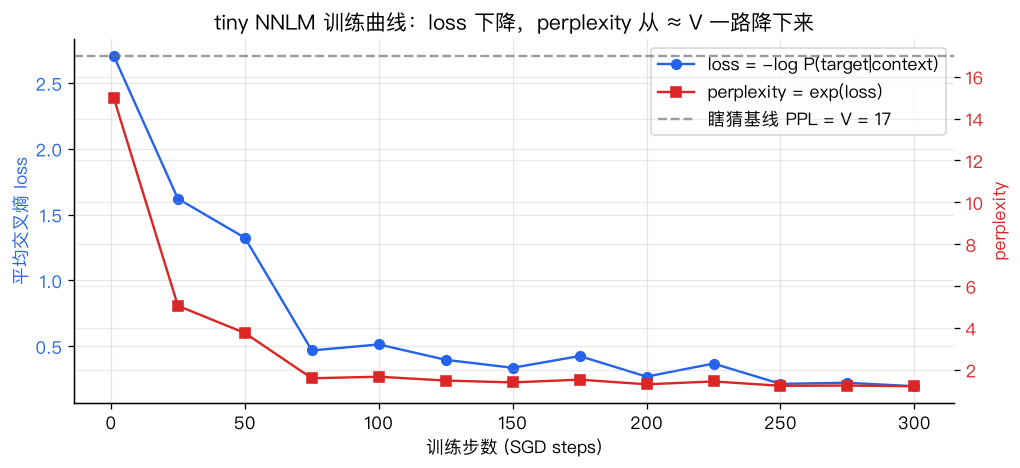

In [68]:
# ------------------------------------------------------------
# Step 4.e  把 loss / perplexity 曲线画出来
# ------------------------------------------------------------
# 两条曲线共享 x 轴（训练步数）：左轴 loss（负对数似然），右轴 perplexity = exp(loss)。
# 读者能亲眼看到 PPL 从 ≈ V 下降 —— 这就是"语言模型在学习"的直接证据。

fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax1.plot(step_hist, loss_hist, marker="o", color=COLORS["blue"], label="loss = -log P(target|context)")
ax1.set_xlabel("训练步数 (SGD steps)")
ax1.set_ylabel("平均交叉熵 loss", color=COLORS["blue"])
ax1.tick_params(axis="y", labelcolor=COLORS["blue"])
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(step_hist, ppl_hist, marker="s", color=COLORS["red"], label="perplexity = exp(loss)")
ax2.axhline(V_t, color=COLORS["gray"], linestyle="--", alpha=0.7,
            label=f"瞎猜基线 PPL = V = {V_t}")
ax2.set_ylabel("perplexity", color=COLORS["red"])
ax2.tick_params(axis="y", labelcolor=COLORS["red"])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax1.set_title("tiny NNLM 训练曲线：loss 下降，perplexity 从 ≈ V 一路降下来")
plt.tight_layout()
plt.show()

**读到这里请确认三件事：**

1. **`cosine(E["black"], E["dark"])` 从接近 0 变成明显为正** —— 训练"顺便"就把近义词的向量拉到了一起，
   这就是所谓 **word embedding**：语言模型的一个副产物，却成了下一代 NLP 的主角。
2. **loss 曲线单调下降，perplexity 从 ≈ V 下降** —— 训练确实在起作用，模型对"下一个词"的把握越来越强。
3. **参考样本 target 词的概率 从 ≈ 1/V 抬到明显大于 1/V** —— 说明网络在学"上下文 → 具体词"的条件分布，
   而不是均匀瞎猜。

这也解释了为什么 Word2Vec 敢**只保留 embedding 层、砍掉隐藏层**：因为在 NNLM 里，
"学到有用的词向量"这个副产物已经被证明能从"预测下一个词"的自监督任务中自然浮现。

### 参数量 & 计算量：为什么 NNLM 一到大词表就跑不动

NNLM 的四组参数，形状清单如下：

| 参数 | 形状 | 参数量 |
|------|------|--------|
| $E$（嵌入表） | $V \times m$ | $Vm$ |
| $W$（隐藏层权重） | $(n-1)m \times h$ | $(n-1)mh$ |
| $b$（隐藏层偏置） | $h$ | $h$ |
| $U$（输出层权重） | $h \times V$ | $hV$ |
| $d$（输出层偏置） | $V$ | $V$ |

**训练一次样本的主要开销集中在输出层**：算 logits 要做一次 $(h) \times (h, V) = (V)$ 的矩阵乘 = $hV$ 次乘加，softmax 归一化也要跑遍 V。把三层前向的乘加数加起来，就是"每步每样本"的完整口径：

$$
\underbrace{\text{每步乘加}}_{\text{forward}} \;\approx\; \underbrace{hV}_{\text{output }Uh+d} \;+\; \underbrace{(n-1)mh}_{\text{hidden }Wx+b} \;+\; \underbrace{Vm}_{\text{embedding table 规模}}
$$

> 说明：$Vm$ 是嵌入表本身的规模（也是稠密更新的上界）；实际前向 lookup 只按索引读取（不产生乘加），稀疏 SGD 每步只更新 $(n-1)m$ 行。

符号一览（本章通用）：**$V$** = 词表大小，**$m$** = embedding 维度，**$n-1$** = 上下文窗口长度，**$h$** = 隐藏层维度。当 $V = 100{,}000$、$m = 100$、$n-1 = 3$、$h = 500$ 时，三项分别是 $5 \times 10^7$、$1.5 \times 10^5$、$1 \times 10^7$，**输出层的 $hV$ 一项就占了 3/4 以上** —— 每一条训练样本都要这么算，而语料里的样本动辄以亿计。这个口径和上面参数量表完全一致：参数量最大的 $U$ 也正是"每步开销"里最贵的那一项。

这就是所谓的 **full softmax 瓶颈**：$O(V)$ 的代价随词表线性增长，直接把 NNLM 卡在中小语料。

Word2Vec（下一章）保留了 embedding 层的伟大发明，但用两条思路绕开这个瓶颈：

1. **hierarchical softmax（层次 softmax）**：把 V 个词组织成二叉树，每次预测走 $\log_2 V$ 步二分类。$V = 100{,}000$ 时 $\log_2 V \approx 17$，一下从 $5 \times 10^7$ 降到 $\sim 10^4$。
2. **negative sampling（负采样）**：把"从 V 个词里挑对的一个"改成"1 个正样本 + $k$ 个随机负样本"的小型二分类。$k = 5 \sim 20$ 就够用，每条样本只需要 $(k+1) h$ 次乘加。

下面的代码把这三种成本对比打出来。

In [69]:
# ------------------------------------------------------------
# Step 5. 参数量对比：tiny NNLM / 现实规模 NNLM / Word2Vec CBOW + SGNS
# ------------------------------------------------------------
# 目的：一眼看到 full softmax 输出层为什么是罪魁祸首，并且明白 Word2Vec
# 的负采样 / 层次 softmax 是怎么把这个 O(V) 砍下去的。

def nnlm_params(V, m, C, h):
    return {
        "embedding E (V*m)":         V * m,
        "hidden W+b ((n-1)m*h + h)": C * m * h + h,
        "output U+d (h*V + V)":      h * V + V,
    }

def show_params(name, parts):
    total = sum(parts.values())
    print(f"[{name}] 总参数量 = {total:,}")
    for k, v in parts.items():
        share = v / total * 100
        print(f"  {k:<32s}: {v:>12,}   ({share:5.1f}%)")
    return total

print("=== tiny NNLM (V=6, m=3, C=3, h=4)：教学用 ===")
show_params("tiny NNLM", nnlm_params(V_nnlm, M_nnlm, C_nnlm, H_nnlm))

print("\n=== 现实规模 NNLM (V=100k, m=100, C=3, h=500)：Bengio 2003 量级 ===")
big_parts = nnlm_params(100_000, 100, 3, 500)
show_params("large NNLM", big_parts)
print("  注意：输出层 U (h*V) 一项就占了大半参数，且 full softmax 每步都要遍历 V。")

print("\n=== Word2Vec CBOW / SGNS：只有两张 embedding 表，没有隐藏层 ===")
V_w2v, m_w2v = 100_000, 100
w2v_params = {
    "input embedding  (V*m)":  V_w2v * m_w2v,
    "output embedding (V*m)":  V_w2v * m_w2v,
}
show_params("Word2Vec (CBOW / SGNS)", w2v_params)
print("  Word2Vec 把 NNLM 的 hidden layer 去掉了，只保留 embedding lookup。"
      "\n  它保留了 NNLM 的核心遗产（词向量），但去掉了参数量最大也最耗时的输出前变换。")

# ---- 每条训练样本的输出层"点积次数"对比：这才是训练速度的关键 ----
V_big, h_big, k_neg = 100_000, 500, 10
full_cost   = V_big * h_big
neg_cost    = (k_neg + 1) * h_big
hier_cost   = math.log2(V_big) * h_big

print("\n每条训练样本，输出层需要做多少次'点积维度乘加':")
print(f"  full softmax      : V * h        = {V_big:>7,} * {h_big} = {full_cost:>15,.0f}")
print(f"  hierarchical soft : log2(V) * h  ≈ {math.log2(V_big):>7.2f} * {h_big} = {hier_cost:>15,.0f}")
print(f"  negative sampling : (k+1) * h    = {k_neg+1:>7,} * {h_big} = {neg_cost:>15,.0f}   (k={k_neg})")
print("\n所以 Word2Vec 相对 NNLM 的加速倍数（以 negative sampling 为例）：")
print(f"  full / neg = {full_cost / neg_cost:,.0f} 倍")

=== tiny NNLM (V=6, m=3, C=3, h=4)：教学用 ===
[tiny NNLM] 总参数量 = 88
  embedding E (V*m)               :           18   ( 20.5%)
  hidden W+b ((n-1)m*h + h)       :           40   ( 45.5%)
  output U+d (h*V + V)            :           30   ( 34.1%)

=== 现实规模 NNLM (V=100k, m=100, C=3, h=500)：Bengio 2003 量级 ===
[large NNLM] 总参数量 = 60,250,500
  embedding E (V*m)               :   10,000,000   ( 16.6%)
  hidden W+b ((n-1)m*h + h)       :      150,500   (  0.2%)
  output U+d (h*V + V)            :   50,100,000   ( 83.2%)
  注意：输出层 U (h*V) 一项就占了大半参数，且 full softmax 每步都要遍历 V。

=== Word2Vec CBOW / SGNS：只有两张 embedding 表，没有隐藏层 ===
[Word2Vec (CBOW / SGNS)] 总参数量 = 20,000,000
  input embedding  (V*m)          :   10,000,000   ( 50.0%)
  output embedding (V*m)          :   10,000,000   ( 50.0%)
  Word2Vec 把 NNLM 的 hidden layer 去掉了，只保留 embedding lookup。
  它保留了 NNLM 的核心遗产（词向量），但去掉了参数量最大也最耗时的输出前变换。

每条训练样本，输出层需要做多少次'点积维度乘加':
  full softmax      : V * h        = 100,000 * 500 =      50,000,000
  hierarchical 

### NNLM 的优劣势与它留给 Word2Vec 的遗产

| 维度 | 早期 NNLM（Bengio 2003） |
|------|--------------------------|
| 优点 | 首次把词表示成可学习的稠密向量；相似词可以共享参数、泛化到未见过的组合 |
| 优点 | 端到端训练，不再依赖人工规则或稀疏共现矩阵 |
| 缺点 | 输出层 full softmax 成本 $O(V)$，词表一大就跑不动 |
| 缺点 | 有一个昂贵的隐藏层，训练一遍语料需要很长时间 |
| 缺点 | 论文里能用的语料规模比 Word2Vec 时代小得多 |

**NNLM 留给 Word2Vec 的三份遗产：**

1. **embedding 层（$V \times m$ 查表）**：Word2Vec 的两张 embedding（输入 + 输出）本质上就是 NNLM 的 $E$。
2. **自监督预测目标**：用"从上下文预测词"作为学习信号的思路，被 CBOW / Skip-gram 直接继承。
3. **上下文窗口概念**：NNLM 用固定长度 $n-1$ 个前文词；Word2Vec 沿用"局部窗口"这个想法，只是不再强调顺序。

**Word2Vec 相对 NNLM 的四刀砍法：**

1. 去掉 tanh 隐藏层 → 参数量和乘加次数都大幅下降。
2. 输出层不再走"隐藏层 → V"这条又贵又长的路，改成两张 embedding 直接内积。
3. full softmax 换成 hierarchical softmax 或 negative sampling → 每条样本从 $O(V)$ 降到 $O(\log V)$ 或 $O(k)$。
4. 目标从"精确建模下一个词的概率分布"退让成"学到好用的词向量" —— 反正下游任务真正需要的是向量，不是完整的语言模型概率。

一句话：**NNLM 发明了词向量，Word2Vec 让词向量能在十亿级语料上训得起。**

**承上启下：** 我们在 Step 4.d 已经亲眼看到 —— NNLM 在训练"下一个词"的同时，就**副产**出了会把 `black` 和 `dark` 聚拢的 embedding。也就是说 word embedding 不需要被单独发明，它是"预测下一个词"这项自监督任务的天然副产品。真正卡住 NNLM 的，只有输出层那个不肯降下来的 $O(V)$ full softmax —— **这正是第 10 章 Word2Vec 用 negative sampling / hierarchical softmax 要解决的问题**：既然我们只想要 embedding，那就没必要精确建模 $V$ 类分布，用几十个负样本或一棵二叉树把这一步砍到 $O(k)$ 或 $O(\log V)$ 就够用了。

## 10 · 总对比：Word2Vec 到底改变了什么

### 一句话直觉

前 9 章像九级台阶：每一步都在填上一步留下的坑。走到这里，**Word2Vec** 做的事情其实可以浓缩成一句话——**用一个足够简单、足够高效的自监督任务（预测上下文），在大语料上把每个词训练成一个稠密向量（dense vector）**。这一章把整条路线拉直，看清楚"到底新在哪里"，同时也讲清楚"哪里还不够，所以后来还有 GloVe / fastText / ELMo / BERT"。

### 关键中英文对照

| 英文 / 缩写 | 中文名 | 一句话说明 |
|-------------|--------|------------|
| Word2Vec | 词向量模型 | 用局部上下文自监督地学习稠密词向量 |
| Skip-gram | 跳字模型 | 用**中心词**预测**上下文词** |
| CBOW (Continuous Bag-of-Words) | 连续词袋模型 | 用**上下文词**预测**中心词** |
| Negative Sampling | 负采样 | 用 1 个正样本 + k 个噪声样本，把多分类近似成二分类 |
| SGNS (Skip-gram with Negative Sampling) | 带负采样的跳字模型 | Skip-gram + Negative Sampling 的组合，是最常用的一种 |
| Hierarchical Softmax | 层次 softmax | 用二叉树（常见 Huffman 树）把 O(V) 归一化降到约 O(log V) |
| Subsampling | 下采样 / 高频词降采样 | 按公式概率丢弃部分高频词，降噪并加速 |
| Static Embedding | 静态词向量 | 每个词固定一个向量，无法区分不同语境下的词义 |
| Analogy | 类比 | `king - man + woman ≈ queen` 这类向量运算 |
| Cosine Similarity | 余弦相似度 | 用向量夹角衡量语义接近程度 |
| OOV (Out-of-Vocabulary) | 未登录词 | 训练时没见过的词，静态词表拿不到向量 |
| Contextual Embedding | 上下文词向量 | 词向量随句子上下文变化，ELMo / BERT 属于这一类 |

### 演进大表：九种方法一次对齐

下面这张表把前 9 章讲过的方法放在同一坐标系里比较。列出的"最大短板"就是**下一步方法主要在解决的问题**——沿着最右边一列往下读，就能看到一条清晰的演进链。

| # | 技术 | 输入表示 / 训练信号 | 是否考虑词序 | 语义相似能力 | 人工特征依赖 | 主要任务 | 最大短板（下一步要补的坑） |
|---|------|--------------------|--------------|--------------|--------------|----------|----------------------------|
| 1 | 规则 / 词典 | 字符串命中 | 依赖规则 | 弱 | 高 | 抽取、清洗 | 泛化差，写不完 |
| 2 | N-gram | 离散词序列 | 短窗口 | 弱 | 中 | 语言模型 | 数据稀疏，长距离失效 |
| 3 | BoW / TF-IDF | 高维稀疏向量 | 否 | 弱 | 中 | 检索、分类 | 不懂同义词 |
| 4 | 传统 ML（NB/LR/SVM） | 稀疏特征 + 人工特征 | 取决于特征 | 中 | 高 | 分类 | 特征工程重 |
| 5 | HMM / CRF | 序列特征 | 是 | 中 | 高 | 分词、NER | 词表示仍是离散 ID / 稀疏特征 |
| 6 | LSA / PLSA / LDA | 文档-词矩阵 | 否 | 中 | 中 | 主题、聚类 | 偏文档级，词级语义不精细 |
| 7 | 共现 / PPMI / SVD | word-context 矩阵 | 窗口内共现 | 强 | 低 | 词语义 | 大矩阵成本高，增量更新难 |
| 8 | 早期 NNLM | 上下文词 ID → embedding lookup | 是 | 强 | 低 | 语言模型 | full softmax 慢，难扩到大语料 |
| 9 | **Word2Vec** | 中心词 / 上下文词 ID，产物是 embedding | 局部窗口，弱化顺序 | 强 | 低 | 词表示 | **静态词义**（不分语境） |

一句话读法：**Word2Vec 不是"第一次用上下文"，也不是"第一次学词向量"**——它是把第 7 章的"共现直觉"和第 8 章的"神经词向量"合并起来，并用一组工程技巧（负采样 / 层次 softmax / 下采样）让它跑得足够快。

findfont: Failed to find font weight bold, now using 600.


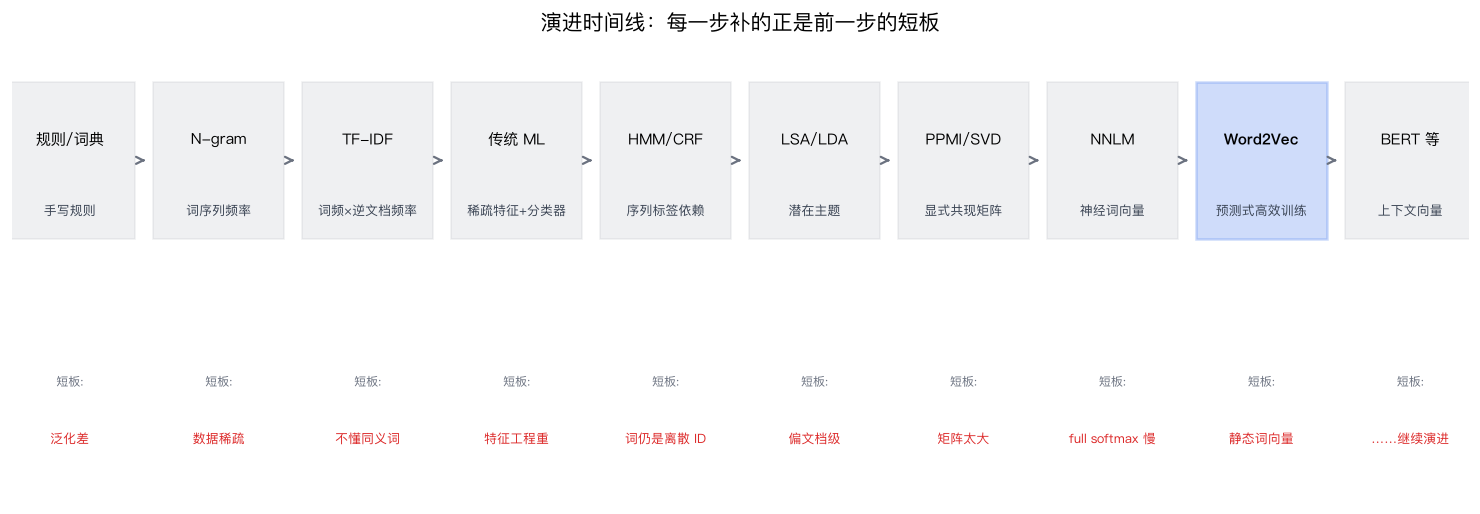

In [70]:
# ------------------------------------------------------------
# Step 0. 把演进链画成时间线：每一步在补前一步的哪个短板
# ------------------------------------------------------------
# 不训练任何模型，只做可视化：让读者一眼看到"每一层解决了什么问题"。
stages = [
    ("规则/词典",     "手写规则",           "泛化差"),
    ("N-gram",       "词序列频率",         "数据稀疏"),
    ("TF-IDF",       "词频×逆文档频率",     "不懂同义词"),
    ("传统 ML",       "稀疏特征+分类器",     "特征工程重"),
    ("HMM/CRF",      "序列标签依赖",        "词仍是离散 ID"),
    ("LSA/LDA",      "潜在主题",           "偏文档级"),
    ("PPMI/SVD",     "显式共现矩阵",        "矩阵太大"),
    ("NNLM",         "神经词向量",          "full softmax 慢"),
    ("Word2Vec",     "预测式高效训练",      "静态词向量"),
    ("BERT 等",       "上下文向量",          "……继续演进"),
]

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.axis("off")
xs = np.linspace(0.04, 0.96, len(stages))
for i, ((name, idea, weakness), x) in enumerate(zip(stages, xs)):
    is_w2v = (name == "Word2Vec")
    color = COLORS["blue"] if is_w2v else COLORS["gray"]
    rect = plt.Rectangle((x - 0.045, 0.62), 0.09, 0.22,
                         facecolor=color, alpha=0.22 if is_w2v else 0.10,
                         edgecolor=color, linewidth=1.6 if is_w2v else 1.0)
    ax.add_patch(rect)
    ax.text(x, 0.76, name, ha="center", va="center", fontsize=9.5,
            fontweight="bold" if is_w2v else "normal")
    ax.text(x, 0.66, idea, ha="center", va="center", fontsize=8, color="#374151")
    ax.text(x, 0.42, "短板:", ha="center", va="center", fontsize=7.5, color="#6b7280")
    ax.text(x, 0.34, weakness, ha="center", va="center", fontsize=8, color=COLORS["red"])
    if i < len(stages) - 1:
        ax.annotate("", xy=(xs[i + 1] - 0.048, 0.73), xytext=(x + 0.048, 0.73),
                    arrowprops=dict(arrowstyle="->", linewidth=1.4, color="#6b7280"))
ax.set_title("演进时间线：每一步补的正是前一步的短板")
ax.set_xlim(0, 1)
ax.set_ylim(0.25, 0.9)
plt.tight_layout()
plt.show()

### Word2Vec 到底"新"在哪里

如果把 Word2Vec 的贡献拆开，其实是四个正交的推进——**它们各自都不算新**，但组合起来第一次让"在亿级语料上学好词向量"成为工程上现实可行的事：

1. **从稀疏到稠密**：抛弃 one-hot / TF-IDF 的几万维稀疏表示，改用 50~300 维的稠密向量（dense vector）。
2. **从人工特征到自监督**：不需要标注，用"预测上下文 / 中心词"自动产生训练信号。这是**自监督学习（self-supervised learning）**的一个早期成功案例。
3. **从显式大矩阵到预测式训练**：第 7 章的 PPMI/SVD 要先把 |V|×|V| 的共现矩阵写出来；Word2Vec 只需要一次次看到 (中心词, 上下文词) 对，*隐式*地拟合了类似 shifted PMI 的结构（见 Levy & Goldberg, 2014）。
4. **从慢速 NNLM 到高效词向量训练**：三件加速套件——**Negative Sampling（负采样）**、**Hierarchical Softmax（层次 softmax）**、**Subsampling（下采样）**——把 full softmax 的 O(V) 代价压到 O(k) 或 O(log V)。

### Skip-gram vs CBOW：两种任务方向

| 方向 | 输入 | 输出（要预测的） | 直觉 | 谁更擅长罕见词 |
|------|------|------------------|------|----------------|
| Skip-gram（跳字模型） | 中心词 $w_c$ | 窗口内每个上下文词 $w_o$ | 一个词"辐射"出它的邻居 | Skip-gram（每个中心词都独立训练一组正样本） |
| CBOW（连续词袋） | 窗口内上下文词的平均 | 中心词 $w_c$ | 用一堆邻居"猜"中间那个 | CBOW 训练更快、但罕见词学得稍弱 |

### SGNS 的损失函数：把多分类"压扁"成二分类

Skip-gram 的原始目标是"预测上下文词" $P(w_o \mid w_c)$，那是一个 |V| 类的多分类。如果直接用 full softmax，每一步都要对整个词表算一次归一化，成本 O(V)。

**Negative Sampling（负采样）**的关键 trick：把这个多分类问题**改造成 (k+1) 个二分类**——"这个上下文词是真的正样本吗？" 对一个正样本对 $(w_c, w_o)$ 和 $k$ 个负样本 $w_{n_1}, \dots, w_{n_k}$，损失是：

$$\mathcal{L}_{\text{SGNS}} = -\underbrace{\log \sigma(\mathbf{v}_{w_o}^{\top} \mathbf{u}_{w_c})}_{\text{正样本：拉近}} \;-\; \sum_{i=1}^{k} \underbrace{\log \sigma(-\mathbf{v}_{w_{n_i}}^{\top} \mathbf{u}_{w_c})}_{\text{负样本：推远}}$$

其中：

- $\mathbf{u}_w$ 是词 $w$ 作为**中心词**时的向量（input embedding）；
- $\mathbf{v}_w$ 是词 $w$ 作为**上下文词**时的向量（output embedding）；
- $\sigma(x) = 1 / (1 + e^{-x})$ 是 sigmoid（S 形函数）；
- 负样本 $w_{n_i}$ 从一个噪声分布采样，Word2Vec 用 $P_n(w) \propto U(w)^{0.75}$（把 unigram 频率取 0.75 次方，让高频词的采样概率被削一点，低频词稍抬起来）。

**直觉**：正样本项想让"中心词和真上下文词的内积尽量大"；负样本项想让"中心词和随机噪声词的内积尽量小（负号让 sigmoid 输入反向）"。梯度下降的每一步只碰 (k+1) 个词向量，而不是整个词表。

### Hierarchical Softmax：另一条加速路

**Hierarchical Softmax（层次 softmax）** 是 Negative Sampling 之外的另一种加速办法。它把词表组织成一棵二叉树（Word2Vec 用 **Huffman tree（哈夫曼树）**，高频词离根更近），把"选中词 w 的概率"分解成"从根走到叶子 w 一路上每次向左/向右的概率乘积"：

$$P(w \mid w_c) = \prod_{j=1}^{L(w)-1} \sigma\big(\text{sign}(j) \cdot \mathbf{n}_j^{\top} \mathbf{u}_{w_c}\big)$$

其中：

- $L(w)$ 是从根节点到叶子 $w$ 的路径长度（经过的节点数）；
- $\mathbf{n}_j$ 是路径上第 $j$ 个**内部节点**的参数向量（不是词向量本身）；
- $\text{sign}(j) \in \{+1, -1\}$ 表示在第 $j$ 个内部节点上，我们要往左还是往右走才能走向目标叶子 $w$。约定 **左子节点 = +1、右子节点 = -1**（不同实现约定可能相反，重要的是保持一致）。这样 $\sigma(+\mathbf{n}_j^{\top}\mathbf{u}_{w_c})$ 就是"向左走"的概率，$\sigma(-\mathbf{n}_j^{\top}\mathbf{u}_{w_c}) = 1-\sigma(\mathbf{n}_j^{\top}\mathbf{u}_{w_c})$ 就是"向右走"的概率。

因为每个词对应的路径长度是 $O(\log V)$，一次前向/反向只更新 $\log_2(V)$ 个内部节点向量，而不是 V 个词向量。**Negative Sampling 更常用于大语料**，**Hierarchical Softmax 在词表分布极偏时更省资源**。

### 一个哲学上的转变

第 7 章我们要**先构造**一张完整的 word-context 共现矩阵，再对它 SVD。这是**批量、显式、全局**的思路。Word2Vec 把它换成：**每次只看一小段窗口，用局部预测去拟合全局语义**。这就是"**用局部预测得到全局语义**"——现代自监督学习几乎所有做法的雏形。

In [71]:
# ------------------------------------------------------------
# Step 1. 从一个小语料抽 (center, context) 训练对
# ------------------------------------------------------------
# Word2Vec 的训练数据长这样：对每个中心词，取窗口内的邻居作为它的"正样本上下文"。
# 这里精心设计一个"迷你但共现更充分"的语料，让 king / queen / man / woman /
# prince / princess 在窗口内多次共现——这样 Step 4 的类比演示才有一点可视信号。
# 但请注意，即便如此，toy 规模也无法复现原论文 king-queen analogy；本节的目的是
# **展示方法论**（SGNS 的形式）而不是复现效果。
w2v_corpus = [
    "the cat sat on the mat",
    "the dog sat on the mat",
    "the cat and the dog play together",
    "a queen ruled the kingdom wisely",
    "a king ruled the kingdom bravely",
    "the king and the queen ruled the kingdom together",
    "the king loves the queen",
    "the queen loves the king",
    "a prince and a princess lived in the kingdom",
    "the prince loves the princess",
    "the princess loves the prince",
    "the king is a man and the queen is a woman",
    "the prince is a man and the princess is a woman",
    "the man loves the woman",
    "the woman loves the man",
    "a man became a king and a woman became a queen",
    "a boy became a prince and a girl became a princess",
    "the king and the man walked in the kingdom",
    "the queen and the woman walked in the kingdom",
    "the prince and the boy played in the kingdom",
    "the princess and the girl played in the kingdom",
]

def tokenize_simple(s):
    return re.findall(r"[a-z]+", s.lower())

WINDOW = 2  # 窗口半径：左右各取 2 个词
pairs = []
for sent in w2v_corpus:
    toks = tokenize_simple(sent)
    for i, center in enumerate(toks):
        lo, hi = max(0, i - WINDOW), min(len(toks), i + WINDOW + 1)
        for j in range(lo, hi):
            if j == i:
                continue
            pairs.append((center, toks[j]))

print(f"语料共 {len(w2v_corpus)} 句，窗口半径 = {WINDOW}")
print(f"抽出 (center, context) 训练对：共 {len(pairs)} 条")
print("前 12 条：")
for c, o in pairs[:12]:
    print(f"  center = {c:<8s}  context = {o}")

vocab_counter = Counter()
for sent in w2v_corpus:
    vocab_counter.update(tokenize_simple(sent))
w2v_vocab = sorted(vocab_counter.keys())
w2v_w2i = {w: i for i, w in enumerate(w2v_vocab)}
print(f"\n词表大小 |V| = {len(w2v_vocab)}: {w2v_vocab}")

语料共 21 句，窗口半径 = 2
抽出 (center, context) 训练对：共 510 条
前 12 条：
  center = the       context = cat
  center = the       context = sat
  center = cat       context = the
  center = cat       context = sat
  center = cat       context = on
  center = sat       context = the
  center = sat       context = cat
  center = sat       context = on
  center = sat       context = the
  center = on        context = cat
  center = on        context = sat
  center = on        context = the

词表大小 |V| = 29: ['a', 'and', 'became', 'boy', 'bravely', 'cat', 'dog', 'girl', 'in', 'is', 'king', 'kingdom', 'lived', 'loves', 'man', 'mat', 'on', 'play', 'played', 'prince', 'princess', 'queen', 'ruled', 'sat', 'the', 'together', 'walked', 'wisely', 'woman']


In [72]:
# ------------------------------------------------------------
# Step 2. 下采样 (subsampling) + 负采样 (negative sampling)
# ------------------------------------------------------------
# 高频词（the / a / on）出现太多，会淹没有意义的信号。
# Word2Vec 原论文给的丢弃概率:
#     P_drop(w) = 1 - sqrt(t / f(w))         (只有当 f(w) > t 时才可能 > 0)
# 其中 f(w) 是词频占比，t 是阈值（原文常用 1e-5，教学里为了看到效果调大）。
total_w2v = sum(vocab_counter.values())
freq = {w: c / total_w2v for w, c in vocab_counter.items()}
t_thresh = 0.05

print("Step 2a  下采样丢弃概率（阈值 t = 0.05）：")
print(f"  {'word':<10s}{'freq':>8s}{'P_drop':>10s}")
for w in sorted(freq, key=freq.get, reverse=True):
    f = freq[w]
    p_drop = max(0.0, 1 - math.sqrt(t_thresh / f)) if f > 0 else 0
    print(f"  {w:<10s}{f:>8.3f}{p_drop:>10.3f}")

# 噪声分布：P_n(w) ∝ U(w)^0.75  —— 把 unigram 频率整体"压平"一点
raw_probs = np.array([vocab_counter[w] for w in w2v_vocab], dtype=float)
raw_probs /= raw_probs.sum()
noise_probs = raw_probs ** 0.75
noise_probs /= noise_probs.sum()

print("\nStep 2b  噪声分布 P_n(w) ∝ U(w)^0.75（Top-6）：")
order = np.argsort(-noise_probs)
for idx_n in order[:6]:
    w = w2v_vocab[idx_n]
    print(f"  {w:<10s}  U(w) = {raw_probs[idx_n]:.3f}   P_n(w) = {noise_probs[idx_n]:.3f}")

rng_neg = np.random.default_rng(SEED)
K_NEG = 5
sample_center, sample_context = "king", "kingdom"
neg_samples = rng_neg.choice(w2v_vocab, size=K_NEG, p=noise_probs, replace=True)
print(f"\nStep 2c  对正样本对 (center={sample_center}, context={sample_context}) 采 {K_NEG} 个负样本：")
print(f"  {list(neg_samples)}")
print("  （注意负样本是从整个词表按噪声分布采的，可能碰巧采到真上下文，工程实现里通常直接接受这种小噪声。）")

Step 2a  下采样丢弃概率（阈值 t = 0.05）：
  word          freq    P_drop
  the          0.252     0.554
  a            0.101     0.295
  and          0.069     0.150
  kingdom      0.050     0.003
  queen        0.044     0.000
  king         0.044     0.000
  loves        0.038     0.000
  prince       0.038     0.000
  princess     0.038     0.000
  man          0.038     0.000
  woman        0.038     0.000
  in           0.031     0.000
  is           0.025     0.000
  became       0.025     0.000
  ruled        0.019     0.000
  cat          0.013     0.000
  sat          0.013     0.000
  on           0.013     0.000
  mat          0.013     0.000
  dog          0.013     0.000
  together     0.013     0.000
  boy          0.013     0.000
  girl         0.013     0.000
  walked       0.013     0.000
  played       0.013     0.000
  play         0.006     0.000
  wisely       0.006     0.000
  bravely      0.006     0.000
  lived        0.006     0.000

Step 2b  噪声分布 P_n(w) ∝ U(w)^0.75（Top-6

In [73]:
# ------------------------------------------------------------
# Step 3. 手算 SGNS loss 一格：正样本 + 一个负样本各算一次
# ------------------------------------------------------------
# 这里给一组"人造"的词向量（3 维就够看清楚），不训练，只演示 loss 是怎么加出来的。
# 直觉：让 king 和 kingdom 的内积大 -> 正样本 log σ(·) 接近 0；
#      让 king 和"随机噪声词 fish" 的内积小 -> 负样本 log σ(-·) 也接近 0。
def sigmoid(x):
    return 1.0 / (1.0 + math.exp(-x))

toy_emb = {
    "king":    np.array([ 0.9,  0.1,  0.2]),
    "queen":   np.array([ 0.8,  0.2,  0.3]),
    "man":     np.array([ 0.7, -0.1,  0.1]),
    "woman":   np.array([ 0.6,  0.0,  0.4]),
    "kingdom": np.array([ 0.7,  0.3,  0.2]),
    "cat":     np.array([-0.2,  0.5, -0.4]),
    "fish":    np.array([-0.3,  0.4, -0.5]),
    "mat":     np.array([-0.1,  0.6, -0.3]),
}
# 这里给 input / context 各一套 embedding，与原论文一致（u = 中心词侧，v = 上下文词侧）；
# 教学演示只是"造一组数手算一下 loss"，并不做联合训练，所以直接让 v 在 u 上加一个
# 微小扰动即可——形状上让两套向量各自独立，避免与上文 u_w / v_w 的记号打架。
rng_uv = np.random.default_rng(SEED)
u = {w: vec.copy() for w, vec in toy_emb.items()}
v = {w: vec + 0.05 * rng_uv.standard_normal(vec.shape) for w, vec in toy_emb.items()}

center = "king"
positive = "kingdom"
negatives = ["cat", "fish", "mat"]

pos_dot = float(u[center] @ v[positive])
pos_sig = sigmoid(pos_dot)
pos_loss = -math.log(pos_sig)

print("SGNS loss 单个训练样本的手算过程：")
print(f"  正样本 (center={center}, context={positive})")
print(f"    u_{center} · v_{positive} = {pos_dot:+.3f}")
print(f"    σ(·)                  = {pos_sig:.3f}")
print(f"    - log σ(·)            = {pos_loss:.3f}   <- 想让它接近 0，就要让内积大")

neg_terms = []
for n in negatives:
    neg_dot = float(u[center] @ v[n])
    neg_sig = sigmoid(-neg_dot)
    neg_loss = -math.log(neg_sig)
    neg_terms.append((n, neg_dot, neg_sig, neg_loss))
    print(f"  负样本 (center={center}, noise={n})")
    print(f"    u_{center} · v_{n:<7s}= {neg_dot:+.3f}")
    print(f"    σ(-·)                = {neg_sig:.3f}")
    print(f"    - log σ(-·)          = {neg_loss:.3f}   <- 想让它接近 0，就要让内积小/为负")

total_loss = pos_loss + sum(t[3] for t in neg_terms)
print(f"\n  合计 loss = {pos_loss:.3f} + " +
      " + ".join(f"{t[3]:.3f}" for t in neg_terms) + f" = {total_loss:.3f}")
print("\n关键观察：")
print(" - loss 只依赖 (k+1) 个词向量的内积，没有 V 维 softmax；")
print(" - 训练 = 用梯度下降同时拉近 (king, kingdom)、推远 (king, cat/fish/mat)。")

SGNS loss 单个训练样本的手算过程：
  正样本 (center=king, context=kingdom)
    u_king · v_kingdom = +0.713
    σ(·)                  = 0.671
    - log σ(·)            = 0.399   <- 想让它接近 0，就要让内积大
  负样本 (center=king, noise=cat)
    u_king · v_cat    = -0.256
    σ(-·)                = 0.564
    - log σ(-·)          = 0.573   <- 想让它接近 0，就要让内积小/为负
  负样本 (center=king, noise=fish)
    u_king · v_fish   = -0.293
    σ(-·)                = 0.573
    - log σ(-·)          = 0.558   <- 想让它接近 0，就要让内积小/为负
  负样本 (center=king, noise=mat)
    u_king · v_mat    = -0.116
    σ(-·)                = 0.529
    - log σ(-·)          = 0.637   <- 想让它接近 0，就要让内积小/为负

  合计 loss = 0.399 + 0.573 + 0.558 + 0.637 = 2.166

关键观察：
 - loss 只依赖 (k+1) 个词向量的内积，没有 V 维 softmax；
 - 训练 = 用梯度下降同时拉近 (king, kingdom)、推远 (king, cat/fish/mat)。


In [74]:
# ------------------------------------------------------------
# Step 4. 用少量梯度步演示 king - man + woman ≈ queen
# ------------------------------------------------------------
# 我们不训练真的 Word2Vec，只把上面的人造 embedding 顺着 SGNS 梯度走 40 轮，
# 让"共出现在一起的词"稍微靠近一些，然后做一次向量类比。
np.random.seed(SEED)

demo_vocab = sorted(set([w for pair in pairs for w in pair]))
w2i_demo = {w: i for i, w in enumerate(demo_vocab)}
D_dim = 8
Emb = 0.1 * np.random.randn(len(demo_vocab), D_dim)
Ctx = 0.1 * np.random.randn(len(demo_vocab), D_dim)

counts = np.array([vocab_counter[w] for w in demo_vocab], dtype=float)
p_noise = counts ** 0.75
p_noise /= p_noise.sum()

lr = 0.05
K = 5
EPOCHS = 40
rng2 = np.random.default_rng(SEED)

def sgd_sgns_step(c_idx, o_idx, neg_idx):
    u_c = Emb[c_idx]
    v_o = Ctx[o_idx]
    s = 1.0 / (1.0 + np.exp(-u_c @ v_o))
    grad_uc = (s - 1) * v_o
    Ctx[o_idx] -= lr * (s - 1) * u_c
    for n in neg_idx:
        v_n = Ctx[n]
        s_n = 1.0 / (1.0 + np.exp(-u_c @ v_n))
        grad_uc = grad_uc + s_n * v_n
        Ctx[n] -= lr * s_n * u_c
    Emb[c_idx] -= lr * grad_uc

for epoch in range(EPOCHS):
    rng2.shuffle(pairs)
    for c, o in pairs:
        neg = rng2.choice(len(demo_vocab), size=K, p=p_noise, replace=True)
        sgd_sgns_step(w2i_demo[c], w2i_demo[o], neg)

def cos_sim(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

def top_k_similar(vec, k=5, exclude=()):
    sims = [(w, cos_sim(vec, Emb[w2i_demo[w]])) for w in demo_vocab if w not in exclude]
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:k]

if all(w in w2i_demo for w in ["king", "man", "woman", "queen"]):
    q = Emb[w2i_demo["king"]] - Emb[w2i_demo["man"]] + Emb[w2i_demo["woman"]]
    print("向量类比 king - man + woman = ?")
    print(f"  Top-5 相似词（排除 king / man / woman）：")
    for w, s in top_k_similar(q, k=5, exclude={"king", "man", "woman"}):
        marker = "  <- 期望答案" if w == "queen" else ""
        print(f"    {w:<10s} cos = {s:+.3f}{marker}")
    print("\n提示：这是 toy 规模的演示（约 20 句、40 轮），Top-1 不一定是 queen；")
    print("      我们真正想让你看到的是 '性别方向' 这一线性结构的雏形——见下面两块。")
else:
    print("语料里缺少类比需要的词。")

# ------------------------------------------------------------
# 平行差向量：即使 Top-1 不是 queen，也能看到 king-queen 例的雏形
# ------------------------------------------------------------
# 原论文的核心洞察是 king - man ≈ queen - woman ——
# 即把 "性别方向" 从 king 减掉后剩下的语义（王/统治），
# 也应该出现在把 "性别方向" 从 queen 减掉后剩下的语义里。
# 直接比较两个差向量的方向：cos 越接近 +1，说明 "平行结构" 越干净。
pair_analogies = [
    ("king",  "queen",   "man",   "woman"),   # 性别方向
    ("king",  "man",     "queen", "woman"),   # 阶层方向
    ("king",  "prince",  "queen", "princess"),# 年龄方向（如存在）
    ("man",   "boy",     "woman", "girl"),
]
print("\n平行差向量检查（cos 越接近 +1，方向越一致）：")
for a, b, c, d in pair_analogies:
    if all(w in w2i_demo for w in (a, b, c, d)):
        diff1 = Emb[w2i_demo[a]] - Emb[w2i_demo[b]]
        diff2 = Emb[w2i_demo[c]] - Emb[w2i_demo[d]]
        s = cos_sim(diff1, diff2)
        print(f"  cos( vec({a}) - vec({b}) ,  vec({c}) - vec({d}) ) = {s:+.3f}")

# ------------------------------------------------------------
# 相对距离矩阵：核心 4 词两两 cos，看 "同性别 / 同阶层" 是否更近
# ------------------------------------------------------------
core = [w for w in ["king", "queen", "man", "woman"] if w in w2i_demo]
if len(core) >= 3:
    print("\n相对距离矩阵（核心 4 词，值为 cos 相似度；对角线恒为 1）：")
    header = "         " + "".join(f"{w:>10s}" for w in core)
    print(header)
    for r in core:
        row_vals = [cos_sim(Emb[w2i_demo[r]], Emb[w2i_demo[c]]) for c in core]
        print(f"  {r:<7s}" + "".join(f"{v:>+10.3f}" for v in row_vals))
    print("  读法：king 应该同时靠近 queen（同为王室）和 man（同为男性）；")
    print("        woman 应该同时靠近 queen（同为女性）和 man（同为普通人/性别对偶）。")
    print("        toy 规模下数字不会很干净，重点看 '相对大小'，不是绝对值。")

print("\n几组余弦相似度（教学量级，语料太小请只看相对大小）：")
for a, b in [("king", "queen"), ("man", "woman"), ("king", "kingdom"),
             ("cat", "dog"), ("king", "cat")]:
    if a in w2i_demo and b in w2i_demo:
        print(f"  cos({a}, {b}) = {cos_sim(Emb[w2i_demo[a]], Emb[w2i_demo[b]]):+.3f}")

print("\n方法论提醒：toy 规模无法可靠复现原论文 king-queen 例；")
print("此处旨在展示 SGNS 的形式、以及 '差向量方向一致' 这一线性结构雏形。")

向量类比 king - man + woman = ?
  Top-5 相似词（排除 king / man / woman）：
    queen      cos = +0.989  <- 期望答案
    prince     cos = +0.928
    princess   cos = +0.813
    girl       cos = +0.599
    boy        cos = +0.544

提示：这是 toy 规模的演示（约 20 句、40 轮），Top-1 不一定是 queen；
      我们真正想让你看到的是 '性别方向' 这一线性结构的雏形——见下面两块。

平行差向量检查（cos 越接近 +1，方向越一致）：
  cos( vec(king) - vec(queen) ,  vec(man) - vec(woman) ) = -0.353
  cos( vec(king) - vec(man) ,  vec(queen) - vec(woman) ) = +0.973
  cos( vec(king) - vec(prince) ,  vec(queen) - vec(princess) ) = +0.635
  cos( vec(man) - vec(boy) ,  vec(woman) - vec(girl) ) = +0.939

相对距离矩阵（核心 4 词，值为 cos 相似度；对角线恒为 1）：
               king     queen       man     woman
  king       +1.000    +0.994    +0.788    +0.795
  queen      +0.994    +1.000    +0.768    +0.772
  man        +0.788    +0.768    +1.000    +0.997
  woman      +0.795    +0.772    +0.997    +1.000
  读法：king 应该同时靠近 queen（同为王室）和 man（同为男性）；
        woman 应该同时靠近 queen（同为女性）和 man（同为普通人/性别对偶）。
        toy 规模下数字不会很干净

### 加速对比：full softmax vs negative sampling vs hierarchical softmax

假设词表 $V = 100{,}000$，隐藏维度 $H = 300$，负采样数 $k = 10$。每处理一个训练样本，输出层要做的向量点积次数大致是：

| 方案 | 每样本输出层代价 | 数量级 |
|------|-----------------|--------|
| full softmax | $V \cdot H = 100{,}000 \times 300$ | ~30M |
| negative sampling | $(k+1) \cdot H = 11 \times 300$ | ~3.3K |
| hierarchical softmax | $\log_2 V \cdot H \approx 16.6 \times 300$ | ~5K |

也就是说，Negative Sampling 把训练成本压到大约**只有 full softmax 的万分之一**——这就是 Word2Vec 能在维基百科规模语料上跑得动的直接原因。

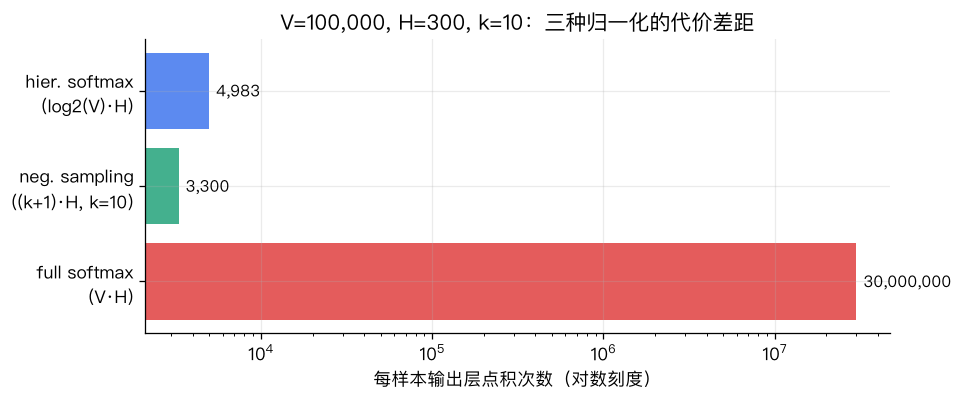

In [75]:
# ------------------------------------------------------------
# Step 5. 把上面的加速对比画成条形图（对数刻度）
# ------------------------------------------------------------
V_big, H_big, k_big = 100_000, 300, 10
costs = {
    "full softmax\n(V·H)":            V_big * H_big,
    f"neg. sampling\n((k+1)·H, k={k_big})": (k_big + 1) * H_big,
    "hier. softmax\n(log2(V)·H)":     math.log2(V_big) * H_big,
}
fig, ax = plt.subplots(figsize=(8.5, 3.6))
names = list(costs.keys())
vals = list(costs.values())
bars = ax.barh(names, vals, color=[COLORS["red"], COLORS["green"], COLORS["blue"]], alpha=0.75)
ax.set_xscale("log")
ax.set_xlabel("每样本输出层点积次数（对数刻度）")
ax.set_title(f"V={V_big:,}, H={H_big}, k={k_big}：三种归一化的代价差距")
for b, v in zip(bars, vals):
    ax.text(v * 1.1, b.get_y() + b.get_height() / 2, f"{v:,.0f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

### Word2Vec 没有解决什么：静态词向量的边界

Word2Vec 是**表示学习（representation learning）**的一个里程碑，但它绝不是 NLP 的终点。下面几件事，它做不了，或者做得不好：

1. **一词多义处理不了（Polysemy）**
   `bank` 既可以是"银行"又可以是"河岸"，但 Word2Vec 给它**同一个向量**。这就是**静态词向量（static embedding）**的字面意思。
2. **未登录词（OOV, Out-of-Vocabulary）**
   训练时没见过的词直接没有向量。这也是 **fastText** 引入**子词（subword）** n-gram 的动机——用字符片段拼出未见过的词。
3. **句级 / 篇章级语义仍需上层模型**
   Word2Vec 只给"一个词一个向量"，句子表示需要额外的池化或序列模型（BiLSTM、Transformer 等）。
4. **词序在窗口内被弱化**
   Skip-gram / CBOW 都不严格保留窗口内的顺序，句法结构靠上层模型补。
5. **偏见与语料印记**
   词向量会继承训练语料里的社会偏见（`doctor` 更接近 `he`，`nurse` 更接近 `she` 等），这是后续公平性研究的重要议题。

### 通往后续模型的路线图

| 局限 | 后续代表工作 | 一句话思路 |
|------|--------------|------------|
| 只用局部窗口，忽略全局共现统计 | **GloVe (2014)** | 直接拟合全局共现比率的对数，把矩阵派和预测派合起来 |
| OOV / 形态变化 | **fastText (2016)** | 词向量 = 子词 n-gram 向量之和 |
| 一词多义 / 静态 | **ELMo (2018)** | 用双向 LSTM 的**上下文向量（contextual embedding）**代替静态向量 |
| 仍只是特征提取器 | **BERT (2018)** | 用 Transformer + Masked LM 预训练，再对下游任务微调 |
| 生成式与对齐 | **GPT / T5 系列** | 把预训练进一步扩展为生成/指令跟随，逐步走向今天的大模型 |

Word2Vec 的位置：它是"**词向量成为标准输入**"这一整套现代 NLP 范式的起点。

findfont: Failed to find font weight bold, now using 600.


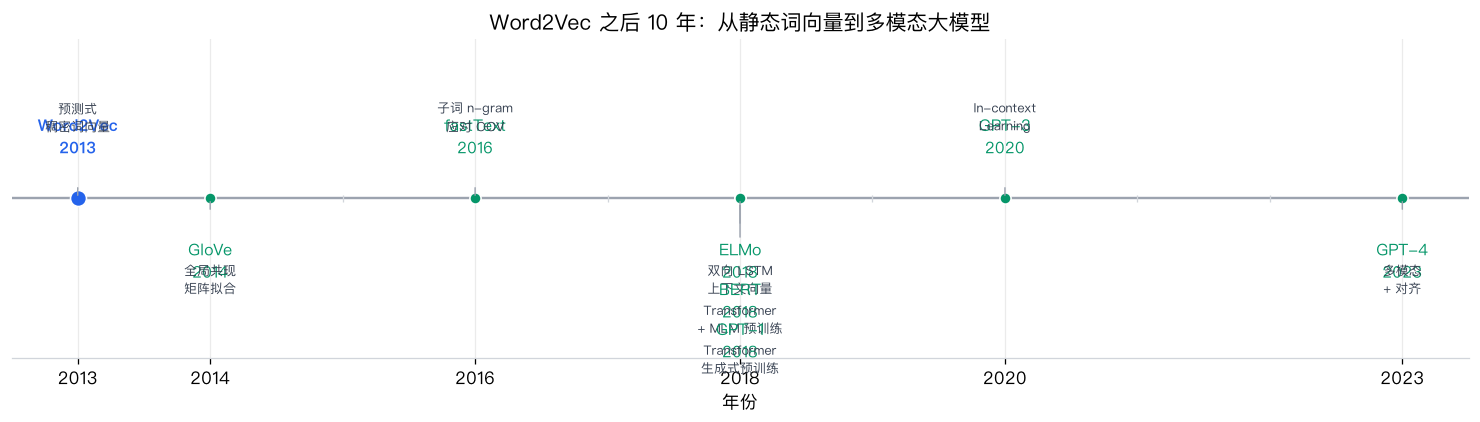

In [76]:
# ------------------------------------------------------------
# Step 6. 把"Word2Vec 之后 10 年"画成一张水平时间线
# ------------------------------------------------------------
# 让上面的"路线图"表格图形化：一眼看到 Word2Vec 之后的每一次范式跃迁。
milestones = [
    (2013, "Word2Vec",  "预测式\n稠密词向量"),
    (2014, "GloVe",     "全局共现\n矩阵拟合"),
    (2016, "fastText",  "子词 n-gram\n应对 OOV"),
    (2018, "ELMo",      "双向 LSTM\n上下文向量"),
    (2018, "BERT",      "Transformer\n+ MLM 预训练"),
    (2018, "GPT-1",     "Transformer\n生成式预训练"),
    (2020, "GPT-3",     "In-context\nLearning"),
    (2023, "GPT-4",     "多模态\n+ 对齐"),
]

fig, ax = plt.subplots(figsize=(13, 3.8))
years = [m[0] for m in milestones]
xmin, xmax = min(years) - 0.5, max(years) + 0.5
# 主时间线
ax.hlines(0, xmin, xmax, color="#9ca3af", linewidth=1.5)
# 每年一个刻度
for y in range(int(xmin) + 1, int(xmax) + 1):
    ax.vlines(y, -0.05, 0.05, color="#d1d5db", linewidth=0.8)

# 交替上/下标注，避免重叠（同年份的 BERT / GPT-1 会各自错开位置）
same_year_counter = {}
for i, (year, name, tag) in enumerate(milestones):
    same_year_counter.setdefault(year, 0)
    slot = same_year_counter[year]
    same_year_counter[year] += 1
    # 同年份用不同上下位置
    above = ((i + slot) % 2 == 0)
    y_text = (0.55 + 0.55 * slot) if above else -(0.55 + 0.55 * slot)
    va = "bottom" if above else "top"
    is_w2v = (name == "Word2Vec")
    color = COLORS["blue"] if is_w2v else COLORS["green"]
    ax.plot(year, 0.0, "o", color=color, markersize=10 if is_w2v else 7,
            markeredgecolor="white", zorder=3)
    ax.annotate("", xy=(year, y_text * 0.35), xytext=(year, 0.0),
                arrowprops=dict(arrowstyle="-", color="#9ca3af", linewidth=0.9))
    ax.text(year, y_text, f"{name}\n{year}",
            ha="center", va=va, fontsize=10,
            fontweight="bold" if is_w2v else "normal", color=color)
    ax.text(year, y_text + (0.32 if above else -0.32), tag,
            ha="center", va=va, fontsize=8, color="#374151")

ax.set_xlim(xmin, xmax)
ax.set_ylim(-2.2, 2.2)
ax.set_yticks([])
ax.set_xticks(sorted(set(years)))
ax.set_xlabel("年份")
ax.set_title("Word2Vec 之后 10 年：从静态词向量到多模态大模型")
for spine in ["top", "left", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#d1d5db")
plt.tight_layout()
plt.show()

### 教程回顾：从第 1 章到第 10 章的一条线

到这里，我们已经走完了这份 notebook 的全部十级台阶。回头看，它其实一直在回答同一个问题：**怎么用数学结构表示一段自然语言？**

1. **第 1 章 · 规则**：用手写规则表示。可解释，但写不完。
2. **第 2 章 · N-gram**：用词序列的经验频率表示。开始有"数据驱动"味道，但稀疏严重。
3. **第 3 章 · BoW / TF-IDF**：把整篇文档压成一个高维稀疏向量，检索/分类立刻好用。
4. **第 4 章 · 传统 ML**：把稀疏向量喂给 Naive Bayes / Logistic Regression / SVM，第一次拥有可训练的分类器。
5. **第 5 章 · 稀疏向量的边界**：TF-IDF 不懂同义词，也捕捉不到序列结构，需要新工具。
6. **第 6 章 · HMM / Viterbi / CRF**：给"每个词一个标签"的任务提供结构化建模。
7. **第 7 章 · LSA / LDA**：从"文档-词"矩阵里挖潜在主题，让语义走进低维空间。
8. **第 8 章 · 共现矩阵 / PPMI / SVD**：把分布假说落到词-上下文矩阵，词向量语义正式登场。
9. **第 9 章 · NNLM**：第一次用神经网络学词向量，但 full softmax 让它跑不动大语料。
10. **第 10 章 · Word2Vec**：用 Skip-gram / CBOW + Negative Sampling / Hierarchical Softmax，让"高质量稠密词向量"变成工程上现成的东西。

这条线的尽头不是 Word2Vec，而是 **"表示"这个词本身成为了 NLP 的核心**——所有后续的工作（GloVe、fastText、ELMo、BERT、GPT）都在追问同一个问题：**怎样把词、句子、篇章表示得更好？**

**下一步建议**：
- 想动手：找一个 20MB~500MB 的中英文语料，用 `gensim.models.Word2Vec` 亲手训一版，做一次 analogy / similarity 检查；
- 想懂原理：读 Mikolov 2013 的两篇原论文 + Levy & Goldberg 2014 的 *Neural Word Embedding as Implicit Matrix Factorization*；
- 想跳到现代：跟着 The Illustrated Word2Vec / The Illustrated BERT 走一遍可视化，再进入 Transformer / BERT 教程。

## 11 · 术语速查与参考文献

### 术语速查

**基础表示**

| 术语 | 一句话解释 |
|------|------------|
| One-hot | 用一个词表长度的向量表示词，只有当前词对应维度为 1 |
| Bag of Words | 只统计词出现次数，忽略顺序 |
| TF-IDF | 用词频和逆文档频率衡量词对文档的重要性 |
| 稀疏向量 | 大部分维度为 0 的向量，如 one-hot、TF-IDF |
| 稠密向量 | 大部分维度都有实数值的向量，如 word embedding |
| embedding | 用可训练的稠密向量表示离散对象，如词、上下文或类别 |
| 维度灾难 | 维度太高导致计算、存储、泛化都变难 |
| 分布假说 / distributional hypothesis | 一个词的意义由它经常出现的上下文决定 |
| 分布式表示 / distributed representation | 用多个连续维度共同编码词义，不等同于“分布假说” |

**统计语言模型与序列模型**

| 术语 | 一句话解释 |
|------|------------|
| 平滑 | 给未见事件分配非零概率，缓解数据稀疏 |
| Backoff / 回退 | n-gram 平滑策略：高阶 n-gram 没见过就退回到低阶（如 trigram → bigram → unigram），代表方法是 Katz backoff |
| Interpolation / 插值 | n-gram 平滑策略：把不同阶 n-gram 概率**线性加权**组合而不是逐级回退，代表方法是 Jelinek–Mercer 和 Kneser–Ney |
| 困惑度 | 语言模型对文本“不确定程度”的指标，越低通常越好 |
| 余弦相似度 | 衡量两个向量方向是否接近 |
| HMM (Hidden Markov Model) | 隐马尔可夫模型：用“起始 + 转移 + 发射”三张概率表建模隐藏状态序列 |
| Viterbi | 用动态规划寻找最可能的隐藏状态序列 |
| CRF | 直接建模标签序列条件概率的序列标注模型 |

**主题模型与矩阵语义**

| 术语 | 一句话解释 |
|------|------------|
| LSA / SVD | 用矩阵分解从文档-词矩阵中提取潜在语义维度 |
| PLSA (Probabilistic LSA) | 概率潜在语义分析：用 `P(w|d) = Σ_z P(w|z)P(z|d)` 显式建模潜在主题变量 z（Hofmann 1999） |
| LDA | 把文档看成主题混合、主题看成词分布的生成式模型 |
| PMI / PPMI | 衡量词和上下文是否比随机情况更常一起出现 |
| shifted PPMI | `PPMI - log(k)` 形式的平移 PPMI，是理解 SGNS 目标矩阵（Levy & Goldberg 2014）的常见桥梁 |
| GloVe | 用**全局共现矩阵**的 log-count 作为回归目标训练词向量的方法（Pennington et al. 2014） |

**Word2Vec 训练**

| 术语 | 一句话解释 |
|------|------------|
| full softmax | 对整个词表计算归一化概率，成本随词表大小 V 增长 |
| hierarchical softmax | 用树路径分解全词表分类，把每步成本降到约 `O(log V)` |
| negative sampling | 用 1 个正样本 + k 个噪声负样本，把多分类近似成二分类训练 |
| Skip-gram | 用中心词预测周围上下文词 |
| CBOW | 用周围上下文词预测中心词 |
| SGNS | Skip-gram with Negative Sampling，Word2Vec 中最常见的高效训练形式之一 |
| context window | 从中心词左右取若干上下文词，构造训练样本 |
| input / output embedding | Skip-gram/CBOW 训练中中心词和上下文词对应的两套向量表 |
| subsampling | 随机丢弃部分高频词，降低噪声并提升训练速度 |
| Huffman tree | hierarchical softmax 常用的二叉树结构，高频词路径更短 |
| 自监督学习 | 从数据自身构造监督信号，比如用上下文预测词 |
| 静态词向量 | 每个词一个固定向量，不能区分不同语境下的词义 |

**上下文与后续表示**

| 术语 | 一句话解释 |
|------|------------|
| contextual embedding / 上下文词向量 | 词向量随句子上下文动态变化，同一个词在不同句子里能得到不同的向量 |
| ELMo | 用**双向 LSTM** 的隐状态作为上下文词向量的代表方法（Peters et al. 2018） |
| BERT | 用 **Transformer + Masked LM** 预训练、再对下游任务微调的上下文表示模型（Devlin et al. 2019） |

### Mini walkthrough：从 PPMI 到 SGNS 直觉

如果 `PMI(doctor, patient)=1.90`，负样本数 `k=5`，那么：

```text
shifted PPMI = max(PMI - log(k), 0)
             = max(1.90 - log(5), 0)
             = max(1.90 - 1.61, 0)
             = 0.29
```

这不是说 Word2Vec 真的先算 PPMI 表，而是说明 SGNS 的训练目标会让正相关词对的向量内积接近这种“被负采样数量平移过”的 PPMI 结构（Levy & Goldberg 2014）。

### Mini walkthrough：hierarchical softmax 到底省了多少

假设词表 `V = 100,000`：

```text
full softmax          每步归一化：      100,000 类分类
hierarchical softmax  每步走 Huffman 路径：约 log2(100,000) ≈ 17 次二元分类
速度提升               ≈ 100,000 / 17 ≈ 5,800 倍
```

也就是说，同样的一步梯度更新，full softmax 需要遍历所有 10 万个输出词的分数并做归一化，而 hierarchical softmax 只做 17 个 sigmoid + 二元交叉熵。这就是第 10 章反复强调「Word2Vec 之所以能在大语料上跑起来」的核心加速点。

### Mini walkthrough：SGNS 单样本梯度

Skip-gram + Negative Sampling 里，一个正样本 `(center, context)` 的损失是 `L = -log σ(u·v)`（`u` 是 context 向量，`v` 是 center 向量）。对 `u` 求导：

```text
∂L/∂u = (σ(u·v) - 1) · v      # 正样本梯度
∂L/∂u = σ(u·v) · v            # 负样本梯度（把 log σ(u·v) 换成 log σ(-u·v) 后展开）
```

数值直觉：如果当前 `σ(u·v) = 0.3`，则正样本梯度系数 `0.3 - 1 = -0.7`，意味着我们要**减小** `u` 沿 `-0.7 · v` 的方向——也就是把 `u` 朝 `v` 拉近，从而让下一次 `σ(u·v)` 更接近 1。这就是 SGNS 一步一步把「共现词对」的向量拉到一起、把「负样本词对」的向量推开的机制。

### 参考文献

参考文献按 **入门 → 经典 → 进阶** 三层组织，每一层内部按年份升序。

**入门（教材 / 系统性介绍）**

1. Manning, C. D., & Schütze, H. (1999). *Foundations of Statistical Natural Language Processing.* MIT Press.
2. Alammar, J. (2019). *The Illustrated Word2Vec.* Blog post, https://jalammar.github.io/illustrated-word2vec/
3. Jurafsky, D., & Martin, J. H. (2024). *Speech and Language Processing* (3rd ed. draft). https://web.stanford.edu/~jurafsky/slp3/

**经典（奠基性论文）**

4. Harris, Z. S. (1954). *Distributional Structure.* Word, 10(2–3), 146–162.
5. Firth, J. R. (1957). *A Synopsis of Linguistic Theory, 1930–1955.* In *Studies in Linguistic Analysis.*
6. Viterbi, A. J. (1967). *Error Bounds for Convolutional Codes and an Asymptotically Optimum Decoding Algorithm.* IEEE Transactions on Information Theory.
7. Salton, G., Wong, A., & Yang, C. S. (1975). *A Vector Space Model for Automatic Indexing.* Communications of the ACM.
8. Rabiner, L. R. (1989). *A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition.* Proceedings of the IEEE.
9. Deerwester, S., Dumais, S. T., Furnas, G. W., Landauer, T. K., & Harshman, R. (1990). *Indexing by Latent Semantic Analysis.* JASIS.
10. Hofmann, T. (1999). *Probabilistic Latent Semantic Analysis.* UAI.（同一工作亦以 *Probabilistic Latent Semantic Indexing* 发表于 SIGIR 1999；UAI 版是 PLSA 名称的正式来源，SIGIR 版偏信息检索视角。上文术语表中的 "PLSA" 即指 UAI 版。）
11. Lafferty, J., McCallum, A., & Pereira, F. (2001). *Conditional Random Fields: Probabilistic Models for Segmenting and Labeling Sequence Data.* ICML.
12. Bengio, Y., Ducharme, R., Vincent, P., & Jauvin, C. (2003). *A Neural Probabilistic Language Model.* JMLR.
13. Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). *Latent Dirichlet Allocation.* JMLR.
14. Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). *Efficient Estimation of Word Representations in Vector Space.* ICLR Workshop.
15. Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013). *Distributed Representations of Words and Phrases and their Compositionality.* NeurIPS.
16. Pennington, J., Socher, R., & Manning, C. D. (2014). *GloVe: Global Vectors for Word Representation.* EMNLP.
17. Levy, O., & Goldberg, Y. (2014). *Neural Word Embedding as Implicit Matrix Factorization.* NeurIPS.

**进阶（Word2Vec 之后的延伸）**

18. Bojanowski, P., Grave, E., Joulin, A., & Mikolov, T. (2017). *Enriching Word Vectors with Subword Information* (fastText). TACL.
19. Peters, M. E., Neumann, M., Iyyer, M., Gardner, M., Clark, C., Lee, K., & Zettlemoyer, L. (2018). *Deep Contextualized Word Representations* (ELMo). NAACL.
20. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* NAACL.

### 阅读路径

| 文献 | 对应章节 | 为什么读 | 优先级 |
|------|----------|----------|--------|
| Jurafsky & Martin 2024 | 全书 | 现代 NLP 系统教材，任何概念都能查到 | 常备工具书 |
| Manning & Schütze 1999 | 4/6/7/8 | 统计 NLP 时代的经典教材 | 建议翻阅 |
| Alammar 2019 | 10 | 用可视化直觉快速理解 Word2Vec | 入门首选 |
| Harris 1954 / Firth 1957 | 8 | 分布假说的语言学起源 | 背景了解 |
| Salton et al. 1975 | 4 | 向量空间模型和 TF-IDF 前史 | 建议读摘要 |
| Viterbi 1967 / Rabiner 1989 | 6 | 动态规划与 HMM 教程 | 选读 |
| Deerwester et al. 1990 | 7 | LSA 和矩阵语义路线 | 建议读摘要 |
| Hofmann 1999 | 7 | PLSA：LSA 到 LDA 的概率化桥梁 | 选读 |
| Lafferty et al. 2001 | 6 | CRF 序列标注基础 | 选读 |
| Bengio et al. 2003 | 9 | NNLM 到 embedding 的神经前史 | 建议读 |
| Blei et al. 2003 | 7 | LDA 主题模型 | 选读 |
| Mikolov et al. 2013 两篇 | 10/下一教程 | Word2Vec 核心论文 | 必读 |
| Pennington et al. 2014 | 8/10 | GloVe：全局共现视角的词向量 | 建议读 |
| Levy & Goldberg 2014 | 8/10 | 证明 SGNS 隐式在做 shifted PPMI 分解 | 建议读 |
| Bojanowski et al. 2017 | 10 之后 | fastText：用子词 n-gram 处理 OOV / 形态变化 | 选读 |
| Peters et al. 2018 | 之后 | ELMo：从静态到上下文词向量的第一步 | 建议读 |
| Devlin et al. 2019 | 之后 | BERT：Transformer + MLM，现代预训练模型的模板 | 必读（下一站） |

### 下一步映射

| 你已经学过的概念 | 学 Word2Vec 时对应看什么 | 迁移方式 |
|------------------|--------------------------|----------|
| N-gram / NNLM 的上下文预测 | Skip-gram、CBOW 样本构造 | 仍然利用局部上下文，只是目标从完整语言模型变成高效词向量训练 |
| NNLM 的 full softmax 瓶颈 | hierarchical softmax、negative sampling | 不再每步归一化整个词表，改为树路径或少量负样本 |
| PPMI / SVD 的 word-context 矩阵 | 输入 embedding 与输出 context embedding | Word2Vec 不显式存大矩阵，而是通过预测任务隐式学习两套向量 |
| TF-IDF / 传统 ML 的稀疏特征 | embedding 作为下游特征 | 从手工稀疏特征迁移到可训练稠密特征 |
| HMM / CRF 的序列任务 | embedding + 序列模型 | Word2Vec 提供词表示，序列模型继续负责标签依赖 |
| 静态词向量的限制 | ELMo、BERT 等上下文表示 | 一个词一个向量不能处理多义词，后续模型让向量随上下文变化 |

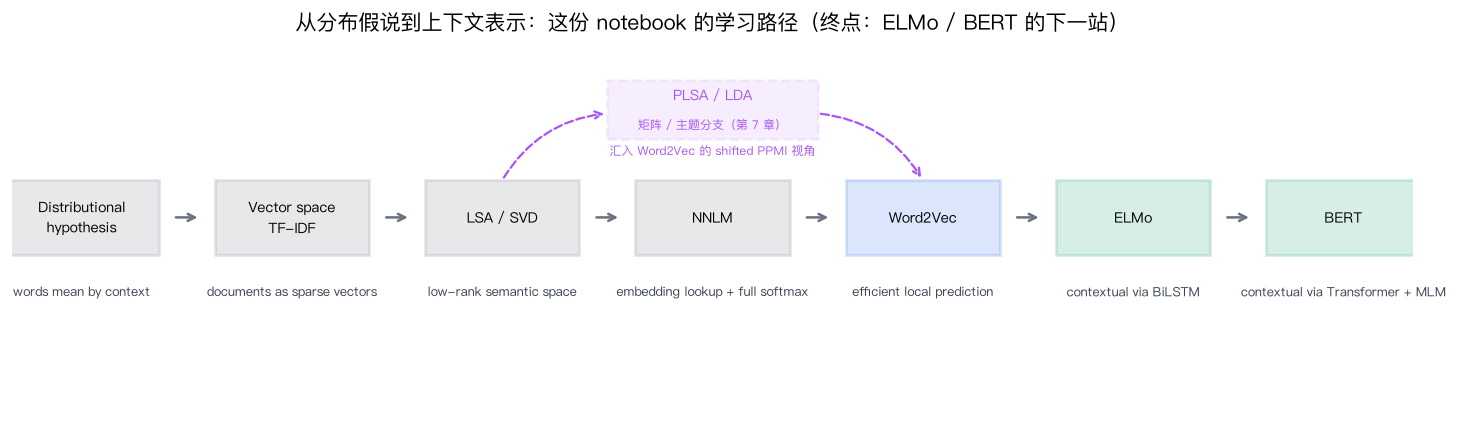

In [77]:
concept_path = [
    ("Distributional\nhypothesis", "words mean by context"),
    ("Vector space\nTF-IDF", "documents as sparse vectors"),
    ("LSA / SVD", "low-rank semantic space"),
    ("NNLM", "embedding lookup + full softmax"),
    ("Word2Vec", "efficient local prediction"),
    ("ELMo", "contextual via BiLSTM"),
    ("BERT", "contextual via Transformer + MLM"),
]

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
xs = np.linspace(0.05, 0.95, len(concept_path))
for i, ((title, subtitle), x) in enumerate(zip(concept_path, xs)):
    if title == "Word2Vec":
        color = COLORS["blue"]
    elif title in ("ELMo", "BERT"):
        color = COLORS.get("green", "#10b981")
    else:
        color = COLORS["gray"]
    rect = plt.Rectangle((x - 0.055, 0.42), 0.11, 0.20, facecolor=color, alpha=0.16,
                         edgecolor=color, linewidth=1.8)
    ax.add_patch(rect)
    ax.text(x, 0.52, title, ha="center", va="center", fontsize=9)
    ax.text(x, 0.32, subtitle, ha="center", va="center", fontsize=8, color="#374151")
    if i < len(concept_path) - 1:
        ax.annotate("", xy=(xs[i + 1] - 0.065, 0.52), xytext=(x + 0.065, 0.52),
                    arrowprops=dict(arrowstyle="->", linewidth=1.6, color="#6b7280"))

# 支线：LSA → PLSA / LDA → (shifted PPMI 视角) → Word2Vec（本教程第 7 章走这条支线）
lsa_x = xs[2]        # LSA / SVD 的位置
w2v_x = xs[4]        # Word2Vec 的位置
branch_cx = (lsa_x + w2v_x) / 2
branch_y = 0.82
branch_color = "#a855f7"
branch_rect = plt.Rectangle((branch_cx - 0.075, branch_y - 0.09), 0.15, 0.16,
                            facecolor=branch_color, alpha=0.10,
                            edgecolor=branch_color, linewidth=1.6, linestyle="--")
ax.add_patch(branch_rect)
ax.text(branch_cx, branch_y + 0.03, "PLSA / LDA", ha="center", va="center",
        fontsize=9, color=branch_color)
ax.text(branch_cx, branch_y - 0.05, "矩阵 / 主题分支（第 7 章）",
        ha="center", va="center", fontsize=7.5, color=branch_color)
ax.annotate("", xy=(branch_cx - 0.075, branch_y - 0.02),
            xytext=(lsa_x, 0.62),
            arrowprops=dict(arrowstyle="->", linewidth=1.4, color=branch_color,
                            linestyle="--", connectionstyle="arc3,rad=-0.25"))
ax.annotate("", xy=(w2v_x, 0.62),
            xytext=(branch_cx + 0.075, branch_y - 0.02),
            arrowprops=dict(arrowstyle="->", linewidth=1.4, color=branch_color,
                            linestyle="--", connectionstyle="arc3,rad=-0.25"))
ax.text(branch_cx, 0.70, "汇入 Word2Vec 的 shifted PPMI 视角",
        ha="center", va="center", fontsize=7.5, color=branch_color, style="italic")

ax.set_title("从分布假说到上下文表示：这份 notebook 的学习路径（终点：ELMo / BERT 的下一站）")
plt.tight_layout()
plt.show()